> **© 2026 Suna Kim. All Rights Reserved.**
>
> This repository is shared publicly to demonstrate applied finance/coding
skills as part of my professional portfolio. No permission is granted to
use, copy, modify, or distribute this code without explicit written
consent from the author.

## Prerequisites

| Credential | How to set up |
|---|---|
| FRED API Key | Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html and set as `FRED_API_KEY` env variable |
| WRDS Access | Requires institutional subscription. Run the notebook and enter your credentials when prompted. |

Install and Data Collection

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 00 — INSTALL & IMPORTS                                               ║
# ║  Run once per Colab session (after runtime restart)                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

!pip install fredapi pandas-datareader statsmodels -q
!pip install arch pykalman --no-deps -q

#from google.colab import drive
#drive.mount('/content/drive')

import numpy as np
import pandas as pd
import statsmodels.api as sm
import pandas_datareader.data as web
import yfinance as yf
from fredapi import Fred
from datetime import datetime
import os, warnings
warnings.filterwarnings("ignore")
KRW_CASH = 1307114   # ₩ 예수금 — update after each trade

print("✅  Libraries loaded.")





✅  Libraries loaded.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 00b — WRDS INSTALL & CONNECTION                                      ║
# ║                                                                              ║
# ║  Run once per Colab session, AFTER Cell 00.                                ║
# ║  Installs wrds package and connects using your credentials.                 ║
# ║                                                                              ║
# ║  Requires: Cell 00 (base imports must be loaded first)                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

!pip install wrds -q

import wrds
import getpass

# ── WRDS credentials ──────────────────────────────────────────────────────────
# Enter your WRDS username and password when prompted.
# These are your Wharton/WRDS login credentials (same as website login).
# Password is masked — it will not be shown in the notebook output.

print("=" * 72)
print("  CELL 00b — WRDS Connection")
print("=" * 72)

WRDS_USERNAME = input("  Enter your WRDS username: ").strip()
WRDS_PASSWORD = getpass.getpass("  Enter your WRDS password: ")

try:
    db = wrds.Connection(wrds_username=WRDS_USERNAME, wrds_password=WRDS_PASSWORD)
    print(f"\n  ✅  Connected to WRDS as '{WRDS_USERNAME}'")
    print(f"  Available schemas include: lseg_ds_equities, lseg_ds_worldscope,")
    print(f"                             ibes, comp (Compustat), crsp")
except Exception as e:
    print(f"\n  ❌  Connection failed: {e}")
    print(f"  Check your username/password at wrds-www.wharton.upenn.edu")
    db = None

# Fix: reset WRDS connection before any queries
try:
    db.session.rollback()
except Exception:
    pass

# Or if using raw engine:
try:
    wrds_conn.rollback()
except Exception:
    pass

print("\n✅  Cell 00b done. Run Cell 14 next.")

# Step 1 — see every library your subscription can access

libs = db.list_libraries()
print(libs)

# Step 2 — once you see the library names, list tables inside each relevant one
# Common IBES library names: 'ibes', 'tr_ibes', 'ibes_acad'
# Try whichever ones appear in your libs list above

for lib in ['ibes', 'tr_ibes', 'ibes_acad']:
    if lib in libs:
        print(f"\n── {lib} ──")
        print(db.list_tables(library=lib))

# Step 3 — check what LSEG/Datastream libraries you have

for lib in ['lseg_ds_equities', 'lseg_ds_worldscope', 'tfn', 'ds']:
    if lib in libs:
        print(f"\n── {lib} ──")
        print(db.list_tables(library=lib))

try:
    db.create_pgpass_file()
    print("  ✅  .pgpass file created for silent reconnection")
except Exception:
    pass


  CELL 00b — WRDS Connection
  Enter your WRDS username: suna9122
  Enter your WRDS password: ··········
Loading library list...
Done

  ✅  Connected to WRDS as 'suna9122'
  Available schemas include: lseg_ds_equities, lseg_ds_worldscope,
                             ibes, comp (Compustat), crsp

✅  Cell 00b done. Run Cell 14 next.
['aha_sample', 'ahasamp', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd_amadeus_trial', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_bank_daily', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_segments_hist_daily', 'compsamp', 'compsamp_all', 'compsamp_c

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 01 — EXTENDED TICKER REGISTRY                                        ║
# ║                                                                              ║
# ║  Schema upgrade:                                                             ║
# ║    ticker: (korean_name, english_name, nation, category,                    ║
# ║             chain_layer, cusip, recom_data_freq, product_type)              ║
# ║                                                                              ║
# ║  New field  →  chain_layer  (index 4, shifts cusip/freq/type by +1)        ║
# ║                                                                              ║
# ║  chain_layer values                                                          ║
# ║  ─────────────────                                                           ║
# ║  "ai_silicon"     GPU, ASIC, CPU, memory chips (compute substrate)          ║
# ║  "ai_packaging"   Foundry, OSAT, advanced packaging                         ║
# ║  "ai_system"      Servers, networking, storage, optical                     ║
# ║  "ai_cooling"     Thermal, power delivery, HVAC for data centers            ║
# ║  "ai_model"       Cloud hyperscaler + LLM foundation model owners           ║
# ║  "ai_app"         SaaS / software that delivers AI to end-users             ║
# ║  "ai_data"        Data warehouse, database, analytics platforms             ║
# ║  "ai_security"    Cybersecurity for AI-era cloud/edge                       ║
# ║  "ai_edge"        Edge AI, on-device inference, autonomous systems          ║
# ║  "power_fossil"   Integrated oil & gas, E&P, refining, midstream            ║
# ║  "power_nuclear"  Uranium mining, enrichment, nuclear utilities             ║
# ║  "power_renew"    Solar, wind, hydro, fuel cell generation                  ║
# ║  "power_grid"     Grid equipment, transformers, electrical infra            ║
# ║  "power_util"     Regulated utility operators                               ║
# ║  "robotics"       Industrial robots, automation, surgical robots            ║
# ║  "space"          Launch vehicles, satellites, orbital infrastructure       ║
# ║  "defense"        Defense primes, weapons systems, drones/UAV               ║
# ║  "aero_parts"     Aerospace components, MRO, advanced materials             ║
# ║  "reshoring"      EPC construction, heavy machinery, 3D printing            ║
# ║  "consumer"       Consumer brands, retail, food, lifestyle                  ║
# ║  "finance"        Banks, IB, asset managers, PE                             ║
# ║  "payment"        Payment networks, fintech platforms                       ║
# ║  "healthcare"     Pharma, biotech, medical devices, managed care            ║
# ║  "macro"          ETF macro proxies (yield curve, credit, FX, sentiment)    ║
# ║  "etf_index"      Broad market / factor / sector index ETFs                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
from datetime import datetime

TICKERS = {
    # ticker: (korean_name, english_name, nation, category,
    #          chain_layer, cusip, recom_data_freq, product_type)

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 01 — ETFs  (Bonds · Market Index · Growth · Value · Dividend · Gold)
    # ════════════════════════════════════════════════════════════════════════

    # ── Bonds ──────────────────────────────────────────────────────────────
    "AGG":  ("아이셰어즈 미국 채권 ETF",          "iShares Core U.S. Aggregate Bond ETF",              "usa", "bond",               "etf_index",  "464288513", "monthly", "etf"),
    "BND":  ("뱅가드 미국 채권 ETF",              "Vanguard Total Bond Market ETF",                    "usa", "bond",               "etf_index",  "921937835", "monthly", "etf"),
    "SPAB": ("SPDR 미국 채권 ETF",                "SPDR Portfolio Aggregate Bond ETF",                 "usa", "bond",               "etf_index",  "78468R630", "monthly", "etf"),

    # ── Market Index ───────────────────────────────────────────────────────
    "VOO":  ("뱅가드 S&P500 ETF",                "Vanguard S&P 500 ETF",                              "usa", "market index",        "etf_index",  "922908745", "daily",   "etf"),
    "SPY":  ("SPDR S&P500 ETF",                  "SPDR S&P 500 ETF",                                  "usa", "market index",        "etf_index",  "78462F103", "daily",   "etf"),
    "IWF":  ("아이셰어즈 러셀1000 성장주 ETF",   "iShares Russell 1000 Growth ETF",                   "usa", "market index",        "etf_index",  "464287234", "daily",   "etf"),
    "VONE": ("뱅가드 러셀1000 ETF",              "Vanguard Russell 1000 ETF",                         "usa", "market index",        "etf_index",  "922908561", "daily",   "etf"),
    "IWM":  ("아이셰어즈 러셀2000 ETF",          "iShares Russell 2000 ETF",                          "usa", "market index",        "etf_index",  "464287655", "daily",   "etf"),
    "VTWO": ("뱅가드 러셀2000 ETF",              "Vanguard Russell 2000 ETF",                         "usa", "market index",        "etf_index",  "922908397", "daily",   "etf"),

    # ── Growth ─────────────────────────────────────────────────────────────
    "VOOG": ("뱅가드 S&P500 성장주 ETF",         "Vanguard S&P 500 Growth ETF",                       "usa", "growth market index",  "etf_index",  "922908579", "daily",   "etf"),
    "SPYG": ("SPDR S&P500 성장주 ETF",           "SPDR Portfolio S&P 500 Growth ETF",                 "usa", "growth market index",  "etf_index",  "78468R523", "daily",   "etf"),
    "IVW":  ("아이셰어즈 S&P500 성장주 ETF",     "iShares S&P 500 Growth ETF",                        "usa", "growth market index",  "etf_index",  "464287598", "daily",   "etf"),
    "VUG":  ("뱅가드 성장주 ETF",                "Vanguard Growth ETF",                               "usa", "growth market index",  "etf_index",  "922908685", "daily",   "etf"),

    # ── Value ──────────────────────────────────────────────────────────────
    "VOOV": ("뱅가드 S&P500 가치주 ETF",         "Vanguard S&P 500 Value ETF",                        "usa", "value market index",   "etf_index",  "922908587", "daily",   "etf"),
    "SPYV": ("SPDR S&P500 가치주 ETF",           "SPDR Portfolio S&P 500 Value ETF",                  "usa", "value market index",   "etf_index",  "78468R531", "daily",   "etf"),
    "IVE":  ("아이셰어즈 S&P500 가치주 ETF",     "iShares S&P 500 Value ETF",                         "usa", "value market index",   "etf_index",  "464287606", "daily",   "etf"),
    "VONV": ("뱅가드 러셀1000 가치주 ETF",       "Vanguard Russell 1000 Value ETF",                   "usa", "value market index",   "etf_index",  "922908546", "daily",   "etf"),
    "IWD":  ("아이셰어즈 러셀1000 가치주 ETF",   "iShares Russell 1000 Value ETF",                    "usa", "value market index",   "etf_index",  "464287648", "daily",   "etf"),
    "IWN":  ("아이셰어즈 러셀2000 가치주 ETF",   "iShares Russell 2000 Value ETF",                    "usa", "value market index",   "etf_index",  "464287663", "daily",   "etf"),

    # ── Dividend / Income ──────────────────────────────────────────────────
    "JEPI": ("JP모건 에쿼티 프리미엄 인컴 ETF",  "JPMorgan Equity Premium Income ETF",                "usa", "dividend",            "etf_index",  "46641Q332", "monthly", "etf"),
    "JEPQ": ("JP모건 나스닥 프리미엄 인컴 ETF",  "JPMorgan Nasdaq Equity Premium Income ETF",         "usa", "dividend",            "etf_index",  "46641Q183", "monthly", "etf"),
    "SCHD": ("슈왑 미국 배당주 ETF",             "Schwab U.S. Dividend Equity ETF",                   "usa", "dividend",            "etf_index",  "808524805", "monthly", "etf"),
    "IDV":  ("아이셰어즈 배당 ETF",              "iShares International Select Dividend ETF",          "usa", "dividend",            "etf_index",  "464288679", "monthly", "etf"),
    "SDY":  ("SPDR S&P 배당 ETF",               "SPDR S&P Dividend ETF",                             "usa", "dividend",            "etf_index",  "78468R804", "monthly", "etf"),

    # ── High Dividend ──────────────────────────────────────────────────────
    "VYM":  ("뱅가드 미국 고배당 ETF",           "Vanguard High Dividend Yield ETF",                  "usa", "high dividend",        "etf_index",  "922908529", "monthly", "etf"),
    "DVY":  ("아이셰어즈 고배당 ETF",            "iShares Select Dividend ETF",                       "usa", "high dividend",        "etf_index",  "464288455", "monthly", "etf"),
    "ITWO": ("프로셰어즈 러셀2000 고배당 ETF",   "ProShares Russell 2000 Dividend Growers ETF",       "usa", "high dividend",        "etf_index",  "74347R792", "monthly", "etf"),

    # ── Gold ───────────────────────────────────────────────────────────────
    "GLD":  ("SPDR 금 ETF",                     "SPDR Gold Shares",                                  "usa", "gold",                "etf_index",  "369604103", "monthly", "etf"),
    "IAU":  ("아이셰어즈 골드 ETF",              "iShares Gold Trust",                                "usa", "gold",                "etf_index",  "464286400", "monthly", "etf"),
    "AAAU": ("골드만삭스 금 현물 ETF",           "Goldman Sachs Physical Gold ETF",                   "usa", "gold",                "etf_index",  "40057L105", "monthly", "etf"),
    "BAR":  ("그래닛셰어즈 금 ETF",             "GraniteShares Gold Trust",                          "usa", "gold",                "etf_index",  "38748T103", "monthly", "etf"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 02 — Energy Sector ETFs & Stocks  (unchanged categories)
    # ════════════════════════════════════════════════════════════════════════

    # ── Energy ETFs ────────────────────────────────────────────────────────
    "XLE":  ("SPDR 에너지 ETF",                 "SPDR Energy Select Sector ETF",                     "usa", "energy etf",          "etf_index",  "81369Y308", "daily",   "etf"),
    "VDE":  ("뱅가드 에너지 ETF",               "Vanguard Energy ETF",                               "usa", "energy etf",          "etf_index",  "922908728", "daily",   "etf"),
    "IXC":  ("아이셰어즈 글로벌 에너지 ETF",    "iShares Global Energy ETF",                         "usa", "energy etf",          "etf_index",  "464288273", "daily",   "etf"),
    "FENY": ("피델리티 MSCI 에너지 ETF",         "Fidelity MSCI Energy Index ETF",                    "usa", "energy etf",          "etf_index",  "316146109", "daily",   "etf"),
    "IYE":  ("아이셰어즈 미국 에너지 ETF",      "iShares U.S. Energy ETF",                           "usa", "energy etf",          "etf_index",  "464288562", "daily",   "etf"),

    # ── Energy Stocks (traditional O&G) ───────────────────────────────────
    "XOM":  ("엑슨 모빌",                        "Exxon Mobil Corporation",                           "usa", "energy stock",        "power_fossil","30231G102", "daily",   "stock"),
    "CVX":  ("쉐브론",                           "Chevron Corporation",                               "usa", "energy stock",        "power_fossil","166764100", "daily",   "stock"),
    "COP":  ("코노코필립스",                     "ConocoPhillips",                                    "usa", "energy stock",        "power_fossil","20825C104", "daily",   "stock"),
    "EOG":  ("EOG 리소시스",                     "EOG Resources Inc.",                                "usa", "energy stock",        "power_fossil","26875P101", "daily",   "stock"),
    "SLB":  ("슐럼버제",                         "SLB (Schlumberger)",                                "usa", "energy stock",        "power_fossil","806857108", "daily",   "stock"),
    "MPC":  ("마라선 페트롤리엄",               "Marathon Petroleum Corporation",                    "usa", "energy stock",        "power_fossil","56585A102", "daily",   "stock"),
    "FANG": ("다이아몬드백 에너지",              "Diamondback Energy Inc.",                           "usa", "energy stock",        "power_fossil","25278X109", "daily",   "stock"),
    "DVN":  ("데번 에너지",                      "Devon Energy Corporation",                          "usa", "energy stock",        "power_fossil","25179M103", "daily",   "stock"),
    "HAL":  ("할리버튼",                         "Halliburton Company",                               "usa", "energy stock",        "power_fossil","406216101", "daily",   "stock"),
    "OKE":  ("원오케이",                         "ONEOK Inc.",                                        "usa", "energy stock",        "power_fossil","682680103", "daily",   "stock"),
    "KMI":  ("킨더 모건",                        "Kinder Morgan Inc.",                                "usa", "energy stock",        "power_fossil","49456B101", "daily",   "stock"),
    "WMB":  ("윌리엄스 컴퍼니즈",               "Williams Companies Inc.",                           "usa", "energy stock",        "power_fossil","969457100", "daily",   "stock"),
    "BKR":  ("베이커 휴즈",                      "Baker Hughes Company",                              "usa", "energy stock",        "power_fossil","05722G100", "daily",   "stock"),
    "VLO":  ("발레로 에너지",                    "Valero Energy Corporation",                         "usa", "energy stock",        "power_fossil","91913Y100", "daily",   "stock"),
    "PSX":  ("필립스 66",                        "Phillips 66",                                       "usa", "energy stock",        "power_fossil","718546104", "daily",   "stock"),

    # ── NEW: Natural Gas ───────────────────────────────────────────────────
    "LNG":  ("셰니에르 에너지",                  "Cheniere Energy Inc.",                              "usa", "natural gas stock",    "power_fossil","16411R208", "daily",   "stock"),
    "EQT":  ("EQT",                              "EQT Corporation",                                   "usa", "natural gas stock",    "power_fossil","26884L109", "daily",   "stock"),

    # ── NEW: Nuclear Energy ────────────────────────────────────────────────
    "CCJ":  ("카메코",                           "Cameco Corporation",                                "usa", "nuclear stock",        "power_nuclear","13321L108", "daily",  "stock"),
    "LEU":  ("센트러스 에너지",                  "Centrus Energy Corp.",                              "usa", "nuclear stock",        "power_nuclear","15688A105", "daily",  "stock"),
    "CEG":  ("컨스텔레이션 에너지",              "Constellation Energy Corporation",                  "usa", "utility nuclear",       "power_nuclear","20603D107", "daily",  "stock"),
    "VST":  ("비스트라",                         "Vistra Corp.",                                      "usa", "utility nuclear",       "power_nuclear","92840M102", "daily",  "stock"),
    "TLN":  ("탈렌 에너지",                      "Talen Energy Corporation",                          "usa", "utility nuclear",       "power_nuclear","87422Q101", "daily",  "stock"),

    # ── NEW: Renewable Energy ──────────────────────────────────────────────
    "FSLR": ("퍼스트 솔라",                      "First Solar Inc.",                                  "usa", "solar stock",          "power_renew", "336433107", "daily",   "stock"),
    "RUN":  ("선런",                             "Sunrun Inc.",                                       "usa", "solar stock",          "power_renew", "86771W105", "daily",   "stock"),
    "ARRY": ("어레이 테크",                      "Array Technologies Inc.",                           "usa", "solar stock",          "power_renew", "04271L100", "daily",   "stock"),
    "ENPH": ("엔페이즈",                         "Enphase Energy Inc.",                               "usa", "solar stock",          "power_renew", "29355A107", "daily",   "stock"),
    "SEDG": ("솔라엣지",                         "SolarEdge Technologies Inc.",                       "usa", "solar stock",          "power_renew", "M8936T102", "daily",   "stock"),
    "BE":   ("블룸 에너지",                      "Bloom Energy Corporation",                          "usa", "fuel cell stock",      "power_renew", "09075V102", "daily",   "stock"),
    "PLUG": ("플러그파워",                       "Plug Power Inc.",                                   "usa", "fuel cell stock",      "power_renew", "72919P202", "daily",   "stock"),
    "CMI":  ("커민스",                           "Cummins Inc.",                                      "usa", "industrial power",     "power_grid",  "231021106", "monthly", "stock"),

    # ── NEW: Power Grid & Electrical ──────────────────────────────────────
    "GEV":  ("GE 버노바",                        "GE Vernova Inc.",                                   "usa", "power equipment",      "power_grid",  "36828A101", "daily",   "stock"),
    "ETN":  ("이튼",                             "Eaton Corporation plc",                             "usa", "power equipment",      "power_grid",  "278058102", "daily",   "stock"),
    "HUBB": ("허벨",                             "Hubbell Incorporated",                              "usa", "power equipment",      "power_grid",  "443510201", "daily",   "stock"),
    "PWR":  ("콴타 서비시스",                    "Quanta Services Inc.",                              "usa", "power equipment",      "power_grid",  "74762E102", "daily",   "stock"),
    "VRT":  ("버티브 홀딩스",                    "Vertiv Holdings Co.",                               "usa", "data center power",    "ai_cooling",  "92537N108", "daily",   "stock"),
    "MOD":  ("모다인 매뉴팩처링",               "Modine Manufacturing Co.",                          "usa", "thermal mgmt",         "ai_cooling",  "608554101", "daily",   "stock"),
    "TT":   ("트레인 테크놀러지스",              "Trane Technologies plc",                            "usa", "hvac",                 "ai_cooling",  "G8994E103", "daily",   "stock"),

    # ── NEW: Utilities ─────────────────────────────────────────────────────
    "NEE":  ("넥스트에라 에너지",                "NextEra Energy Inc.",                               "usa", "utility stock",        "power_util",  "65339F101", "monthly", "stock"),
    "SO":   ("서던 컴퍼니",                      "The Southern Company",                              "usa", "utility stock",        "power_util",  "842587107", "monthly", "stock"),
    "DUK":  ("듀크 에너지",                      "Duke Energy Corporation",                           "usa", "utility stock",        "power_util",  "26441C204", "monthly", "stock"),
    "AEP":  ("아메리칸 일렉트릭",               "American Electric Power Co. Inc.",                  "usa", "utility stock",        "power_util",  "025537101", "monthly", "stock"),
    "EXC":  ("엑셀론",                           "Exelon Corporation",                                "usa", "utility stock",        "power_util",  "30161N101", "monthly", "stock"),
    "SRE":  ("셈프라",                           "Sempra",                                            "usa", "utility stock",        "power_util",  "816851109", "monthly", "stock"),
    "D":    ("도미니언 에너지",                  "Dominion Energy Inc.",                              "usa", "utility stock",        "power_util",  "25746U109", "monthly", "stock"),
    "XEL":  ("엑셀 에너지",                      "Xcel Energy Inc.",                                  "usa", "utility stock",        "power_util",  "98389B100", "monthly", "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 03 — Semiconductors  (AI Silicon layer)
    # ════════════════════════════════════════════════════════════════════════

    # ── Semiconductor ETFs ─────────────────────────────────────────────────
    "SOXX": ("SOXX",   "iShares Semiconductor ETF",                          "usa", "semiconductor etf",   "etf_index",  "464288356", "daily",   "etf"),
    "SMH":  ("SMH",    "VanEck Semiconductor ETF",                           "usa", "semiconductor etf",   "etf_index",  "922042858", "daily",   "etf"),
    "SOXQ": ("SOXQ",   "Invesco PHLX Semiconductor ETF",                    "usa", "semiconductor etf",   "etf_index",  "46138G680", "daily",   "etf"),

    # ── GPU / ASIC / CPU ───────────────────────────────────────────────────
    "NVDA": ("엔비디아",                         "NVIDIA Corporation",                                "usa", "ai gpu",              "ai_silicon", "67066G104", "daily",   "stock"),
    "AMD":  ("AMD",                              "Advanced Micro Devices Inc.",                       "usa", "ai gpu",              "ai_silicon", "007903107", "daily",   "stock"),
    "AVGO": ("브로드컴",                         "Broadcom Inc.",                                     "usa", "ai asic",             "ai_silicon", "11135F101", "daily",   "stock"),
    "MRVL": ("마벨",                             "Marvell Technology Inc.",                           "usa", "ai asic",             "ai_silicon", "573874104", "daily",   "stock"),
    "INTC": ("인텔",                             "Intel Corporation",                                 "usa", "cpu",                 "ai_silicon", "458140100", "daily",   "stock"),
    "QCOM": ("퀄컴",                             "Qualcomm Incorporated",                             "usa", "mobile ap",           "ai_silicon", "747525103", "daily",   "stock"),
    "ARM":  ("ARM 홀딩스",                       "Arm Holdings plc ADR",                              "usa", "cpu isa",             "ai_silicon", "G04404133", "daily",   "stock"),

    # ── Memory / Storage ──────────────────────────────────────────────────
    "MU":   ("마이크론",                         "Micron Technology Inc.",                            "usa", "ai memory",           "ai_silicon", "595112103", "daily",   "stock"),
    "WDC":  ("웨스턴 디지털",                    "Western Digital Corporation",                       "usa", "data storage",        "ai_system",  "958102105", "daily",   "stock"),
    "STX":  ("시게이트",                         "Seagate Technology Holdings plc",                   "usa", "data storage",        "ai_system",  "G7945J104", "daily",   "stock"),
    "PSTG": ("퓨어스토리지",                     "Pure Storage Inc.",                                 "usa", "data storage",        "ai_system",  "74624M102", "daily",   "stock"),

    # ── Semiconductor Equipment / EDA ─────────────────────────────────────
    "AMAT": ("어플라이드 머티리얼즈",            "Applied Materials Inc.",                            "usa", "semiconductor equip",  "ai_silicon", "038222105", "daily",   "stock"),
    "ASML": ("ASML",                             "ASML Holding N.V. ADR",                             "usa", "semiconductor equip",  "ai_silicon", "N07059210", "daily",   "stock"),
    "LRCX": ("램 리서치",                        "Lam Research Corporation",                          "usa", "semiconductor equip",  "ai_silicon", "512807108", "daily",   "stock"),
    "KLAC": ("KLA",                              "KLA Corporation",                                   "usa", "semiconductor equip",  "ai_silicon", "482480100", "daily",   "stock"),
    "CDNS": ("케이던스",                         "Cadence Design Systems Inc.",                       "usa", "eda software",        "ai_silicon", "127387108", "daily",   "stock"),
    "SNPS": ("시놉시스",                         "Synopsys Inc.",                                     "usa", "eda software",        "ai_silicon", "871607107", "daily",   "stock"),

    # ── Foundry ────────────────────────────────────────────────────────────
    "TSM":  ("TSMC ADR",                         "Taiwan Semiconductor Manufacturing Co. ADR",        "usa", "foundry",             "ai_packaging","874039100", "daily",   "stock"),

    # ── Analog / Mixed-Signal ─────────────────────────────────────────────
    "TXN":  ("텍사스 인스트루먼츠",              "Texas Instruments Incorporated",                    "usa", "analog semiconductor", "ai_silicon", "882184108", "daily",   "stock"),
    "ADI":  ("아날로그 디바이시즈",              "Analog Devices Inc.",                               "usa", "analog semiconductor", "ai_silicon", "032654105", "daily",   "stock"),
    "ON":   ("온 세미컨덕터",                    "ON Semiconductor Corporation",                      "usa", "analog semiconductor", "ai_silicon", "682189105", "daily",   "stock"),

    # ── Networking / Optical ──────────────────────────────────────────────
    "ANET": ("아리스타 네트웍스",                "Arista Networks Inc.",                              "usa", "ai networking",        "ai_system",  "040413106", "daily",   "stock"),
    "CSCO": ("시스코",                           "Cisco Systems Inc.",                                "usa", "networking",          "ai_system",  "17275R102", "daily",   "stock"),
    "COHR": ("코히어런트",                       "Coherent Corp.",                                    "usa", "optical components",   "ai_system",  "19171M102", "daily",   "stock"),
    "LITE": ("루멘텀 홀딩스",                    "Lumentum Holdings Inc.",                            "usa", "optical components",   "ai_system",  "55024U109", "daily",   "stock"),
    "CIEN": ("시에나",                           "Ciena Corporation",                                 "usa", "optical networking",   "ai_system",  "171779309", "daily",   "stock"),

    # ── Server / Contract Manufacturing ───────────────────────────────────
    "DELL": ("델 테크놀러지",                    "Dell Technologies Inc.",                            "usa", "ai server",           "ai_system",  "24703L202", "daily",   "stock"),
    "HPE":  ("HP 엔터프라이즈",                  "Hewlett Packard Enterprise Co.",                    "usa", "ai server",           "ai_system",  "42259E409", "daily",   "stock"),
    "CLS":  ("셀레스티카",                       "Celestica Inc.",                                    "usa", "ai server contract mfg","ai_system", "15101Q108", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 04 — Macro Indicators
    # ════════════════════════════════════════════════════════════════════════

    # ── Ultra Short-Term Rates ─────────────────────────────────────────────
    "SGOV": ("아이셰어즈 0-3개월 국채 ETF",      "iShares 0-3 Month Treasury Bond ETF",               "usa", "tbill",               "macro",      "46436E718", "daily",   "etf"),
    "BIL":  ("SPDR 1-3개월 국채 ETF",            "SPDR Bloomberg 1-3 Month T-Bill ETF",               "usa", "macro yield curve",    "macro",      "78468R614", "daily",   "etf"),
    "SHV":  ("아이셰어즈 단기국채 ETF",          "iShares Short Treasury Bond ETF",                   "usa", "macro yield curve",    "macro",      "464288729", "daily",   "etf"),

    # ── Duration ──────────────────────────────────────────────────────────
    "SHY":  ("아이셰어즈 1-3년 국채 ETF",        "iShares 1-3 Year Treasury Bond ETF",                "usa", "macro yield curve",    "macro",      "464288414", "daily",   "etf"),
    "IEF":  ("아이셰어즈 7-10년 국채 ETF",       "iShares 7-10 Year Treasury Bond ETF",               "usa", "macro yield curve",    "macro",      "464288372", "daily",   "etf"),
    "TLT":  ("아이셰어즈 20년+ 국채 ETF",        "iShares 20+ Year Treasury Bond ETF",                "usa", "macro yield curve",    "macro",      "464288513", "daily",   "etf"),

    # ── Credit Spreads ─────────────────────────────────────────────────────
    "LQD":  ("아이셰어즈 투자등급 회사채 ETF",   "iShares iBoxx $ Investment Grade Corp Bond ETF",    "usa", "macro credit",         "macro",      "464288513", "daily",   "etf"),
    "HYG":  ("아이셰어즈 하이일드 채권 ETF",     "iShares iBoxx $ High Yield Corporate Bond ETF",     "usa", "macro credit",         "macro",      "464288422", "daily",   "etf"),
    "EMB":  ("아이셰어즈 신흥국 채권 ETF",       "iShares JP Morgan USD Emerging Markets Bond ETF",   "usa", "macro credit",         "macro",      "464288281", "daily",   "etf"),
    "BKLN": ("인베스코 시니어론 ETF",            "Invesco Senior Loan ETF",                           "usa", "macro credit",         "macro",      "46138E677", "daily",   "etf"),

    # ── Inflation ─────────────────────────────────────────────────────────
    "TIP":  ("아이셰어즈 TIPS ETF",              "iShares TIPS Bond ETF",                             "usa", "macro inflation",      "macro",      "464288372", "daily",   "etf"),
    "RINF": ("프로셰어즈 인플레이션 기대 ETF",   "ProShares Inflation Expectations ETF",              "usa", "macro inflation",      "macro",      "74347R818", "daily",   "etf"),
    "PDBC": ("인베스코 원자재 ETF",              "Invesco Optimum Yield Diversified Commodity ETF",   "usa", "macro inflation",      "macro",      "46138G649", "daily",   "etf"),

    # ── Dollar Strength ───────────────────────────────────────────────────
    "UUP":  ("인베스코 달러 인덱스 ETF",         "Invesco DB US Dollar Index Bullish Fund",            "usa", "macro fx",             "macro",      "46140H004", "daily",   "etf"),
    "FXE":  ("인베스코 유로 ETF",               "Invesco CurrencyShares Euro Currency Trust",         "usa", "macro fx",             "macro",      "46090A103", "daily",   "etf"),

    # ── Risk Appetite / Sentiment ─────────────────────────────────────────
    "VXX":  ("아이패스 VIX 단기선물 ETN",        "iPath Series B S&P 500 VIX Short-Term Futures ETN", "usa", "macro sentiment",      "macro",      "06746P681", "daily",   "etf"),

    # ── Sector Rotation / Recession Signals ──────────────────────────────
    "QQQ":  ("인베스코 나스닥100 ETF",           "Invesco QQQ Trust",                                 "usa", "tech etf",             "etf_index",  "46090E103", "monthly", "etf"),
    "XLY":  ("SPDR 경기소비재 ETF",             "SPDR Consumer Discretionary Select Sector ETF",     "usa", "macro sector",         "macro",      "81369Y308", "daily",   "etf"),
    "XLP":  ("SPDR 필수소비재 ETF",             "SPDR Consumer Staples Select Sector ETF",           "usa", "macro sector",         "macro",      "81369Y829", "daily",   "etf"),
    "XLF":  ("SPDR 금융 ETF",                   "SPDR Financial Select Sector ETF",                  "usa", "macro sector",         "macro",      "81369Y696", "daily",   "etf"),
    "ITB":  ("아이셰어즈 주택건설 ETF",         "iShares U.S. Home Construction ETF",                "usa", "macro sector",         "macro",      "464288745", "daily",   "etf"),
    "XHB":  ("SPDR 주택 ETF",                   "SPDR S&P Homebuilders ETF",                         "usa", "macro sector",         "macro",      "78468R622", "daily",   "etf"),
    "USO":  ("미국 원유 ETF",                    "United States Oil Fund LP",                         "usa", "oil etf",              "macro",      "91232N108", "monthly", "etf"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 05 — AI Software  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Cloud Platform / Hyperscalers ─────────────────────────────────────
    "MSFT": ("마이크로소프트",                   "Microsoft Corporation",                             "usa", "cloud platform",       "ai_model",   "594918104", "daily",   "stock"),
    "AMZN": ("아마존 닷컴",                      "Amazon.com Inc.",                                   "usa", "cloud platform",       "ai_model",   "023135106", "daily",   "stock"),
    "GOOGL":("알파벳",                           "Alphabet Inc. Class A",                             "usa", "cloud platform",       "ai_model",   "02079K305", "daily",   "stock"),
    "ORCL": ("오라클",                           "Oracle Corporation",                                "usa", "cloud platform",       "ai_model",   "68389X105", "daily",   "stock"),

    # ── LLM / Foundation Models ────────────────────────────────────────────
    "META": ("메타 플랫폼즈",                    "Meta Platforms Inc.",                               "usa", "llm platform",         "ai_model",   "30303M102", "daily",   "stock"),

    # ── Data Platform ─────────────────────────────────────────────────────
    "SNOW": ("스노우플레이크",                   "Snowflake Inc.",                                    "usa", "data warehouse",       "ai_data",    "833445126", "daily",   "stock"),
    "MDB":  ("몽고DB",                           "MongoDB Inc.",                                      "usa", "nosql database",       "ai_data",    "60937P106", "daily",   "stock"),

    # ── SaaS AI Applications ──────────────────────────────────────────────
    "CRM":  ("세일즈포스",                       "Salesforce Inc.",                                   "usa", "ai saas crm",          "ai_app",     "79466L302", "daily",   "stock"),
    "NOW":  ("서비스나우",                       "ServiceNow Inc.",                                   "usa", "ai saas workflow",     "ai_app",     "81762P102", "daily",   "stock"),
    "ADBE": ("어도비",                           "Adobe Inc.",                                        "usa", "ai saas creative",     "ai_app",     "00724F101", "daily",   "stock"),
    "PLTR": ("팔란티어 테크",                    "Palantir Technologies Inc.",                        "usa", "ai analytics",         "ai_app",     "69608A108", "daily",   "stock"),
    "APP":  ("앱러빈",                           "AppLovin Corporation",                              "usa", "ai ad platform",       "ai_app",     "03783C100", "daily",   "stock"),
    "IBM":  ("IBM",                              "International Business Machines Corp.",              "usa", "ai enterprise",        "ai_app",     "459200101", "monthly", "stock"),

    # ── Cybersecurity ─────────────────────────────────────────────────────
    "PANW": ("팔로알토 네트웍스",                "Palo Alto Networks Inc.",                           "usa", "cybersecurity",        "ai_security","697435105", "daily",   "stock"),
    "CRWD": ("크라우드스트라이크",               "CrowdStrike Holdings Inc.",                         "usa", "cybersecurity",        "ai_security","22788C105", "daily",   "stock"),
    "NET":  ("클라우드플레어",                   "Cloudflare Inc.",                                   "usa", "cybersecurity edge",   "ai_security","18915M107", "daily",   "stock"),

    # ── DevOps / Other Software ────────────────────────────────────────────
    "TEAM": ("아틀라시안",                       "Atlassian Corporation plc",                         "usa", "devops software",      "ai_app",     "G06242104", "daily",   "stock"),
    "FROG": ("제이프로그",                       "JFrog Ltd.",                                        "usa", "devops software",      "ai_app",     "M4973A101", "daily",   "stock"),

    # ── Edge AI ────────────────────────────────────────────────────────────
    "AAPL": ("애플",                             "Apple Inc.",                                        "usa", "edge ai device",       "ai_edge",    "037833100", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 06 — Aerospace, Defense & Space  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Defense Primes ─────────────────────────────────────────────────────
    "RTX":  ("RTX",                              "RTX Corporation",                                   "usa", "defense prime",        "defense",    "75513E101", "daily",   "stock"),
    "LMT":  ("록히드 마틴",                      "Lockheed Martin Corporation",                       "usa", "defense prime",        "defense",    "539830109", "daily",   "stock"),
    "BA":   ("보잉",                             "Boeing Company",                                    "usa", "aerospace defense",    "defense",    "097023105", "daily",   "stock"),
    "NOC":  ("노스롭 그루먼",                    "Northrop Grumman Corporation",                      "usa", "defense prime",        "defense",    "666807102", "daily",   "stock"),
    "GD":   ("제네럴 다이나믹",                  "General Dynamics Corporation",                      "usa", "defense prime",        "defense",    "369550108", "daily",   "stock"),
    "GE":   ("GE 에어로스페이스",               "GE Aerospace",                                      "usa", "aerospace engine",     "defense",    "369604103", "daily",   "stock"),

    # ── Aerospace Components / MRO ─────────────────────────────────────────
    "TDG":  ("트랜스다임",                       "TransDigm Group Incorporated",                      "usa", "aerospace parts",      "aero_parts", "893641100", "daily",   "stock"),
    "HWM":  ("하우멧 에어로스페이스",            "Howmet Aerospace Inc.",                             "usa", "aerospace parts",      "aero_parts", "443201108", "daily",   "stock"),
    "FTAI": ("FTAI 에비에이션",                  "FTAI Aviation Ltd.",                                "usa", "aerospace mro",        "aero_parts", "G36564100", "daily",   "stock"),

    # ── Drones / UAM ──────────────────────────────────────────────────────
    "JOBY": ("조비 에비에이션",                  "Joby Aviation Inc.",                                "usa", "evtol uam",            "defense",    "47763Q101", "daily",   "stock"),
    "KTOS": ("크래토스 디펜스",                  "Kratos Defense & Security Solutions Inc.",          "usa", "unmanned systems",     "defense",    "50077B207", "daily",   "stock"),
    "AVAV": ("에어로바이론먼트",                 "AeroVironment Inc.",                                "usa", "drone uav",            "defense",    "008252108", "daily",   "stock"),

    # ── Space Economy ──────────────────────────────────────────────────────
    "RKLB": ("로켓랩",                           "Rocket Lab USA Inc.",                               "usa", "space launch",         "space",      "77307G105", "daily",   "stock"),
    "MDA":  ("MDA 스페이스",                     "MDA Space Ltd.",                                    "usa", "space infrastructure", "space",      "55262G103", "daily",   "stock"),
    "LUNR": ("인튜이티브 머신즈",                "Intuitive Machines Inc.",                           "usa", "space lunar",          "space",      "46127W108", "daily",   "stock"),
    "ASTS": ("AST 스페이스모바일",               "AST SpaceMobile Inc.",                              "usa", "space satellite telecom","space",     "00217D106", "daily",   "stock"),

    # ── Advanced Materials (aerospace) ─────────────────────────────────────
    "CRS":  ("카펜터 테크놀러지",                "Carpenter Technology Corporation",                  "usa", "advanced materials",   "aero_parts", "144285103", "daily",   "stock"),
    "ATI":  ("ATI",                              "ATI Inc.",                                          "usa", "advanced materials",   "aero_parts", "00214Q104", "daily",   "stock"),
    "MTRN": ("머테리온",                         "Materion Corporation",                              "usa", "advanced materials",   "aero_parts", "576690101", "monthly", "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 07 — Reshoring & Construction  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Industrial Automation ─────────────────────────────────────────────
    "EMR":  ("에머슨 일렉트릭",                  "Emerson Electric Co.",                              "usa", "process automation",   "robotics",   "291011104", "monthly", "stock"),
    "HON":  ("허니웰",                           "Honeywell International Inc.",                      "usa", "industrial automation","robotics",   "438516106", "monthly", "stock"),
    "PH":   ("파커 하니핀",                      "Parker-Hannifin Corporation",                       "usa", "motion control",       "robotics",   "701094104", "monthly", "stock"),
    "ROK":  ("록웰 오토메이션",                  "Rockwell Automation Inc.",                          "usa", "smart factory",        "robotics",   "775508102", "daily",   "stock"),
    "TER":  ("테러다인",                         "Teradyne Inc.",                                     "usa", "semiconductor test",   "robotics",   "880770102", "daily",   "stock"),

    # ── 3D Printing ────────────────────────────────────────────────────────
    "SSYS": ("스트라타시스",                     "Stratasys Ltd.",                                    "usa", "3d printing",          "reshoring",  "M8540W103", "daily",   "stock"),
    "DDD":  ("3D 시스템즈",                      "3D Systems Corporation",                            "usa", "3d printing",          "reshoring",  "88554D205", "daily",   "stock"),

    # ── EPC Construction ──────────────────────────────────────────────────
    "FLR":  ("플루오르",                         "Fluor Corporation",                                 "usa", "epc construction",     "reshoring",  "343412102", "daily",   "stock"),
    "J":    ("제이콥스 솔루션",                  "Jacobs Solutions Inc.",                             "usa", "epc construction",     "reshoring",  "469814107", "daily",   "stock"),
    "ACM":  ("에이컴",                           "AECOM",                                             "usa", "epc construction",     "reshoring",  "00766T100", "daily",   "stock"),
    "KBR":  ("KBR",                              "KBR Inc.",                                          "usa", "defense engineering",  "reshoring",  "48300T104", "daily",   "stock"),
    "EME":  ("엠코 그룹",                        "EMCOR Group Inc.",                                  "usa", "mechanical electrical","reshoring",  "29084Q100", "daily",   "stock"),

    # ── Heavy Machinery ────────────────────────────────────────────────────
    "CAT":  ("캐터필러",                         "Caterpillar Inc.",                                  "usa", "construction machinery","reshoring",  "149123101", "daily",   "stock"),
    "DE":   ("디어 앤 컴퍼니",                   "Deere & Company",                                   "usa", "ag construction mach", "reshoring",  "244199105", "monthly", "stock"),
    "URI":  ("유나이티드 렌탈",                  "United Rentals Inc.",                               "usa", "equipment rental",     "reshoring",  "911363109", "daily",   "stock"),
    "HRI":  ("허크 홀딩스",                      "Herc Holdings Inc.",                                "usa", "equipment rental",     "reshoring",  "42704L104", "daily",   "stock"),

    # ── Residential Construction / Remodeling ─────────────────────────────
    "DHI":  ("D.R. 호튼",                        "D.R. Horton Inc.",                                  "usa", "homebuilder",          "reshoring",  "23331A109", "daily",   "stock"),
    "LEN":  ("레나",                             "Lennar Corporation",                                "usa", "homebuilder",          "reshoring",  "526057104", "daily",   "stock"),
    "HD":   ("홈디포",                           "Home Depot Inc.",                                   "usa", "home improvement retail","consumer",  "437076102", "daily",   "stock"),
    "LOW":  ("로우스",                           "Lowe's Companies Inc.",                             "usa", "home improvement retail","consumer",  "548661107", "monthly", "stock"),
    "SHW":  ("셔윈 윌리엄스",                    "Sherwin-Williams Company",                          "usa", "paint coatings",       "reshoring",  "824348106", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 08 — Robotics / Physical AI  (NEW)
    # ════════════════════════════════════════════════════════════════════════
    "TSLA": ("테슬라",                           "Tesla Inc.",                                        "usa", "ev autonomous",        "robotics",   "88160R101", "daily",   "stock"),
    "ISRG": ("인튜이티브 서지컬",                "Intuitive Surgical Inc.",                           "usa", "surgical robot",       "robotics",   "46120E602", "daily",   "stock"),
    "UBER": ("우버 테크놀러지스",                "Uber Technologies Inc.",                            "usa", "ride sharing platform","ai_app",     "90353T100", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 09 — Finance & Fintech  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Banks ──────────────────────────────────────────────────────────────
    "JPM":  ("JP모건 체이스",                    "JPMorgan Chase & Co.",                              "usa", "diversified bank",     "finance",    "46625H100", "daily",   "stock"),
    "BAC":  ("뱅크 오브 아메리카",               "Bank of America Corporation",                       "usa", "diversified bank",     "finance",    "060505104", "daily",   "stock"),
    "WFC":  ("웰스파고",                         "Wells Fargo & Company",                             "usa", "diversified bank",     "finance",    "949746101", "daily",   "stock"),
    "C":    ("씨티그룹",                         "Citigroup Inc.",                                    "usa", "diversified bank",     "finance",    "172967424", "daily",   "stock"),

    # ── Investment Banking / Securities ───────────────────────────────────
    "GS":   ("골드만삭스",                       "Goldman Sachs Group Inc.",                          "usa", "investment bank",      "finance",    "38141G104", "daily",   "stock"),
    "MS":   ("모건 스탠리",                      "Morgan Stanley",                                    "usa", "investment bank",      "finance",    "617446448", "daily",   "stock"),
    "SCHW": ("찰스 슈왑",                        "Charles Schwab Corporation",                        "usa", "brokerage",            "finance",    "808513105", "daily",   "stock"),

    # ── Asset Management / PE ─────────────────────────────────────────────
    "BLK":  ("블랙록",                           "BlackRock Inc.",                                    "usa", "asset manager",        "finance",    "09247X101", "monthly", "stock"),
    "BX":   ("블랙스톤",                         "Blackstone Inc.",                                   "usa", "private equity",       "finance",    "09260D107", "daily",   "stock"),
    "KKR":  ("KKR",                              "KKR & Co. Inc.",                                    "usa", "private equity",       "finance",    "48251W104", "daily",   "stock"),
    "BRK.B":("버크셔 해서웨이",                  "Berkshire Hathaway Inc. Class B",                   "usa", "diversified financial","finance",    "084670702", "monthly", "stock"),

    # ── Payment Networks / Fintech ────────────────────────────────────────
    "V":    ("비자",                             "Visa Inc.",                                         "usa", "payment network",      "payment",    "92826C839", "daily",   "stock"),
    "MA":   ("마스터카드",                       "Mastercard Incorporated",                           "usa", "payment network",      "payment",    "57636Q104", "daily",   "stock"),
    "AXP":  ("아메리칸 익스프레스",              "American Express Company",                          "usa", "consumer finance",     "payment",    "025816109", "monthly", "stock"),
    "PYPL": ("페이팔",                           "PayPal Holdings Inc.",                              "usa", "digital wallet",       "payment",    "70450Y103", "daily",   "stock"),
    "HOOD": ("로빈후드",                         "Robinhood Markets Inc.",                            "usa", "fintech platform",     "payment",    "770700102", "daily",   "stock"),
    "COIN": ("코인베이스",                       "Coinbase Global Inc.",                              "usa", "crypto exchange",      "payment",    "19260Q107", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 10 — Healthcare  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Pharma / Biotech ──────────────────────────────────────────────────
    "LLY":  ("일라이 릴리",                      "Eli Lilly and Company",                             "usa", "pharmaceuticals",      "healthcare", "532457108", "daily",   "stock"),
    "JNJ":  ("존슨 앤 존슨",                     "Johnson & Johnson",                                 "usa", "pharmaceuticals",      "healthcare", "478160104", "monthly", "stock"),
    "ABBV": ("애브비",                           "AbbVie Inc.",                                       "usa", "biotech pharma",       "healthcare", "00287Y109", "monthly", "stock"),
    "MRK":  ("머크",                             "Merck & Co. Inc.",                                  "usa", "pharmaceuticals",      "healthcare", "58933Y105", "monthly", "stock"),
    "AMGN": ("암젠",                             "Amgen Inc.",                                        "usa", "biotechnology",        "healthcare", "031162100", "monthly", "stock"),

    # ── Medical Devices ───────────────────────────────────────────────────
    "ABT":  ("애보트 래버로터리",                "Abbott Laboratories",                               "usa", "medical devices",      "healthcare", "002824100", "monthly", "stock"),
    "DHR":  ("다나허",                           "Danaher Corporation",                               "usa", "life science tools",   "healthcare", "235851102", "monthly", "stock"),
    "TMO":  ("써모 피셔 사이언티픽",             "Thermo Fisher Scientific Inc.",                     "usa", "life science tools",   "healthcare", "883556102", "monthly", "stock"),

    # ── Managed Care / Health Data ────────────────────────────────────────
    "UNH":  ("유나이티드 헬스",                  "UnitedHealth Group Incorporated",                   "usa", "managed care",         "healthcare", "91324P102", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 11 — Life Style & Consumer  (NEW)
    # ════════════════════════════════════════════════════════════════════════

    # ── Sports Apparel ────────────────────────────────────────────────────
    "NKE":  ("나이키",                           "Nike Inc.",                                         "usa", "sports apparel",       "consumer",   "654106103", "monthly", "stock"),
    "LULU": ("룰루레몬",                         "Lululemon Athletica Inc.",                          "usa", "sports apparel",       "consumer",   "550021109", "monthly", "stock"),
    "ONON": ("온 홀딩스",                        "On Holding AG",                                     "usa", "sports apparel",       "consumer",   "A3EA4H102", "daily",   "stock"),
    "DECK": ("데커즈 아웃도어",                  "Deckers Outdoor Corporation",                       "usa", "footwear",             "consumer",   "243537107", "daily",   "stock"),

    # ── Food & Beverage ───────────────────────────────────────────────────
    "MCD":  ("맥도날드",                         "McDonald's Corporation",                            "usa", "restaurants",          "consumer",   "580135101", "monthly", "stock"),
    "SBUX": ("스타벅스",                         "Starbucks Corporation",                             "usa", "restaurants",          "consumer",   "855244109", "monthly", "stock"),
    "CMG":  ("치폴레",                           "Chipotle Mexican Grill Inc.",                       "usa", "restaurants",          "consumer",   "169905106", "monthly", "stock"),
    "KO":   ("코카콜라",                         "Coca-Cola Company",                                 "usa", "beverages",            "consumer",   "191216100", "monthly", "stock"),
    "PEP":  ("펩시코",                           "PepsiCo Inc.",                                      "usa", "beverages",            "consumer",   "713448108", "monthly", "stock"),
    "MDLZ": ("몬델레즈",                         "Mondelez International Inc.",                       "usa", "packaged food",        "consumer",   "609207105", "monthly", "stock"),
    "KHC":  ("크래프트 하인즈",                  "Kraft Heinz Company",                               "usa", "packaged food",        "consumer",   "500754106", "monthly", "stock"),
    "CELH": ("셀시어스",                         "Celsius Holdings Inc.",                             "usa", "energy beverage",      "consumer",   "15118V208", "daily",   "stock"),

    # ── Travel & Leisure ──────────────────────────────────────────────────
    "BKNG": ("부킹 홀딩스",                      "Booking Holdings Inc.",                             "usa", "online travel",        "ai_app",     "09857L108", "monthly", "stock"),
    "ABNB": ("에어비앤비",                       "Airbnb Inc.",                                       "usa", "sharing platform",     "ai_app",     "009066101", "daily",   "stock"),
    "DAL":  ("델타항공",                         "Delta Air Lines Inc.",                              "usa", "airline",              "consumer",   "247361702", "monthly", "stock"),
    "UAL":  ("유나이티드 항공",                  "United Airlines Holdings Inc.",                     "usa", "airline",              "consumer",   "910047109", "monthly", "stock"),
    "AAL":  ("아메리칸 항공",                    "American Airlines Group Inc.",                      "usa", "airline",              "consumer",   "02376R102", "monthly", "stock"),
    "MAR":  ("메리어트",                         "Marriott International Inc.",                       "usa", "hotel",                "consumer",   "571903202", "monthly", "stock"),

    # ── Retail & Logistics ────────────────────────────────────────────────
    "WMT":  ("월마트",                           "Walmart Inc.",                                      "usa", "big box retail",       "ai_app",     "931142103", "daily",   "stock"),
    "COST": ("코스트코 홀세일",                  "Costco Wholesale Corporation",                      "usa", "warehouse retail",     "consumer",   "22160K105", "daily",   "stock"),
    "TJX":  ("TJX 컴퍼니즈",                    "TJX Companies Inc.",                                "usa", "off-price retail",     "consumer",   "872540109", "monthly", "stock"),
    "ROST": ("로스 스토어",                      "Ross Stores Inc.",                                  "usa", "off-price retail",     "consumer",   "778296103", "monthly", "stock"),
    "FDX":  ("페덱스",                           "FedEx Corporation",                                 "usa", "air freight logistics","consumer",   "31428X106", "monthly", "stock"),
    "UPS":  ("UPS",                              "United Parcel Service Inc.",                        "usa", "ground logistics",     "consumer",   "911312106", "monthly", "stock"),

    # ── Automotive ────────────────────────────────────────────────────────
    "F":    ("포드",                             "Ford Motor Company",                                "usa", "automobile",           "consumer",   "345370860", "monthly", "stock"),
    "GM":   ("제네럴 모터스",                    "General Motors Company",                            "usa", "automobile",           "consumer",   "37045V100", "monthly", "stock"),
    "RACE": ("페라리",                           "Ferrari N.V.",                                      "usa", "luxury automobile",    "consumer",   "N3167Q109", "monthly", "stock"),

    # ── Beauty / Personal Care ────────────────────────────────────────────
    "EL":   ("에스티 로더",                      "Estée Lauder Companies Inc.",                       "usa", "luxury cosmetics",     "consumer",   "518439104", "monthly", "stock"),
    "ELF":  ("엘프 뷰티",                        "e.l.f. Beauty Inc.",                                "usa", "mass cosmetics",       "consumer",   "268613107", "daily",   "stock"),
    "ULTA": ("울타 뷰티",                        "Ulta Beauty Inc.",                                  "usa", "beauty retail",        "consumer",   "903653100", "monthly", "stock"),

    # ── Consumer Staples Brands ───────────────────────────────────────────
    "PG":   ("프록터 앤 겜블",                   "Procter & Gamble Company",                          "usa", "household products",   "consumer",   "742718109", "monthly", "stock"),
    "CL":   ("콜게이트 팜올리브",                "Colgate-Palmolive Company",                         "usa", "personal care",        "consumer",   "194162103", "monthly", "stock"),
    "PM":   ("필립 모리스",                      "Philip Morris International Inc.",                  "usa", "tobacco",              "consumer",   "718172109", "monthly", "stock"),
    "MO":   ("알트리아",                         "Altria Group Inc.",                                 "usa", "tobacco",              "consumer",   "02209S103", "monthly", "stock"),
    "MNST": ("몬스터 베버리지",                  "Monster Beverage Corporation",                      "usa", "energy beverage",      "consumer",   "61175W101", "monthly", "stock"),

    # ── Pets ─────────────────────────────────────────────────────────────
    "ZTS":  ("조에티스",                         "Zoetis Inc.",                                       "usa", "animal health",        "healthcare", "98978V103", "monthly", "stock"),
    "CHWY": ("츄이",                             "Chewy Inc.",                                        "usa", "pet e-commerce",       "consumer",   "16678A105", "daily",   "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 12 — Entertainment & Services  (NEW)
    # ════════════════════════════════════════════════════════════════════════
    "NFLX": ("넷플릭스",                         "Netflix Inc.",                                      "usa", "ott streaming",        "ai_app",     "64110L106", "monthly", "stock"),
    "DIS":  ("월트 디즈니",                      "Walt Disney Company",                               "usa", "media entertainment",  "consumer",   "254687106", "monthly", "stock"),
    "RBLX": ("로블록스",                         "Roblox Corporation",                                "usa", "gaming metaverse",     "ai_app",     "771092103", "daily",   "stock"),
    "TTWO": ("테이크투 인터랙티브",              "Take-Two Interactive Software Inc.",                "usa", "video games",          "consumer",   "874054109", "monthly", "stock"),
    "TKO":  ("TKO 홀딩스",                       "TKO Group Holdings Inc.",                           "usa", "sports entertainment", "consumer",   "87264L100", "daily",   "stock"),
    "MSGS": ("매디슨 스퀘어",                    "Madison Square Garden Sports Corp.",                "usa", "sports venue",         "consumer",   "55825T103", "monthly", "stock"),
    "DKNG": ("드래프트 킹즈",                    "DraftKings Inc.",                                   "usa", "online sports betting","ai_app",     "26142R104", "daily",   "stock"),
    "FLUT": ("플루터 엔터테인먼트",              "Flutter Entertainment plc",                         "usa", "online gambling",      "consumer",   "G34579100", "daily",   "stock"),

    # ── Telecom (Communication Services GICS) ─────────────────────────────
    "TMUS": ("T-모바일 US",                      "T-Mobile US Inc.",                                  "usa", "wireless telecom",     "ai_system",  "872590104", "monthly", "stock"),
    "T":    ("AT&T",                             "AT&T Inc.",                                         "usa", "integrated telecom",   "ai_system",  "00206R102", "monthly", "stock"),
    "VZ":   ("버라이즌",                         "Verizon Communications Inc.",                       "usa", "integrated telecom",   "ai_system",  "92343V104", "monthly", "stock"),
    "CMCSA":("컴캐스트",                         "Comcast Corporation",                               "usa", "cable broadband",      "ai_system",  "20030N101", "monthly", "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 13 — Real Estate (REIT) — key names only  (NEW)
    # ════════════════════════════════════════════════════════════════════════
    "EQIX": ("에퀴닉스",                         "Equinix Inc.",                                      "usa", "data center reit",     "ai_system",  "29444U700", "monthly", "stock"),
    "DLR":  ("디지털 리얼티",                    "Digital Realty Trust Inc.",                         "usa", "data center reit",     "ai_system",  "253868103", "monthly", "stock"),
    "AMT":  ("아메리칸 타워",                    "American Tower Corporation",                        "usa", "tower reit",           "ai_system",  "029912201", "monthly", "stock"),
    "PLD":  ("프로로지스",                       "Prologis Inc.",                                     "usa", "industrial reit",      "reshoring",  "74340W103", "monthly", "stock"),
    "WELL": ("웰타워",                           "Welltower Inc.",                                    "usa", "healthcare reit",      "healthcare", "95040Q104", "monthly", "stock"),
    "SPG":  ("사이먼 프로퍼티",                  "Simon Property Group Inc.",                         "usa", "retail reit",          "consumer",   "828806109", "monthly", "stock"),
    "O":    ("리얼티 인컴",                      "Realty Income Corporation",                         "usa", "net lease reit",       "consumer",   "756109104", "monthly", "stock"),
    "PSA":  ("퍼블릭 스토리지",                  "Public Storage",                                    "usa", "self storage reit",    "consumer",   "74460D109", "monthly", "stock"),
    "CCI":  ("크라운 캐슬",                      "Crown Castle Inc.",                                  "usa", "tower reit",           "ai_system",  "228227104", "monthly", "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 14 — Materials  (NEW)
    # ════════════════════════════════════════════════════════════════════════
    "LIN":  ("린데",                             "Linde plc",                                         "usa", "industrial gases",     "reshoring",  "G54400114", "monthly", "stock"),
    "NEM":  ("뉴몬트",                           "Newmont Corporation",                               "usa", "gold mining",          "consumer",   "651639106", "monthly", "stock"),
    "FCX":  ("프리포트 맥모란",                  "Freeport-McMoRan Inc.",                             "usa", "copper mining",        "reshoring",  "35671D857", "monthly", "stock"),
    "NUE":  ("뉴코",                             "Nucor Corporation",                                 "usa", "steel",                "reshoring",  "670346105", "monthly", "stock"),
    "APD":  ("에어 프로덕츠",                    "Air Products and Chemicals Inc.",                   "usa", "industrial gases",     "reshoring",  "009158106", "monthly", "stock"),
    "VMC":  ("벌컨 머티리얼즈",                  "Vulcan Materials Company",                          "usa", "construction aggregate","reshoring",  "929160109", "monthly", "stock"),

    # ════════════════════════════════════════════════════════════════════════
    # GROUP 15 — Transportation / Industrials (selected)
    # ════════════════════════════════════════════════════════════════════════
    "UNP":  ("유니온 퍼시픽",                    "Union Pacific Corporation",                         "usa", "railroad",             "reshoring",  "907818108", "monthly", "stock"),
    "DASH": ("도어대시",                         "DoorDash Inc.",                                     "usa", "food delivery platform","ai_app",     "25809K105", "monthly", "stock"),
    "ORLY": ("오라일리 오토모티브",               "O'Reilly Automotive Inc.",                          "usa", "auto retail",          "consumer",   "67103H107", "monthly", "stock"),
}

# ════════════════════════════════════════════════════════════════════════════
# SECTOR / CHAIN OVERRIDE FOR MODEL SELECTION
# ════════════════════════════════════════════════════════════════════════════
# category-level override (used by select_model_for_ticker)
SECTOR_MODEL_OVERRIDE = {
    "energy stock":      "ff5",
    "energy etf":        "ff5",
    "natural gas stock": "ff5",
    "nuclear stock":     "apt",   # uranium — macro-commodity driven
    "utility nuclear":   "apt",
    "solar stock":       "ff5",
    "fuel cell stock":   "ff5",
    "power equipment":   "ff5",
    "ai gpu":            "ff5",
    "ai asic":           "ff5",
    "ai memory":         "ff5",
    "ai networking":     "ff5",
    "ai server":         "ff5",
    "foundry":           "apt",   # geopolitical / macro sensitive
    "defense prime":     "apt",
    "space launch":      "ff5",
    "evtol uam":         "ff5",
    "data center reit":  "apt",
    "tower reit":        "apt",
}

# chain_layer-level override (finer-grained, checked first)
CHAIN_MODEL_OVERRIDE = {
    "macro":        "apt",   # macro ETFs — APT by construction
    "ai_silicon":   "ff5",
    "ai_packaging": "apt",   # foundry — geopolitical macro risk
    "ai_model":     "ff5",
    "ai_cooling":   "ff5",
    "power_fossil": "ff5",
    "power_nuclear":"apt",
    "defense":      "apt",
    "space":        "ff5",
}

def select_model_for_ticker(tkr: str, default_sdf: str) -> str:
    """
    Return the recommended SDF model for a given ticker.
    Priority: chain_layer override → category override → default_sdf.
    """
    cat   = CAT.get(tkr, "")
    chain = CHAIN.get(tkr, "")
    if chain in CHAIN_MODEL_OVERRIDE:
        return CHAIN_MODEL_OVERRIDE[chain]
    if cat in SECTOR_MODEL_OVERRIDE:
        return SECTOR_MODEL_OVERRIDE[cat]
    return default_sdf


# ════════════════════════════════════════════════════════════════════════════
# DERIVED LOOKUPS  (all keyed on ticker string)
# ════════════════════════════════════════════════════════════════════════════
ALL_SYMS     = list(TICKERS.keys())
CAT          = {k: v[3] for k, v in TICKERS.items()}   # category
CHAIN        = {k: v[4] for k, v in TICKERS.items()}   # chain_layer  ← NEW
KOR_NAME     = {k: v[0] for k, v in TICKERS.items()}
ENG_NAME     = {k: v[1] for k, v in TICKERS.items()}
CUSIP        = {k: v[5] for k, v in TICKERS.items()}   # shifted +1
FREQ_MAP     = {k: v[6] for k, v in TICKERS.items()}   # shifted +1
PROD_TYPE    = {k: v[7] for k, v in TICKERS.items()}   # shifted +1
DAILY_SYMS   = [k for k, v in TICKERS.items() if v[6] == "daily"]
MONTHLY_SYMS = [k for k, v in TICKERS.items() if v[6] == "monthly"]
ETF_SYMS     = [k for k, v in TICKERS.items() if v[7] == "etf"]
STOCK_SYMS   = [k for k, v in TICKERS.items() if v[7] == "stock"]


# ════════════════════════════════════════════════════════════════════════════
# GROUP SETS  — GICS-style (category-based, unchanged from original logic)
# ════════════════════════════════════════════════════════════════════════════
GROUP_01 = {k for k, v in TICKERS.items() if v[3] in {
    "bond", "market index", "growth market index", "value market index",
    "dividend", "high dividend", "gold", "silver"
}}
GROUP_02 = {k for k, v in TICKERS.items() if v[3] in {"energy etf", "energy stock"}}
GROUP_03 = {k for k, v in TICKERS.items() if v[3] in {
    "ai gpu", "ai asic", "cpu", "mobile ap", "cpu isa",
    "ai memory", "data storage", "semiconductor equip", "eda software",
    "foundry", "analog semiconductor", "ai networking", "optical components",
    "optical networking", "ai server", "ai server contract mfg",
    "semiconductor etf"
}}
GROUP_04 = {k for k, v in TICKERS.items() if v[3].startswith("macro") or v[3] == "tbill" or v[3] in {"tech etf","oil etf"}}
GROUP_05 = {k for k, v in TICKERS.items() if v[3] in {
    "cloud platform", "llm platform", "data warehouse", "nosql database",
    "ai saas crm", "ai saas workflow", "ai saas creative", "ai analytics",
    "ai ad platform", "ai enterprise", "cybersecurity", "cybersecurity edge",
    "devops software", "edge ai device"
}}
GROUP_06 = {k for k, v in TICKERS.items() if v[3] in {
    "defense prime", "aerospace defense", "aerospace engine",
    "aerospace parts", "aerospace mro", "evtol uam", "unmanned systems",
    "drone uav", "space launch", "space infrastructure", "space lunar",
    "space satellite telecom", "advanced materials"
}}
GROUP_07 = {k for k, v in TICKERS.items() if v[3] in {
    "process automation", "industrial automation", "motion control",
    "smart factory", "semiconductor test", "3d printing",
    "epc construction", "defense engineering", "mechanical electrical",
    "construction machinery", "ag construction mach", "equipment rental",
    "homebuilder", "home improvement retail", "paint coatings"
}}
GROUP_08 = {k for k, v in TICKERS.items() if v[3] in {
    "ev autonomous", "surgical robot", "ride sharing platform"
}}
GROUP_09 = {k for k, v in TICKERS.items() if v[3] in {
    "diversified bank", "investment bank", "brokerage",
    "asset manager", "private equity", "diversified financial",
    "payment network", "consumer finance", "digital wallet",
    "fintech platform", "crypto exchange"
}}
GROUP_10 = {k for k, v in TICKERS.items() if v[3] in {
    "pharmaceuticals", "biotech pharma", "biotechnology",
    "medical devices", "life science tools", "managed care",
    "animal health"
}}
GROUP_11 = {k for k, v in TICKERS.items() if v[3] in {
    "sports apparel", "footwear", "restaurants", "beverages",
    "packaged food", "energy beverage", "online travel", "sharing platform",
    "airline", "hotel", "big box retail", "warehouse retail",
    "off-price retail", "air freight logistics", "ground logistics",
    "automobile", "luxury automobile", "luxury cosmetics", "mass cosmetics",
    "beauty retail", "household products", "personal care", "tobacco",
    "pet e-commerce"
}}
GROUP_12 = {k for k, v in TICKERS.items() if v[3] in {
    "ott streaming", "media entertainment", "gaming metaverse",
    "video games", "sports entertainment", "sports venue",
    "online sports betting", "online gambling",
    "wireless telecom", "integrated telecom", "cable broadband"
}}
GROUP_13 = {k for k, v in TICKERS.items() if v[3] in {
    "data center reit", "tower reit", "industrial reit",
    "healthcare reit", "retail reit", "net lease reit",
    "self storage reit"
}}
GROUP_14 = {k for k, v in TICKERS.items() if v[3] in {
    "industrial gases", "gold mining", "copper mining", "steel",
    "construction aggregate"
}}

# ── Energy sub-groups (unchanged) ────────────────────────────────────────
ENERGY_ETF_G02   = {k for k, v in TICKERS.items() if v[3] == "energy etf"}
ENERGY_STOCK_G02 = {k for k, v in TICKERS.items() if v[3] == "energy stock"}
ENERGY_ALL       = GROUP_02

# ── Macro sub-groups ──────────────────────────────────────────────────────
MACRO_YIELD  = {k for k, v in TICKERS.items() if v[3] == "macro yield curve"}
MACRO_CREDIT = {k for k, v in TICKERS.items() if v[3] == "macro credit"}
MACRO_INFL   = {k for k, v in TICKERS.items() if v[3] == "macro inflation"}
MACRO_FX     = {k for k, v in TICKERS.items() if v[3] == "macro fx"}
MACRO_SENT   = {k for k, v in TICKERS.items() if v[3] == "macro sentiment"}
MACRO_SECTOR = {k for k, v in TICKERS.items() if v[3] == "macro sector"}

# ════════════════════════════════════════════════════════════════════════════
# CHAIN-LAYER GROUP SETS  (NEW — cross-GICS thematic slices)
# ════════════════════════════════════════════════════════════════════════════
CHAIN_AI_SILICON   = {k for k, v in TICKERS.items() if v[4] == "ai_silicon"}
CHAIN_AI_PACKAGING = {k for k, v in TICKERS.items() if v[4] == "ai_packaging"}
CHAIN_AI_SYSTEM    = {k for k, v in TICKERS.items() if v[4] == "ai_system"}
CHAIN_AI_COOLING   = {k for k, v in TICKERS.items() if v[4] == "ai_cooling"}
CHAIN_AI_MODEL     = {k for k, v in TICKERS.items() if v[4] == "ai_model"}
CHAIN_AI_APP       = {k for k, v in TICKERS.items() if v[4] == "ai_app"}
CHAIN_AI_DATA      = {k for k, v in TICKERS.items() if v[4] == "ai_data"}
CHAIN_AI_SECURITY  = {k for k, v in TICKERS.items() if v[4] == "ai_security"}
CHAIN_AI_EDGE      = {k for k, v in TICKERS.items() if v[4] == "ai_edge"}
CHAIN_AI_ALL       = (CHAIN_AI_SILICON | CHAIN_AI_PACKAGING | CHAIN_AI_SYSTEM
                      | CHAIN_AI_COOLING | CHAIN_AI_MODEL | CHAIN_AI_APP
                      | CHAIN_AI_DATA | CHAIN_AI_SECURITY | CHAIN_AI_EDGE)

CHAIN_POWER_FOSSIL = {k for k, v in TICKERS.items() if v[4] == "power_fossil"}
CHAIN_POWER_NUKE   = {k for k, v in TICKERS.items() if v[4] == "power_nuclear"}
CHAIN_POWER_RENEW  = {k for k, v in TICKERS.items() if v[4] == "power_renew"}
CHAIN_POWER_GRID   = {k for k, v in TICKERS.items() if v[4] == "power_grid"}
CHAIN_POWER_UTIL   = {k for k, v in TICKERS.items() if v[4] == "power_util"}
CHAIN_POWER_ALL    = (CHAIN_POWER_FOSSIL | CHAIN_POWER_NUKE | CHAIN_POWER_RENEW
                      | CHAIN_POWER_GRID | CHAIN_POWER_UTIL)

CHAIN_ROBOTICS     = {k for k, v in TICKERS.items() if v[4] == "robotics"}
CHAIN_SPACE        = {k for k, v in TICKERS.items() if v[4] == "space"}
CHAIN_DEFENSE      = {k for k, v in TICKERS.items() if v[4] == "defense"}
CHAIN_AERO_PARTS   = {k for k, v in TICKERS.items() if v[4] == "aero_parts"}
CHAIN_RESHORING    = {k for k, v in TICKERS.items() if v[4] == "reshoring"}
CHAIN_CONSUMER     = {k for k, v in TICKERS.items() if v[4] == "consumer"}
CHAIN_FINANCE      = {k for k, v in TICKERS.items() if v[4] == "finance"}
CHAIN_PAYMENT      = {k for k, v in TICKERS.items() if v[4] == "payment"}
CHAIN_HEALTHCARE   = {k for k, v in TICKERS.items() if v[4] == "healthcare"}
CHAIN_MACRO        = {k for k, v in TICKERS.items() if v[4] == "macro"}
CHAIN_ETF_INDEX    = {k for k, v in TICKERS.items() if v[4] == "etf_index"}

# ── Special sets (backward-compatible) ───────────────────────────────────
GOLD_TICKERS = {"GLD", "IAU", "AAAU", "BAR"}

# ════════════════════════════════════════════════════════════════════════════
# TRUMP POLICY BENEFICIARY FLAGS  (NEW — boolean filter sets)
# ════════════════════════════════════════════════════════════════════════════
# Tickers expected to benefit from specific Trump 2.0 policy tailwinds.
TRUMP_DEFENSE_EXPORT  = {"LMT", "RTX", "NOC", "GD", "BA", "TDG", "HWM"}
TRUMP_RESHORING       = {"CAT", "DE", "EMR", "ROK", "FLR", "J", "ACM", "KBR",
                         "SSYS", "DDD", "NUE", "FCX", "LIN", "URI"}
TRUMP_DRILL           = {"XOM", "CVX", "COP", "LNG", "EQT", "SLB", "HAL",
                         "WMB", "KMI", "OKE", "EOG", "FANG", "DVN"}
TRUMP_DEREGULATE_FIN  = {"JPM", "GS", "MS", "BAC", "WFC", "BX", "KKR",
                         "SCHW", "COIN"}
TRUMP_TARIFF_RISK     = {"AAPL", "TSLA", "NVDA", "TSM", "NKE", "DECK",
                         "ONON", "EL", "MCD"}   # China/global supply chain exposure

# ════════════════════════════════════════════════════════════════════════════
# SECTOR MODEL OVERRIDE  (unchanged interface, extended coverage)
# ════════════════════════════════════════════════════════════════════════════
# category-level overrides are defined above alongside CHAIN_MODEL_OVERRIDE.
# Both are consumed by select_model_for_ticker().


# ════════════════════════════════════════════════════════════════════════════
# HISTORICAL REGIME REGISTRY  (1922 → present)
# ════════════════════════════════════════════════════════════════════════════
HISTORICAL_REGIMES = {

    "roaring_20s_bull": {
        "start": datetime(1922, 1, 1), "end": datetime(1929, 9, 30),
        "label": "Roaring 20s Bull", "type": "bull", "sdf_model": "none",
        "peak_drop": None,
        "key_dates": {"bull_peak": datetime(1929, 9, 3)},
        "note": "Pre-ETF reference only. Speculative bull, margin-driven.",
    },
    "great_crash_1929": {
        "start": datetime(1929, 10, 24), "end": datetime(1932, 7, 8),
        "label": "Great Crash 1929–1932", "type": "crash", "sdf_model": "none",
        "peak_drop": -0.89,
        "key_dates": {
            "black_thursday": datetime(1929, 10, 24),
            "black_monday":   datetime(1929, 10, 28),
            "black_tuesday":  datetime(1929, 10, 29),
            "depression_low": datetime(1932,  7,  8),
        },
        "note": "EXCLUDE. Extreme Peso-problem. Dow -89% peak-to-trough.",
    },
    "new_deal_recovery": {
        "start": datetime(1932, 7, 9), "end": datetime(1937, 7, 31),
        "label": "New Deal Recovery", "type": "recovery", "sdf_model": "none",
        "peak_drop": None, "key_dates": {},
        "note": "Pre-ETF reference only.",
    },
    "secondary_decline_1937": {
        "start": datetime(1937, 8, 1), "end": datetime(1938, 3, 31),
        "label": "1937–38 Secondary Decline", "type": "bear", "sdf_model": "none",
        "peak_drop": -0.49,
        "key_dates": {
            "bear_start":  datetime(1937, 8, 1),
            "bear_trough": datetime(1938, 3, 31),
        },
        "note": "Pre-ETF reference only. Fed tightening error mid-recovery.",
    },
    "postwar_bull": {
        "start": datetime(1938, 4, 1), "end": datetime(1961, 12, 31),
        "label": "Post-War Bull (1938–1961)", "type": "bull", "sdf_model": "none",
        "peak_drop": None, "key_dates": {},
        "note": "Pre-ETF reference only.",
    },
    "kennedy_slide_1962": {
        "start": datetime(1962, 4, 1), "end": datetime(1962, 6, 30),
        "label": "Kennedy Slide 1962", "type": "crash", "sdf_model": "none",
        "peak_drop": -0.27,
        "key_dates": {
            "slide_peak":   datetime(1961, 12, 13),
            "slide_trough": datetime(1962,  6, 26),
            "flash_crash":  datetime(1962,  5, 28),
        },
        "note": "Pre-ETF reference only.",
    },
    "gogo_60s_bull": {
        "start": datetime(1962, 7, 1), "end": datetime(1968, 11, 30),
        "label": "Go-Go 1960s Bull", "type": "bull", "sdf_model": "none",
        "peak_drop": None, "key_dates": {},
        "note": "Pre-ETF reference only.",
    },
    "recession_bear_1970": {
        "start": datetime(1968, 12, 1), "end": datetime(1970, 5, 31),
        "label": "1968–70 Recession Bear", "type": "bear", "sdf_model": "none",
        "peak_drop": -0.36,
        "key_dates": {
            "bear_peak":   datetime(1968, 11, 29),
            "bear_trough": datetime(1970,  5, 26),
        },
        "note": "Pre-ETF reference only.",
    },
    "stagflation_buildup": {
        "start": datetime(1970, 6, 1), "end": datetime(1972, 12, 31),
        "label": "1970s Recovery", "type": "recovery", "sdf_model": "none",
        "peak_drop": None, "key_dates": {},
        "note": "Pre-ETF reference only.",
    },
    "oil_crisis_bear_1973": {
        "start": datetime(1973, 1, 11), "end": datetime(1974, 12, 6),
        "label": "Oil Crisis Bear 1973–74", "type": "bear", "sdf_model": "none",
        "peak_drop": -0.48,
        "key_dates": {
            "bear_peak":       datetime(1973,  1, 11),
            "opec_embargo":    datetime(1973, 10, 17),
            "worst_leg_start": datetime(1973, 10,  1),
            "bear_trough":     datetime(1974, 12,  6),
        },
        "note": "Pre-ETF reference only. APT (oil/macro) dominant.",
    },
    "late_70s_recovery": {
        "start": datetime(1974, 12, 7), "end": datetime(1982, 8, 12),
        "label": "Late-70s Recovery & Volcker", "type": "normalization",
        "sdf_model": "none", "peak_drop": None,
        "key_dates": {
            "volcker_shock":      datetime(1979, 10,  6),
            "double_dip_trough":  datetime(1982,  8, 12),
        },
        "note": "Pre-ETF reference only. Two recessions, Volcker disinflation.",
    },
    "great_moderation_bull_82": {
        "start": datetime(1982, 8, 13), "end": datetime(1987, 10, 16),
        "label": "Great Moderation Bull 1982–87", "type": "bull", "sdf_model": "none",
        "peak_drop": None,
        "key_dates": {
            "bull_start": datetime(1982, 8, 13),
            "bull_peak":  datetime(1987, 8, 25),
        },
        "note": "Pre-ETF reference only.",
    },
    "black_monday_1987": {
        "start": datetime(1987, 10, 19), "end": datetime(1987, 12, 31),
        "label": "Black Monday 1987", "type": "crash", "sdf_model": "none",
        "peak_drop": -0.34,
        "key_dates": {"black_monday": datetime(1987, 10, 19)},
        "note": "EXCLUDE. Dow -22.6% single day. Program trading cascade.",
    },
    "recovery_88_to_99": {
        "start": datetime(1988, 1, 1), "end": datetime(1999, 12, 31),
        "label": "1988–1999 Bull (incl. Gulf War dip)", "type": "bull",
        "sdf_model": "none", "peak_drop": None,
        "key_dates": {
            "gulf_war_low": datetime(1990, 10, 11),
            "ltcm_low":     datetime(1998,  8, 31),
        },
        "note": "Pre-ETF reference only (most ETFs launch 1993+).",
    },
    "dotcom_crash_2000": {
        "start": datetime(2000, 3, 24), "end": datetime(2003, 3, 11),
        "label": "Dot-Com Crash 2000–03", "type": "bear", "sdf_model": "ff5",
        "peak_drop": -0.49,
        "key_dates": {
            "nasdaq_peak":    datetime(2000,  3, 10),
            "sp500_peak":     datetime(2000,  3, 24),
            "sept_11":        datetime(2001,  9, 11),
            "enron_collapse": datetime(2001, 12,  2),
            "worldcom_fraud": datetime(2002,  6, 25),
            "sp500_trough":   datetime(2003,  3, 11),
        },
        "note": "ETF data available. Heavy growth/tech contamination.",
    },
    "mid_2000s_bull": {
        "start": datetime(2003, 3, 12), "end": datetime(2007, 10, 8),
        "label": "Mid-2000s Bull 2003–07", "type": "bull", "sdf_model": "ff5",
        "peak_drop": None,
        "key_dates": {"bull_peak": datetime(2007, 10, 9)},
        "note": "Relatively clean bull. ETF data available for most tickers.",
    },
    "gfc_2007": {
        "start": datetime(2007, 10, 9), "end": datetime(2009, 3, 9),
        "label": "Global Financial Crisis 2007–09", "type": "crash", "sdf_model": "apt",
        "peak_drop": -0.57,
        "key_dates": {
            "sp500_peak":          datetime(2007, 10,  9),
            "bear_stearns":        datetime(2008,  3, 14),
            "lehman_bankruptcy":   datetime(2008,  9, 15),
            "dow_single_day_drop": datetime(2008,  9, 29),
            "sp500_trough":        datetime(2009,  3,  9),
        },
        "note": "EXCLUDE or isolate. Credit/systemic risk factors dominate.",
    },
    "qe_bull_2009": {
        "start": datetime(2009, 3, 10), "end": datetime(2020, 2, 19),
        "label": "QE Bull 2009–2020", "type": "bull", "sdf_model": "ff5",
        "peak_drop": None,
        "key_dates": {
            "qe1_start":      datetime(2008, 11, 25),
            "qe2_start":      datetime(2010, 11,  3),
            "taper_tantrum":  datetime(2013,  5, 22),
            "china_crash":    datetime(2015,  8, 24),
            "dec_2018_low":   datetime(2018, 12, 24),
            "pre_covid_peak": datetime(2020,  2, 19),
        },
        "note": "Long low-vol bull. ZIRP suppresses RF; CAPM/FF5 broadly usable.",
    },
    "covid_crash_2020": {
        "start": datetime(2020, 2, 20), "end": datetime(2020, 4, 7),
        "label": "COVID-19 Crash 2020", "type": "crash", "sdf_model": "apt",
        "peak_drop": -0.34,
        "key_dates": {
            "crash_start":    datetime(2020,  2, 20),
            "black_monday2":  datetime(2020,  3, 16),
            "fed_emergency":  datetime(2020,  3, 15),
            "crash_trough":   datetime(2020,  3, 23),
            "recovery_start": datetime(2020,  4,  7),
        },
        "note": "EXCLUDE from primary estimation. Discrete external shock.",
    },
    "zirp_recovery_2020": {
        "start": datetime(2020, 4, 8), "end": datetime(2020, 11, 2),
        "label": "ZIRP Recovery 2020", "type": "recovery", "sdf_model": "ff5",
        "peak_drop": None,
        "key_dates": {"fed_at_zero": datetime(2020, 3, 15)},
        "note": (
            "FF5 wins daily horse race (|α|=0.115 vs CAPM 0.187). "
            "Monthly uses CAPM only — 5 obs insufficient for FF5."
        ),
    },
    "market_repricing_2020": {
        "start": datetime(2020, 11, 3), "end": datetime(2021, 12, 31),
        "label": "Market Repricing 2020–21", "type": "recovery", "sdf_model": "ff5",
        "peak_drop": None,
        "key_dates": {
            "pfizer_vaccine":   datetime(2020, 11,  9),
            "meme_stock_peak":  datetime(2021,  1, 27),
            "cpi_above_4pct":   datetime(2021,  4,  1),
            "cpi_above_7pct":   datetime(2021, 12,  1),
            "fed_taper_signal": datetime(2021, 11,  3),
        },
        "note": "FF5 confirmed (|α|=0.055). Chow break 2020-11-02.",
    },
    "rate_shock_2022": {
        "start": datetime(2022, 1, 3), "end": datetime(2022, 10, 12),
        "label": "Rate Shock Bear 2022", "type": "bear", "sdf_model": "ff5",
        "peak_drop": -0.25,
        "key_dates": {
            "sp500_peak_2022":   datetime(2022,  1,  3),
            "first_hike":        datetime(2022,  3, 16),
            "hike_75bps_1":      datetime(2022,  6, 15),
            "sp500_trough_2022": datetime(2022, 10, 12),
        },
        "note": (
            "FF5 wins horse race (|α|=0.113 vs APT 0.193). APT R²=0.750 > FF5 "
            "0.661 but GRS_F mispricing 38× larger — term premium λ unstable."
        ),
    },
    "normalization_2023": {
        "start": datetime(2023, 1, 1), "end": datetime(2024, 9, 30),
        "label": "Normalization & AI Premium 2023–24", "type": "normalization",
        "sdf_model": "ff5", "peak_drop": None,
        "key_dates": {
            "chatgpt_effect": datetime(2023,  1,  1),
            "svb_collapse":   datetime(2023,  3, 10),
            "first_rate_cut": datetime(2024,  9, 18),
        },
        "note": "FF5 confirmed (|α|=0.034, lowest of all regimes).",
    },
    "current_2024": {
        "start": datetime(2024, 10, 1), "end": datetime.today(),
        "label": "Current (AI Premium + Tariff Risk)", "type": "normalization",
        "sdf_model": "apt", "peak_drop": None,
        "key_dates": {
            "tariff_shock_start": datetime(2025, 4, 2),
            "tariff_shock_worst": datetime(2025, 4, 4),
        },
        "note": (
            "APT wins horse race (|α|=0.060 vs FF5 0.079). "
            "Dollar, credit spread, VIX now marginal pricers post-tariff shock."
        ),
    },
}

END_DATE = datetime.today()

# ════════════════════════════════════════════════════════════════════════════
# ACTIVE REGIME DEFINITIONS  (post-2020 Chow-validated windows)
# ════════════════════════════════════════════════════════════════════════════
REGIMES = {
    "covid_crash": {
        "start": datetime(2020, 2, 20), "end": datetime(2020, 4, 7),
        "label": "COVID Crash", "sdf_model": "apt",
        "note": "< 60 obs, horse race skipped. APT by theoretical prior.",
    },
    "zirp_recovery": {
        "start": datetime(2020, 4, 8), "end": datetime(2020, 11, 2),
        "label": "ZIRP Recovery", "sdf_model": "ff5",
        "daily_sdf": "ff5", "monthly_sdf": "capm", "skip_monthly": True,
        "note": "FF5 wins daily. Monthly CAPM only — 5 obs insufficient for FF5.",
    },
    "market_repricing": {
        "start": datetime(2020, 11, 3), "end": datetime(2021, 12, 31),
        "label": "Market Repricing", "sdf_model": "ff5",
        "note": "FF5 confirmed (|α|=0.055). Chow break + factor rotation align.",
    },
    "rate_shock": {
        "start": datetime(2022, 1, 3), "end": datetime(2022, 12, 31),
        "label": "Rate Shock", "sdf_model": "ff5",
        "note": "FF5 wins (|α|=0.113 vs APT 0.193). HML captures growth/value dispersion.",
    },
    "normalization": {
        "start": datetime(2023, 1, 1), "end": datetime(2024, 9, 30),
        "label": "Normalization", "sdf_model": "ff5",
        "note": "FF5 confirmed (|α|=0.034, lowest of all regimes).",
    },
    "current": {
        "start": datetime(2024, 10, 1), "end": END_DATE,
        "label": "Current", "sdf_model": "apt",
        "note": "APT wins (|α|=0.060 vs FF5 0.079). Tariff shock → macro factor dominance.",
    },
}

# ════════════════════════════════════════════════════════════════════════════
# FED POLICY ANCHORS
# ════════════════════════════════════════════════════════════════════════════
FED_ANCHORS = {
    "covid_emergency_cut": {
        "date": datetime(2020, 3, 15),
        "event": "Fed → 0%, emergency cut + QE restart",
        "expected_regime_boundary": ("covid_crash", "zirp_recovery"),
    },
    "taper_signal": {
        "date": datetime(2021, 11, 3),
        "event": "FOMC signals taper — end of pure ZIRP mindset",
        "expected_regime_boundary": ("zirp_recovery", "rate_shock"),
    },
    "first_hike": {
        "date": datetime(2022, 3, 16),
        "event": "Fed +25bps — official start of hiking cycle",
        "expected_regime_boundary": ("zirp_recovery", "rate_shock"),
    },
    "peak_rate": {
        "date": datetime(2023, 7, 26),
        "event": "Fed final hike → 5.5%",
        "expected_regime_boundary": ("rate_shock", "normalization"),
    },
    "first_cut": {
        "date": datetime(2024, 9, 18),
        "event": "Fed -25bps — cutting cycle begins",
        "expected_regime_boundary": ("normalization", "current"),
    },
    "tariff_shock": {
        "date": datetime(2025, 4, 2),
        "event": "Liberation Day tariffs — S&P -11% in 2 days",
        "expected_regime_boundary": ("current", "post_tariff"),
    },
}

MACRO_CROSSINGS        = {}   # populated by Cell 03
CHOW_VALIDATED_BOUNDARIES = {}  # populated by Cell 03

# ════════════════════════════════════════════════════════════════════════════
# NBER CYCLE WINDOWS
# ════════════════════════════════════════════════════════════════════════════
NBER_WINDOWS = {
    "nber_full": {
        "start": datetime(2020, 4, 1), "end": END_DATE,
        "label": "Full post-trough (2020-04 → today)",
        "note": "Includes full rate cycle; contains ZIRP distortion",
    },
    "nber_clean": {
        "start": datetime(2021, 1, 1), "end": END_DATE,
        "label": "Clean window (2021-01 → today)",
        "note": "Avoids COVID distortion; most balanced regime mix",
    },
    "nber_current_cycle": {
        "start": datetime(2023, 1, 1), "end": END_DATE,
        "label": "Current cycle (2023-01 → today)",
        "note": "Most recent regime; fewest obs but most forward-relevant",
    },
}
PRIMARY_WINDOW = "nber_clean"

# ════════════════════════════════════════════════════════════════════════════
# BAYESIAN SHRINKAGE PARAMETERS
# ════════════════════════════════════════════════════════════════════════════
SHRINKAGE_CONFIG = {
    "short_window_start":  datetime(2024, 10, 1),
    "long_window_start":   datetime(2020,  4, 1),
    "prior_beta":          1.0,
    "lambda_floor":        0.2,
    "lambda_cap":          0.8,
    "rolling_window_days": 63,
}

# ════════════════════════════════════════════════════════════════════════════
# COMBINED WINDOW STRATEGY LABELS
# ════════════════════════════════════════════════════════════════════════════
WINDOW_STRATEGY_LABELS = {
    "option2_regime":  "Regime-separated (current regime betas)",
    "option3_nber":    "NBER cycle-aligned (clean window)",
    "option4_bayes":   "Bayesian shrinkage (James-Stein betas)",
    "combined":        "Combined (majority vote, 2/3 approaches)",
}

# ════════════════════════════════════════════════════════════════════════════
# COCHRANE SDF STATE THRESHOLDS
# ════════════════════════════════════════════════════════════════════════════
SDF_THRESHOLDS = {
    "term_spread_tight":   0.0,
    "term_spread_loose":   1.0,
    "credit_spread_tight": 3.5,
    "credit_spread_loose": 5.5,
    "vix_tight":          16.0,
    "vix_loose":          25.0,
}

# ════════════════════════════════════════════════════════════════════════════
# CONTAMINATION HELPER  (unchanged interface)
# ════════════════════════════════════════════════════════════════════════════
def regimes_in_window(start: datetime, end: datetime,
                      types_to_flag: tuple = ("crash", "bear")) -> list:
    """Return all HISTORICAL_REGIMES entries overlapping [start, end] by type."""
    flagged = []
    for key, r in HISTORICAL_REGIMES.items():
        if r["type"] not in types_to_flag:
            continue
        if start < r["end"] and end > r["start"]:
            flagged.append({**r, "_key": key})
    return flagged


def describe_window(start: datetime, end: datetime) -> None:
    """Print a contamination summary for a proposed estimation window."""
    print(f"\n  Window: {start.date()} → {end.date()}")
    print(f"  Calendar days : {(end - start).days}")

    crash_bear = regimes_in_window(start, end, types_to_flag=("crash", "bear"))
    all_hits   = regimes_in_window(start, end,
                                   types_to_flag=("crash", "bear",
                                                  "recovery", "normalization", "shock"))
    if crash_bear:
        print(f"  ⚠️  CONTAMINATION: {len(crash_bear)} crash/bear regime(s):")
        for h in crash_bear:
            drop_s = f"  peak_drop={h['peak_drop']:.0%}" if h["peak_drop"] else ""
            print(f"      • {h['label']:<40}  {h['start'].date()} → {h['end'].date()}{drop_s}")
            for name, dt in h.get("key_dates", {}).items():
                print(f"        – {name}: {dt.date()}")
        print("  ➡  Recommend: shorten window or apply Bayesian shrinkage (Option 4).")
    else:
        print("  ✅  No crash/bear regime contamination detected.")

    if all_hits:
        print("\n  All flagged regimes in window (any type):")
        for h in all_hits:
            print(f"      • {h['label']:<40}  [{h['type']:<15}]  SDF: {h['sdf_model']}")


# ════════════════════════════════════════════════════════════════════════════
# PATHS AND API
# ════════════════════════════════════════════════════════════════════════════
FRED_API_KEY = "INPUT YOUR FRED API KEY HERE"
fred         = Fred(api_key=FRED_API_KEY)

# ── Detect environment and pick a base directory ─────────────────────────────
# Priority: 1) OUTPUT_DIR env var  2) Google Drive (Colab only)  3) local folder
BASE_DIR = os.environ.get("OUTPUT_DIR")

if BASE_DIR is None:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        BASE_DIR = "/content/drive/My Drive/investment/investment_us/"
    except ImportError:
        BASE_DIR = "./investment_us_output"
    except Exception as _e:
        print(f"ℹ  Could not mount Google Drive ({_e}) — using local folder instead.")
        BASE_DIR = "./investment_us_output"

DATA_DIR     = os.path.join(BASE_DIR, "data")
RESULT_DIR   = os.path.join(BASE_DIR, "pricing_results")
TICKER_DIR   = os.path.join(BASE_DIR, "per_ticker")
REGIME_DIR   = os.path.join(BASE_DIR, "regime_results")

for d in [DATA_DIR, RESULT_DIR, TICKER_DIR, REGIME_DIR,
          os.path.join(DATA_DIR, "daily"),
          os.path.join(DATA_DIR, "monthly")]:
    os.makedirs(d, exist_ok=True)

# ── Time horizon ──────────────────────────────────────────────────────────
TARGET_DATE  = datetime(2029, 1, 20)
START_DATE   = datetime(2020, 4, 1)
GAMMA        = 3.0
CAL_DAYS     = max(1, (TARGET_DATE - END_DATE).days)
TRADE_DAYS   = max(1, round(CAL_DAYS * 252 / 365))
MONTHS_FWD   = max(1, CAL_DAYS / 30.44)
CURRENT_REGIME = "current"
REGIME_MIN_OBS_DAILY   = 40
REGIME_MIN_OBS_MONTHLY = 6

# ════════════════════════════════════════════════════════════════════════════
# STARTUP SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print("=" * 72)
print("  CELL 01 — EXTENDED TICKER REGISTRY")
print(f"  Total tickers   : {len(TICKERS)}")
print(f"  Stocks          : {len(STOCK_SYMS)}")
print(f"  ETFs            : {len(ETF_SYMS)}")
print(f"  Primary window  : {NBER_WINDOWS[PRIMARY_WINDOW]['start'].date()} → {END_DATE.date()}")
print(f"  Target date     : {TARGET_DATE.date()}  (+{CAL_DAYS} cal days)")
print(f"  Active regimes  : {len(REGIMES)}")
print(f"  Historical regimes: {len(HISTORICAL_REGIMES)}")
print(f"  Shrinkage prior : β={SHRINKAGE_CONFIG['prior_beta']}  "
      f"λ∈[{SHRINKAGE_CONFIG['lambda_floor']}, {SHRINKAGE_CONFIG['lambda_cap']}]")
print("=" * 72)

print("\n  Chain-layer universe sizes:")
chain_counts = {}
for k, v in TICKERS.items():
    c = v[4]
    chain_counts[c] = chain_counts.get(c, 0) + 1
for c, n in sorted(chain_counts.items(), key=lambda x: -x[1]):
    print(f"    {c:<20}  {n:>3} tickers")

print("\n  Active regime definitions (post-2020):")
for k, v in REGIMES.items():
    print(f"    {v['label']:<26}  {v['start'].date()} → {v['end'].date()}"
          f"  [SDF: {v['sdf_model']}]")

print("\n  NBER windows:")
for k, v in NBER_WINDOWS.items():
    print(f"    {k:<24}  {v['start'].date()} → {v['end'].date()}")

print(f"\n  {'─'*68}")
print("  CONTAMINATION AUDIT — primary windows")
for k, v in NBER_WINDOWS.items():
    describe_window(v["start"], END_DATE)

print("\n✅  Cell 01 loaded. Run CELL 03 next.")

  CELL 01 — EXTENDED TICKER REGISTRY
  Total tickers   : 291
  Stocks          : 229
  ETFs            : 62
  Primary window  : 2021-01-01 → 2026-04-17
  Target date     : 2029-01-20  (+1008 cal days)
  Active regimes  : 6
  Historical regimes: 24
  Shrinkage prior : β=1.0  λ∈[0.2, 0.8]

  Chain-layer universe sizes:
    consumer               45 tickers
    etf_index              40 tickers
    macro                  22 tickers
    reshoring              21 tickers
    ai_system              19 tickers
    power_fossil           17 tickers
    ai_silicon             17 tickers
    ai_app                 16 tickers
    finance                11 tickers
    healthcare             11 tickers
    defense                 9 tickers
    power_util              8 tickers
    power_renew             7 tickers
    robotics                7 tickers
    aero_parts              6 tickers
    payment                 6 tickers
    power_nuclear           5 tickers
    power_grid              5 ticke

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 02 — DATA COLLECTION                                                 ║
# ║  Downloads prices, computes daily/monthly returns, fetches dividend info.  ║
# ║  Saves bulk CSVs and per-ticker objects.                                   ║
# ║  Re-run this cell whenever you want to extend the observation window.      ║
# ║  Requires: Cell 00, Cell 01                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("── CELL 02: Data collection ──")
print(f"  Downloading {len(ALL_SYMS)} tickers  "
      f"{START_DATE.date()} → {END_DATE.date()}...")

# ── Download all tickers ──────────────────────────────────────────────────────
raw = yf.download(ALL_SYMS, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

all_px = (raw["Close"].copy() if isinstance(raw.columns, pd.MultiIndex)
          else raw[["Close"]].copy())
if isinstance(all_px, pd.Series):
    all_px = all_px.to_frame()
all_px.index = pd.to_datetime(all_px.index)
available    = [t for t in ALL_SYMS if t in all_px.columns]
all_px       = all_px[available]

missing = set(ALL_SYMS) - set(available)
print(f"  Downloaded {len(available)}/{len(ALL_SYMS)}"
      + (f"  |  missing: {missing}" if missing else ""))

# ── Compute returns ───────────────────────────────────────────────────────────
# Daily returns
all_d_ret = all_px.pct_change(fill_method=None).dropna(how="all").iloc[1:]

# Monthly returns:
#   all_m_ret          — from month-end prices (for monthly-native ETFs / APT)
#   all_m_ret_from_d   — compounded from daily  (for daily ETFs in FF5/CAPM/Kalman)
all_m_px         = all_px.resample("ME").last()
all_m_ret        = all_m_px.pct_change(fill_method=None).dropna(how="all").iloc[1:]
all_m_ret_from_d = ((1 + all_d_ret).resample("ME").prod() - 1)

# ── Save bulk CSVs ────────────────────────────────────────────────────────────
all_px.to_csv(os.path.join(DATA_DIR, "daily",   "daily_prices.csv"))
all_d_ret.to_csv(os.path.join(DATA_DIR, "daily", "daily_returns.csv"))
all_m_px.to_csv(os.path.join(DATA_DIR, "monthly","monthly_prices.csv"))
all_m_ret.to_csv(os.path.join(DATA_DIR, "monthly","monthly_returns.csv"))
print(f"  Bulk CSVs saved → {DATA_DIR}")

# ── Fetch dividend info (used by DDM/Gordon in Cell 07) ──────────────────────
print("  Fetching dividend data from yfinance (for DDM/Gordon)...")
div_yield  = {}
div_growth = {}
for tkr in available:
    try:
        info = yf.Ticker(tkr).info
        dy   = (info.get("dividendYield")
                or info.get("trailingAnnualDividendYield") or np.nan)
        div_yield[tkr] = float(dy) if dy else np.nan
        hist = yf.Ticker(tkr).dividends
        if len(hist) >= 8:
            ann = hist.resample("YE").sum()
            ann = ann[ann > 0]
            if len(ann) >= 2:
                g = (ann.iloc[-1] / ann.iloc[0]) ** (1 / (len(ann) - 1)) - 1
                div_growth[tkr] = float(np.clip(g, -0.10, 0.30))
            else:
                div_growth[tkr] = 0.03
        else:
            div_growth[tkr] = 0.03
    except Exception:
        div_yield[tkr]  = np.nan
        div_growth[tkr] = 0.03
print(f"  Dividend yields fetched: "
      f"{sum(not np.isnan(v) for v in div_yield.values())} tickers")

# ── Per-ticker price/return objects ──────────────────────────────────────────
for tkr in available:
    d = os.path.join(TICKER_DIR, tkr)
    os.makedirs(d, exist_ok=True)
    all_px[[tkr]].dropna().to_csv(os.path.join(d, "prices_daily.csv"))
    all_d_ret[[tkr]].dropna().to_csv(os.path.join(d, "returns_daily.csv"))
    all_m_ret[[tkr]].dropna().to_csv(os.path.join(d, "returns_monthly.csv"))
print(f"  Per-ticker files saved → {TICKER_DIR}/")

print(f"\n✅  Cell 02 done.  "
      f"Daily obs: {len(all_d_ret)}  Monthly obs: {len(all_m_ret)}")

── CELL 02: Data collection ──


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


  Downloaded 291/291
  Bulk CSVs saved → /content/drive/My Drive/investment/investment_us/data
  Fetching dividend data from yfinance (for DDM/Gordon)...


ERROR:yfinance:$BRK.B: possibly delisted; no timezone found


  Dividend yields fetched: 212 tickers
  Per-ticker files saved → /content/drive/My Drive/investment/investment_us/per_ticker/

✅  Cell 02 done.  Daily obs: 1516  Monthly obs: 71


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 03 — ADVANCED FACTORS + SDF STATE + REGIME DATA PREP               ║
# ║                                                                              ║
# ║  Builds on Cell 03 by adding:                                               ║
# ║    - SDF state detection (tight / normal / loose)                          ║
# ║    - Pre-sliced return DataFrames per NBER window                          ║
# ║    - Pre-sliced return DataFrames per regime                               ║
# ║    - Chow structural break test — OPTIMAL DATE SEARCH                     ║
# ║        Layer 1 (cause)   : BIL, SHY, TLT  — rate regime                  ║
# ║        Layer 2 (effect)  : IWF, IWD, IWM  — equity factor response        ║
# ║        Layer 3 (confirm) : HYG, GLD, XLE, XLF — cross-asset               ║
# ║    - Sequential Chow (Bai-Perron style) — multiple break detection        ║
# ║    - Lettau-Ludvigson cay proxy construction                               ║
# ║  Requires: Cell 00, Cell 01, Cell 02                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy import stats
print("── CELL 03: Advanced factors + SDF state + regime prep ──")

s = NBER_WINDOWS["nber_full"]["start"]   # broadest start for data download
e = END_DATE

# ══════════════════════════════════════════════════════════════════════════════
# 1. SHARED FACTORS
# ══════════════════════════════════════════════════════════════════════════════

# ── 3-Month T-Bill RF (theoretically correct risk-free rate) ───────────────
dgs3mo = fred.get_series("DGS3MO", observation_start=s, observation_end=e).dropna()
rf_d   = (dgs3mo.reindex(pd.date_range(dgs3mo.index.min(),
                                        dgs3mo.index.max(), freq="B"),
                          method="ffill") / 100 / 252)
rf_d.name = "RF"
rf_m   = (dgs3mo.resample("ME").last().ffill() / 100 / 12)
rf_m.index = pd.to_datetime(rf_m.index); rf_m.name = "RF"
RF_ANN = dgs3mo.iloc[-1] / 100

# ── Yield curve factors (DGS10 / DGS2 — FACTORS only, not RF) ─────────────
yc10 = fred.get_series("DGS10", observation_start=s, observation_end=e)
yc2  = fred.get_series("DGS2",  observation_start=s, observation_end=e)
yc_slope_m = ((yc10 - yc2).resample("ME").last().diff().dropna() / 100)
yc_slope_m.name = "YIELD_CURVE"

# ── SPY market factor ──────────────────────────────────────────────────────
spy_raw = yf.download("SPY", start=s, end=e,
                       auto_adjust=True, progress=False)["Close"].squeeze()
spy_d   = spy_raw.pct_change(fill_method=None).dropna(); spy_d.name = "MKT"
spy_m   = spy_raw.resample("ME").last().pct_change(fill_method=None).dropna()
spy_m.name = "MKT"
MKT_ANN = spy_d.mean() * 252
MRP_ANN = MKT_ANN - RF_ANN

# ── FF5 daily and monthly ──────────────────────────────────────────────────
# ── FF5 daily and monthly ──────────────────────────────────────────────────

def _fetch_ff5_from_french(freq="daily"):
    """Primary: pandas-datareader from Ken French library."""
    name = ("F-F_Research_Data_5_Factors_2x3_daily" if freq == "daily"
            else "F-F_Research_Data_5_Factors_2x3")
    df = web.DataReader(name, "famafrench", start=s, end=e)[0] / 100
    return df

def _fetch_ff5_from_openbb(freq="daily"):
    """Fallback A: direct CSV from GitHub mirror (Shuo Chen's ff-data repo)."""
    base = "https://raw.githubusercontent.com/datasets/finance-vix/main"  # placeholder
    # More reliable: use OpenBB or direct Dartmouth via HTTPS
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
           + ("F-F_Research_Data_5_Factors_2x3_daily_CSV.zip" if freq == "daily"
              else "F-F_Research_Data_5_Factors_2x3_CSV.zip"))
    import io, zipfile
    import requests
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        fname = [n for n in z.namelist() if n.endswith(".CSV") or n.endswith(".csv")][0]
        raw = z.read(fname).decode("utf-8", errors="ignore")
    # Parse: skip header lines until we hit the data (lines starting with a date)
    lines = raw.splitlines()
    start_idx = next(i for i, l in enumerate(lines)
                     if l.strip() and l.strip()[0].isdigit())
    # Find end (annual summaries section starts with a non-date line after data)
    end_idx = len(lines)
    for i in range(start_idx + 1, len(lines)):
        stripped = lines[i].strip()
        if stripped and not stripped[0].isdigit() and not stripped.startswith(" "):
            end_idx = i
            break
    csv_block = "\n".join(lines[start_idx:end_idx])
    df = pd.read_csv(io.StringIO(csv_block), header=None)
    df.columns = ["date", "MKT_RF", "SMB", "HML", "RMW", "CMA", "RF_FF"]
    if freq == "daily":
        df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
    else:
        df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m")
    df = df.set_index("date")
    df = df.apply(pd.to_numeric, errors="coerce") / 100
    return df

def _fetch_ff5_fallback_b(freq="daily"):
    """
    Fallback B: Approximate FF5 from ETF returns.
    MKT_RF = SPY - RF
    SMB    = IWM - SPY           (small minus large)
    HML    = IVE - IVW           (value minus growth)
    RMW    = SCHD - IWM          (quality/profitability proxy)
    CMA    = VONV - VOOG         (conservative minus aggressive investment)
    This is a rough proxy — use only if both primary and fallback A fail.
    """
    print("  ⚠️  Using ETF-based FF5 proxy (Fallback B) — less accurate than French data")
    proxies = {"SPY": "MKT", "IWM": "SML", "IVE": "VAL",
               "IVW": "GRW", "SCHD": "QUA", "VONV": "CON", "VOOG": "AGG_I"}
    etf_syms = list(proxies.keys())
    etf_px = yf.download(etf_syms, start=s, end=e,
                         auto_adjust=True, progress=False)["Close"]
    if isinstance(etf_px, pd.Series):
        etf_px = etf_px.to_frame(etf_syms[0])

    if freq == "daily":
        etf_ret = etf_px.pct_change(fill_method=None).dropna()
        rf_t    = rf_d.reindex(etf_ret.index, method="ffill")
    else:
        etf_ret = etf_px.resample("ME").last().pct_change(fill_method=None).dropna()
        rf_t    = rf_m.reindex(etf_ret.index, method="ffill")

    df = pd.DataFrame(index=etf_ret.index)
    df["MKT_RF"] = etf_ret["SPY"]  - rf_t.values
    df["SMB"]    = etf_ret["IWM"]  - etf_ret["SPY"]
    df["HML"]    = etf_ret["IVE"]  - etf_ret["IVW"]
    df["RMW"]    = etf_ret["SCHD"] - etf_ret["IWM"]
    df["CMA"]    = etf_ret["VONV"] - etf_ret["VOOG"]
    df["RF_FF"]  = rf_t.values
    return df.dropna()

# ── Try in order: primary → HTTPS direct → ETF proxy ─────────────────────────
FF5_SOURCE = None
for _freq, _target in [("daily", "ff5d"), ("monthly", "ff5m")]:
    print(f"  Fetching FF5 {_freq}...")
    _df = None

    for _attempt, _fetcher in enumerate([
        lambda f=_freq: _fetch_ff5_from_french(f),
        lambda f=_freq: _fetch_ff5_fallback_b(f),   # skip HTTPS (same host), go straight to B
    ], 1):
        try:
            _df = _fetcher()
            if _df is not None and len(_df) > 10:
                FF5_SOURCE = f"French library" if _attempt == 1 else "ETF proxy (Fallback B)"
                print(f"    ✅ {FF5_SOURCE}  ({len(_df)} obs)")
                break
        except Exception as ex:
            print(f"    ⚠️  Attempt {_attempt} failed: {type(ex).__name__}: {str(ex)[:80]}")

    if _df is None or len(_df) == 0:
        raise RuntimeError(f"All FF5 {_freq} fetchers failed — cannot continue Cell 03.")

# Handle PeriodIndex (returned by famafrench reader) vs DatetimeIndex
    if hasattr(_df.index, "to_timestamp"):
        _df.index = _df.index.to_timestamp(how="end").normalize()
    else:
        _df.index = pd.to_datetime(_df.index)

    _df.columns = ["MKT_RF","SMB","HML","RMW","CMA","RF_FF"]

    if _target == "ff5d":
        ff5d = _df
    else:
        ff5m = _df

print(f"  FF5 source: {FF5_SOURCE}")
print(f"  ff5d: {len(ff5d)} obs  {ff5d.index[0].date()} → {ff5d.index[-1].date()}")
print(f"  ff5m: {len(ff5m)} obs  {ff5m.index[0].date()} → {ff5m.index[-1].date()}")

# ── APT factors (monthly) ──────────────────────────────────────────────────
def _fred_m(sid, name, tr="pct"):
    x = fred.get_series(sid, observation_start=s, observation_end=e)
    x = x.resample("ME").last().dropna(); x.name = name
    return x.pct_change(fill_method=None).dropna() if tr == "pct" else x.diff().dropna()

def _yf_m(t, name):
    x = yf.download(t, start=s, end=e, auto_adjust=True, progress=False
                    )["Close"].squeeze().resample("ME").last(
                    ).pct_change(fill_method=None).dropna()
    x.name = name; return x

hy = fred.get_series("BAMLH0A0HYM2", observation_start=s, observation_end=e)

apt_m_fac = pd.concat([
    spy_m,
    yc_slope_m,
    _fred_m("CPIAUCSL", "INFLATION"),
    _fred_m("BAMLH0A0HYM2", "CREDIT", "diff"),
    _yf_m("DX-Y.NYB", "USD"),
    _yf_m("GLD", "GOLD"),
], axis=1).dropna()
apt_m_fac.index = pd.to_datetime(apt_m_fac.index)

# ── APT factors (daily) ────────────────────────────────────────────────────
def _yf_d(t, name):
    x = yf.download(t, start=s, end=e, auto_adjust=True, progress=False
                    )["Close"].squeeze().pct_change(fill_method=None).dropna()
    x.name = name; return x

credit_d = hy.reindex(pd.date_range(s, e, freq="B"), method="ffill").diff().dropna()
credit_d.name = "CREDIT"
yc_slope_d = ((yc10 - yc2).reindex(pd.date_range(s, e, freq="B"), method="ffill")
               .diff().dropna() / 100)
yc_slope_d.name = "YIELD_CURVE"
vix_d = yf.download("^VIX", start=s, end=e, auto_adjust=True, progress=False
                    )["Close"].squeeze().diff().dropna()
vix_d.name = "VIX_CHG"

apt_d_fac = pd.concat([
    spy_d, yc_slope_d, credit_d,
    _yf_d("DX-Y.NYB", "USD"),
    _yf_d("GLD", "GOLD"),
    vix_d,
], axis=1).dropna()
apt_d_fac.index = pd.to_datetime(apt_d_fac.index)

# ── PCE — with publication lag allowance ──────────────────────────────────
_pce_loaded = False
for _pce_sid in ["PCECC96", "PCEC96", "DPCERO1Q156NBEA"]:
    try:
        pce_raw = fred.get_series(
            _pce_sid,
            observation_start=s,
            observation_end=e + pd.DateOffset(months=3)
        ).dropna()

        # Fill sparse monthly gaps before differencing
        pce_raw = pce_raw.resample("ME").last().ffill()

        pce_growth = pce_raw.pct_change(fill_method=None).dropna()
        pce_growth.index = pd.to_datetime(pce_growth.index).normalize()
        pce_growth.name  = "PCE_GROWTH"

        if len(pce_growth) >= 12:
            print(f"  PCE loaded      : {_pce_sid}  ({len(pce_growth)} obs  "
                  f"{pce_growth.index[0].date()} → {pce_growth.index[-1].date()})")
            _pce_loaded = True
            break
        else:
            print(f"  ⚠️  {_pce_sid}: only {len(pce_growth)} obs after differencing — trying next")
    except Exception as ex:
        print(f"  ⚠️  {_pce_sid} failed: {ex}")

if not _pce_loaded:
    print("  ⚠️  All PCE series failed — CCAPM (Cell 10b) will be skipped")
    pce_growth = pd.Series(dtype=float, name="PCE_GROWTH")
    pce_raw    = pd.Series(dtype=float)
# ══════════════════════════════════════════════════════════════════════════════
# 2. SDF STATE DETECTION  (Cochrane / Lettau-Ludvigson inspired)
# ══════════════════════════════════════════════════════════════════════════════

print("\n── SDF State Detection ──")

term_spread_now = float((yc10 - yc2).dropna().iloc[-1])
hy_oas_now      = float(hy.dropna().iloc[-1])
rf_now          = float(dgs3mo.iloc[-1])
vix_raw         = yf.download("^VIX", start=END_DATE - pd.Timedelta(days=5),
                               end=END_DATE, auto_adjust=True, progress=False)
vix_now         = float(vix_raw["Close"].dropna().iloc[-1]) if len(vix_raw) else 20.0

from statsmodels.tsa.filters.hp_filter import hpfilter
pce_log = np.log(pce_raw.resample("ME").last().dropna())
try:
    _, pce_trend = hpfilter(pce_log, lamb=1600)
    cay_proxy    = float((pce_log - pce_trend).iloc[-1])
    cay_level    = ("high" if cay_proxy > 0.002 else
                    "low"  if cay_proxy < -0.002 else "normal")
except Exception:
    cay_proxy, cay_level = 0.0, "normal"

thr = SDF_THRESHOLDS
sdf_scores = {
    "term_spread":   (1 if term_spread_now > thr["term_spread_loose"]
                      else -1 if term_spread_now < thr["term_spread_tight"] else 0),
    "credit_spread": (1 if hy_oas_now > thr["credit_spread_loose"]
                      else -1 if hy_oas_now < thr["credit_spread_tight"]    else 0),
    "vix":           (1 if vix_now > thr["vix_loose"]
                      else -1 if vix_now < thr["vix_tight"]                 else 0),
    "cay":           (1 if cay_level == "low" else -1 if cay_level == "high" else 0),
}
sdf_net = sum(sdf_scores.values())
SDF_STATE = ("loose" if sdf_net >= 2 else "tight" if sdf_net <= -2 else "normal")
SDF_ALPHA_MULTIPLIER = {"tight": 0.7, "normal": 1.0, "loose": 1.4}[SDF_STATE]

print(f"  RF (3M T-Bill): {rf_now:.2f}%")
print(f"  Term spread   : {term_spread_now:+.2f}%  → "
      f"{'+1 loose' if sdf_scores['term_spread']==1 else '-1 tight' if sdf_scores['term_spread']==-1 else ' 0 normal'}")
print(f"  HY OAS        : {hy_oas_now:.2f}%    → "
      f"{'+1 loose' if sdf_scores['credit_spread']==1 else '-1 tight' if sdf_scores['credit_spread']==-1 else ' 0 normal'}")
print(f"  VIX           : {vix_now:.1f}       → "
      f"{'+1 loose' if sdf_scores['vix']==1 else '-1 tight' if sdf_scores['vix']==-1 else ' 0 normal'}")
print(f"  cay proxy     : {cay_proxy:+.4f}   → {cay_level}")
print(f"\n  ★ SDF STATE   : {SDF_STATE.upper()}  (net score: {sdf_net:+d}/4)")
print(f"  Alpha multiplier for conviction: {SDF_ALPHA_MULTIPLIER}×")
print(f"  Interpretation: ", end="")
if SDF_STATE == "loose":
    print("High discount rates — models likely UNDERSTATE true expected returns.")
    print("                     Conviction thresholds raised. Be more selective.")
elif SDF_STATE == "tight":
    print("Low discount rates — models may OVERSTATE expected returns.")
    print("                     Conviction thresholds lowered. Easier to signal BUY.")
else:
    print("Normal risk environment. Standard thresholds apply.")

# ══════════════════════════════════════════════════════════════════════════════
# 3. NBER WINDOW DATA SLICING
# ══════════════════════════════════════════════════════════════════════════════

print("\n── Slicing data for NBER windows ──")

NBER_DATA = {}
for wkey, wcfg in NBER_WINDOWS.items():
    ws, we = wcfg["start"], wcfg["end"]
    NBER_DATA[wkey] = {
        "d_ret":    all_d_ret.loc[(all_d_ret.index >= ws) & (all_d_ret.index <= we)],
        "m_ret":    all_m_ret.loc[(all_m_ret.index >= ws) & (all_m_ret.index <= we)],
        "m_ret_fd": all_m_ret_from_d.loc[(all_m_ret_from_d.index >= ws) & (all_m_ret_from_d.index <= we)],
        "rf_d":     rf_d[(rf_d.index >= ws) & (rf_d.index <= we)],
        "rf_m":     rf_m[(rf_m.index >= ws) & (rf_m.index <= we)],
        "ff5d":     ff5d[(ff5d.index >= ws) & (ff5d.index <= we)],
        "ff5m":     ff5m[(ff5m.index >= ws) & (ff5m.index <= we)],
        "apt_d":    apt_d_fac[(apt_d_fac.index >= ws) & (apt_d_fac.index <= we)],
        "apt_m":    apt_m_fac[(apt_m_fac.index >= ws) & (apt_m_fac.index <= we)],
        "pce":      pce_growth[(pce_growth.index >= ws) & (pce_growth.index <= we)],
    }
    nd = len(NBER_DATA[wkey]["d_ret"])
    nm = len(NBER_DATA[wkey]["m_ret"])
    print(f"  {wkey:<25}  daily={nd:>4}  monthly={nm:>3}  "
          f"({ws.date()} → {we.date()})")

# ══════════════════════════════════════════════════════════════════════════════
# 4. REGIME DATA SLICING
# ══════════════════════════════════════════════════════════════════════════════

print("\n── Slicing data for regimes ──")

REGIME_DATA = {}
for rkey, rcfg in REGIMES.items():
    rs, re = rcfg["start"], rcfg["end"]
    REGIME_DATA[rkey] = {
        "d_ret":    all_d_ret.loc[(all_d_ret.index >= rs) & (all_d_ret.index <= re)],
        "m_ret":    all_m_ret.loc[(all_m_ret.index >= rs) & (all_m_ret.index <= re)],
        "m_ret_fd": all_m_ret_from_d.loc[(all_m_ret_from_d.index >= rs) & (all_m_ret_from_d.index <= re)],
        "rf_d":     rf_d[(rf_d.index >= rs) & (rf_d.index <= re)],
        "rf_m":     rf_m[(rf_m.index >= rs) & (rf_m.index <= re)],
        "ff5d":     ff5d[(ff5d.index >= rs) & (ff5d.index <= re)],
        "ff5m":     ff5m[(ff5m.index >= rs) & (ff5m.index <= re)],
        "apt_d":    apt_d_fac[(apt_d_fac.index >= rs) & (apt_d_fac.index <= re)],
        "apt_m":    apt_m_fac[(apt_m_fac.index >= rs) & (apt_m_fac.index <= re)],
        "sdf_model": rcfg["sdf_model"],
    }
    nd = len(REGIME_DATA[rkey]["d_ret"])
    nm = len(REGIME_DATA[rkey]["m_ret"])
    print(f"  {rkey:<20}  daily={nd:>4}  monthly={nm:>3}  "
          f"[SDF: {rcfg['sdf_model']}]")

# ══════════════════════════════════════════════════════════════════════════════
# 5. CHOW STRUCTURAL BREAK TESTS — SINGLE OPTIMAL BREAK DATE SEARCH
# ══════════════════════════════════════════════════════════════════════════════
#
# 3-LAYER PROXY DESIGN
# ─────────────────────
# Layer 1 — CAUSE      (rate regime itself):
#   BIL  1-3mo T-Bill : RF rate / Fed front-end signal — moves 1:1 with hikes
#   SHY  1-3yr Note   : short-end rate expectations — prices in Fed path
#   TLT  20yr+ Bond   : long-end term premium / inflation expectations
#
# Layer 2 — EFFECT     (equity factor response to rate change):
#   IWF  Large growth  : long-duration equity, most rate-sensitive, AI premium
#   IWD  Large value   : opposite factor loading; HML revival in rate shock
#   IWM  Small cap     : domestic credit conditions; breaks on recession signals
#
# Layer 3 — CONFIRM    (cross-asset macro confirmation):
#   HYG  High yield    : credit spread / risk appetite signal
#   GLD  Gold          : inflation hedge + safe-haven / dollar regime
#   XLE  Energy        : commodity / supply-shock regime signal
#   XLF  Financials    : yield curve steepness → bank net interest margin
# ──────────────────────────────────────────────────────────────────────────────

print("\n── Chow Structural Break Tests — Optimal Break Date Search (Daily) ──")

CHOW_PROXIES_DEF = {
    "BIL": ("Layer 1 — Rate regime",   "1-3mo T-Bill: RF rate itself, Fed front-end signal"),
    "SHY": ("Layer 1 — Rate regime",   "1-3yr Note: short-end rate expectations, Fed path"),
    "TLT": ("Layer 1 — Rate regime",   "20yr+ Bond: term premium, long-end inflation signal"),
    "IWF": ("Layer 2 — Equity factor", "Large growth: long-duration equity, AI premium carrier"),
    "IWD": ("Layer 2 — Equity factor", "Large value: HML factor revival in rate shock regimes"),
    "IWM": ("Layer 2 — Equity factor", "Small cap: domestic credit, breaks on recession signal"),
    "HYG": ("Layer 3 — Cross-asset",   "High yield: credit spread / risk appetite signal"),
    "GLD": ("Layer 3 — Cross-asset",   "Gold: inflation hedge + safe-haven / dollar regime"),
    "XLE": ("Layer 3 — Cross-asset",   "Energy: commodity / supply-shock regime signal"),
    "XLF": ("Layer 3 — Cross-asset",   "Financials: yield curve steepness → NIM signal"),
}

CHOW_INTERP = {
    "BIL": ("front-end rate stable",       "front-end rate regime shift — Fed hike/cut cycle"),
    "SHY": ("short-end anchored",          "short-end repricing — rate expectations shifted"),
    "TLT": ("duration insensitive",        "duration risk repricing — term premium active"),
    "IWF": ("growth premium expansion",    "growth premium compression — rate hurdle raised"),
    "IWD": ("value compression",           "value revival — HML factor dominant"),
    "IWM": ("small-cap risk-on",           "small-cap stress — credit / recession signal"),
    "HYG": ("credit spread tightening",    "credit spread widening — risk-off regime"),
    "GLD": ("gold beta falling",           "gold as active inflation hedge"),
    "XLE": ("energy beta stable",          "energy regime shift — commodity supercycle"),
    "XLF": ("financials rate-insensitive", "financials yield-curve play — NIM expansion"),
}

CHOW_PROXIES = list(CHOW_PROXIES_DEF.keys())

print(f"\n  Proxy set ({len(CHOW_PROXIES)} tickers — 3-layer structure):")
prev_layer = None
for tkr, (layer, desc) in CHOW_PROXIES_DEF.items():
    if layer != prev_layer:
        print(f"\n  {layer}")
        prev_layer = layer
    print(f"    {tkr:<5}  {desc}")

# ── Download missing proxy data ──────────────────────────────────────────────
proxy_extra = [t for t in CHOW_PROXIES if t not in all_d_ret.columns]
if proxy_extra:
    print(f"\n  Downloading additional proxy data: {proxy_extra}")
    extra_raw = yf.download(proxy_extra, start=s, end=e,
                             auto_adjust=True, progress=False)["Close"]
    if isinstance(extra_raw, pd.Series):
        extra_raw = extra_raw.to_frame(proxy_extra[0])
    extra_ret    = extra_raw.pct_change(fill_method=None).dropna()
    proxy_ret_src = pd.concat([all_d_ret, extra_ret], axis=1)
else:
    proxy_ret_src = all_d_ret

available_proxies = [
    t for t in CHOW_PROXIES
    if t in proxy_ret_src.columns
    and proxy_ret_src[t].dropna().shape[0] >= 200
]
missing_proxies = [t for t in CHOW_PROXIES if t not in available_proxies]
print(f"\n  Available proxies : {available_proxies}")
if missing_proxies:
    print(f"  Missing proxies   : {missing_proxies}  (excluded from search)")

# ── Chow F-statistic ──────────────────────────────────────────────────────────
def chow_f(exc_series, mex_series, break_dt):
    """
    Chow F-statistic for structural break at break_dt.
    Tests joint stability of intercept (alpha) + slope (beta).
    Min 126 obs required on each side.
    Returns (F, p, b_pre, b_post, a_pre, a_post).
    """
    pre  = exc_series.index < pd.Timestamp(break_dt)
    post = ~pre
    if pre.sum() < 126 or post.sum() < 126:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    def _ols(y, x):
        return sm.OLS(y, sm.add_constant(x)).fit()

    m_pre  = _ols(exc_series[pre],  mex_series[pre])
    m_post = _ols(exc_series[post], mex_series[post])
    m_full = _ols(exc_series,       mex_series)

    k     = 2
    n     = len(exc_series)
    F_num = (m_full.ssr - m_pre.ssr - m_post.ssr) / k
    F_den = (m_pre.ssr + m_post.ssr) / (n - 2 * k)
    if F_den <= 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    F = F_num / F_den
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return (F, p,
            m_pre.params.iloc[1],  m_post.params.iloc[1],
            m_pre.params.iloc[0],  m_post.params.iloc[0])

# ── Precompute excess returns ────────────────────────────────────────────────
proxy_exc = {}
proxy_mex = {}
for tkr in available_proxies:
    col  = proxy_ret_src[tkr].dropna()
    mkt  = spy_d.reindex(col.index).dropna()
    idx  = col.index.intersection(mkt.index)
    rf_t = rf_d.reindex(idx, method="ffill")
    proxy_exc[tkr] = col.loc[idx] - rf_t
    proxy_mex[tkr] = mkt.loc[idx] - rf_t

# ── Coarse search (every 5th business day) ───────────────────────────────────
all_bdays       = pd.bdate_range("2021-01-01", "2024-12-31")
candidate_dates = all_bdays[::5]
print(f"\n  Searching {len(candidate_dates)} candidate dates "
      f"(every 5th business day, 2021-01 → 2024-12) "
      f"across {len(available_proxies)} proxies...")
print(f"  Min obs each side of break: 126 trading days (≈ 6 months)")

search_results = []
for bd in candidate_dates:
    n_breaks_bd = 0
    detail      = {}
    for tkr in available_proxies:
        F, p, b_pre, b_post, a_pre, a_post = chow_f(
            proxy_exc[tkr], proxy_mex[tkr], bd)
        broke = (not np.isnan(p)) and (p < 0.05)
        if broke:
            n_breaks_bd += 1
        detail[tkr] = {
            "F": F, "p": p,
            "b_pre": b_pre, "b_post": b_post,
            "a_pre": a_pre, "a_post": a_post,
            "broke": broke,
        }
    search_results.append((bd, n_breaks_bd, detail))

search_results.sort(key=lambda x: (-x[1], x[0]))
BREAK_DATE_OPT, max_breaks, best_detail = search_results[0]

# ── Fine search ±60 days around best date ────────────────────────────────────
if max_breaks < len(available_proxies):
    fine_start = BREAK_DATE_OPT - pd.Timedelta(days=60)
    fine_end   = BREAK_DATE_OPT + pd.Timedelta(days=60)
    fine_dates = pd.bdate_range(fine_start, fine_end)
    print(f"\n  Fine-grained daily search ±60 days around "
          f"{BREAK_DATE_OPT.date()} ({len(fine_dates)} dates)...")

    for bd in fine_dates:
        n_breaks_bd = 0
        detail      = {}
        for tkr in available_proxies:
            F, p, b_pre, b_post, a_pre, a_post = chow_f(
                proxy_exc[tkr], proxy_mex[tkr], bd)
            broke = (not np.isnan(p)) and (p < 0.05)
            if broke:
                n_breaks_bd += 1
            detail[tkr] = {
                "F": F, "p": p,
                "b_pre": b_pre, "b_post": b_post,
                "a_pre": a_pre, "a_post": a_post,
                "broke": broke,
            }
        search_results.append((bd, n_breaks_bd, detail))

    search_results.sort(key=lambda x: (-x[1], x[0]))
    BREAK_DATE_OPT, max_breaks, best_detail = search_results[0]
    print(f"  Fine search complete. Best: {BREAK_DATE_OPT.date()}  "
          f"{max_breaks}/{len(available_proxies)} breaks")

# ── Print top candidate dates ─────────────────────────────────────────────────
print(f"\n  Top candidate break dates:\n")
print(f"  {'Date':<13}  {'Breaks':>6}  Bar")
print("  " + "─" * 55)

seen_counts = {}
shown = 0
for bd, nb, _ in search_results:
    if nb not in seen_counts:
        seen_counts[nb] = 0
    if seen_counts[nb] < 3:
        marker = "  ◄ OPTIMAL" if bd == BREAK_DATE_OPT else ""
        bar    = "█" * nb + "░" * (len(available_proxies) - nb)
        print(f"  {str(bd.date()):<13}  {nb:>3}/{len(available_proxies)}  "
              f"{bar}{marker}")
        seen_counts[nb] += 1
        shown += 1
    if shown >= 20:
        break

# ── Detail table for optimal date ────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  OPTIMAL BREAK DATE : {BREAK_DATE_OPT.date()}  "
      f"({max_breaks}/{len(available_proxies)} proxies show structural break)")
print(f"{'═'*72}")

prev_layer = None
print(f"\n  {'Ticker':<6}  {'β(pre)':>8}  {'β(post)':>8}  {'Δβ':>8}  "
      f"{'α(pre)%':>9}  {'α(post)%':>9}  {'F-stat':>8}  {'p-val':>7}  Break?")
print("  " + "─" * 90)

for tkr in available_proxies:
    layer = CHOW_PROXIES_DEF[tkr][0]
    if layer != prev_layer:
        print(f"\n  ── {layer} ──")
        prev_layer = layer
    d        = best_detail[tkr]
    broke_s  = "✓ BREAK" if d["broke"] else "  stable"
    delta_b  = (d["b_post"] - d["b_pre"]) if not np.isnan(d.get("b_pre", np.nan)) else np.nan
    a_pre_pct  = d["a_pre"]  * 252 * 100 if not np.isnan(d.get("a_pre",  np.nan)) else np.nan
    a_post_pct = d["a_post"] * 252 * 100 if not np.isnan(d.get("a_post", np.nan)) else np.nan
    print(f"  {tkr:<6}  {d['b_pre']:>8.3f}  {d['b_post']:>8.3f}  {delta_b:>+8.3f}  "
          f"{a_pre_pct:>+9.2f}  {a_post_pct:>+9.2f}  "
          f"{d['F']:>8.3f}  {d['p']:>7.4f}  {broke_s}")

# ── Economic interpretation ───────────────────────────────────────────────────
print(f"\n  Economic interpretation of breaks at {BREAK_DATE_OPT.date()}:")
print(f"  {'Ticker':<6}  {'Δβ':>8}  {'Broke':>7}  Interpretation")
print("  " + "─" * 72)
prev_layer = None
for tkr in available_proxies:
    layer = CHOW_PROXIES_DEF[tkr][0]
    if layer != prev_layer:
        print(f"\n  ── {layer} ──")
        prev_layer = layer
    d       = best_detail[tkr]
    if np.isnan(d.get("b_pre", np.nan)):
        continue
    delta   = d["b_post"] - d["b_pre"]
    interp  = CHOW_INTERP.get(tkr, ("", ""))
    meaning = interp[1] if d["broke"] else interp[0]
    broke_s = "✓ YES" if d["broke"] else "  no"
    print(f"  {tkr:<6}  {delta:>+8.3f}  {broke_s:>7}  {meaning}")

# ── Layer-level summary ───────────────────────────────────────────────────────
layer1 = [t for t in available_proxies if "Layer 1" in CHOW_PROXIES_DEF[t][0]]
layer2 = [t for t in available_proxies if "Layer 2" in CHOW_PROXIES_DEF[t][0]]
layer3 = [t for t in available_proxies if "Layer 3" in CHOW_PROXIES_DEF[t][0]]

def layer_breaks(tkrs):
    return sum(1 for t in tkrs if best_detail.get(t, {}).get("broke", False))

lb1 = layer_breaks(layer1)
lb2 = layer_breaks(layer2)
lb3 = layer_breaks(layer3)

print(f"\n  Layer summary at {BREAK_DATE_OPT.date()}:")
print(f"  Layer 1 — Rate regime   (CAUSE)   : {lb1}/{len(layer1)} breaks")
print(f"  Layer 2 — Equity factor (EFFECT)  : {lb2}/{len(layer2)} breaks")
print(f"  Layer 3 — Cross-asset   (CONFIRM) : {lb3}/{len(layer3)} breaks")
print(f"  Total                             : {max_breaks}/{len(available_proxies)}")

if max_breaks == len(available_proxies):
    print(f"\n  ✅ PERFECT 10/10 — all proxies confirm structural break")
elif lb1 >= 2 and lb2 >= 2 and lb3 >= 2:
    print(f"\n  ✅ ALL THREE LAYERS CONFIRM — regime break is ROBUST")
    print(f"     Rate regime changed AND equity factors responded "
          f"AND cross-asset markets confirmed.")
elif lb1 >= 2 and lb2 >= 2:
    print(f"\n  ⚠️  Layers 1+2 confirm but Layer 3 partial — break PROBABLE")
elif lb1 >= 1:
    print(f"\n  ⚠️  Rate regime (Layer 1) shows break but confirmation incomplete")
else:
    print(f"\n  ⚠️  Weak evidence — consider extending search window")

stable = [t for t in available_proxies if not best_detail[t]["broke"]]
if stable:
    print(f"\n  Note — stable proxies: {stable}")
    print(f"  HYG/GLD near-zero beta to SPY means their Chow F-stat tests a very")
    print(f"  small signal. This is expected and does not invalidate the break —")
    print(f"  it means credit/gold regimes are driven by factors other than equity β.")

BREAK_DATE   = BREAK_DATE_OPT
chow_results = {tkr: best_detail[tkr] for tkr in available_proxies}
n_breaks     = max_breaks

print(f"\n  BREAK_DATE set to {BREAK_DATE.date()} for downstream cells")
if n_breaks > len(available_proxies) // 2:
    print(f"  → Majority show structural break at {BREAK_DATE.date()}")
    print(f"  → Option 2 (regime separation) is STATISTICALLY JUSTIFIED")
else:
    print(f"  → Minority show structural break — regime separation adds caution")

# ══════════════════════════════════════════════════════════════════════════════
# 5a. SEQUENTIAL CHOW BREAK DETECTION  (Bai-Perron style)
# ══════════════════════════════════════════════════════════════════════════════
#
# The single-break Chow test above finds only the strongest break date.
# But a 6-year window spanning ZIRP → rate shock → normalization → current
# can contain multiple genuine structural breaks.
#
# Sequential approach:
#   1. Find optimal break in full window → split into two segments
#   2. Test each segment independently for a further break
#   3. Accept break only if majority of proxies confirm AND minimum
#      segment length (126 days ≈ 6 months) is satisfied on both sides
#   4. Repeat until no new breaks found or MAX_BREAKS reached
#
# This validates whether the manually defined REGIMES boundaries are
# statistically supported beyond the single primary break date.
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n── Sequential Chow Break Detection (Bai-Perron style) ──")

_MIN_SEG  = 126                              # min trading days each side
_MAX_BRK  = 5                                # safety cap
_MAJORITY = len(available_proxies) // 2      # votes needed to accept break

def _find_best_break_in_segment(seg_start, seg_end):
    """
    Coarse (every 5th day) + fine (daily ±30d) search within one segment.
    Returns (best_date, n_proxies_broke, detail_dict) or (None, 0, {}).
    """
    cands = pd.bdate_range(seg_start, seg_end)[::5]
    best_bd, best_nb, best_det = None, 0, {}

    for bd in cands:
        nb, det = 0, {}
        for tkr in available_proxies:
            exc_seg = proxy_exc[tkr].loc[
                (proxy_exc[tkr].index >= seg_start) &
                (proxy_exc[tkr].index <= seg_end)]
            mex_seg = proxy_mex[tkr].loc[
                (proxy_mex[tkr].index >= seg_start) &
                (proxy_mex[tkr].index <= seg_end)]
            F, p, b_pre, b_post, a_pre, a_post = chow_f(exc_seg, mex_seg, bd)
            broke = (not np.isnan(p)) and (p < 0.05)
            if broke:
                nb += 1
            det[tkr] = {"broke": broke, "F": F, "p": p,
                        "b_pre": b_pre, "b_post": b_post}
        if nb > best_nb:
            best_nb, best_bd, best_det = nb, bd, det

    # Fine daily search ±30d around coarse best
    if best_bd is not None:
        fine_cands = pd.bdate_range(
            best_bd - pd.Timedelta(days=30),
            best_bd + pd.Timedelta(days=30))
        for bd in fine_cands:
            nb, det = 0, {}
            for tkr in available_proxies:
                exc_seg = proxy_exc[tkr].loc[
                    (proxy_exc[tkr].index >= seg_start) &
                    (proxy_exc[tkr].index <= seg_end)]
                mex_seg = proxy_mex[tkr].loc[
                    (proxy_mex[tkr].index >= seg_start) &
                    (proxy_mex[tkr].index <= seg_end)]
                F, p, b_pre, b_post, a_pre, a_post = chow_f(exc_seg, mex_seg, bd)
                broke = (not np.isnan(p)) and (p < 0.05)
                if broke:
                    nb += 1
                det[tkr] = {"broke": broke, "F": F, "p": p,
                            "b_pre": b_pre, "b_post": b_post}
            if nb > best_nb:
                best_nb, best_bd, best_det = nb, bd, det

    return best_bd, best_nb, best_det

# ── Run sequential detection ──────────────────────────────────────────────────
_seg_start  = pd.Timestamp(NBER_WINDOWS["nber_full"]["start"])
_seg_end    = pd.Timestamp(END_DATE)
_segments   = [(_seg_start, _seg_end)]
_all_breaks = []

print(f"  Search window : {_seg_start.date()} → {_seg_end.date()}")
print(f"  Min segment   : {_MIN_SEG} trading days each side")
print(f"  Majority vote : >{_MAJORITY}/{len(available_proxies)} proxies\n")

for _iteration in range(_MAX_BRK):
    _new_segments = []
    _found_any    = False

    for seg_s, seg_e in _segments:
        _seg_bdays = len(pd.bdate_range(seg_s, seg_e))
        if _seg_bdays < _MIN_SEG * 2:
            _new_segments.append((seg_s, seg_e))
            continue

        bd, nb, det = _find_best_break_in_segment(seg_s, seg_e)

        if bd is not None and nb > _MAJORITY:
            _pre_obs  = len(pd.bdate_range(seg_s, bd))
            _post_obs = len(pd.bdate_range(bd, seg_e))
            if _pre_obs >= _MIN_SEG and _post_obs >= _MIN_SEG:
                _all_breaks.append((bd, nb, det))
                _new_segments.append((seg_s, bd))
                _new_segments.append((bd, seg_e))
                _found_any = True
                continue

        _new_segments.append((seg_s, seg_e))

    _segments = _new_segments
    if not _found_any:
        break

_all_breaks.sort(key=lambda x: x[0])

# ── Print results ─────────────────────────────────────────────────────────────
print(f"  {'Date':<13}  {'Proxies':>7}  {'Bar':<12}  "
      f"{'Closest REGIMES boundary':<28}  {'Δ days':>7}  Validated?")
print("  " + "─" * 85)

SEQUENTIAL_BREAKS = []
for bd, nb, det in _all_breaks:
    bar = "█" * nb + "░" * (len(available_proxies) - nb)

    nearest_label, nearest_delta = "—", 9999
    for rkey, rcfg in REGIMES.items():
        for bname, bdate in [("start", rcfg["start"]), ("end", rcfg["end"])]:
            delta_days = abs((bd - pd.Timestamp(bdate)).days)
            if delta_days < nearest_delta:
                nearest_delta = delta_days
                nearest_label = f"{rcfg['label']} {bname}"

    validated = "✅ ≤60d" if nearest_delta <= 60 else "⚠️  >60d"
    print(f"  {str(bd.date()):<13}  {nb:>3}/{len(available_proxies)}  "
          f"{bar:<12}  {nearest_label:<28}  {nearest_delta:>7}d  {validated}")

    SEQUENTIAL_BREAKS.append({
        "date":                     bd,
        "n_proxies":                nb,
        "nearest_regime_boundary":  nearest_label,
        "delta_days":               nearest_delta,
        "validated":                nearest_delta <= 60,
    })

if not _all_breaks:
    print(f"  No additional breaks found beyond primary break at {BREAK_DATE.date()}")

n_validated = sum(1 for b in SEQUENTIAL_BREAKS if b["validated"])
print(f"\n  Sequential breaks detected : {len(SEQUENTIAL_BREAKS)}")
print(f"  Validated vs REGIMES (≤60d): {n_validated}/{len(SEQUENTIAL_BREAKS)}")
if n_validated == len(SEQUENTIAL_BREAKS) and len(SEQUENTIAL_BREAKS) > 0:
    print(f"  ✅ All sequential breaks align with manually defined REGIMES")
    print(f"     → Regime boundaries are STATISTICALLY CONFIRMED")
elif len(SEQUENTIAL_BREAKS) > 0 and n_validated >= len(SEQUENTIAL_BREAKS) * 0.67:
    print(f"  ⚠️  Majority of breaks align — review unvalidated boundaries")
elif len(SEQUENTIAL_BREAKS) > 0:
    print(f"  ⚠️  Multiple breaks do not align with REGIMES — consider revising boundaries")

# ══════════════════════════════════════════════════════════════════════════════
# 5b. FED ANCHOR VALIDATION + MACRO THRESHOLD CROSSINGS
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n── Fed anchor validation ──")
print(f"  Primary Chow break : {BREAK_DATE_OPT.date()}")
print(f"  Sequential breaks  : {[str(b['date'].date()) for b in SEQUENTIAL_BREAKS]}")
print(f"  Tolerance window   : ±60 days\n")
print(f"  {'Anchor':<25}  {'Fed date':<12}  {'Closest break':<13}  {'Δ days':>7}  Status")
print("  " + "─" * 80)

CHOW_VALIDATED_BOUNDARIES = {}
all_break_dates = ([BREAK_DATE_OPT] +
                   [b["date"] for b in SEQUENTIAL_BREAKS])

for anchor_name, anchor in FED_ANCHORS.items():
    deltas         = [(abs((bd - anchor["date"]).days), bd)
                      for bd in all_break_dates]
    min_delta, closest_bd = min(deltas, key=lambda x: x[0])
    status = "✅ CONFIRMED      " if min_delta <= 60 else "⚠️  MARKET LED FED"
    print(f"  {anchor_name:<25}  {str(anchor['date'].date()):<12}  "
          f"{str(closest_bd.date()):<13}  {min_delta:>7}d  {status}")
    print(f"  {'':25}  {anchor['event']}")
    CHOW_VALIDATED_BOUNDARIES[anchor_name] = {
        "fed_date":   anchor["date"],
        "chow_date":  closest_bd,
        "delta_days": min_delta,
        "confirmed":  min_delta <= 60,
    }

confirmed_count = sum(1 for v in CHOW_VALIDATED_BOUNDARIES.values()
                      if v["confirmed"])
print(f"\n  {confirmed_count}/{len(FED_ANCHORS)} Fed anchors confirmed "
      f"by any Chow break within ±60 days")

# ── Macro threshold crossings ─────────────────────────────────────────────────
print(f"\n── Macro threshold crossings ──")
MACRO_CROSSINGS = {}
try:
    cpi      = fred.get_series("CPIAUCSL",
                                observation_start=s,
                                observation_end=e).pct_change(12).dropna() * 100
    unemp    = fred.get_series("UNRATE",
                                observation_start=s,
                                observation_end=e).dropna()
    spread   = (yc10 - yc2).dropna()
    fedfunds = fred.get_series("FEDFUNDS",
                                observation_start=s,
                                observation_end=e).dropna()

    checks = [
        ("cpi_above_4pct",      cpi[cpi > 4.0],     "CPI > 4%        "),
        ("cpi_above_7pct",      cpi[cpi > 7.0],     "CPI > 7%        "),
        ("yield_curve_invert",  spread[spread < 0], "Yield inversion "),
        ("unemp_above_5pct",    unemp[unemp > 5.0], "Unemp > 5%      "),
        ("unemp_above_6pct",    unemp[unemp > 6.0], "Unemp > 6%      "),
    ]

    print(f"  {'Threshold':<20}  {'First crossing':>14}  {'Last crossing':>14}  Value")
    print("  " + "─" * 65)
    for key, series, label in checks:
        if len(series):
            MACRO_CROSSINGS[key] = series.index[0]
            last_val = f"{series.iloc[-1]:.1f}"
            print(f"  {label}  {str(series.index[0].date()):>14}  "
                  f"{str(series.index[-1].date()):>14}  {last_val}")
        else:
            print(f"  {label}  {'—':>14}  {'never crossed':>14}")

    ff_qtr    = fedfunds.resample("QE").last().diff().dropna()
    big_moves = ff_qtr[ff_qtr.abs() > 0.5].sort_index()
    if len(big_moves):
        MACRO_CROSSINGS["fedfunds_50bps_move"] = big_moves.index[0]
        print(f"  {'FF >50bps/qtr':<20}  "
              f"{str(big_moves.index[0].date()):>14}  "
              f"{'':>14}  {big_moves.iloc[0]:+.2f}%")

    print(f"\n── Regime boundary alignment ──")
    print(f"  Checking whether macro crossings fall inside expected regimes\n")
    print(f"  {'Crossing':<25}  {'Date':<12}  {'Regime at that date'}")
    print("  " + "─" * 65)

    for crossing_name, crossing_dt in MACRO_CROSSINGS.items():
        regime_at_dt = "outside all regimes"
        for rkey, rcfg in REGIMES.items():
            if rcfg["start"] <= crossing_dt <= rcfg["end"]:
                regime_at_dt = f"{rcfg['label']}  [SDF: {rcfg['sdf_model']}]"
                break
        print(f"  {crossing_name:<25}  "
              f"{str(crossing_dt.date()):<12}  {regime_at_dt}")

except Exception as ex:
    print(f"  ⚠️  Macro crossing detection failed: {ex}")
    MACRO_CROSSINGS = {}

# ══════════════════════════════════════════════════════════════════════════════
# 5c. SDF MODEL HORSE RACE
# ══════════════════════════════════════════════════════════════════════════════

print("\n── SDF model horse race ──")
print(f"  Testing CAPM vs FF5 vs APT within each regime\n")

def grs_fstat(alphas, cov_resid, n_obs):
    N = len(alphas)
    if n_obs <= N + 1:
        return np.nan, np.nan
    try:
        cov_inv = np.linalg.inv(cov_resid)
        F = ((n_obs - N - 1) / N) * float(alphas @ cov_inv @ alphas)
        from scipy.stats import f as f_dist
        p = 1 - f_dist.cdf(F, N, n_obs - N - 1)
        return round(F, 3), round(p, 4)
    except np.linalg.LinAlgError:
        return np.nan, np.nan

def run_horse_race(regime_key, regime_cfg, d_ret, ff5d, apt_d, rf_d,
                   test_assets=None, min_obs=60):
    rs, re = regime_cfg["start"], regime_cfg["end"]
    ret_w  = d_ret.loc[(d_ret.index >= rs) & (d_ret.index <= re)]
    ff5_w  = ff5d.loc[(ff5d.index  >= rs) & (ff5d.index  <= re)]
    apt_w  = apt_d.loc[(apt_d.index >= rs) & (apt_d.index <= re)]
    rf_w   = rf_d[(rf_d.index      >= rs) & (rf_d.index   <= re)]

    if test_assets is None:
        candidates  = ["IWF","IWD","IWM","XLE","TLT","GLD","XLF","HYG"]
        test_assets = [t for t in candidates if t in ret_w.columns]

    results = {}
    for model_name, factors, fac_df in [
        ("capm", ["MKT_RF"],                          ff5_w),
        ("ff5",  ["MKT_RF","SMB","HML","RMW","CMA"],  ff5_w),
        ("apt",  ["MKT","YIELD_CURVE","CREDIT","USD","GOLD","VIX_CHG"], apt_w),
    ]:
        alphas_list, rsq_list, resid_matrix, n_obs_list = [], [], [], []

        for tkr in test_assets:
            if tkr not in ret_w.columns:
                continue
            col   = ret_w[tkr].dropna()
            rf_t  = rf_w.reindex(col.index, method="ffill")
            exc   = col - rf_t
            avail_f = [f for f in factors if f in fac_df.columns]
            if not avail_f:
                continue
            fac_t = fac_df[avail_f].reindex(col.index).dropna()
            idx   = exc.index.intersection(fac_t.index)
            if len(idx) < min_obs:
                continue
            m = sm.OLS(exc.loc[idx], sm.add_constant(fac_t.loc[idx])).fit()
            alphas_list.append(m.params["const"] * 252)
            rsq_list.append(m.rsquared_adj)
            resid_matrix.append(m.resid.values)
            n_obs_list.append(len(idx))

        if len(alphas_list) < 2:
            results[model_name] = {
                "mean_abs_alpha": np.nan, "mean_rsq": np.nan,
                "grs_f": np.nan, "grs_p": np.nan, "n_assets": 0,
            }
            continue

        alphas_arr = np.array(alphas_list)
        min_len    = min(len(r) for r in resid_matrix)
        resid_arr  = np.column_stack([r[:min_len] for r in resid_matrix])
        cov_resid  = np.cov(resid_arr.T)
        n_obs      = min(n_obs_list)
        grs_f, grs_p = grs_fstat(alphas_arr, cov_resid, n_obs)

        results[model_name] = {
            "mean_abs_alpha": round(float(np.mean(np.abs(alphas_arr))), 4),
            "mean_rsq":       round(float(np.mean(rsq_list)), 3),
            "grs_f":          grs_f,
            "grs_p":          grs_p,
            "n_assets":       len(alphas_list),
        }

    return results

print(f"  {'Regime':<22}  {'Assigned':>8}  "
      f"{'CAPM |α|':>9}  {'FF5 |α|':>8}  {'APT |α|':>8}  "
      f"{'Winner':>8}  {'Match?':>7}")
print("  " + "─" * 82)

horse_race_results = {}
sdf_correct = 0
sdf_total   = 0

for rkey, rcfg in REGIMES.items():
    assigned = rcfg["sdf_model"]
    rd = REGIME_DATA.get(rkey, {})
    if len(rd.get("d_ret", pd.DataFrame())) < 60:
        print(f"  {rcfg['label']:<22}  {assigned:>8}  "
              f"{'—':>9}  {'—':>8}  {'—':>8}  {'—':>8}  {'skip':>7}  (< 60 obs)")
        continue

    race = run_horse_race(
        rkey, rcfg,
        d_ret = REGIME_DATA[rkey]["d_ret"],
        ff5d  = REGIME_DATA[rkey]["ff5d"],
        apt_d = REGIME_DATA[rkey]["apt_d"],
        rf_d  = REGIME_DATA[rkey]["rf_d"],
    )
    horse_race_results[rkey] = race

    scores = {m: race[m]["mean_abs_alpha"]
              for m in ["capm","ff5","apt"]
              if not np.isnan(race[m]["mean_abs_alpha"])}
    winner = min(scores, key=scores.get) if scores else "n/a"
    match  = "✅" if winner == assigned else "⚠️ NO"
    if winner != "n/a":
        sdf_total += 1
        if winner == assigned:
            sdf_correct += 1

    capm_a = f"{race['capm']['mean_abs_alpha']:.4f}" if not np.isnan(race['capm']['mean_abs_alpha']) else "—"
    ff5_a  = f"{race['ff5']['mean_abs_alpha']:.4f}"  if not np.isnan(race['ff5']['mean_abs_alpha'])  else "—"
    apt_a  = f"{race['apt']['mean_abs_alpha']:.4f}"  if not np.isnan(race['apt']['mean_abs_alpha'])  else "—"

    print(f"  {rcfg['label']:<22}  {assigned:>8}  "
          f"{capm_a:>9}  {ff5_a:>8}  {apt_a:>8}  {winner:>8}  {match:>7}")

    # Add R²/GRS warning when R² winner ≠ |α| winner
    r2_winner = max({m: race[m]["mean_rsq"] for m in ["capm","ff5","apt"]
                     if not np.isnan(race[m]["mean_rsq"])},
                    key=lambda m: race[m]["mean_rsq"], default="n/a")
    if r2_winner != "n/a" and r2_winner != winner:
        print(f"  {'':22}  ⚠️  R² winner ({r2_winner.upper()}) ≠ |α| winner "
              f"({winner.upper()}) — macro factors explain variance but misprice risk")

    for m in ["capm","ff5","apt"]:
        r = race[m]
        if np.isnan(r["mean_abs_alpha"]):
            continue
        if r["n_assets"] < 20:
            grs_note = "  ⚠️ GRS unreliable at n<20 — use mean |α| only"
        else:
            grs_note = ""
        print(f"  {'':22}  {m:>8}  R²={r['mean_rsq']:.3f}  "
              f"GRS_F={r['grs_f']}  p={r['grs_p']}  n={r['n_assets']}{grs_note}")

print(f"\n  SDF assignment accuracy: {sdf_correct}/{sdf_total} regimes confirmed")
if sdf_correct == sdf_total:
    print(f"  ✅ All SDF assignments statistically validated")
elif sdf_correct >= sdf_total * 0.67:
    print(f"  ⚠️  Majority confirmed — review flagged regimes")
else:
    print(f"  ⚠️  Multiple mismatches — reconsider SDF assignments")

# ══════════════════════════════════════════════════════════════════════════════
# 5d. BAYESIAN SHRINKAGE — James-Stein beta estimation (Option 4)
# ══════════════════════════════════════════════════════════════════════════════

print("\n── Bayesian shrinkage — James-Stein beta estimation (Option 4) ──")

cfg   = SHRINKAGE_CONFIG
KAPPA = 126

current_sdf = REGIMES["current"]["sdf_model"]
print(f"  Current regime SDF  : {current_sdf.upper()}")
print(f"  Short window start  : {cfg['short_window_start'].date()}")
print(f"  Long window start   : {cfg['long_window_start'].date()}")
print(f"  Prior beta          : {cfg['prior_beta']}")
print(f"  λ range             : [{cfg['lambda_floor']}, {cfg['lambda_cap']}]")
print(f"  κ (trust threshold) : {KAPPA} obs\n")

if current_sdf == "ff5":
    short_fac   = ff5d[["MKT_RF","SMB","HML","RMW","CMA"]]
    long_fac    = ff5d[["MKT_RF","SMB","HML","RMW","CMA"]]
    factor_cols = ["MKT_RF","SMB","HML","RMW","CMA"]
    freq_label  = "daily FF5"
elif current_sdf == "apt":
    short_fac   = apt_d_fac
    long_fac    = apt_d_fac
    factor_cols = [c for c in apt_d_fac.columns if c != "MKT"]
    freq_label  = "daily APT"
else:
    short_fac   = ff5d[["MKT_RF"]]
    long_fac    = ff5d[["MKT_RF"]]
    factor_cols = ["MKT_RF"]
    freq_label  = "daily CAPM"

s_short = cfg["short_window_start"]
s_long  = cfg["long_window_start"]

short_ret    = all_d_ret.loc[all_d_ret.index >= s_short]
long_ret     = all_d_ret.loc[all_d_ret.index >= s_long]
short_fac_sl = short_fac.loc[short_fac.index >= s_short]
long_fac_sl  = long_fac.loc[long_fac.index  >= s_long]

n_short_obs = len(short_ret)
n_long_obs  = len(long_ret)
print(f"  Short window obs    : {n_short_obs} days  ({s_short.date()} → {END_DATE.date()})")
print(f"  Long window obs     : {n_long_obs} days  ({s_long.date()} → {END_DATE.date()})")

lambda_raw = n_short_obs / (n_short_obs + KAPPA)
lambda_val = float(np.clip(lambda_raw, cfg["lambda_floor"], cfg["lambda_cap"]))
print(f"  λ (raw)             : {lambda_raw:.3f}")
print(f"  λ (clipped)         : {lambda_val:.3f}  "
      f"→ {lambda_val*100:.0f}% short window, {(1-lambda_val)*100:.0f}% prior")

def ols_beta_vec(ret_df, fac_df, rf_series, factor_cols, min_obs=60):
    results = {}
    for tkr in ret_df.columns:
        col   = ret_df[tkr].dropna()
        rf_t  = rf_series.reindex(col.index, method="ffill")
        avail = [f for f in factor_cols if f in fac_df.columns]
        fac_t = fac_df[avail].reindex(col.index).dropna()
        idx   = col.index.intersection(fac_t.index).intersection(rf_t.dropna().index)
        if len(idx) < min_obs:
            continue
        exc = col.loc[idx] - rf_t.loc[idx]
        m   = sm.OLS(exc, sm.add_constant(fac_t.loc[idx])).fit()
        results[tkr] = {
            "beta_vec":  np.array([m.params.get(f, np.nan) for f in avail]),
            "alpha_ann": m.params["const"] * 252,
            "rsq":       m.rsquared_adj,
            "n_obs":     len(idx),
            "factors":   avail,
        }
    return results

print(f"\n  Estimating betas on short and long windows ({freq_label})...")

rf_short = rf_d[rf_d.index >= s_short]
rf_long  = rf_d[rf_d.index >= s_long]

betas_short = ols_beta_vec(short_ret, short_fac_sl, rf_short, factor_cols)
betas_long  = ols_beta_vec(long_ret,  long_fac_sl,  rf_long,  factor_cols)

SHRUNK_BETAS = {}
prior_beta   = cfg["prior_beta"]

print(f"\n  {'Ticker':<6}  {'β_short':>8}  {'β_long':>8}  "
      f"{'β_shrunk':>9}  {'λ':>5}  {'n_short':>7}  {'Δ vs short':>10}")
print("  " + "─" * 68)

for tkr in sorted(set(betas_short.keys()) | set(betas_long.keys())):
    bs = betas_short.get(tkr)
    bl = betas_long.get(tkr)
    if bs is None and bl is None:
        continue

    mkt_idx = 0
    beta_s  = float(bs["beta_vec"][mkt_idx]) if (bs and len(bs["beta_vec"]) > mkt_idx) else prior_beta
    beta_l  = float(bl["beta_vec"][mkt_idx]) if (bl and len(bl["beta_vec"]) > mkt_idx) else prior_beta

    n_s    = bs["n_obs"] if bs is not None else 0
    lam_tk = float(np.clip(n_s / (n_s + KAPPA), cfg["lambda_floor"], cfg["lambda_cap"]))

    beta_shrunk = lam_tk * beta_s + (1 - lam_tk) * beta_l
    delta       = beta_shrunk - beta_s

    if bs is not None and bl is not None:
        vec_s      = np.array(bs["beta_vec"])
        vec_l      = np.array(bl["beta_vec"])
        min_len    = min(len(vec_s), len(vec_l))
        vec_shrunk = lam_tk * vec_s[:min_len] + (1 - lam_tk) * vec_l[:min_len]
        vec_s_store = vec_s.tolist()
        vec_l_store = vec_l.tolist()
        vec_k_store = vec_shrunk.tolist()
    else:
        vec_s_store = bs["beta_vec"].tolist() if bs else []
        vec_l_store = bl["beta_vec"].tolist() if bl else []
        vec_k_store = []

    SHRUNK_BETAS[tkr] = {
        "beta_short":      round(beta_s,       4),
        "beta_long":       round(beta_l,        4),
        "beta_shrunk":     round(beta_shrunk,   4),
        "lambda":          round(lam_tk,        3),
        "n_short":         n_s,
        "alpha_short":     round(bs["alpha_ann"], 4) if bs else np.nan,
        "rsq_short":       round(bs["rsq"],       4) if bs else np.nan,
        "sdf_model":       current_sdf,
        "beta_vec_short":  vec_s_store,
        "beta_vec_long":   vec_l_store,
        "beta_vec_shrunk": vec_k_store,
    }

    print(f"  {tkr:<6}  {beta_s:>8.3f}  {beta_l:>8.3f}  "
          f"{beta_shrunk:>9.3f}  {lam_tk:>5.3f}  {n_s:>7}  {delta:>+10.3f}")

if SHRUNK_BETAS:
    shrunk_vals = [v["beta_shrunk"] for v in SHRUNK_BETAS.values()]
    short_vals  = [v["beta_short"]  for v in SHRUNK_BETAS.values()]
    deltas      = [v["beta_shrunk"] - v["beta_short"] for v in SHRUNK_BETAS.values()]
    print(f"\n  Shrinkage summary ({len(SHRUNK_BETAS)} tickers):")
    print(f"  Mean β (short)   : {np.mean(short_vals):>+.3f}")
    print(f"  Mean β (shrunk)  : {np.mean(shrunk_vals):>+.3f}")
    print(f"  Mean |Δβ|        : {np.mean(np.abs(deltas)):>.3f}  (average pull toward prior)")
    print(f"  Max |Δβ|         : {np.max(np.abs(deltas)):>.3f}  "
          f"({max(SHRUNK_BETAS, key=lambda t: abs(SHRUNK_BETAS[t]['beta_shrunk']-SHRUNK_BETAS[t]['beta_short']))})")
    print(f"  λ applied        : {lambda_val:.3f}  (global)  per-ticker λ varies by n_obs")

# ── Contamination adjustment ──────────────────────────────────────────────────
print(f"\n  Contamination context:")
print(f"  Long window ({s_long.date()} →) overlaps:")
contaminated = regimes_in_window(s_long, END_DATE, types_to_flag=("crash","bear"))
for c in contaminated:
    print(f"    • {c['label']:<40} peak_drop="
          f"{c['peak_drop']:.0%}" if c['peak_drop'] else
          f"    • {c['label']}")
if contaminated:
    print(f"  → β_long is contaminated by {len(contaminated)} regime(s).")
    print(f"  → Shrinkage pulls β_short TOWARD a contaminated prior.")
    print(f"  → Apply additional λ penalty for contaminated prior:")
    contamination_penalty = 0.1 * len(contaminated)
    lambda_adj = max(cfg["lambda_floor"], lambda_val - contamination_penalty)
    print(f"     λ_adj = {lambda_val:.3f} - {contamination_penalty:.3f} "
          f"= {lambda_adj:.3f}  (more weight on short window)")
    print(f"  → Recomputing shrunk betas with λ_adj={lambda_adj:.3f}...")
    for tkr, v in SHRUNK_BETAS.items():
        beta_adj = lambda_adj * v["beta_short"] + (1 - lambda_adj) * v["beta_long"]
        SHRUNK_BETAS[tkr]["beta_shrunk_adj"] = round(beta_adj, 4)
        SHRUNK_BETAS[tkr]["lambda_adj"]      = round(lambda_adj, 3)
else:
    lambda_adj = lambda_val
    for tkr in SHRUNK_BETAS:
        SHRUNK_BETAS[tkr]["beta_shrunk_adj"] = SHRUNK_BETAS[tkr]["beta_shrunk"]
        SHRUNK_BETAS[tkr]["lambda_adj"]      = lambda_val

# ── Save shrunk betas — CANONICAL output (Bug 5) ─────────────────────────────
shrunk_df = pd.DataFrame(SHRUNK_BETAS).T.reset_index().rename(
    columns={"index": "ticker"})
shrunk_df.to_csv(os.path.join(RESULT_DIR, "shrunk_betas.csv"), index=False)
print(f"\n  Saved: shrunk_betas.csv  ({len(shrunk_df)} tickers)")
print(f"  Key columns: beta_short, beta_long, beta_shrunk, "
      f"beta_shrunk_adj, lambda, lambda_adj")

# ══════════════════════════════════════════════════════════════════════════════
# 6. UTILITY FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def align(ret_df, fac_df, rf_s, syms=None):
    r      = ret_df[[t for t in (syms or ret_df.columns) if t in ret_df.columns]]
    common = r.index.intersection(fac_df.index).intersection(rf_s.index)
    rf_a   = rf_s.reindex(common, method="ffill")
    common = common[rf_a.notna()]
    return r.loc[common], fac_df.loc[common], rf_a.loc[common]

def latest_px(tkr):
    col = all_px[tkr].dropna() if tkr in all_px else pd.Series(dtype=float)
    return float(col.iloc[-1]) if len(col) else np.nan

def fwd_px(px, exp_ret_ann, cal_days):
    if np.isnan(px) or np.isnan(exp_ret_ann) or cal_days <= 0:
        return np.nan
    return round(px * (1 + exp_ret_ann) ** (cal_days / 365.25), 4)

def sig_factor(alpha_ann, pval, thresh=0.05):
    adj = thresh * SDF_ALPHA_MULTIPLIER
    if pval < adj and alpha_ann > 0: return "UNDERPRICED +"
    if pval < adj and alpha_ann < 0: return "OVERPRICED  -"
    return "FAIRLY PRICED"

def capm_beta(ret_col, rf_series):
    rf_t  = rf_series.reindex(ret_col.index, method="ffill")
    mkt_t = spy_d.reindex(ret_col.index).dropna()
    idx   = ret_col.index.intersection(mkt_t.index)
    if len(idx) < 60: return 1.0
    exc = ret_col.loc[idx] - rf_t.loc[idx]
    mex = mkt_t.loc[idx] - rf_t.loc[idx]
    cov = np.cov(exc, mex)
    return cov[0, 1] / cov[1, 1] if cov[1, 1] != 0 else 1.0

ALL_RESULTS = []

def record(tkr, model_run, exp_ret_ann, signal, lp,
           alpha_ann=np.nan, alpha_pval=np.nan, r_sq=np.nan,
           low_confidence=False, window_label="",
           option2_regime="", option3_window="", extra=None):
    row = {
        "ticker":             tkr,
        "model_run":          model_run,
        "window_label":       window_label,
        "option2_regime":     option2_regime,
        "option3_window":     option3_window,
        "sdf_state":          SDF_STATE,
        "sdf_alpha_mult":     SDF_ALPHA_MULTIPLIER,
        "run_date":           END_DATE.date(),
        "target_date":        TARGET_DATE.date(),
        "days_to_target":     CAL_DAYS,
        "category":           CAT.get(tkr, ""),
        "english_name":       ENG_NAME.get(tkr, ""),
        "latest_price":       round(lp, 4)          if not np.isnan(lp)          else np.nan,
        "expected_ret_ann":   round(exp_ret_ann, 6) if not np.isnan(exp_ret_ann) else np.nan,
        "expected_price_tgt": fwd_px(lp, exp_ret_ann, CAL_DAYS),
        "alpha_ann":          round(alpha_ann, 6)   if not np.isnan(alpha_ann)   else np.nan,
        "alpha_pval":         round(alpha_pval, 4)  if not np.isnan(alpha_pval)  else np.nan,
        "r_squared":          round(r_sq, 4)        if not np.isnan(r_sq)        else np.nan,
        "low_confidence":     low_confidence,
        "signal":             signal,
    }
    if extra:
        row.update(extra)
    ALL_RESULTS.append(row)
    tkr_dir = os.path.join(TICKER_DIR, tkr)
    os.makedirs(tkr_dir, exist_ok=True)
    safe = model_run.lower().replace(" ", "_").replace("×", "x").replace("/", "_")
    if window_label:
        safe += f"_{window_label.lower().replace(' ', '_')[:12]}"
    pd.DataFrame([row]).to_csv(
        os.path.join(tkr_dir, f"pricing_{safe}.csv"), index=False)

def run_factor_model(model_run, ret_aligned, fac_aligned, rf_aligned,
                     factor_cols, freq_mult, min_obs,
                     low_conf=False, window_label="", option2_regime="",
                     option3_window="", silent=False):
    nogold = [f for f in factor_cols if f != "GOLD"]
    if not silent:
        hdr = "  ".join(f"{f[:5]:>6}" for f in factor_cols)
        print(f"\n{'Ticker':<6}  {'Alpha':>8}  {hdr}  "
              f"{'R²':>6}  {'p(α)':>7}  {'TgtPx':>8}  Signal")
        print("─" * (60 + len(factor_cols) * 9))

    for tkr in ret_aligned.columns:
        col  = ret_aligned[tkr].dropna()
        if len(col) < min_obs:
            continue
        rf_t  = rf_aligned.reindex(col.index, method="ffill")
        use_f = [f for f in (nogold if tkr in EXCL_GOLD else factor_cols)
                 if f in fac_aligned.columns]
        m     = sm.OLS(col - rf_t,
                       sm.add_constant(fac_aligned.loc[col.index, use_f])).fit()
        fu    = [f for f in use_f if f in m.params.index]
        exp_r = ((fac_aligned.loc[col.index, fu].values @ m.params[fu].values)
                 + rf_t.values).mean() * freq_mult
        aa, ap = m.params["const"] * freq_mult, m.pvalues["const"]
        sig    = sig_factor(aa, ap)
        lp     = latest_px(tkr)
        if not silent:
            bstr = "  ".join(f"{m.params.get(f, 0):>6.3f}" for f in factor_cols)
            print(f"{tkr:<6}  {aa:>+8.2%}  {bstr}  "
                  f"{m.rsquared:>6.3f}  {ap:>7.4f}  "
                  f"{fwd_px(lp, exp_r, CAL_DAYS):>8.2f}  {sig}")
        record(tkr, model_run, exp_r, sig, lp, aa, ap, m.rsquared,
               low_confidence=low_conf, window_label=window_label,
               option2_regime=option2_regime, option3_window=option3_window,
               extra={f"beta_{f.lower()}": round(m.params.get(f, np.nan), 4)
                      for f in use_f})

# ══════════════════════════════════════════════════════════════════════════════
# DONE
# ══════════════════════════════════════════════════════════════════════════════
print("\n✅  CELL 03 done.")
print(f"    RF source      : DGS3MO  RF_ANN={RF_ANN:.3%}")
print(f"    SDF state      : {SDF_STATE.upper()}  |  Alpha multiplier: {SDF_ALPHA_MULTIPLIER}×")
print(f"    Chow breaks    : {n_breaks}/{len(available_proxies)} proxies "
      f"at primary date {BREAK_DATE.date()}")
print(f"    Sequential brk : {len(SEQUENTIAL_BREAKS)} total  "
      f"({n_validated} validated vs REGIMES ≤60d)  "
      f"{[str(b['date'].date()) for b in SEQUENTIAL_BREAKS]}")
print(f"    Layer 1 (cause)  : {lb1}/{len(layer1)}  "
      f"Layer 2 (effect): {lb2}/{len(layer2)}  "
      f"Layer 3 (confirm): {lb3}/{len(layer3)}")
print(f"    SDF horse race : {sdf_correct}/{sdf_total} regimes confirmed")
print(f"    Shrunk betas   : {len(SHRUNK_BETAS)} tickers  "
      f"λ={lambda_val:.3f}  λ_adj={lambda_adj:.3f}")
print(f"    NBER windows   : {list(NBER_DATA.keys())}")
print(f"    Regime windows : {list(REGIME_DATA.keys())}")

── CELL 03: Advanced factors + SDF state + regime prep ──
  Fetching FF5 daily...
    ✅ French library  (1485 obs)
  Fetching FF5 monthly...
    ✅ French library  (71 obs)
  FF5 source: French library
  ff5d: 1485 obs  2020-04-01 → 2026-02-27
  ff5m: 71 obs  2020-04-30 → 2026-02-28
  PCE loaded      : PCECC96  (66 obs  2020-05-31 → 2025-10-31)

── SDF State Detection ──
  RF (3M T-Bill): 3.71%
  Term spread   : +0.53%  →  0 normal
  HY OAS        : 2.85%    → -1 tight
  VIX           : 17.9       →  0 normal
  cay proxy     : +0.0005   → normal

  ★ SDF STATE   : NORMAL  (net score: -1/4)
  Alpha multiplier for conviction: 1.0×
  Interpretation: Normal risk environment. Standard thresholds apply.

── Slicing data for NBER windows ──
  nber_full                  daily=1516  monthly= 70  (2020-04-01 → 2026-04-17)
  nber_clean                 daily=1327  monthly= 63  (2021-01-01 → 2026-04-17)
  nber_current_cycle         daily= 824  monthly= 39  (2023-01-01 → 2026-04-17)

── Slicing data 

Expected Asset Pricing Model

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 04 — MODEL 1: CAPM  ×  Daily + Monthly                              ║
# ║  E[r] = RF + β × (E[Rm] - RF)                                             ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  MODEL 1 — CAPM  (Daily + Monthly)")
print(f"  E[r] = RF + β×MRP   RF={RF_ANN:.2%}  MRP={MRP_ANN:.2%}")
print("=" * 72)

for freq_label, ret_df, rf_s, spy_ret, freq_mult, min_obs in [
    ("CAPM×Daily",   all_d_ret,        rf_d, spy_d, 252, 100),
    ("CAPM×Monthly", all_m_ret_from_d, rf_m, spy_m, 12,  24),
]:
    print(f"\n  ── {freq_label} ──")
    print(f"{'Ticker':<6}  {'Beta':>6}  {'E[r]ann':>9}  {'Actual':>9}  "
          f"{'TgtPx':>8}  {'R²':>6}  {'p(α)':>7}  {'Signal'}")
    print("─" * 75)

    common = (ret_df.index.intersection(spy_ret.index).intersection(rf_s.index))
    ret_c  = ret_df.loc[common]
    spy_c  = spy_ret.loc[common]
    rf_c   = rf_s.reindex(common, method="ffill")

    for tkr in ret_c.columns:
        col = ret_c[tkr].dropna()
        if len(col) < min_obs: continue
        rf_t  = rf_c.reindex(col.index, method="ffill")
        mkt_t = spy_c.reindex(col.index).dropna()
        idx   = col.index.intersection(mkt_t.index)
        col, rf_t, mkt_t = col.loc[idx], rf_t.loc[idx], mkt_t.loc[idx]
        m     = sm.OLS(col - rf_t, sm.add_constant(mkt_t - rf_t)).fit()
        beta  = m.params.iloc[1]
        aa, ap = m.params["const"] * freq_mult, m.pvalues["const"]
        er    = RF_ANN + beta * MRP_ANN
        sig   = sig_factor(aa, ap)
        lp    = latest_px(tkr)
        print(f"{tkr:<6}  {beta:>6.3f}  {er:>+9.2%}  "
              f"{col.mean()*freq_mult:>+9.2%}  "
              f"{fwd_px(lp,er,CAL_DAYS):>8.2f}  "
              f"{m.rsquared:>6.3f}  {ap:>7.4f}  {sig}")
        record(tkr, freq_label, er, sig, lp, aa, ap, m.rsquared,
               extra={"beta_mkt": round(beta, 4)})

print("\n✅  Cell 04 done (CAPM ×Daily +Monthly).")

  MODEL 1 — CAPM  (Daily + Monthly)
  E[r] = RF + β×MRP   RF=3.71%  MRP=16.65%

  ── CAPM×Daily ──
Ticker    Beta    E[r]ann     Actual     TgtPx      R²     p(α)  Signal
───────────────────────────────────────────────────────────────────────────
AGG      0.061     +4.72%     +0.67%    112.99   0.036   0.1457  FAIRLY PRICED
BND      0.057     +4.65%     +0.62%     83.63   0.031   0.1445  FAIRLY PRICED
SPAB     0.057     +4.66%     +0.61%     29.10   0.033   0.1368  FAIRLY PRICED
VOO      0.989    +20.18%    +20.01%   1070.91   0.998   0.4373  FAIRLY PRICED
SPY      1.000    +20.36%    +19.96%   1170.18   1.000   0.9465  FAIRLY PRICED
IWF      1.176    +23.30%    +22.31%    836.34   0.905   0.8129  FAIRLY PRICED
VONE     1.004    +20.42%    +19.92%    530.66   0.992   0.8692  FAIRLY PRICED
IWM      1.149    +22.85%    +19.38%    476.35   0.709   0.5566  FAIRLY PRICED
VTWO     1.144    +22.76%    +19.48%    192.08   0.708   0.5807  FAIRLY PRICED
VOOG     1.166    +23.12%    +22.07%    81

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 05 — MODEL 2: FF5  ×  Daily + Monthly                               ║
# ║  Fama-French 5-Factor  (MKT_RF, SMB, HML, RMW, CMA)                      ║
# ║  Runs on ALL available tickers (not just DAILY_SYMS).                     ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Ensure EXCL_GOLD is defined even if Cell 01 wasn't rerun
try:
    _ = EXCL_GOLD
except NameError:
    GOLD_TICKERS = {"GLD", "IAU", "AAAU", "BAR"}
    SILVER_TICKERS = set()
    EXCL_GOLD = GOLD_TICKERS | SILVER_TICKERS



print("\n" + "=" * 72)
print("  MODEL 2 — FF5  (Daily + Monthly)")
print("=" * 72)

FF5_FACS = ["MKT_RF", "SMB", "HML", "RMW", "CMA"]

# ── FF5×Daily — run on ALL tickers in all_d_ret, not just DAILY_SYMS ─────────
# Using None for syms means align() keeps all columns from all_d_ret
print("\n  ── FF5×Daily ──  (all tickers with sufficient daily data)")
r2d, f2d, rf2d = align(all_d_ret, ff5d, rf_d, None)
print(f"  Aligned: {len(r2d.columns)} tickers × {len(r2d)} days")
run_factor_model("FF5×Daily", r2d, f2d, rf2d, FF5_FACS, 252, 100)

# ── FF5×Monthly — run on ALL tickers in all_m_ret_from_d ─────────────────────
print("\n  ── FF5×Monthly ──  (all tickers, compounded from daily)")
r2m, f2m, rf2m = align(all_m_ret_from_d, ff5m, rf_m, None)
print(f"  Aligned: {len(r2m.columns)} tickers × {len(r2m)} months")
run_factor_model("FF5×Monthly", r2m, f2m, rf2m, FF5_FACS, 12, 24)

# ── Immediate checkpoint save ─────────────────────────────────────────────────
# Write base FF5 rows NOW before Cell 05b can overwrite per-ticker CSVs
_ff5_base = pd.DataFrame([r for r in ALL_RESULTS
                           if r.get("model_run","") in ("FF5×Daily","FF5×Monthly")
                           and r.get("window_label","") == ""
                           and r.get("option2_regime","") == ""])
print(f"\n  FF5 base rows in ALL_RESULTS: {len(_ff5_base)}")
print(f"  FF5×Daily tickers: {sorted(_ff5_base[_ff5_base['model_run']=='FF5×Daily']['ticker'].unique())}")
print(f"\n✅  Cell 05 done (FF5 ×Daily +Monthly).")


  MODEL 2 — FF5  (Daily + Monthly)

  ── FF5×Daily ──  (all tickers with sufficient daily data)
  Aligned: 291 tickers × 1483 days

Ticker     Alpha   MKT_R     SMB     HML     RMW     CMA      R²     p(α)     TgtPx  Signal
─────────────────────────────────────────────────────────────────────────────────────────────────────────
AGG       -2.46%   0.037   0.068  -0.076   0.033   0.002   0.067   0.2810    108.93  FAIRLY PRICED
BND       -2.43%   0.033   0.065  -0.079   0.031   0.005   0.065   0.2837     80.56  FAIRLY PRICED
SPAB      -2.50%   0.034   0.065  -0.075   0.033   0.006   0.063   0.2650     28.07  FAIRLY PRICED
VOO       -0.42%   0.982  -0.087   0.020   0.068   0.028   0.995   0.4090   1077.38  FAIRLY PRICED
SPY       -0.64%   0.993  -0.091   0.019   0.065   0.040   0.994   0.2493   1176.92  FAIRLY PRICED
IWF       +1.39%   1.114  -0.152  -0.272   0.045  -0.034   0.978   0.2993    787.50  FAIRLY PRICED
VONE      -0.27%   0.984  -0.049   0.016   0.025   0.002   0.995   0.6050  

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 05b — OPTION 2: REGIME-SEPARATED ESTIMATION                         ║
# ║                                                                              ║
# ║  Runs FF5 and APT on each regime separately.                               ║
# ║  For forward-looking pricing: uses CURRENT REGIME betas but                ║
# ║  FULL-WINDOW alpha (alpha should be regime-invariant if model correct).    ║
# ║  If alpha varies across regimes → model misspecification flag.             ║
# ║                                                                              ║
# ║  Theoretical basis:                                                          ║
# ║    - Lucas Critique: parameters change with regime                          ║
# ║    - Chow test (CELL 03): justifies separation when break detected         ║
# ║    - Cochrane SDF: use regime where model is closest to SDF                ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01, Cell 02, CELL 03                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  OPTION 2 — Regime-Separated Estimation")
print(f"  Current regime: {CURRENT_REGIME}  "
      f"({REGIMES[CURRENT_REGIME]['start'].date()} → {END_DATE.date()})")
print(f"  SDF state: {SDF_STATE.upper()}  → best model family: "
      f"{REGIMES[CURRENT_REGIME]['sdf_model'].upper()}")
print("=" * 72)

FF5_FACS = ["MKT_RF","SMB","HML","RMW","CMA"]

# ── Per-regime beta table ──────────────────────────────────────────────────────
# Collect betas across all regimes per ticker, then use current-regime betas
# for pricing but report regime stability

regime_beta_store = {}   # {tkr: {regime: {factor: beta}}}

print(f"\n── FF5 MKT_RF beta evolution across regimes ──")
print(f"  {'Ticker':<6}  " +
      "  ".join(f"{REGIMES[r]['label'][:12]:>12}" for r in REGIMES))
print("  " + "─" * 90)

for tkr in DAILY_SYMS:
    col_full = all_d_ret[tkr].dropna() if tkr in all_d_ret else pd.Series(dtype=float)
    if len(col_full) < 100: continue
    regime_beta_store[tkr] = {}
    betas_row = []

    for rkey, rdata in REGIME_DATA.items():
        rd  = rdata["d_ret"]
        col = rd[tkr].dropna() if tkr in rd else pd.Series(dtype=float)  # Bug 1 fixed
        if len(col) < REGIME_MIN_OBS_DAILY:
            betas_row.append("  n/a  ")
            continue
        rf_t  = rdata["rf_d"].reindex(col.index, method="ffill")
        mkt_t = spy_d.reindex(col.index).dropna()
        idx   = col.index.intersection(mkt_t.index)
        if len(idx) < REGIME_MIN_OBS_DAILY:
            betas_row.append("  n/a  ")
            continue
        m = sm.OLS(col.loc[idx] - rf_t.loc[idx],
                   sm.add_constant(mkt_t.loc[idx] - rf_t.loc[idx])).fit()
        b = m.params.iloc[1]
        regime_beta_store[tkr][rkey] = {"beta_mkt": b, "alpha": m.params["const"]}
        betas_row.append(f"{b:>+12.3f}")

    if betas_row:                                      # Bug 3 fixed — inside outer loop
        print(f"  {tkr:<6}  " + "  ".join(betas_row))

# Bug 2 fixed — outside the for loop entirely
REGIME_WEIGHTS = {
    "zirp_recovery":    0.05,
    "market_repricing": 0.10,
    "rate_shock":       0.20,
    "normalization":    0.30,
    "current":          0.35,
}
weighted_betas = {}
for tkr, rbetas in regime_beta_store.items():
    total_w, total_wb = 0.0, 0.0
    for r, w in REGIME_WEIGHTS.items():
        b = rbetas.get(r, {}).get("beta_mkt", np.nan)
        if not np.isnan(b):
            total_wb += w * b
            total_w  += w
    weighted_betas[tkr] = total_wb / total_w if total_w > 0 else np.nan

# ── Current-regime pricing using FF5 ──────────────────────────────────────────
print(f"\n── FF5 Pricing using CURRENT REGIME betas ──")
curr = REGIME_DATA[CURRENT_REGIME]

if len(curr["d_ret"]) >= REGIME_MIN_OBS_DAILY:
    print(f"\n  FF5×Daily (current regime: {REGIMES[CURRENT_REGIME]['label']})")
    r_c, f_c, rf_c = align(curr["d_ret"], curr["ff5d"], curr["rf_d"], DAILY_SYMS)
    run_factor_model("FF5×Daily", r_c, f_c, rf_c, FF5_FACS, 252,
                     REGIME_MIN_OBS_DAILY,
                     window_label="current_regime",
                     option2_regime=CURRENT_REGIME)

if len(curr["m_ret"]) >= REGIME_MIN_OBS_MONTHLY:
    if REGIMES.get(CURRENT_REGIME, {}).get("skip_monthly", False):
        print(f"  {CURRENT_REGIME}: skip_monthly=True — skipping monthly estimation")
    else:
        print(f"\n  FF5×Monthly (current regime)")
        r_cm, f_cm, rf_cm = align(curr["m_ret_fd"], curr["ff5m"], curr["rf_m"], DAILY_SYMS)
        run_factor_model("FF5×Monthly", r_cm, f_cm, rf_cm, FF5_FACS, 12,
                         REGIME_MIN_OBS_MONTHLY,
                         window_label="current_regime",
                         option2_regime=CURRENT_REGIME)

# ── APT with current-regime factors ───────────────────────────────────────────
print(f"\n── APT Pricing using CURRENT REGIME betas ──")
APT_D = list(apt_d_fac.columns)
APT_M = list(apt_m_fac.columns)

if len(curr["d_ret"]) >= REGIME_MIN_OBS_DAILY:
    print(f"\n  APT×Daily (current regime)")
    r_ca, f_ca, rf_ca = align(curr["d_ret"], curr["apt_d"], curr["rf_d"])
    run_factor_model("APT×Daily", r_ca, f_ca, rf_ca, APT_D, 252,
                     REGIME_MIN_OBS_DAILY,
                     window_label="current_regime",
                     option2_regime=CURRENT_REGIME)

if len(curr["m_ret"]) >= REGIME_MIN_OBS_MONTHLY:
    if REGIMES.get(CURRENT_REGIME, {}).get("skip_monthly", False):
        print(f"  {CURRENT_REGIME}: skip_monthly=True — skipping APT monthly estimation")
    else:
        print(f"\n  APT×Monthly (current regime)")
        r_cam, f_cam, rf_cam = align(curr["m_ret"], curr["apt_m"], curr["rf_m"])
        run_factor_model("APT×Monthly", r_cam, f_cam, rf_cam, APT_M, 12,
                         REGIME_MIN_OBS_MONTHLY,
                         window_label="current_regime",
                         option2_regime=CURRENT_REGIME)

# ── Alpha stability test across regimes ───────────────────────────────────────
print(f"\n── Alpha Stability Across Regimes (model misspecification test) ──")
print(f"  If alpha varies significantly → model is misspecified for some regimes")
print(f"  {'Ticker':<6}  " +
      "  ".join(f"{REGIMES[r]['label'][:10]:>10}" for r in REGIMES) +
      "  {'Stable?':>8}")
print("  " + "─" * 85)

for tkr in list(regime_beta_store.keys())[:10]:
    alphas = []
    for rkey, rdata in REGIME_DATA.items():
        rd  = rdata["d_ret"]
        col = rd[tkr].dropna() if tkr in rd else pd.Series(dtype=float)
        if len(col) < REGIME_MIN_OBS_DAILY:
            alphas.append(np.nan); continue
        rf_t  = rdata["rf_d"].reindex(col.index, method="ffill")
        mkt_t = spy_d.reindex(col.index).dropna()
        idx   = col.index.intersection(mkt_t.index)
        if len(idx) < REGIME_MIN_OBS_DAILY:
            alphas.append(np.nan); continue
        m     = sm.OLS(col.loc[idx] - rf_t.loc[idx],
                       sm.add_constant(mkt_t.loc[idx] - rf_t.loc[idx])).fit()
        alphas.append(m.params["const"] * 252)

    valid_a = [a for a in alphas if not np.isnan(a)]
    alpha_range = max(valid_a) - min(valid_a) if len(valid_a) >= 2 else np.nan
    stable = ("✓ stable"  if not np.isnan(alpha_range) and alpha_range < 0.05
              else "✗ varies" if not np.isnan(alpha_range)
              else "n/a")
    a_strs = ["  ".join([f"{a:>+8.2%}" if not np.isnan(a) else f"{'n/a':>8}"
                          for a in alphas])]
    print(f"  {tkr:<6}  {'  '.join(f'{a:>+8.2%}' if not np.isnan(a) else f'{chr(110)+chr(47)+chr(97):>8}' for a in alphas)}  {stable}")

# Fix 7: VXX hedge ratio from current-regime beta
vxx_beta = regime_beta_store.get("VXX", {}).get("current", {}).get("beta_mkt", np.nan)
if not np.isnan(vxx_beta):
    hedge_ratio = 1.0 / abs(vxx_beta)
    print(f"\n── VXX Hedge Ratio (current regime) ──")
    print(f"  VXX beta vs market : {vxx_beta:.3f}")
    print(f"  Hedge ratio        : {hedge_ratio:.4f}  "
          f"(1 VXX unit hedges {1/hedge_ratio:.1f} market units)")
    print(f"  Portfolio example  : $100,000 market exposure → "
          f"${100000 * hedge_ratio:,.0f} in VXX")
print(f"\n✅  Cell 05b done (Option 2 — Regime-separated).")

  OPTION 2 — Regime-Separated Estimation
  Current regime: current  (2024-10-01 → 2026-04-17)
  SDF state: NORMAL  → best model family: APT

── FF5 MKT_RF beta evolution across regimes ──
  Ticker   COVID Crash  ZIRP Recover  Market Repri    Rate Shock  Normalizatio       Current
  ──────────────────────────────────────────────────────────────────────────────────────────
  VOO       n/a          +1.004        +0.996        +0.997        +0.999        +0.959
  SPY       n/a          +1.000        +1.000        +1.000        +1.000        +1.000
  IWF       n/a          +1.034        +1.137        +1.229        +1.229        +1.184
  VONE      n/a          +1.025        +1.015        +1.012        +1.019        +0.964
  IWM       n/a          +1.274        +1.255        +1.081        +1.206        +1.080
  VTWO      n/a          +1.249        +1.253        +1.072        +1.202        +1.087
  VOOG      n/a          +1.025        +1.134        +1.245        +1.149        +1.181
  SPYG    

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 06 — MODEL 3: APT  ×  Daily + Monthly                               ║
# ║  Daily  : MKT, YIELD_CURVE, CREDIT, USD, GOLD, VIX_CHG                   ║
# ║  Monthly: MKT, YIELD_CURVE, INFLATION (real CPI), CREDIT, USD, GOLD       ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 3 — APT  (Daily: VIX proxy  |  Monthly: real CPI)")
print("=" * 72)

print("\n  ── APT×Daily ──")
APT_D = list(apt_d_fac.columns)
r3d, f3d, rf3d = align(all_d_ret, apt_d_fac, rf_d)
run_factor_model("APT×Daily", r3d, f3d, rf3d, APT_D, 252, 100)

print("\n  ── APT×Monthly ──")
APT_M = list(apt_m_fac.columns)
#  standardize monthly APT factors to prevent coefficient inflation
apt_m_fac_std = (apt_m_fac - apt_m_fac.mean()) / apt_m_fac.std()
r3m, f3m, rf3m = align(all_m_ret, apt_m_fac_std, rf_m)
run_factor_model("APT×Monthly", r3m, f3m, rf3m, APT_M, 12, 24)

print("\n✅  Cell 06 done (APT ×Daily +Monthly).")


  MODEL 3 — APT  (Daily: VIX proxy  |  Monthly: real CPI)

  ── APT×Daily ──

Ticker     Alpha     MKT   YIELD   CREDI     USD    GOLD   VIX_C      R²     p(α)     TgtPx  Signal
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
AGG       -3.01%   0.110  -2.167   0.013  -0.263   0.040   0.000   0.312   0.1293    113.51  FAIRLY PRICED
BND       -3.04%   0.108  -2.184   0.013  -0.254   0.040   0.000   0.308   0.1227     84.00  FAIRLY PRICED
SPAB      -3.15%   0.110  -2.174   0.012  -0.252   0.040   0.000   0.306   0.1070     29.27  FAIRLY PRICED
VOO       -2.68%   0.989   0.105  -0.001  -0.012  -0.001   0.000   0.998   0.0000   1198.45  OVERPRICED  -
SPY       -2.96%   1.000  -0.001  -0.000   0.000  -0.000  -0.000   1.000   0.0000   1310.81  OVERPRICED  -
IWF       -4.85%   1.242  -0.978   0.008   0.056   0.005   0.000   0.909   0.0831    963.86  FAIRLY PRICED
VONE      -2.93%   0.990   0.074  -0.002  -0.027   0.000  -0.000

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 06b — OPTION 3: NBER WINDOW COMPARISON                              ║
# ║                                                                              ║
# ║  Runs FF5 and APT on all three NBER windows in parallel.                   ║
# ║  Identifies "robust" signals — consistent across all three windows.        ║
# ║  Signals that only appear in one window are flagged as fragile.            ║
# ║                                                                              ║
# ║  Theoretical basis:                                                          ║
# ║    - Conditional vs unconditional asset pricing (Cochrane 2001)            ║
# ║    - If signal survives all windows → not regime-dependent                 ║
# ║    - GDP cycle alignment reduces Peso problem contamination                ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01, Cell 02, CELL 03                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  OPTION 3 — NBER Window Comparison")
print("  Running all 3 windows; flagging robust vs fragile signals")
print("=" * 72)

FF5_FACS = ["MKT_RF","SMB","HML","RMW","CMA"]
APT_D    = list(apt_d_fac.columns)
APT_M    = list(apt_m_fac.columns)

nber_signal_store = {}   # {tkr: {window: {model: signal}}}

for wkey, wdata in NBER_DATA.items():
    wlabel = NBER_WINDOWS[wkey]["label"]
    print(f"\n  ── {wlabel} ──")

    # FF5 × Daily
    if len(wdata["d_ret"]) >= 100:
        r, f, rf = align(wdata["d_ret"], wdata["ff5d"], wdata["rf_d"], DAILY_SYMS)
        run_factor_model("FF5×Daily", r, f, rf, FF5_FACS, 252, 100,
                         window_label=wkey, option3_window=wkey, silent=True)
        print(f"    FF5×Daily completed — {len(r)} obs")

    # FF5 × Monthly
    if len(wdata["m_ret_fd"]) >= 24:
        if REGIMES.get(CURRENT_REGIME, {}).get("skip_monthly", False):
            print(f"    FF5×Monthly skipped — skip_monthly=True for {CURRENT_REGIME}")
        else:
            r, f, rf = align(wdata["m_ret_fd"], wdata["ff5m"], wdata["rf_m"], DAILY_SYMS)
            run_factor_model("FF5×Monthly", r, f, rf, FF5_FACS, 12, 24,
                             window_label=wkey, option3_window=wkey, silent=True)
            print(f"    FF5×Monthly completed — {len(r)} obs")

    # APT × Daily
    if len(wdata["d_ret"]) >= 100:
        r, f, rf = align(wdata["d_ret"], wdata["apt_d"], wdata["rf_d"])
        run_factor_model("APT×Daily", r, f, rf, APT_D, 252, 100,
                         window_label=wkey, option3_window=wkey, silent=True)
        print(f"    APT×Daily completed — {len(r)} obs")

    # APT × Monthly
    if len(wdata["m_ret"]) >= 24:
        if REGIMES.get(CURRENT_REGIME, {}).get("skip_monthly", False):
            print(f"    APT×Monthly skipped — skip_monthly=True for {CURRENT_REGIME}")
        else:
            r, f, rf = align(wdata["m_ret"], wdata["apt_m"], wdata["rf_m"])
            run_factor_model("APT×Monthly", r, f, rf, APT_M, 12, 24,
                             window_label=wkey, option3_window=wkey, silent=True)
            print(f"    APT×Monthly completed — {len(r)} obs")

# ── Cross-window signal robustness table ──────────────────────────────────────
print(f"\n── Cross-Window Signal Robustness ──")
print(f"  A signal is ROBUST if it appears in at least 2/3 windows.")
print(f"  FRAGILE = only in one window (likely regime-dependent).\n")

results_so_far = pd.DataFrame(ALL_RESULTS)
TARGET_MODELS  = ["FF5×Daily", "FF5×Monthly", "APT×Daily", "APT×Monthly"]

if len(results_so_far):
    wkeys    = list(NBER_WINDOWS.keys())
    opt3_rows = results_so_far[results_so_far["option3_window"].isin(wkeys)]
    tickers_in_results = opt3_rows["ticker"].unique()

    print(f"  {'Ticker':<6}  {'Model':<14}  " +
          "  ".join(f"{wkeys[i][:12]:>12}" for i in range(len(wkeys))) +
          "  Robustness")
    print("  " + "─" * 85)

    def sig_short(s):
        if "UNDERPRICED" in str(s): return "UNDER +"
        if "OVERPRICED"  in str(s): return "OVER  -"
        return "FAIR   "

    for tkr in sorted(tickers_in_results)[:10]:
        tkr_rows = opt3_rows[opt3_rows["ticker"] == tkr]
        for mod in TARGET_MODELS:
            mod_rows = tkr_rows[tkr_rows["model_run"] == mod]
            if len(mod_rows) == 0:
                continue
            sigs = []                                      # ← was missing
            for wk in wkeys:
                wr = mod_rows[mod_rows["option3_window"] == wk]
                sigs.append(sig_short(wr["signal"].iloc[0]) if len(wr) else "  n/a  ")
            # Robustness: count agreements ignoring n/a
            real_sigs  = [s for s in sigs if "n/a" not in s]
            if len(real_sigs) == 0:
                continue
            sig_counts = pd.Series(real_sigs).value_counts()
            top_sig    = sig_counts.index[0] if len(sig_counts) else "n/a"
            top_count  = sig_counts.iloc[0]  if len(sig_counts) else 0
            robust = ("★ ROBUST"  if top_count >= 2 and "FAIR" not in top_sig
                      else "  fragile" if top_count < 2
                      else "  neutral")
            print(f"  {tkr:<6}  {mod:<14}  " +
                  "  ".join(f"{s:>12}" for s in sigs) +
                  f"  {robust:>12}")

print(f"\n✅  Cell 06b done (Option 3 — NBER window comparison).")


  OPTION 3 — NBER Window Comparison
  Running all 3 windows; flagging robust vs fragile signals

  ── Full post-trough (2020-04 → today) ──
    FF5×Daily completed — 1483 obs
    FF5×Monthly completed — 71 obs
    APT×Daily completed — 1436 obs
    APT×Monthly completed — 69 obs

  ── Clean window (2021-01 → today) ──
    FF5×Daily completed — 1294 obs
    FF5×Monthly completed — 62 obs
    APT×Daily completed — 1257 obs
    APT×Monthly completed — 62 obs

  ── Current cycle (2023-01 → today) ──
    FF5×Daily completed — 791 obs
    FF5×Monthly completed — 38 obs
    APT×Daily completed — 780 obs
    APT×Monthly completed — 38 obs

── Cross-Window Signal Robustness ──
  A signal is ROBUST if it appears in at least 2/3 windows.
  FRAGILE = only in one window (likely regime-dependent).

  Ticker  Model              nber_full    nber_clean  nber_current  Robustness
  ─────────────────────────────────────────────────────────────────────────────────────
  AAAU    APT×Daily            FAIR 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 07 — MODEL 4: DDM / GORDON GROWTH  ×  Monthly only                  ║
# ║  E[r] = D/P + g     Fair price P* = D1 / (r_req - g)                      ║
# ║  Skips non-dividend ETFs (marks NO DIVIDEND)                               ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 4 — DDM / Gordon Growth  (Monthly only)")
print("  E[r] = D/P + g     Fair price P* = D1 / (r_req - g)")
print("=" * 72)

print(f"\n{'Ticker':<6}  {'Cat':<12}  {'DivYld':>7}  {'DivGrw':>7}  "
      f"{'E[r]':>8}  {'FairPx':>8}  {'LatestPx':>9}  {'TgtPx':>8}  {'Signal'}")
print("─" * 100)

for tkr in available:
    dy  = div_yield.get(tkr, np.nan)
    g   = div_growth.get(tkr, 0.03)
    lp  = latest_px(tkr)
    cat = CAT.get(tkr, "")[:12]

    if np.isnan(dy) or dy == 0:
        print(f"{tkr:<6}  {cat:<12}  {'n/a':>7}  {g:>7.2%}  "
              f"{'n/a':>8}  {'n/a':>8}  {lp:>9.2f}  {'n/a':>8}  NO DIVIDEND")
        record(tkr, "DDM×Monthly", np.nan, "NO DIVIDEND", lp,
               extra={"div_yield": np.nan, "div_growth": round(g, 4),
                      "fair_price_gordon": np.nan})
        continue

    er    = dy + g
    beta  = capm_beta(all_d_ret[tkr].dropna(), rf_d) if tkr in all_d_ret else 1.0
    r_req = RF_ANN + beta * MRP_ANN
    g_c   = min(g, r_req - 0.001)
    D1    = (dy * lp) * (1 + g_c)
    fp    = D1 / (r_req - g_c) if (r_req - g_c) > 0 else np.nan
    sig   = ("UNDERPRICED +" if not np.isnan(fp) and lp < fp * 0.97
             else "OVERPRICED  -" if not np.isnan(fp) and lp > fp * 1.03
             else "FAIRLY PRICED" if not np.isnan(fp) else "N/A")

    print(f"{tkr:<6}  {cat:<12}  {dy:>7.2%}  {g:>7.2%}  "
          f"{er:>+8.2%}  {fp:>8.2f}  {lp:>9.2f}  "
          f"{fwd_px(lp,er,CAL_DAYS):>8.2f}  {sig}")
    record(tkr, "DDM×Monthly", er, sig, lp,
           extra={"div_yield": round(dy, 4), "div_growth": round(g, 4),
                  "fair_price_gordon": round(fp, 2) if not np.isnan(fp) else np.nan,
                  "beta_capm": round(beta, 3), "r_required": round(r_req, 4)})

print("\n✅  Cell 07 done (DDM/Gordon ×Monthly).")



  MODEL 4 — DDM / Gordon Growth  (Monthly only)
  E[r] = D/P + g     Fair price P* = D1 / (r_req - g)

Ticker  Cat            DivYld   DivGrw      E[r]    FairPx   LatestPx     TgtPx  Signal
────────────────────────────────────────────────────────────────────────────────────────────────────
AGG     bond          393.00%    0.26%  +393.26%   8775.99      99.48   8136.67  UNDERPRICED +
BND     bond          391.00%   -6.02%  +384.98%   2540.37      73.77   5758.50  UNDERPRICED +
SPAB    bond          398.00%   -5.84%  +392.16%    915.10      25.66   2085.87  UNDERPRICED +
VOO     market index  119.00%    3.47%  +122.47%   4753.74     644.86   5859.61  UNDERPRICED +
SPY     market index  114.00%    1.40%  +115.40%   4278.86     701.66   5832.16  UNDERPRICED +
IWF     market index   40.00%    2.43%   +42.43%    921.28     469.23   1245.30  UNDERPRICED +
VONE    market index  114.00%   10.27%  +124.27%   3932.22     317.74   2951.83  UNDERPRICED +
IWM     market index  102.00%    0.15%  +1

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 07b — OPTION 4: BAYESIAN SHRINKAGE (JAMES-STEIN BETAS)              ║
# ║                                                                              ║
# ║  Implements Vasicek (1973) adaptive shrinkage of betas:                    ║
# ║    beta_shrunk = (1-λ) × beta_short + λ × beta_long                       ║
# ║                                                                              ║
# ║  λ is estimated adaptively per ticker using the Vasicek formula:           ║
# ║    λ = σ²_cross / (σ²_cross + σ²_time)                                    ║
# ║  where:                                                                      ║
# ║    σ²_cross = cross-sectional variance of betas across all tickers          ║
# ║               (how much betas differ from each other)                       ║
# ║    σ²_time  = time-series variance of rolling betas for this ticker         ║
# ║               (how unstable this ticker's own beta is over time)            ║
# ║                                                                              ║
# ║  Interpretation:                                                             ║
# ║    High σ²_time  → ticker beta is unstable → shrink more toward prior      ║
# ║    Low  σ²_time  → ticker beta is stable   → trust the short window        ║
# ║    High σ²_cross → betas vary widely across tickers → less shrinkage        ║
# ║                                                                              ║
# ║  Theoretical basis:                                                          ║
# ║    Vasicek (1973) "A Note on Using Cross-Sectional Info in Bayesian         ║
# ║    Estimation of Security Betas"                                             ║
# ║    Ledoit-Wolf (2004) "Honey, I Shrunk the Sample Covariance Matrix"        ║
# ║    Cochrane (2001): Kalman filter = recursive Bayesian beta updater         ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01, Cell 02, CELL 03                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  OPTION 4 — Bayesian Shrinkage (Vasicek adaptive λ)")
print(f"  Short window: {SHRINKAGE_CONFIG['short_window_start'].date()} → today")
print(f"  Long window:  {SHRINKAGE_CONFIG['long_window_start'].date()} → today")
print(f"  Prior beta:   {SHRINKAGE_CONFIG['prior_beta']}  (CAPM market beta)")
print(f"  λ range:      [{SHRINKAGE_CONFIG['lambda_floor']}, {SHRINKAGE_CONFIG['lambda_cap']}]")
print("=" * 72)

sw = SHRINKAGE_CONFIG
roll_w  = sw["rolling_window_days"]
beta0   = sw["prior_beta"]
lam_lo  = sw["lambda_floor"]
lam_hi  = sw["lambda_cap"]
s_short = sw["short_window_start"]
s_long  = sw["long_window_start"]

# ── Step 1: Estimate betas in short and long windows for each ticker ──────────
print("\n── Step 1: Estimating short-window and long-window betas ──")

short_betas = {}   # {tkr: beta from short window}
long_betas  = {}   # {tkr: beta from long window}
roll_beta_var = {}  # {tkr: variance of rolling betas (σ²_time)}

for tkr in available:
    col_full = all_d_ret[tkr].dropna() if tkr in all_d_ret else pd.Series(dtype=float)
    if len(col_full) < 100: continue

    mkt_full = spy_d.reindex(col_full.index).dropna()
    idx_full = col_full.index.intersection(mkt_full.index)
    col_f    = col_full.loc[idx_full]
    mkt_f    = mkt_full.loc[idx_full]
    rf_f     = rf_d.reindex(idx_full, method="ffill")

    # Long window beta
    exc_l = col_f[col_f.index >= s_long] - rf_f[rf_f.index >= s_long]
    mex_l = mkt_f[mkt_f.index >= s_long] - rf_f[rf_f.index >= s_long]
    if len(exc_l) >= 60:
        try:
            m_l = sm.OLS(exc_l, sm.add_constant(mex_l)).fit()
            long_betas[tkr] = m_l.params.iloc[1]
        except Exception:
            long_betas[tkr] = beta0
    else:
        long_betas[tkr] = beta0

    # Short window beta
    exc_s = col_f[col_f.index >= s_short] - rf_f[rf_f.index >= s_short]
    mex_s = mkt_f[mkt_f.index >= s_short] - rf_f[rf_f.index >= s_short]
    if len(exc_s) >= 20:
        try:
            m_s = sm.OLS(exc_s, sm.add_constant(mex_s)).fit()
            short_betas[tkr] = m_s.params.iloc[1]
        except Exception:
            short_betas[tkr] = long_betas[tkr]
    else:
        short_betas[tkr] = long_betas[tkr]

    # Rolling beta variance (σ²_time) — instability of this ticker's own beta
    roll_betas = []
    exc_all = (col_f - rf_f).values
    mex_all = (mkt_f - rf_f).values
    for i in range(roll_w, len(exc_all)):
        try:
            b = sm.OLS(exc_all[i-roll_w:i],
                       sm.add_constant(mex_all[i-roll_w:i])).fit().params[1]
            roll_betas.append(b)
        except Exception:
            pass
    roll_beta_var[tkr] = float(np.var(roll_betas)) if len(roll_betas) >= 4 else 0.01

print(f"  Short-window betas estimated: {len(short_betas)} tickers")
print(f"  Long-window  betas estimated: {len(long_betas)} tickers")

# ── Step 2: Compute Vasicek adaptive λ per ticker ─────────────────────────────
print("\n── Step 2: Vasicek adaptive λ estimation ──")

# σ²_cross = cross-sectional variance of SHORT-window betas
# (measures how much betas differ from each other across tickers)
beta_short_vals = [v for v in short_betas.values() if not np.isnan(v)]
sigma2_cross    = float(np.var(beta_short_vals)) if len(beta_short_vals) >= 3 else 0.05

shrinkage_lambdas = {}   # {tkr: λ}
for tkr in short_betas:
    sigma2_time = roll_beta_var.get(tkr, 0.01)
    # Vasicek formula: λ = σ²_cross / (σ²_cross + σ²_time)
    lam_vasicek = sigma2_cross / (sigma2_cross + sigma2_time + 1e-10)
    # Clamp to configured range
    lam = float(np.clip(lam_vasicek, lam_lo, lam_hi))
    shrinkage_lambdas[tkr] = lam

print(f"  σ²_cross (cross-sectional beta variance): {sigma2_cross:.5f}")
print(f"  λ range across tickers: "
      f"[{min(shrinkage_lambdas.values()):.3f}, {max(shrinkage_lambdas.values()):.3f}]")
print(f"  Mean λ: {np.mean(list(shrinkage_lambdas.values())):.3f}")

# ── Step 3: Compute shrunk betas ──────────────────────────────────────────────
print("\n── Step 3: Shrunk betas and forward-looking expected returns ──")
print(f"\n  {'Ticker':<6}  {'β_short':>8}  {'β_long':>8}  {'λ':>6}  "
      f"{'β_shrunk':>9}  {'E[r]ann':>9}  {'TgtPx':>8}  Signal")
print("  " + "─" * 80)

shrunk_results = []

for tkr in sorted(short_betas.keys()):
    b_s   = short_betas[tkr]
    b_l   = long_betas.get(tkr, beta0)
    lam   = shrinkage_lambdas.get(tkr, 0.5)
    lp    = latest_px(tkr)

    # Shrunk beta: (1-λ) × short + λ × long
    # Note: λ high → pull toward long window (stable prior)
    #       λ low  → trust short window (current regime)
    b_shrunk = (1 - lam) * b_s + lam * b_l

    # Also shrink toward prior beta0 (Vasicek original):
    # b_final = (1-weight_prior) × b_shrunk + weight_prior × beta0
    # We use a mild prior weight based on how short the short window is
    n_short = len(all_d_ret[tkr].loc[all_d_ret[tkr].index >= s_short].dropna()
                  if tkr in all_d_ret else pd.Series())
    prior_w = max(0, min(0.3, 30 / max(n_short, 1)))  # 30% prior when n=30, fades
    b_final = (1 - prior_w) * b_shrunk + prior_w * beta0

    # Expected return using shrunk beta
    exp_r = RF_ANN + b_final * MRP_ANN
    # Use long-window alpha (regime-invariant component if model is correct)
    col_l = all_d_ret[tkr].dropna() if tkr in all_d_ret else pd.Series(dtype=float)
    col_l = col_l[col_l.index >= s_long]
    rf_l  = rf_d.reindex(col_l.index, method="ffill")
    mkt_l = spy_d.reindex(col_l.index).dropna()
    idx_l = col_l.index.intersection(mkt_l.index)
    if len(idx_l) >= 60:
        m_full_alpha = sm.OLS(
            col_l.loc[idx_l] - rf_l.loc[idx_l],
            sm.add_constant(mkt_l.loc[idx_l] - rf_l.loc[idx_l])
        ).fit()
        aa   = m_full_alpha.params["const"] * 252
        ap   = m_full_alpha.pvalues["const"]
        rsq  = m_full_alpha.rsquared
    else:
        aa, ap, rsq = np.nan, np.nan, np.nan

    sig = sig_factor(aa, ap) if not np.isnan(aa) else "INSUFFICIENT DATA"
    tgt = fwd_px(lp, exp_r, CAL_DAYS)

    print(f"  {tkr:<6}  {b_s:>+8.3f}  {b_l:>+8.3f}  {lam:>6.3f}  "
          f"{b_final:>+9.3f}  {exp_r:>+9.2%}  "
          f"{tgt:>8.2f}  {sig}")

    shrunk_results.append({
        "ticker":         tkr,
        "beta_short":     round(b_s, 4),
        "beta_long":      round(b_l, 4),
        "lambda_vasicek": round(lam, 4),
        "prior_weight":   round(prior_w, 4),
        "beta_shrunk":    round(b_shrunk, 4),
        "beta_final":     round(b_final, 4),
        "sigma2_time":    round(roll_beta_var.get(tkr, np.nan), 6),
        "sigma2_cross":   round(sigma2_cross, 6),
        "exp_r_ann":      round(exp_r, 6),
        "alpha_ann":      round(aa, 6) if not np.isnan(aa) else np.nan,
        "alpha_pval":     round(ap, 4) if not np.isnan(ap) else np.nan,
        "r_squared":      round(rsq, 4) if not np.isnan(rsq) else np.nan,
        "signal":         sig,
    })

    record(tkr, "Bayes×CAPM", exp_r, sig, lp, aa, ap, rsq,
           window_label="shrunk",
           extra={"beta_shrunk": round(b_final,4),
                  "beta_short": round(b_s,4),
                  "beta_long": round(b_l,4),
                  "lambda": round(lam,4)})

shrunk_df = pd.DataFrame(shrunk_results)
shrunk_df.to_csv(os.path.join(RESULT_DIR, "bayesian_shrinkage_betas.csv"), index=False)
print(f"\n  Saved: bayesian_shrinkage_betas.csv")
print(f"\n✅  Cell 07b done (Option 4 — Bayesian shrinkage).")

# ══════════════════════════════════════════════════════════════════════════════
# SAVE ADVANCED RESULTS — written here after Options 2, 3, 4 have all run
# Cell 11b reads this file to compute robustness tiers.
# ══════════════════════════════════════════════════════════════════════════════
_adv_df = pd.DataFrame([r for r in ALL_RESULTS
                        if r.get("window_label","") != ""
                        or r.get("option2_regime","") != ""])
if len(_adv_df):
    _adv_path = os.path.join(RESULT_DIR, "all_models_results_advanced.csv")
    # Append to existing file if present (so 05b + 06b + 07b accumulate)
    if os.path.exists(_adv_path):
        _existing = pd.read_csv(_adv_path)
        _adv_df   = pd.concat([_existing, _adv_df], ignore_index=True)
        # Deduplicate: keep latest run per ticker × model_run × window_label
        _adv_df["run_date"] = pd.to_datetime(_adv_df["run_date"])
        _adv_df = (_adv_df.sort_values("run_date", ascending=False)
                          .drop_duplicates(subset=["ticker","model_run","window_label","option2_regime","option3_window"]))
    _adv_df.to_csv(_adv_path, index=False)
    print(f"  ✅  all_models_results_advanced.csv saved  ({len(_adv_df)} rows, "
          f"{_adv_df['ticker'].nunique()} tickers)")
else:
    print("  ⚠️  No advanced rows found in ALL_RESULTS — run Cells 05b, 06b, 07b first")


  OPTION 4 — Bayesian Shrinkage (Vasicek adaptive λ)
  Short window: 2024-10-01 → today
  Long window:  2020-04-01 → today
  Prior beta:   1.0  (CAPM market beta)
  λ range:      [0.2, 0.8]

── Step 1: Estimating short-window and long-window betas ──
  Short-window betas estimated: 289 tickers
  Long-window  betas estimated: 289 tickers

── Step 2: Vasicek adaptive λ estimation ──
  σ²_cross (cross-sectional beta variance): 0.47438
  λ range across tickers: [0.200, 0.800]
  Mean λ: 0.712

── Step 3: Shrunk betas and forward-looking expected returns ──

  Ticker   β_short    β_long       λ   β_shrunk    E[r]ann     TgtPx  Signal
  ────────────────────────────────────────────────────────────────────────────────
  AAAU      +0.118    +0.133   0.800     +0.197     +7.00%     56.97  UNDERPRICED +
  AAL       +1.711    +1.555   0.635     +1.564    +29.76%     25.18  FAIRLY PRICED
  AAPL      +1.173    +1.219   0.800     +1.193    +23.58%    472.50  FAIRLY PRICED
  ABBV      +0.383    +0.403 

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 08 — MODEL 5: OU MEAN REVERSION  ×  Daily + Monthly                 ║
# ║  AR(1) on log-price spread vs rolling mean                                 ║
# ║  half-life threshold: < 126 trading days (daily) / < 6 months (monthly)   ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 5 — OU Mean Reversion  (Daily + Monthly)")
print("  Filter: half-life < 126 trading days (daily) / < 6 months (monthly)")
print("=" * 72)

OU_SPECS = [
    ("OU×Daily",   all_px,   252, 252, 126, TRADE_DAYS),
    ("OU×Monthly", all_m_px, 12,  12,  6,   MONTHS_FWD),
]

for label, px_df, freq_mult, roll_win, hl_max, fwd_periods in OU_SPECS:
    print(f"\n  ── {label} ──")
    print(f"{'Ticker':<6}  {'Cat':<12}  {'θ':>8}  {'Half-life':>10}  "
          f"{'μ price':>9}  {'LatestPx':>9}  {'TgtPx':>8}  {'Signal'}")
    print("─" * 90)

    for tkr in available:
        px = px_df[tkr].dropna() if tkr in px_df.columns else pd.Series(dtype=float)
        if len(px) < roll_win + 30: continue
        lp     = float(px.iloc[-1])
        log_px = np.log(px)
        mu_log = log_px.rolling(roll_win).mean().dropna()
        spread = log_px.loc[mu_log.index] - mu_log
        s_lag  = spread.shift(1).dropna()
        s_now  = spread.loc[s_lag.index]
        m      = sm.OLS(s_now, sm.add_constant(s_lag)).fit()
        b      = m.params.iloc[1]

        if b <= 0 or b >= 1:
            sig = "NOT MEAN-REVERTING"
            print(f"{tkr:<6}  {CAT.get(tkr,'')[:12]:<12}  {'n/a':>8}  "
                  f"{'n/a':>10}  {'n/a':>9}  {lp:>9.2f}  {'n/a':>8}  {sig}")
            record(tkr, label, np.nan, sig, lp,
                   extra={"ou_theta": np.nan, "ou_halflife": np.nan})
            continue

        theta  = -np.log(b)
        hl     = np.log(2) / theta
        mu_p   = np.exp(float(mu_log.iloc[-1]))
        exp_lp = (float(mu_log.iloc[-1])
                  + (np.log(lp) - float(mu_log.iloc[-1])) * np.exp(-theta * fwd_periods))
        exp_px = np.exp(exp_lp)
        years  = CAL_DAYS / 365.25
        exp_r  = ((exp_px / lp) ** (1 / max(years, 1/252)) - 1) if years > 0 else 0.0
        sig    = ("SLOW REVERSION"  if hl > hl_max
                  else "UNDERPRICED +" if lp < mu_p * 0.98
                  else "OVERPRICED  -" if lp > mu_p * 1.02
                  else "FAIRLY PRICED")
        hl_str = f"{hl:.1f}{'m' if 'Monthly' in label else 'd'}"
        print(f"{tkr:<6}  {CAT.get(tkr,'')[:12]:<12}  {theta:>8.4f}  "
              f"{hl_str:>10}  {mu_p:>9.2f}  {lp:>9.2f}  "
              f"{exp_px:>8.2f}  {sig}")
        record(tkr, label, exp_r, sig, lp, r_sq=m.rsquared,
               extra={"ou_theta": round(theta, 5), "ou_halflife": round(hl, 2),
                      "ou_mu_price": round(mu_p, 4)})

print("\n✅  Cell 08 done (OU ×Daily +Monthly).")


  MODEL 5 — OU Mean Reversion  (Daily + Monthly)
  Filter: half-life < 126 trading days (daily) / < 6 months (monthly)

  ── OU×Daily ──
Ticker  Cat                  θ   Half-life    μ price   LatestPx     TgtPx  Signal
──────────────────────────────────────────────────────────────────────────────────────────
AGG     bond            0.0054      128.2d      97.51      99.48     97.56  SLOW REVERSION
BND     bond            0.0053      131.8d      72.35      73.77     72.39  SLOW REVERSION
SPAB    bond            0.0051      137.0d      25.14      25.66     25.16  SLOW REVERSION
VOO     market index    0.0094       73.4d     590.65     644.86    590.73  OVERPRICED  -
SPY     market index    0.0097       71.3d     642.69     701.66    642.75  OVERPRICED  -
IWF     market index    0.0080       86.6d     441.00     469.23    441.11  OVERPRICED  -
VONE    market index    0.0092       75.1d     291.73     317.74    291.77  OVERPRICED  -
IWM     market index    0.0123       56.4d     234.33  

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 09 — MODEL 6: KALMAN CAPM  ×  Daily + Monthly                       ║
# ║  Time-varying beta via Kalman filter  (pykalman)                           ║
# ║  Falls back to rolling 60-period OLS if pykalman not installed             ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 6 — Kalman Filter CAPM  (Daily + Monthly)")
print("  State: [α, β] — time-varying via Kalman smoother")
print("=" * 72)

try:
    from pykalman import KalmanFilter as PKF
    KALMAN_OK = True
    print("  pykalman detected ✓")
except ImportError:
    KALMAN_OK = False
    print("  ⚠️  pykalman not found — using rolling 60-period OLS fallback")

def run_kalman(model_run, ret_df, rf_s, mkt_ret, freq_mult, min_obs):
    print(f"\n  ── {model_run} ──")
    print(f"{'Ticker':<6}  {'β_latest':>9}  {'β_avg':>7}  {'α_ann':>8}  "
          f"{'E[r]ann':>9}  {'TgtPx':>8}  {'Signal'}")
    print("─" * 72)

    common = ret_df.index.intersection(mkt_ret.index).intersection(rf_s.index)
    ret_c  = ret_df.loc[common]
    mkt_c  = mkt_ret.loc[common]
    rf_c   = rf_s.reindex(common, method="ffill")

    for tkr in ret_c.columns:
        col = ret_c[tkr].dropna()
        if len(col) < min_obs: continue
        lp    = latest_px(tkr)
        rf_t  = rf_c.reindex(col.index, method="ffill")
        mkt_t = mkt_c.reindex(col.index).dropna()
        idx   = col.index.intersection(mkt_t.index)
        col, rf_t, mkt_t = col.loc[idx], rf_t.loc[idx], mkt_t.loc[idx]
        exc, mex, n = (col - rf_t).values, (mkt_t - rf_t).values, len(col)

        if KALMAN_OK:
            try:
                obs_mat = np.c_[np.ones(n), mex][:, np.newaxis, :]  # shape (T, 1, 2)
                kf = PKF(n_dim_state=2, n_dim_obs=1,
                         initial_state_mean=[0, 1],
                         initial_state_covariance=np.eye(2) * 0.01,
                         transition_matrices=np.eye(2),
                         transition_covariance=np.eye(2) * 1e-5,
                         observation_matrices=obs_mat,              # ← key fix
                         observation_covariance=np.array([[np.var(exc)]]))
                states, _ = kf.filter(exc[:, np.newaxis])
                alpha_ts, beta_ts = states[:, 0], states[:, 1]
            except Exception:
                beta_ts  = np.full(n, 1.0)
                alpha_ts = exc - beta_ts * mex
        else:
            w = min(60, n // 2)
            beta_ts  = np.array([
                sm.OLS(exc[i-w:i], sm.add_constant(mex[i-w:i])).fit().params[1]
                for i in range(w, n)])
            alpha_ts = exc[w:] - beta_ts * mex[w:]

        beta_l, beta_a = beta_ts[-1], beta_ts.mean()
        aa = alpha_ts[-1] * freq_mult
        er = RF_ANN + beta_l * MRP_ANN
        sig = ("UNDERPRICED +" if aa > 0.005
               else "OVERPRICED  -" if aa < -0.005
               else "FAIRLY PRICED")
        print(f"{tkr:<6}  {beta_l:>9.3f}  {beta_a:>7.3f}  {aa:>+8.2%}  "
              f"{er:>+9.2%}  {fwd_px(lp, er, CAL_DAYS):>8.2f}  {sig}")
        record(tkr, model_run, er, sig, lp, alpha_ann=aa,
               extra={"beta_kalman_latest": round(beta_l, 4),
                      "beta_kalman_avg":    round(beta_a, 4)})

run_kalman("Kalman×Daily",   all_d_ret,        rf_d, spy_d, 252, 100)
run_kalman("Kalman×Monthly", all_m_ret_from_d, rf_m, spy_m, 12,  24)

print("\n✅  Cell 09 done (Kalman ×Daily +Monthly).")


  MODEL 6 — Kalman Filter CAPM  (Daily + Monthly)
  State: [α, β] — time-varying via Kalman smoother
  ⚠️  pykalman not found — using rolling 60-period OLS fallback

  ── Kalman×Daily ──
Ticker   β_latest    β_avg     α_ann    E[r]ann     TgtPx  Signal
────────────────────────────────────────────────────────────────────────
AGG         0.114    0.062   -66.45%     +5.62%    115.67  OVERPRICED  -
BND         0.104    0.057   -57.98%     +5.43%     85.37  OVERPRICED  -
SPAB        0.104    0.057   -43.69%     +5.45%     29.71  OVERPRICED  -
VOO         0.999    0.995    +2.67%    +20.35%   1075.06  UNDERPRICED +
SPY         1.000    1.000    +0.00%    +20.36%   1170.18  FAIRLY PRICED
IWF         1.243    1.201  +209.97%    +24.41%    857.45  UNDERPRICED +
VONE        1.012    1.011    -4.09%    +20.56%    532.29  OVERPRICED  -
IWM         1.236    1.203  -182.06%    +24.29%    491.93  OVERPRICED  -
VTWO        1.234    1.198  -174.82%    +24.25%    198.60  OVERPRICED  -
VOOG        1.31

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — MODEL 7: GARCH(1,1)  ×  Daily + Monthly*                       ║
# ║  E[r] = RF + historical_Sharpe × σ_forecast                               ║
# ║  *Monthly run flagged low_confidence (only ~60 obs)                        ║
# ║  Falls back to EWMA (λ=0.94) if arch not installed                         ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 7 — GARCH(1,1)  (Daily + Monthly*)")
print("  *Monthly flagged low-confidence — ~60 obs, GARCH needs 250+")
print("=" * 72)

try:
    from arch import arch_model as arch_m
    ARCH_OK = True
    print("  arch library detected ✓")
except ImportError:
    ARCH_OK = False
    print("  ⚠️  arch not found — using EWMA volatility fallback")

def run_garch(model_run, ret_df, rf_s, freq_mult, min_obs, low_conf=False):
    print(f"\n  ── {model_run}{'  [LOW CONFIDENCE *]' if low_conf else ''} ──")
    print(f"{'Ticker':<6}  {'σ_hist':>8}  {'σ_fore':>8}  {'Vol ratio':>10}  "
          f"{'Sharpe':>7}  {'E[r]ann':>9}  {'TgtPx':>8}  {'Signal'}")
    print("─" * 85)

    for tkr in available:
        col = ret_df[tkr].dropna() if tkr in ret_df else pd.Series(dtype=float)
        if len(col) < min_obs: continue
        lp      = latest_px(tkr)
        rf_t    = rf_s.reindex(col.index, method="ffill")
        exc_pct = (col - rf_t) * 100
        h_vol   = col.std() * np.sqrt(freq_mult)
        h_sharpe= (col.mean() * freq_mult - RF_ANN) / h_vol if h_vol > 0 else 0

        if ARCH_OK:
            try:
                res    = arch_m(exc_pct, vol="Garch", p=1, q=1,
                                dist="Normal", rescale=False).fit(disp="off",
                                                                   show_warning=False)
                s_fore = float(np.sqrt(res.forecast(horizon=1).variance.values[-1, 0])) / 100
            except Exception:
                s_fore = col.std()
        else:
            s_fore = float(np.sqrt(exc_pct.ewm(alpha=0.06).var().iloc[-1])) / 100

        s_ann     = s_fore * np.sqrt(freq_mult)
        vol_ratio = s_ann / h_vol if h_vol > 0 else 1.0
        er        = RF_ANN + h_sharpe * s_ann
        sig       = ("LOW VOL → BUY"      if vol_ratio < 0.85
                     else "HIGH VOL → CAUTION" if vol_ratio > 1.15
                     else "NORMAL VOL")
        print(f"{tkr:<6}  {h_vol:>8.2%}  {s_ann:>8.2%}  {vol_ratio:>10.3f}  "
              f"{h_sharpe:>7.3f}  {er:>+9.2%}  "
              f"{fwd_px(lp,er,CAL_DAYS):>8.2f}  {sig}")
        record(tkr, model_run, er, sig, lp, low_confidence=low_conf,
               extra={"hist_vol_ann": round(h_vol, 4),
                      "garch_vol_fore_ann": round(s_ann, 4),
                      "vol_ratio": round(vol_ratio, 4),
                      "hist_sharpe": round(h_sharpe, 4)})

run_garch("GARCH×Daily",   all_d_ret, rf_d, 252, 100, low_conf=False)
run_garch("GARCH×Monthly", all_m_ret, rf_m, 12,  24,  low_conf=True)

print("\n✅  Cell 10 done (GARCH ×Daily +Monthly*).")


  MODEL 7 — GARCH(1,1)  (Daily + Monthly*)
  *Monthly flagged low-confidence — ~60 obs, GARCH needs 250+
  arch library detected ✓

  ── GARCH×Daily ──
Ticker    σ_hist    σ_fore   Vol ratio   Sharpe    E[r]ann     TgtPx  Signal
─────────────────────────────────────────────────────────────────────────────────────
AGG        5.70%     4.48%       0.786   -0.537     +1.30%    103.10  LOW VOL → BUY
BND        5.64%     4.37%       0.776   -0.553     +1.29%     76.43  LOW VOL → BUY
SPAB       5.57%     4.26%       0.764   -0.561     +1.32%     26.61  LOW VOL → BUY
VOO       17.46%    16.36%       0.937    0.935    +19.01%   1042.40  NORMAL VOL
SPY       17.64%    16.39%       0.929    0.923    +18.84%   1129.75  NORMAL VOL
IWF       21.81%    21.91%       1.005    0.853    +22.39%    819.53  NORMAL VOL
VONE      17.78%    16.54%       0.930    0.913    +18.81%    511.24  NORMAL VOL
IWM       24.08%    21.87%       0.908    0.652    +17.96%    425.87  NORMAL VOL
VTWO      23.98%    21.78% 

In [ ]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10b — MODEL 8: CCAPM  ×  Monthly only                               ║
# ║  E[r_i] - RF = γ × β_consumption × Var(Δc)                               ║
# ║  PCE from FRED (PCECC96) — monthly only, cannot be interpolated to daily   ║
# ║  Requires: Cell 00, 01, 02, 03                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 72)
print("  MODEL 8 — CCAPM  (Monthly only — PCE not available daily)")
print(f"  E[r] - RF = γ × β_c × Var(Δc)   γ={GAMMA}")
print("=" * 72)

pce_var  = float(pce_growth.var())
pce_mean = float(pce_growth.mean()) * 12

common_cc = (all_m_ret.index
             .intersection(pce_growth.index)
             .intersection(rf_m.index))
ret_cc = all_m_ret.loc[common_cc]
pce_cc = pce_growth.loc[common_cc]
rf_cc  = rf_m.reindex(common_cc)

print(f"\n  PCE obs: {len(common_cc)}  "
      f"E[Δc]ann={pce_mean:.2%}  Var(Δc)={pce_var:.6f}")
print(f"\n{'Ticker':<6}  {'Cat':<12}  {'β_cons':>8}  {'E[r]ann':>9}  "
      f"{'Actual':>9}  {'TgtPx':>8}  {'Signal'}")
print("─" * 80)

for tkr in ret_cc.columns:
    col = ret_cc[tkr].dropna()
    if len(col) < 24: continue
    lp    = latest_px(tkr)
    pce_t = pce_cc.reindex(col.index)
    rf_t  = rf_cc.reindex(col.index)
    m     = sm.OLS(col - rf_t, sm.add_constant(pce_t)).fit()
    c_beta= float(m.params.iloc[1]) if len(m.params) > 1 else 1.0
    er    = (rf_cc.mean() * 12) + GAMMA * c_beta * pce_var * 12
    aa    = col.mean() * 12 - er
    sig   = ("UNDERPRICED +" if aa > 0.02
             else "OVERPRICED  -" if aa < -0.02
             else "FAIRLY PRICED")
    cat   = CAT.get(tkr, "")[:12]
    print(f"{tkr:<6}  {cat:<12}  {c_beta:>8.4f}  {er:>+9.2%}  "
          f"{col.mean()*12:>+9.2%}  {fwd_px(lp,er,CAL_DAYS):>8.2f}  {sig}")
    record(tkr, "CCAPM×Monthly", er, sig, lp, alpha_ann=aa, r_sq=m.rsquared,
           extra={"consumption_beta": round(c_beta, 4),
                  "gamma_rra": GAMMA,
                  "pce_mean_ann": round(pce_mean, 4)})

print("\n✅  Cell 10b done (CCAPM ×Monthly).")



  MODEL 8 — CCAPM  (Monthly only — PCE not available daily)
  E[r] - RF = γ × β_c × Var(Δc)   γ=3.0

  PCE obs: 65  E[Δc]ann=5.05%  Var(Δc)=0.000148

Ticker  Cat             β_cons    E[r]ann     Actual     TgtPx  Signal
────────────────────────────────────────────────────────────────────────────────
AGG     bond            0.1471     +3.09%     +0.09%    108.19  OVERPRICED  -
BND     bond            0.1601     +3.09%     +0.07%     80.24  OVERPRICED  -
SPAB    bond            0.1473     +3.09%     +0.09%     27.91  OVERPRICED  -
VOO     market index    0.4449     +3.25%    +17.75%    704.28  UNDERPRICED +
SPY     market index    0.4485     +3.25%    +17.67%    766.36  UNDERPRICED +
IWF     market index    0.6481     +3.35%    +20.46%    513.95  UNDERPRICED +
VONE    market index    0.4581     +3.25%    +17.43%    347.08  UNDERPRICED +
IWM     market index    0.2863     +3.16%    +14.05%    294.16  UNDERPRICED +
VTWO    market index    0.2946     +3.17%    +14.24%    118.87  UNDERPRIC

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — MODEL 9: EV/EBITDA + P/E FUNDAMENTAL VALUATION                 ║
# ║                                                                              ║
# ║  Confirmed available tables:                                                ║
# ║    ibes.statsum_epsus  ✅   ibes.ptgsum  ✅  ibes.ptgdet  ✅              ║
# ║    comp.funda          ✅   tr_ds_equities.wrds_ds2dsf  ✅                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Guard ─────────────────────────────────────────────────────────────────────
_required = {
    "STOCK_SYMS":  "Cell 01", "CAT":        "Cell 01", "ENG_NAME":   "Cell 01",
    "CUSIP":       "Cell 01", "PROD_TYPE":  "Cell 01",
    "all_px":      "Cell 02", "all_d_ret":  "Cell 02",
    "RF_ANN":      "Cell 03", "MRP_ANN":    "Cell 03",
    "CAL_DAYS":    "Cell 01", "TARGET_DATE":"Cell 01", "END_DATE":   "Cell 01",
    "TICKER_DIR":  "Cell 01", "RESULT_DIR": "Cell 01",
    "SDF_STATE":   "Cell 03", "SDF_ALPHA_MULTIPLIER": "Cell 03",
    "record":      "Cell 03", "fwd_px":     "Cell 03",
    "latest_px":   "Cell 03", "ALL_RESULTS":"Cell 03",
}
_missing = [k for k in _required if k not in dir()]
if _missing:
    raise RuntimeError(
        "❌  Missing variables — run in order: 00→01→02→03→(00b)→14\n" +
        "\n".join(f"    {k} → {v}" for k, v in _required.items() if k in _missing))

_HAS_WRDS = ("db" in dir()) and (db is not None)

# ── Reset WRDS connection ─────────────────────────────────────────────────────
if _HAS_WRDS:
    def _test_wrds():
        try:
            db.raw_sql("SELECT 1")
            return True
        except Exception:
            return False

    def _reset_wrds():
        # Level 1: session/connection rollback
        for _attr in ["connection", "session"]:
            try:
                obj = getattr(db, _attr, None)
                if obj is not None:
                    getattr(obj, "connection", obj).rollback()
            except Exception:
                pass
        # Level 2: dispose connection pool
        try:
            db.engine.dispose()
        except Exception:
            pass
        # Level 3: raw engine rollback
        try:
            with db.engine.connect() as _c:
                _c.rollback()
        except Exception:
            pass
        # Level 4: session close
        try:
            if hasattr(db, "session"):
                db.session.rollback()
                db.session.close()
        except Exception:
            pass
        # Level 5: reconnect using existing engine (no login prompt)
        try:
            db.connect()
        except Exception:
            pass
        return _test_wrds()

    if not _test_wrds():
        print("  WRDS connection unhealthy — attempting reset...")
        if _reset_wrds():
            print("  ✅  WRDS connection recovered")
        else:
            print("  ⚠️  WRDS recovery failed — will use yfinance fallbacks")
            _HAS_WRDS = False
    else:
        print("  WRDS connection healthy")
#==========================
_TKR_LIST = STOCK_SYMS
_TKR_SQL  = "', '".join(_TKR_LIST)
_DATE_30D = (END_DATE - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
_YRS_FWD  = max(1, min(3, round(CAL_DAYS / 365)))
_BASE_YR  = END_DATE.year - 1

_PE_EXCLUDE            = set()
_EBITDA_GROWTH_DEFAULT = 0.10

_SECTOR_BANDS = {
    "energy stock":  ( 7.0, 2.5, 14.0, 5.0),
    "semiconductor": (18.0, 6.0, 28.0, 9.0),
    "default":       (10.0, 3.5, 18.0, 6.5),
}

# Foreign-reporting stocks: Compustat fundamentals are in local currency.
# prcc_f (fiscal year price) is also in local currency for these tickers.
_REPORTING_CCY = {
    "TSM":  "TWD",
    "ASML": "EUR",
}
_FX_TO_USD = {
    "TWD": 0.031,
    "EUR": 1.08,
}

def _to_usd(tkr, value_local):
    ccy = _REPORTING_CCY.get(tkr)
    if ccy and not np.isnan(float(value_local or np.nan)):
        return float(value_local) * _FX_TO_USD[ccy]
    return float(value_local or np.nan)

print("=" * 72)
print("  CELL 14 — MODEL 9: EV/EBITDA + P/E Valuation")
print(f"  Stocks : {_TKR_LIST}")
print(f"  Target : {TARGET_DATE.date()}  (+{CAL_DAYS}d, {_YRS_FWD}yr fwd)")
print(f"  WRDS   : {'connected' if _HAS_WRDS else 'NOT connected — yfinance fallback'}")
print(f"  FX     : {_REPORTING_CCY}")
print("=" * 72)


def _sql(q, label=""):
    try:
        r = db.raw_sql(q)
        return r if (r is not None and len(r) > 0) else pd.DataFrame()
    except Exception as e:
        print(f"    ⚠️  {label}: {type(e).__name__}: {str(e)[:120]}")
        return pd.DataFrame()


def _describe(lib, tbl):
    try:
        d = db.describe_table(library=lib, table=tbl)
        if hasattr(d, 'columns') and 'name' in d.columns:
            return list(d['name'])
        return list(d) if d is not None else []
    except Exception as e:
        print(f"    ⚠️  describe {lib}.{tbl}: {e}")
        return []


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK A — IBES IDENTIFIER MAP
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Block A: IBES identifier map ──")
_ibes_id = pd.DataFrame()
if _HAS_WRDS:
    _ibes_id = _sql(f"""
        SELECT ticker, cusip, cname, exchcd
        FROM ibes.idsum
        WHERE ticker IN ('{_TKR_SQL}')
    """, "ibes.idsum")
_ibes_tkrs    = set(_ibes_id["ticker"].tolist()) if not _ibes_id.empty else set(_TKR_LIST)
_ibes_tkr_sql = "', '".join(_ibes_tkrs)
print(f"  Mapped {len(_ibes_tkrs)}/{len(_TKR_LIST)} tickers")


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK B — FORWARD EPS CONSENSUS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Block B: Forward EPS (ibes.statsum_epsus) ──")
eps_fwd = {}

if _HAS_WRDS:
    _ss_cols = _describe("ibes", "statsum_epsus")
    print(f"  statsum_epsus columns: {_ss_cols[:15]}...")

    _statsum = _sql(f"""
        SELECT s.ticker, s.statpers, s.fpi,
               s.meanest, s.medest, s.numest, s.stdev, s.fpedats
        FROM ibes.statsum_epsus s
        WHERE s.ticker  IN ('{_ibes_tkr_sql}')
          AND s.fpi     IN ('1','2','3','4')
          AND s.statpers = (
              SELECT MAX(s2.statpers)
              FROM ibes.statsum_epsus s2
              WHERE s2.ticker  = s.ticker
                AND s2.fpi     = s.fpi
                AND s2.statpers <= '{END_DATE.strftime('%Y-%m-%d')}'
          )
        ORDER BY s.ticker, s.fpi
    """, "ibes.statsum_epsus")

    if not _statsum.empty:
        for _, r in _statsum.iterrows():
            tkr = r["ticker"]
            fpi = int(r["fpi"])
            if tkr not in eps_fwd:
                eps_fwd[tkr] = {}
            eps_fwd[tkr][fpi] = {
                "mean":   float(r["meanest"]) if pd.notna(r["meanest"]) else np.nan,
                "median": float(r["medest"])  if pd.notna(r["medest"])  else np.nan,
                "n":      int(r["numest"])    if pd.notna(r["numest"])  else 0,
                "source": "ibes.statsum",
            }
        print(f"  ✅  {len(eps_fwd)} tickers, {len(_statsum)} rows")
    else:
        _det_cols = _describe("ibes", "det_epsus")
        _date_col = next((c for c in _det_cols
                          if c in ["revdats", "actdats", "estdats", "revdat"]), None)
        _val_col  = next((c for c in _det_cols
                          if c in ["value", "eps", "estimate"]), "value")
        if _date_col:
            _det = _sql(f"""
                SELECT ticker, fpi, {_val_col} AS eps_est,
                       {_date_col} AS revdats, fpedats, analys
                FROM ibes.det_epsus
                WHERE ticker IN ('{_ibes_tkr_sql}')
                  AND fpi    IN ('1','2','3','4')
                  AND {_date_col} >= '{_DATE_30D}'
                  AND {_val_col}  IS NOT NULL
                ORDER BY ticker, fpi, {_date_col} DESC
            """, "ibes.det_epsus")
            if not _det.empty:
                _det_agg = (_det.sort_values("revdats", ascending=False)
                    .groupby(["ticker", "fpi"])
                    .agg(mean_eps=("eps_est", "mean"), n=("eps_est", "count"))
                    .reset_index())
                for _, r in _det_agg.iterrows():
                    tkr = r["ticker"]
                    fpi = int(r["fpi"])
                    if tkr not in eps_fwd:
                        eps_fwd[tkr] = {}
                    eps_fwd[tkr][fpi] = {
                        "mean":   float(r["mean_eps"]),
                        "n":      int(r["n"]),
                        "source": "ibes.det",
                    }
                print(f"  ✅  {len(eps_fwd)} tickers from ibes.det_epsus")

# yfinance fallback
_miss_eps = [t for t in _TKR_LIST
             if t not in eps_fwd or _YRS_FWD not in eps_fwd.get(t, {})]
if _miss_eps:
    print(f"  yfinance fallback for {len(_miss_eps)} tickers...")
    for tkr in _miss_eps:
        try:
            info = yf.Ticker(tkr).info
            fe   = float(info.get("forwardEps") or np.nan)
            if not np.isnan(fe):
                if tkr not in eps_fwd:
                    eps_fwd[tkr] = {}
                eps_fwd[tkr][1] = {"mean": fe,        "n": int(info.get("numberOfAnalystOpinions", 0)), "source": "yf_1yr"}
                eps_fwd[tkr][2] = {"mean": fe * 1.10, "n": 0, "source": "yf_extrap"}
                eps_fwd[tkr][3] = {"mean": fe * 1.21, "n": 0, "source": "yf_extrap"}
                print(f"    {tkr}: ${fe:.2f} (yfinance, {info.get('numberOfAnalystOpinions', 0)} analysts)")
        except Exception as e:
            print(f"    {tkr}: {e}")


def _get_eps(tkr, yr):
    d = eps_fwd.get(tkr, {})
    for y in [yr, yr - 1, yr + 1, 1]:
        v = d.get(y, {}).get("mean", np.nan)
        if not np.isnan(float(v or np.nan)):
            return v, d[y].get("source", "?"), d[y].get("n", 0)
    return np.nan, "none", 0


print(f"  EPS coverage: {sum(1 for t in _TKR_LIST if t in eps_fwd)}/{len(_TKR_LIST)}")


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK C — COMPUSTAT FUNDAMENTALS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Block C: Compustat fundamentals ──")
fund       = {}
_comp_hist = {}

if _HAS_WRDS:
    _comp_raw = _sql(f"""
        SELECT
            f.tic      AS ticker,
            f.datadate, f.fyear,
            f.ebitda,
            COALESCE(f.dltt,0) + COALESCE(f.dlc,0) - COALESCE(f.che,0) AS net_debt,
            f.csho     AS shares,
            f.epspx    AS eps_act,
            f.revt     AS revenue,
            f.prcc_f   AS price_fy
        FROM comp.funda f
        WHERE f.tic     IN ('{_TKR_SQL}')
          AND f.datafmt  = 'STD'
          AND f.indfmt   = 'INDL'
          AND f.popsrc   = 'D'
          AND f.consol   = 'C'
          AND f.fyear   >= 2008
        ORDER BY f.tic, f.datadate
    """, "comp.funda")

    if not _comp_raw.empty:
        print(f"  ✅  {len(_comp_raw)} rows, {_comp_raw['ticker'].nunique()} tickers")
        print(f"  Columns: {list(_comp_raw.columns)}")
        for tkr, grp in _comp_raw.groupby("ticker"):
            _comp_hist[tkr] = grp.copy()
        _latest = (_comp_raw.sort_values("datadate", ascending=False)
                   .groupby("ticker").first().reset_index())
        for _, r in _latest.iterrows():
            tkr = r["ticker"]
            eb  = float(r["ebitda"])   if pd.notna(r["ebitda"])   else np.nan
            nd  = float(r["net_debt"]) if pd.notna(r["net_debt"]) else np.nan
            sh  = float(r["shares"])   if pd.notna(r["shares"])   else np.nan
            rev = float(r["revenue"])  if pd.notna(r["revenue"])  else np.nan
            eb  = _to_usd(tkr, eb)
            rev = _to_usd(tkr, rev)
            lp_chk = latest_px(tkr)
            if not np.isnan(eb) and not np.isnan(lp_chk) and lp_chk > 0:
                mktcap_est = lp_chk * sh if not np.isnan(sh) else np.nan
                if not np.isnan(mktcap_est) and eb > mktcap_est * 5:
                    print(f"  ⚠️  {tkr}: EBITDA={eb:,.0f}M >> mktcap≈{mktcap_est:,.0f}M "
                          f"— possible unit/currency error")
            fund[tkr] = {
                "ebitda":        eb,
                "net_debt_m":    nd,
                "shares_m":      sh,
                "eps_act":       float(r["eps_act"]) if pd.notna(r["eps_act"]) else np.nan,
                "revenue_m":     rev,
                "fyear":         int(r["fyear"])     if pd.notna(r["fyear"])   else np.nan,
                "ebitda_margin": eb / rev if (not np.isnan(eb) and not np.isnan(rev) and rev > 0) else np.nan,
                "source":        "compustat",
            }

# yfinance fallback
for tkr in [t for t in _TKR_LIST if t not in fund]:
    try:
        info  = yf.Ticker(tkr).info
        eb    = float(info.get("ebitda")            or np.nan)
        mv    = float(info.get("marketCap")         or np.nan)
        ev    = float(info.get("enterpriseValue")   or np.nan)
        sh    = float(info.get("sharesOutstanding") or np.nan)
        rev   = float(info.get("totalRevenue")      or np.nan)
        nd    = (ev - mv) if not (np.isnan(ev) or np.isnan(mv)) else np.nan
        eb_m  = eb  / 1e6 if not np.isnan(eb)  else np.nan
        rev_m = rev / 1e6 if not np.isnan(rev) else np.nan
        sh_m  = sh  / 1e6 if not np.isnan(sh)  else np.nan
        nd_m  = nd  / 1e6 if not np.isnan(nd)  else np.nan
        lp_chk = latest_px(tkr)
        if not np.isnan(eb_m) and not np.isnan(lp_chk) and lp_chk > 0:
            mktcap_est = lp_chk * sh_m if not np.isnan(sh_m) else np.nan
            if not np.isnan(mktcap_est) and eb_m > mktcap_est * 5:
                print(f"  ⚠️  {tkr}: EBITDA={eb_m:,.0f}M >> mktcap≈{mktcap_est:,.0f}M "
                      f"— possible unit/currency error (yfinance)")
        fund[tkr] = {
            "ebitda":        eb_m,
            "net_debt_m":    nd_m,
            "shares_m":      sh_m,
            "eps_act":       float(info.get("trailingEps") or np.nan),
            "revenue_m":     rev_m,
            "fyear":         _BASE_YR,
            "source":        "yfinance",
            "ebitda_margin": eb / rev if not np.isnan(eb) and not np.isnan(rev) and rev > 0 else np.nan,
        }
    except Exception as e:
        print(f"  {tkr} yfinance fund error: {e}")
        fund.setdefault(tkr, {k: np.nan for k in
            ["ebitda", "net_debt_m", "shares_m", "eps_act",
             "revenue_m", "fyear", "ebitda_margin"]})
        fund[tkr]["source"] = "missing"

# Forward EBITDA using company-specific CAGR from history
for tkr in _TKR_LIST:
    f_  = fund.get(tkr, {})
    eb  = f_.get("ebitda", np.nan)
    if np.isnan(float(eb or np.nan)):
        fund.setdefault(tkr, {})["fwd_ebitda"] = np.nan
        fund[tkr]["ebitda_cagr"] = np.nan
        continue
    hist = _comp_hist.get(tkr, pd.DataFrame())
    cagr = _EBITDA_GROWTH_DEFAULT
    if len(hist) >= 3:
        h = hist.dropna(subset=["ebitda"])
        h = h[h["ebitda"] > 0].sort_values("fyear")
        if len(h) >= 3:
            n  = float(h["fyear"].iloc[-1] - h["fyear"].iloc[0])
            r0 = float(h["ebitda"].iloc[0])
            r1 = float(h["ebitda"].iloc[-1])
            if r0 > 0 and n > 0:
                cagr = max(0.02, min(0.20, (r1 / r0) ** (1 / n) - 1))
    fund[tkr]["fwd_ebitda"]  = eb * (1 + cagr) ** _YRS_FWD
    fund[tkr]["ebitda_cagr"] = round(cagr, 4)


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK D — ANALYST PRICE TARGETS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Block D: Analyst price targets ──")
pt = {}

if _HAS_WRDS:
    _ptgsum_cols = _describe("ibes", "ptgsum")
    _ptgdet_cols = _describe("ibes", "ptgdet")
    print(f"  ptgsum columns : {_ptgsum_cols}")
    print(f"  ptgdet columns : {_ptgdet_cols}")

    _mean_col   = next((c for c in _ptgsum_cols if c in ["meanest", "mean", "ptmean", "avg", "meanptg"]), None)
    _med_col    = next((c for c in _ptgsum_cols if c in ["medest", "median", "med", "ptmed", "medptg"]), None)
    _high_col   = next((c for c in _ptgsum_cols if c in ["highest", "high", "pthigh", "maxest", "ptghigh"]), None)
    _low_col    = next((c for c in _ptgsum_cols if c in ["lowest", "low", "ptlow", "minest", "ptglow"]), None)
    _num_col    = next((c for c in _ptgsum_cols if c in ["numest", "n", "num", "count"]), None)
    _date_col_s = next((c for c in _ptgsum_cols if c in ["statpers", "date_", "actdats", "pends"]), None)

    if _mean_col and _date_col_s:
        _sel = ", ".join(filter(None, [
            "p.ticker",
            f"p.{_date_col_s} AS statpers",
            f"p.{_mean_col}   AS pt_mean",
            f"p.{_med_col}    AS pt_median" if _med_col  else None,
            f"p.{_high_col}   AS pt_high"   if _high_col else None,
            f"p.{_low_col}    AS pt_low"    if _low_col  else None,
            f"p.{_num_col}    AS pt_n"      if _num_col  else None,
        ]))
        _ptgsum = _sql(f"""
            SELECT {_sel}
            FROM ibes.ptgsum p
            WHERE p.ticker IN ('{_ibes_tkr_sql}')
              AND p.{_date_col_s} = (
                  SELECT MAX(p2.{_date_col_s})
                  FROM ibes.ptgsum p2
                  WHERE p2.ticker = p.ticker
                    AND p2.{_date_col_s} <= '{END_DATE.strftime('%Y-%m-%d')}'
              )
            ORDER BY p.ticker
        """, "ibes.ptgsum")

        if not _ptgsum.empty:
            for _, r in _ptgsum.iterrows():
                pt[r["ticker"]] = {
                    "mean":   float(r["pt_mean"])                     if pd.notna(r["pt_mean"])   else np.nan,
                    "median": float(r.get("pt_median", r["pt_mean"])) if "pt_median" in r.index   else np.nan,
                    "high":   float(r.get("pt_high",   np.nan))       if "pt_high"   in r.index   else np.nan,
                    "low":    float(r.get("pt_low",    np.nan))       if "pt_low"    in r.index   else np.nan,
                    "n":      int(r.get("pt_n",        0))            if "pt_n"      in r.index   else 0,
                    "source": "ibes.ptgsum",
                }
            print(f"  ✅  {len(pt)} tickers from ibes.ptgsum")
        else:
            print("  ℹ️  ptgsum returned no rows")
    else:
        print(f"  ⚠️  Could not identify mean/date columns in ptgsum")

    if len(pt) < len(_TKR_LIST):
        _miss_pt_ibes = [t for t in _ibes_tkrs if t not in pt]
        if _miss_pt_ibes and _ptgdet_cols:
            _det_date = next((c for c in _ptgdet_cols
                              if c in ["revdats", "actdats", "estdats",
                                       "revdat", "anndats", "date_"]), None)
            _det_val  = next((c for c in _ptgdet_cols
                              if c in ["target", "value", "estimate", "ptarget"]), None)
            print(f"  ptgdet: date_col={_det_date}  val_col={_det_val}")
            if _det_date and _det_val:
                _miss_sql = "', '".join(_miss_pt_ibes)
                _ptgdet   = _sql(f"""
                    SELECT ticker, {_det_val} AS target, {_det_date} AS revdats
                    FROM ibes.ptgdet
                    WHERE ticker    IN ('{_miss_sql}')
                      AND {_det_date} >= '{_DATE_30D}'
                      AND {_det_val}  IS NOT NULL
                    ORDER BY ticker, {_det_date} DESC
                """, "ibes.ptgdet")
                if not _ptgdet.empty:
                    _det_agg = (_ptgdet.groupby("ticker")["target"]
                        .agg(mean="mean", median="median",
                             high="max", low="min", n="count")
                        .reset_index())
                    for _, r in _det_agg.iterrows():
                        pt[r["ticker"]] = {
                            "mean":   float(r["mean"]),
                            "median": float(r["median"]),
                            "high":   float(r["high"]),
                            "low":    float(r["low"]),
                            "n":      int(r["n"]),
                            "source": "ibes.ptgdet",
                        }
                    print(f"  ✅  {len(pt)} total tickers after ptgdet")

# yfinance fallback
_miss_pt = [t for t in _TKR_LIST if t not in pt]
if _miss_pt:
    print(f"  yfinance fallback for {len(_miss_pt)} tickers...")
    for tkr in _miss_pt:
        try:
            info = yf.Ticker(tkr).info
            tm   = float(info.get("targetMeanPrice") or np.nan)
            if not np.isnan(tm):
                pt[tkr] = {
                    "mean":   tm,
                    "median": float(info.get("targetMedianPrice") or tm),
                    "high":   float(info.get("targetHighPrice")   or tm),
                    "low":    float(info.get("targetLowPrice")    or tm),
                    "n":      int(info.get("numberOfAnalystOpinions") or 0),
                    "source": "yfinance",
                }
        except Exception:
            pass

print(f"  Coverage: {len(pt)}/{len(_TKR_LIST)}")


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK E — HISTORICAL MULTIPLE BANDS
# ══════════════════════════════════════════════════════════════════════════════
# Band priority:
#   E0 — Compustat auto (all tickers, FX + unit corrected)
#   E1 — Datastream daily (overrides E0 where available — highest quality)
#   E2 — Compustat annual fallback (for any ticker still missing both bands)
#   E3 — Sector proxy (last resort only)
#
# Compustat unit conventions used throughout:
#   prcc_f  → per-share price in local currency
#   csho    → shares outstanding in THOUSANDS  →  divide by 1000 for millions
#   ebitda  → in MILLIONS (local currency)
#   net_debt → in MILLIONS (local currency)
#   epspx   → earnings per share (local currency); P/E is FX-invariant
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Block E: Historical multiple bands ──")
bands = {}

# ── E0: Auto-compute from Compustat ──────────────────────────────────────────
print("\n── Block E0: Auto-compute historical EV/EBITDA + P/E bands ──")
_AUTO_BANDS = {}

if _HAS_WRDS:
    _hist_mult = _sql(f"""
        SELECT
            f.tic        AS ticker,
            f.fyear,
            f.datadate,
            f.prcc_f     AS price_fy,
            f.csho       AS shares,
            f.epspx      AS eps,
            f.ebitda,
            COALESCE(f.dltt,0) + COALESCE(f.dlc,0)
                - COALESCE(f.che,0) AS net_debt
        FROM comp.funda f
        WHERE f.tic      IN ('{_TKR_SQL}')
          AND f.datafmt   = 'STD'
          AND f.indfmt    = 'INDL'
          AND f.popsrc    = 'D'
          AND f.consol    = 'C'
          AND f.fyear    >= 2008
          AND f.prcc_f   IS NOT NULL
          AND f.ebitda   IS NOT NULL
          AND f.csho     IS NOT NULL
        ORDER BY f.tic, f.datadate
    """, "comp.funda historical multiples")

    if not _hist_mult.empty:
        for tkr, grp in _hist_mult.groupby("ticker"):
            g = grp.copy()

            _ccy = _REPORTING_CCY.get(tkr)
            _fxr = _FX_TO_USD.get(_ccy, 1.0) if _ccy else 1.0

            g["price_usd"]   = g["price_fy"] * _fxr
            g["ebitda_usd"]  = g["ebitda"]   * _fxr   # millions local → millions USD
            g["netdebt_usd"] = g["net_debt"] * _fxr   # millions local → millions USD
            g["shares_m"]    = g["shares"]   / 1000.0  # thousands → millions

            # EV (USD M) = price_per_share_USD * shares_M + net_debt_USD_M
            g["ev"]        = g["price_usd"] * g["shares_m"] + g["netdebt_usd"]
            g["ev_ebitda"] = g["ev"] / g["ebitda_usd"]
            g_ev = g[(g["ev_ebitda"] > 0) & (g["ev_ebitda"] < 60)]["ev_ebitda"]

            # P/E: FX cancels — use raw local currency ratio
            g["pe"] = g["price_fy"] / g["eps"].replace(0, np.nan)
            g_pe = g[(g["pe"] > 0) & (g["pe"] < 150)]["pe"]

            row = {"source": "compustat_auto"}

            if len(g_ev) >= 3:
                mu, sd = g_ev.mean(), g_ev.std()
                row.update({
                    "ev_avg":  round(mu, 2),
                    "ev_p1sd": round(mu + sd, 2),
                    "ev_p2sd": round(mu + 2 * sd, 2),
                    "ev_m2sd": round(max(mu - 2 * sd, 1.0), 2),
                    "ev_n":    len(g_ev),
                })
                print(f"    {tkr}: EV/EBITDA n={len(g_ev)}  "
                      f"avg={mu:.1f}x  range=[{g_ev.min():.1f}, {g_ev.max():.1f}]")
            else:
                print(f"    {tkr}: ⚠️  insufficient EV/EBITDA rows (n={len(g_ev)}) — will try E1/E2")

            if len(g_pe) >= 3:
                mu, sd = g_pe.mean(), g_pe.std()
                row.update({
                    "pe_avg":  round(mu, 2),
                    "pe_p1sd": round(mu + sd, 2),
                    "pe_p2sd": round(mu + 2 * sd, 2),
                    "pe_m2sd": round(max(mu - 2 * sd, 1.0), 2),
                    "pe_n":    len(g_pe),
                })

            if len(row) > 1:
                _AUTO_BANDS[tkr] = row

        print(f"  ✅  Auto-computed bands for {len(_AUTO_BANDS)} tickers")
        for tkr, b in _AUTO_BANDS.items():
            bands[tkr] = b

# ── E1: Datastream daily (overrides E0 where available) ──────────────────────
if _HAS_WRDS:
    _dsf_cols = _describe("tr_ds_equities", "wrds_ds2dsf")
    print(f"  wrds_ds2dsf columns: {_dsf_cols}")

    _pe_col = next((c for c in _dsf_cols
                    if c.lower() in ["pe", "p_e", "peratio", "pe_ratio",
                                     "price_earnings", "trailing_pe"]), None)
    _ev_col = next((c for c in _dsf_cols
                    if c.lower() in ["ev_ebitda", "evebita", "ev_to_ebitda",
                                     "enterprise_value_ebitda"]), None)
    _dt_col = next((c for c in _dsf_cols
                    if c.lower() in ["date_", "date", "marketdate", "datadate"]), None)
    _id_col = next((c for c in _dsf_cols
                    if c.lower() in ["infocode", "seccode", "id", "dscd"]), None)

    print(f"  pe_col={_pe_col}  ev_col={_ev_col}  date_col={_dt_col}  id_col={_id_col}")

    if _pe_col and _dt_col and _id_col:
        _ds2co_cols = _describe("tr_ds_equities", "ds2company")
        _dscd_col   = next((c for c in _ds2co_cols
                            if c.lower() in ["dscd", "ds_code", "seccode"]), None)
        _ic_col     = next((c for c in _ds2co_cols
                            if c.lower() in ["infocode", "info_code", "id"]), None)

        if _dscd_col and _ic_col:
            _DS_CODES = {tkr: f"U:{tkr}" for tkr in _TKR_LIST}
            _dscd_sql = "', '".join(_DS_CODES.values())
            _icomap   = _sql(f"""
                SELECT {_dscd_col} AS dscd, {_ic_col} AS infocode
                FROM tr_ds_equities.ds2company
                WHERE {_dscd_col} IN ('{_dscd_sql}')
            """, "ds2company")

            if not _icomap.empty:
                _ic2ds  = dict(zip(_icomap["infocode"], _icomap["dscd"]))
                _ds2tkr = {v: k for k, v in _DS_CODES.items()}
                _ic_sql = ", ".join(str(c) for c in _icomap["infocode"])
                _ev_sel = f", q.{_ev_col} AS ev_ebitda" if _ev_col else ""

                _ds_mult = _sql(f"""
                    SELECT q.{_id_col} AS infocode,
                           q.{_dt_col} AS date_,
                           q.{_pe_col} AS pe{_ev_sel}
                    FROM tr_ds_equities.wrds_ds2dsf q
                    WHERE q.{_id_col} IN ({_ic_sql})
                      AND q.{_dt_col} >= '2010-01-01'
                      AND q.{_pe_col} IS NOT NULL
                    ORDER BY q.{_id_col}, q.{_dt_col}
                """, "wrds_ds2dsf P/E pull")

                if not _ds_mult.empty:
                    _ds_mult["ticker"] = (_ds_mult["infocode"]
                                          .map(_ic2ds).map(_ds2tkr))
                    print(f"  ✅  {len(_ds_mult):,} daily rows from wrds_ds2dsf")
                    for tkr in _TKR_LIST:
                        sub = _ds_mult[_ds_mult["ticker"] == tkr]
                        if sub.empty:
                            continue
                        row = {"source": "datastream_daily"}
                        for col, pfx in [("pe", "pe"),
                                         ("ev_ebitda", "ev") if _ev_col else (None, None)]:
                            if col is None or col not in sub.columns:
                                continue
                            s = sub[col].dropna()
                            if len(s) < 60:
                                continue
                            s = s.clip(s.quantile(0.01), s.quantile(0.99))
                            mu, sd = s.mean(), s.std()
                            row.update({
                                f"{pfx}_avg":  round(mu, 2),
                                f"{pfx}_p1sd": round(mu + sd, 2),
                                f"{pfx}_p2sd": round(mu + 2 * sd, 2),
                                f"{pfx}_m2sd": round(mu - 2 * sd, 2),
                                f"{pfx}_n":    len(s),
                            })
                        if len(row) > 1:
                            bands[tkr] = row
                    _ds_count = sum(1 for t in bands if bands[t].get("source") == "datastream_daily")
                    print(f"  ✅  Datastream bands for {_ds_count} tickers")

# ── E2: Compustat annual fallback ─────────────────────────────────────────────
print(f"  [E2] Compustat annual bands for remaining tickers...")
for tkr, hist in _comp_hist.items():
    if tkr in bands and "pe_avg" in bands[tkr] and "ev_avg" in bands[tkr]:
        continue

    _ccy   = _REPORTING_CCY.get(tkr)
    _fxr   = _FX_TO_USD.get(_ccy, 1.0) if _ccy else 1.0
    _avail = set(hist.columns)

    _pr_col = next((c for c in ["price_fy", "prcc_f"] if c in _avail), None)
    _ep_col = next((c for c in ["eps_act",  "epspx"]  if c in _avail), None)
    _eb_col = next((c for c in ["ebitda"]              if c in _avail), None)
    _nd_col = next((c for c in ["net_debt", "net_debt_m"] if c in _avail), None)
    _sh_col = next((c for c in ["shares",   "csho"]   if c in _avail), None)

    row = bands.get(tkr, {})
    row["source"] = "compustat_annual"

    if _pr_col and _ep_col:
        h = hist.dropna(subset=[_pr_col, _ep_col]).copy()
        h = h[h[_ep_col] > 0]
        h["pe_hist"] = h[_pr_col] / h[_ep_col]  # FX cancels
        h = h[(h["pe_hist"] > 0) & (h["pe_hist"] < 100)]
        if len(h) >= 3:
            mu, sd = h["pe_hist"].mean(), h["pe_hist"].std()
            row.update({
                "pe_avg":  round(mu, 2),
                "pe_p1sd": round(mu + sd, 2),
                "pe_p2sd": round(mu + 2 * sd, 2),
                "pe_m2sd": round(mu - 2 * sd, 2),
                "pe_n":    len(h),
            })

    if _pr_col and _sh_col and _nd_col and _eb_col:
        h2 = hist.dropna(subset=[_pr_col, _sh_col, _nd_col, _eb_col]).copy()
        h2 = h2[h2[_eb_col] > 0]
        h2["price_usd"]   = h2[_pr_col] * _fxr
        h2["ebitda_usd"]  = h2[_eb_col] * _fxr
        h2["netdebt_usd"] = h2[_nd_col] * _fxr
        h2["shares_m"]    = h2[_sh_col] / 1000.0
        h2["ev"]          = h2["price_usd"] * h2["shares_m"] + h2["netdebt_usd"]
        h2["ev_ebitda"]   = h2["ev"] / h2["ebitda_usd"]
        h2 = h2[(h2["ev_ebitda"] > 0) & (h2["ev_ebitda"] < 50)]
        if len(h2) >= 3:
            mu, sd = h2["ev_ebitda"].mean(), h2["ev_ebitda"].std()
            row.update({
                "ev_avg":  round(mu, 2),
                "ev_p1sd": round(mu + sd, 2),
                "ev_p2sd": round(mu + 2 * sd, 2),
                "ev_m2sd": round(mu - 2 * sd, 2),
                "ev_n":    len(h2),
            })

    if len(row) > 1:
        bands[tkr] = row

# ── E3: Sector proxy — last resort ───────────────────────────────────────────
for tkr in _TKR_LIST:
    if tkr in bands and "ev_avg" in bands[tkr] and "pe_avg" in bands[tkr]:
        continue
    cat = CAT.get(tkr, "default")
    ev_avg, ev_sd, pe_avg, pe_sd = _SECTOR_BANDS.get(cat, _SECTOR_BANDS["default"])
    cur_pe = np.nan
    try:
        cur_pe = float(yf.Ticker(tkr).info.get("trailingPE") or np.nan)
    except Exception:
        pass
    row = bands.get(tkr, {})
    row.setdefault("source", "sector_proxy")
    if "ev_avg" not in row:
        row.update({
            "ev_avg":  ev_avg,
            "ev_p1sd": ev_avg + ev_sd,
            "ev_p2sd": ev_avg + 2 * ev_sd,
            "ev_m2sd": ev_avg - 2 * ev_sd,
        })
    if "pe_avg" not in row:
        row.update({
            "pe_avg":     pe_avg,
            "pe_p1sd":    pe_avg + pe_sd,
            "pe_p2sd":    pe_avg + 2 * pe_sd,
            "pe_m2sd":    pe_avg - 2 * pe_sd,
            "pe_current": cur_pe,
        })
    bands[tkr] = row

from collections import Counter
_src_cnt = Counter(b.get("source", "?") for b in bands.values())
print(f"\n  Band source summary:")
for src, cnt in _src_cnt.items():
    icon = "✅" if "datastream" in src or "compustat" in src else "⚠️ "
    print(f"    {icon}  {src:<25}: {cnt} tickers")


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK F — VALUATION + RECORD
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 72)
print("  BLOCK F — Valuation results")
print("=" * 72)
print(f"\n  {'Tkr':<5}  {'EPS':>8}  {'EBITDA':>9}  {'CAGReb':>6}  "
      f"{'EVx':>5}  {'EV$':>7}  "
      f"{'EPSv':>6}  {'PEx':>5}  {'PE$':>7}  "
      f"{'Avg$':>7}  {'Ana$':>7}  {'Cur$':>6}  {'Up%':>7}  Signal")
print("  " + "─" * 115)

_combined_rows = []


def _f(v, fmt=".1f", pre=""):
    s = float(v or np.nan)
    return f"{pre}{s:{fmt}}" if not np.isnan(s) else "—"


for tkr in _TKR_LIST:
    lp  = latest_px(tkr)
    f_  = fund.get(tkr, {})
    b_  = bands.get(tkr, {})
    p_  = pt.get(tkr, {})

    fwd_eb  = f_.get("fwd_ebitda",  np.nan)
    net_d   = f_.get("net_debt_m",  np.nan)
    shs     = f_.get("shares_m",    np.nan)
    eb_cagr = f_.get("ebitda_cagr", _EBITDA_GROWTH_DEFAULT)

    fwd_ep, eps_src, eps_n = _get_eps(tkr, _YRS_FWD)

    ev_tgt = b_.get("ev_p2sd", b_.get("ev_avg", np.nan))
    pe_tgt = b_.get("pe_p1sd", b_.get("pe_avg", np.nan))

    ev_px = np.nan
    if (all(not np.isnan(float(v or np.nan)) for v in [fwd_eb, net_d, shs, ev_tgt])
            and shs > 0 and ev_tgt > 0):
        ev_px = (fwd_eb * ev_tgt - net_d) / shs

    pe_px = np.nan
    if tkr not in _PE_EXCLUDE:
        if (all(not np.isnan(float(v or np.nan)) for v in [fwd_ep, pe_tgt])
                and pe_tgt > 0 and fwd_ep > 0):
            pe_px = fwd_ep * pe_tgt

    vld     = [x for x in [ev_px, pe_px]
               if not np.isnan(float(x or np.nan)) and float(x or np.nan) > 0]
    avg_tgt = float(np.mean(vld)) if vld else np.nan
    pt_m    = p_.get("mean", np.nan)

    _is_loss_making = (not np.isnan(float(fwd_eb or np.nan)) and float(fwd_eb or np.nan) < 0
                       and not np.isnan(float(fwd_ep or np.nan)) and float(fwd_ep or np.nan) < 0)

    _ev_only     = (not np.isnan(float(ev_px or np.nan)) and np.isnan(float(pe_px or np.nan))
                    and tkr not in _PE_EXCLUDE)
    _pe_only     = (np.isnan(float(ev_px or np.nan)) and not np.isnan(float(pe_px or np.nan)))
    _method_note = (" (EV only — P/E excluded)" if tkr in _PE_EXCLUDE and not np.isnan(float(ev_px or np.nan))
                    else " (EV only)" if _ev_only
                    else " (P/E only)" if _pe_only
                    else "")
    _proxy_tag   = " ⚠️proxy" if b_.get("source", "") == "sector_proxy" else ""

    if _is_loss_making:
        sig, up, er = "LOSS-MAKING — NO VALUATION", np.nan, np.nan
    elif np.isnan(float(avg_tgt or np.nan)) or np.isnan(float(lp or np.nan)) or lp <= 0:
        sig, up, er = "INSUFFICIENT DATA", np.nan, np.nan
    elif float(avg_tgt) <= 0:
        up  = (avg_tgt / lp - 1) * 100
        er  = np.nan
        sig = "OVERPRICED  -" + _method_note + _proxy_tag
    else:
        up      = (avg_tgt / lp - 1) * 100
        ratio   = avg_tgt / lp
        er      = float(ratio ** (365.25 / max(CAL_DAYS, 1)) - 1) if ratio > 0 else np.nan
        raw_sig = ("UNDERPRICED +" if up > 10
                   else "OVERPRICED  -" if up < -10
                   else "FAIRLY PRICED")
        sig = raw_sig + _method_note + _proxy_tag

    print(f"  {tkr:<5}  {eps_src:>8}  "
          f"{_f(fwd_eb, '8.0f', '$'):>9}  "
          f"{_f(eb_cagr * 100, '.1f', ''):>5}%  "
          f"{_f(ev_tgt, '4.1f', ''):>5}x  ${_f(ev_px, '6.1f'):>7}  "
          f"{_f(fwd_ep, '5.2f', '$'):>6}  "
          f"{'excl' if tkr in _PE_EXCLUDE else _f(pe_tgt, '4.1f', ''):>5}x  "
          f"{'—' if tkr in _PE_EXCLUDE else '$' + _f(pe_px, '6.1f'):>7}  "
          f"${_f(avg_tgt, '6.1f'):>7}  ${_f(pt_m, '6.1f'):>7}  "
          f"{lp:>6.2f}  "
          f"{(_f(up, '+.1f') + '%') if not np.isnan(float(up or np.nan)) else '—':>7}  "
          f"{sig}")

    for _model, _extra in [
        ("EV_EBITDA×WRDS", {
            "wrds_sub_model": "ev_ebitda",
            "fwd_ebitda_m":   round(fwd_eb, 1)  if not np.isnan(float(fwd_eb or np.nan)) else np.nan,
            "ebitda_cagr":    round(eb_cagr, 4),
            "ev_target_mult": round(ev_tgt, 2)  if not np.isnan(float(ev_tgt or np.nan)) else np.nan,
            "ev_avg_mult":    round(b_.get("ev_avg", np.nan), 2),
            "ev_implied_px":  round(ev_px, 2)   if not np.isnan(float(ev_px or np.nan))  else np.nan,
            "net_debt_m":     round(net_d, 1)   if not np.isnan(float(net_d or np.nan))  else np.nan,
            "shares_m":       round(shs, 1)     if not np.isnan(float(shs or np.nan))    else np.nan,
            "yrs_fwd":        _YRS_FWD,
            "band_src":       b_.get("source", "?"),
            "analyst_pt":     round(pt_m, 2)    if not np.isnan(float(pt_m or np.nan))   else np.nan,
            "analyst_pt_n":   p_.get("n", 0),
        }),
        ("PE×WRDS", {
            "wrds_sub_model": "pe",
            "fwd_eps":        round(fwd_ep, 3)  if not np.isnan(float(fwd_ep or np.nan)) else np.nan,
            "eps_source":     eps_src,
            "eps_n":          eps_n,
            "pe_target_mult": round(pe_tgt, 2)  if (not np.isnan(float(pe_tgt or np.nan))
                                                     and tkr not in _PE_EXCLUDE) else np.nan,
            "pe_avg_mult":    round(b_.get("pe_avg", np.nan), 2),
            "pe_implied_px":  round(pe_px, 2)   if not np.isnan(float(pe_px or np.nan))  else np.nan,
            "pe_excluded":    tkr in _PE_EXCLUDE,
            "yrs_fwd":        _YRS_FWD,
            "band_src":       b_.get("source", "?"),
            "analyst_pt":     round(pt_m, 2)    if not np.isnan(float(pt_m or np.nan))   else np.nan,
        }),
    ]:
        record(tkr, _model,
               er if not np.isnan(float(er or np.nan)) else np.nan,
               sig, lp,
               alpha_ann=up / 100 if not np.isnan(float(up or np.nan)) else np.nan,
               extra=_extra)

    _combined_rows.append({
        "ticker":          tkr,
        "english_name":    ENG_NAME.get(tkr, ""),
        "category":        CAT.get(tkr, ""),
        "current_price":   round(lp, 2),
        "fwd_ebitda_m":    round(fwd_eb, 1)   if not np.isnan(float(fwd_eb or np.nan))  else np.nan,
        "ebitda_cagr":     round(eb_cagr, 4),
        "fwd_eps":         round(fwd_ep, 3)   if not np.isnan(float(fwd_ep or np.nan))  else np.nan,
        "eps_src":         eps_src,
        "eps_n":           eps_n,
        "ev_target_mult":  round(ev_tgt, 2)   if not np.isnan(float(ev_tgt or np.nan))  else np.nan,
        "ev_avg_mult":     round(b_.get("ev_avg", np.nan), 2),
        "pe_target_mult":  round(pe_tgt, 2)   if (not np.isnan(float(pe_tgt or np.nan))
                                                   and tkr not in _PE_EXCLUDE) else np.nan,
        "pe_avg_mult":     round(b_.get("pe_avg", np.nan), 2),
        "ev_implied_px":   round(ev_px, 2)    if not np.isnan(float(ev_px or np.nan))   else np.nan,
        "pe_implied_px":   round(pe_px, 2)    if not np.isnan(float(pe_px or np.nan))   else np.nan,
        "avg_target_px":   round(avg_tgt, 2)  if not np.isnan(float(avg_tgt or np.nan)) else np.nan,
        "analyst_pt_mean": round(pt_m, 2)     if not np.isnan(float(pt_m or np.nan))    else np.nan,
        "analyst_pt_n":    p_.get("n", 0),
        "upside_pct":      round(up, 2)        if not np.isnan(float(up or np.nan))      else np.nan,
        "signal":          sig,
        "band_src":        b_.get("source", "?"),
        "fund_src":        f_.get("source", "?"),
        "net_debt_m":      round(net_d, 1)    if not np.isnan(float(net_d or np.nan))   else np.nan,
        "shares_m":        round(shs, 1)      if not np.isnan(float(shs or np.nan))     else np.nan,
        "yrs_fwd":         _YRS_FWD,
        "run_date":        END_DATE.date(),
        "target_date":     TARGET_DATE.date(),
    })


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK G — SCENARIO TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 72}")
print("  SCENARIO TABLE — Bear(−2σ) / Base(avg) / Bull(+1σ) / Target(+2σ)")
print(f"{'=' * 72}")
print(f"  {'Tkr':<5}  {'Scenario':<14}  "
      f"{'EVx':>6}  {'EV$':>8}  {'PEx':>6}  {'PE$':>8}  "
      f"{'Avg$':>8}  {'Up%':>7}  {'Analyst$':>9}")
print("  " + "─" * 88)


def _g(v, fmt=".1f", pre=""):
    s = float(v or np.nan)
    return f"{pre}{s:{fmt}}" if not np.isnan(s) else "—"


for tkr in _TKR_LIST:
    lp     = latest_px(tkr)
    f_     = fund.get(tkr, {})
    b_     = bands.get(tkr, {})
    p_     = pt.get(tkr, {})
    fwd_eb = f_.get("fwd_ebitda", np.nan)
    net_d  = f_.get("net_debt_m", np.nan)
    shs    = f_.get("shares_m",   np.nan)
    fwd_ep, _, _ = _get_eps(tkr, _YRS_FWD)
    pt_m   = p_.get("mean", np.nan)

    print(f"  {tkr}")
    _tkr_loss = (not np.isnan(float(fwd_eb or np.nan)) and float(fwd_eb or np.nan) < 0
                 and not np.isnan(float(fwd_ep or np.nan)) and float(fwd_ep or np.nan) < 0)
    if _tkr_loss:
        print(f"  {'':5}  LOSS-MAKING — scenario table suppressed")
        print()
        continue

    for sname, evk, pek in [
        ("Bear  (−2σ)", "ev_m2sd", "pe_m2sd"),
        ("Base  (avg)", "ev_avg",  "pe_avg"),
        ("Bull  (+1σ)", "ev_p1sd", "pe_p1sd"),
        ("Target(+2σ)", "ev_p2sd", "pe_p1sd"),
    ]:
        em = b_.get(evk, np.nan)
        pm = b_.get(pek, np.nan)
        ep = ((fwd_eb * em - net_d) / shs
              if (all(not np.isnan(float(v or np.nan))
                      for v in [fwd_eb, em, net_d, shs])
                  and shs > 0)
              else np.nan)
        pp = (fwd_ep * pm
              if (all(not np.isnan(float(v or np.nan)) for v in [fwd_ep, pm])
                  and pm > 0 and fwd_ep > 0
                  and tkr not in _PE_EXCLUDE)
              else np.nan)
        vld = [x for x in [ep, pp]
               if not np.isnan(float(x or np.nan)) and float(x or np.nan) > 0]
        av  = float(np.mean(vld)) if vld else np.nan
        up  = ((av / lp - 1) * 100
               if not np.isnan(float(av or np.nan)) and lp > 0
               else np.nan)
        print(f"  {'':5}  {sname:<14}  "
              f"{_g(em, '5.1f', ''):>6}x  ${_g(ep, '7.1f'):>8}  "
              f"{'excl' if tkr in _PE_EXCLUDE else _g(pm, '5.1f', ''):>6}x  "
              f"{'—' if tkr in _PE_EXCLUDE else '$' + _g(pp, '7.1f'):>8}  "
              f"${_g(av, '7.1f'):>8}  "
              f"{(_g(up, '+.1f') + '%') if not np.isnan(float(up or np.nan)) else '—':>7}  "
              f"${_g(pt_m, '7.1f'):>9}")
    print()


# ══════════════════════════════════════════════════════════════════════════════
# BLOCK H — CONVICTION + DISAGREEMENT FLAGS
# ══════════════════════════════════════════════════════════════════════════════
def _cross_freq_signal(tkr, model_family, results_df):
    rows    = results_df[
        (results_df["ticker"] == tkr) &
        (results_df["model_run"].str.contains(model_family))
    ]
    daily   = rows[rows["model_run"].str.contains("Daily")]["signal"].values
    monthly = rows[rows["model_run"].str.contains("Monthly")]["signal"].values
    if len(daily) and len(monthly):
        if daily[0] == monthly[0] == "UNDERPRICED +":
            return "★ HIGH CONVICTION UNDERPRICED"
        if daily[0] == monthly[0] == "OVERPRICED  -":
            return "★ HIGH CONVICTION OVERPRICED"
    return "mixed frequency"


def _model_disagreement(tkr, results_df):
    rows    = results_df[results_df["ticker"] == tkr]
    ff5_sig = rows[rows["model_run"].str.contains("FF5×Daily")]["signal"].values
    apt_sig = rows[rows["model_run"].str.contains("APT×Daily")]["signal"].values
    if len(ff5_sig) and len(apt_sig):
        if ff5_sig[0] != apt_sig[0]:
            return f"⚠️  FF5={ff5_sig[0]}  APT={apt_sig[0]}"
    return "consistent"


_results_now = pd.DataFrame(ALL_RESULTS)

print("\n── High Conviction Signals (cross-frequency) ──")
_hc_found = False
for _tkr in _results_now["ticker"].unique():
    for _fam in ["FF5", "APT"]:
        _verdict = _cross_freq_signal(_tkr, _fam, _results_now)
        if "HIGH CONVICTION" in _verdict:
            print(f"  {_tkr:<6}  {_fam:<4}  {_verdict}")
            _hc_found = True
if not _hc_found:
    print("  (none)")

print("\n── Model Disagreement Flags (FF5 vs APT Daily) ──")
_disagree_found = False
for _tkr in _results_now["ticker"].unique():
    _flag = _model_disagreement(_tkr, _results_now)
    if "⚠️" in _flag:
        print(f"  {_tkr:<6}  {_flag}")
        _disagree_found = True
if not _disagree_found:
    print("  (none)")


# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs(RESULT_DIR, exist_ok=True)

pd.DataFrame(_combined_rows).to_csv(
    os.path.join(RESULT_DIR, "wrds_valuation_combined.csv"), index=False)
pd.DataFrame(bands).T.reset_index().rename(
    columns={"index": "ticker"}).to_csv(
    os.path.join(RESULT_DIR, "wrds_historical_bands.csv"), index=False)
pd.DataFrame(fund).T.reset_index().rename(
    columns={"index": "ticker"}).to_csv(
    os.path.join(RESULT_DIR, "wrds_fundamentals.csv"), index=False)

print(f"\n{'=' * 72}")
print(f"  ✅  CELL 14 DONE")
print(f"  Models : EV_EBITDA×WRDS  +  PE×WRDS  → ALL_RESULTS + Cell 11")
print(f"  {'=' * 68}")
for src, cnt in _src_cnt.items():
    icon = "✅" if "datastream" in src or "compustat" in src else "⚠️ "
    print(f"  {icon}  {src:<25}: {cnt} tickers")
print(f"  P/E excluded : {sorted(_PE_EXCLUDE)}")
print(f"  Saved → {RESULT_DIR}/  (3 CSVs)")
print(f"  ▶  Run Cell 11 to include in conviction scoring.")
print(f"{'=' * 72}")

  WRDS connection unhealthy — attempting reset...
  ✅  WRDS connection recovered
  CELL 14 — MODEL 9: EV/EBITDA + P/E Valuation
  Stocks : ['XOM', 'CVX', 'COP', 'EOG', 'SLB', 'MPC', 'FANG', 'DVN', 'HAL', 'OKE', 'KMI', 'WMB', 'BKR', 'VLO', 'PSX', 'LNG', 'EQT', 'CCJ', 'LEU', 'CEG', 'VST', 'TLN', 'FSLR', 'RUN', 'ARRY', 'ENPH', 'SEDG', 'BE', 'PLUG', 'CMI', 'GEV', 'ETN', 'HUBB', 'PWR', 'VRT', 'MOD', 'TT', 'NEE', 'SO', 'DUK', 'AEP', 'EXC', 'SRE', 'D', 'XEL', 'NVDA', 'AMD', 'AVGO', 'MRVL', 'INTC', 'QCOM', 'ARM', 'MU', 'WDC', 'STX', 'PSTG', 'AMAT', 'ASML', 'LRCX', 'KLAC', 'CDNS', 'SNPS', 'TSM', 'TXN', 'ADI', 'ON', 'ANET', 'CSCO', 'COHR', 'LITE', 'CIEN', 'DELL', 'HPE', 'CLS', 'MSFT', 'AMZN', 'GOOGL', 'ORCL', 'META', 'SNOW', 'MDB', 'CRM', 'NOW', 'ADBE', 'PLTR', 'APP', 'IBM', 'PANW', 'CRWD', 'NET', 'TEAM', 'FROG', 'AAPL', 'RTX', 'LMT', 'BA', 'NOC', 'GD', 'GE', 'TDG', 'HWM', 'FTAI', 'JOBY', 'KTOS', 'AVAV', 'RKLB', 'MDA', 'LUNR', 'ASTS', 'CRS', 'ATI', 'MTRN', 'EMR', 'HON', 'PH', 'ROK', 'TER', 'SSYS

4. Conviction

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — CONVICTION SCORE + FULL SUMMARY REPORT                         ║
# ║  (Updated: includes EV_EBITDA×WRDS and PE×WRDS from Cell 14)              ║
# ║                                                                              ║
# ║  CONVICTION SCORING RULES:                                                  ║
# ║    +1  : UNDERPRICED, LOW VOL → BUY                                        ║
# ║    -1  : OVERPRICED,  HIGH VOL → CAUTION                                   ║
# Fix 3: cross-frequency signal confirmation
def cross_freq_signal(tkr, model_family, results_df):
    rows    = results_df[
        (results_df["ticker"] == tkr) &
        (results_df["model_run"].str.contains(model_family))
    ]
    daily   = rows[rows["model_run"].str.contains("Daily")]["signal"].values
    monthly = rows[rows["model_run"].str.contains("Monthly")]["signal"].values
    if len(daily) and len(monthly):
        if daily[0] == monthly[0] == "UNDERPRICED +":
            return "★ HIGH CONVICTION UNDERPRICED"
        if daily[0] == monthly[0] == "OVERPRICED  -":
            return "★ HIGH CONVICTION OVERPRICED"
    return "mixed frequency"

results_so_far = pd.DataFrame(ALL_RESULTS)
for tkr in results_so_far["ticker"].unique():
    for fam in ["FF5", "APT"]:
        verdict = cross_freq_signal(tkr, fam, results_so_far)
        if "HIGH CONVICTION" in verdict:
            print(f"  {tkr:<6}  {fam:<4}  {verdict}")# ║     0  : FAIRLY PRICED, SLOW REVERSION, NORMAL VOL, NO DIVIDEND, N/A      ║
# ║    GARCH×Monthly excluded (low_confidence flag)                            ║
# ║                                                                              ║
# ║  WRDS valuation models scoring:                                             ║
# ║    EV_EBITDA×WRDS and PE×WRDS use upside% threshold:                      ║
# ║      signal == "UNDERPRICED +" → +1                                        ║
# ║      signal == "OVERPRICED  -" → -1                                        ║
# ║      ETFs: these models produce no signal → 0 (excluded cleanly)          ║
# ║    INSUFFICIENT DATA → 0 (excluded, not penalised)                        ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01  (config variables must be in memory)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import glob

print("=" * 72)
print(f"  CELL 11 — CONVICTION SCORE + FULL SUMMARY REPORT")
print(f"  Reading all per-ticker model CSVs from disk...")
print(f"  Target date: {TARGET_DATE.date()}  (+{CAL_DAYS} days)")
print("=" * 72)

# ── Step 1: Load all per-ticker CSVs from disk ────────────────────────────────
all_csv_files = glob.glob(os.path.join(TICKER_DIR, "*", "pricing_*.csv"))
if not all_csv_files:
    print(f"\n⚠️  No per-ticker pricing CSVs found.")
    print(f"   Expected location: {TICKER_DIR}/{{TICKER}}/pricing_*.csv")
else:
    print(f"  Found {len(all_csv_files)} model result files across "
          f"{len(set(os.path.basename(os.path.dirname(f)) for f in all_csv_files))} tickers")

frames = []
for f in all_csv_files:
    try:
        frames.append(pd.read_csv(f))
    except Exception as ex:
        print(f"  ⚠️  Could not read {f}: {ex}")

if not frames:
    print("No data loaded. Run model cells first.")
    raise SystemExit

results_df = pd.concat(frames, ignore_index=True)

results_df["run_date"] = pd.to_datetime(results_df["run_date"])
results_df = (results_df
              .sort_values("run_date", ascending=False)
              .drop_duplicates(subset=["ticker", "model_run"])
              .reset_index(drop=True))

print(f"\n  Loaded {len(results_df)} rows  |  "
      f"{results_df['ticker'].nunique()} tickers  |  "
      f"{results_df['model_run'].nunique()} model runs")
print(f"  Model runs present: {sorted(results_df['model_run'].unique())}")

# ── Step 2: Save merged full results ─────────────────────────────────────────
# Apply sector override — flag energy tickers using APT as unreliable
results_df["model_override"] = results_df.apply(
    lambda row: select_model_for_ticker(row["ticker"], REGIMES["current"]["sdf_model"]),
    axis=1
)
results_df["override_flag"] = results_df.apply(
    lambda row: "⚠️ use FF5" if (
        "APT" in str(row["model_run"]) and
        CAT.get(row["ticker"], "") in SECTOR_MODEL_OVERRIDE
    ) else "", axis=1
)
results_df.to_csv(os.path.join(RESULT_DIR, "all_models_results.csv"), index=False)
print(f"\n  Saved: all_models_results.csv")

# ── Step 3: Signal scoring ────────────────────────────────────────────────────
# WRDS valuation models use a different signal format than factor models.
# They produce "UNDERPRICED +" / "OVERPRICED  -" / "FAIRLY PRICED" /
# "INSUFFICIENT DATA". We score them the same way but exclude INSUFFICIENT DATA
# from the denominator (don't count as a vote).

_WRDS_MODELS   = {"EV_EBITDA×WRDS", "PE×WRDS"}
_NO_SCORE_SIGS = {"INSUFFICIENT DATA", "N/A (ETF)", "NO DIVIDEND"}

def _score(row):
    sig   = str(row.get("signal", ""))
    model = str(row.get("model_run", ""))
    # Any model: INSUFFICIENT DATA / ETF / NO DIVIDEND → 0, excluded from denom
    if any(x in sig for x in _NO_SCORE_SIGS):
        return 0
    if any(x in sig for x in ["UNDERPRICED", "LOW VOL → BUY"]):
        return +1
    if any(x in sig for x in ["OVERPRICED",  "HIGH VOL → CAUTION"]):
        return -1
    return 0

def _count_vote(row):
    """Return True if this row should count toward the denominator n_runs."""
    sig   = str(row.get("signal", ""))
    lc    = row.get("low_confidence", False)
    if lc:                                           return False   # GARCH×Monthly
    if any(x in sig for x in _NO_SCORE_SIGS):       return False   # no data
    return True

results_df["sig_score"]  = results_df.apply(_score, axis=1)
results_df["counts_vote"]= results_df.apply(_count_vote, axis=1)

# Exclude low_confidence runs AND insufficient-data rows from conviction score
scored = results_df[results_df["counts_vote"] == True].copy()

# ── Step 4: Conviction aggregation per ticker ─────────────────────────────────
def trimmed_mean(series, pct=0.10):
    s = series.dropna().sort_values()
    n = len(s)
    cut = int(n * pct)
    return float(s.iloc[cut: n-cut].mean()) if n > 2*cut else float(s.mean())

def agg_conviction(grp):
    return pd.Series({
        "n_runs":     grp["model_run"].count(),
        "net_score":  grp["sig_score"].sum(),
        "avg_exp_r":  trimmed_mean(grp["expected_ret_ann"]),
        "avg_tgt_px": trimmed_mean(grp["expected_price_tgt"]),
        "latest_px":  grp["latest_price"].iloc[0],
    })

conviction = (scored.groupby("ticker")
              .apply(agg_conviction)
              .reset_index())

conviction["conviction"] = conviction.apply(lambda r: (
    f"STRONG BUY  (+{int(r.net_score)}/{int(r.n_runs)})"     if r.net_score ==  r.n_runs else
    f"STRONG SELL (-{abs(int(r.net_score))}/{int(r.n_runs)})" if r.net_score == -r.n_runs else
    f"LEAN BUY   (+{int(r.net_score)}/{int(r.n_runs)})"      if r.net_score >   0        else
    f"LEAN SELL  ({int(r.net_score)}/{int(r.n_runs)})"        if r.net_score <   0        else
    f"NEUTRAL     (0/{int(r.n_runs)})"
), axis=1)

conviction["upside_pct"] = ((conviction["avg_tgt_px"] - conviction["latest_px"])
                             / conviction["latest_px"] * 100)
conviction["category"]   = conviction["ticker"].map(CAT)
conviction["eng_name"]   = conviction["ticker"].map(ENG_NAME)
conviction_sorted        = conviction.sort_values("net_score", ascending=False)

# ── Step 5: SUMMARY TABLE 1 — Conviction overview ────────────────────────────
print(f"\n{'═'*72}")
print(f"  SUMMARY TABLE 1 — Conviction Overview  (target: {TARGET_DATE.date()})")
print(f"  Sorted by conviction score (high → low)")
print(f"{'═'*72}")
print(f"\n  {'Ticker':<6}  {'Category':<18}  {'LatestPx':>9}  "
      f"{'AvgTgtPx':>9}  {'Upside%':>8}  {'AvgE[r]':>8}  "
      f"{'Score':>6}  {'Conviction'}")
print("  " + "─" * 100)
for _, row in conviction_sorted.iterrows():
    print(f"  {row['ticker']:<6}  {str(row['category']):<18}  "
          f"{row['latest_px']:>9.2f}  {row['avg_tgt_px']:>9.2f}  "
          f"{row['upside_pct']:>+8.1f}%  {row['avg_exp_r']:>+8.2%}  "
          f"{int(row['net_score']):>+6}  {row['conviction']}")

conviction_sorted.to_csv(os.path.join(RESULT_DIR, "conviction_summary.csv"), index=False)
print(f"\n  Saved: conviction_summary.csv")

# ── Step 6: SUMMARY TABLE 2 — All models by model run ────────────────────────
print(f"\n{'═'*72}")
print(f"  SUMMARY TABLE 2 — Signals by Model Run")
print(f"  UNDER = UNDERPRICED, FAIR = FAIRLY PRICED, OVER = OVERPRICED")
print(f"  INSUF = INSUFFICIENT DATA (not counted in score denominator)")
print(f"{'═'*72}\n")

model_order = [
    "CAPM×Daily", "CAPM×Monthly",
    "FF5×Daily",  "FF5×Monthly",
    "APT×Daily",  "APT×Monthly",
    "DDM×Monthly",
    "OU×Daily",   "OU×Monthly",
    "Kalman×Daily","Kalman×Monthly",
    "GARCH×Daily", "GARCH×Monthly",
    "CCAPM×Monthly",
    # ── WRDS fundamental valuation (Cell 14) ──────────────────────────────
    "EV_EBITDA×WRDS",
    "PE×WRDS",
]

print(f"  {'Model run':<18}  {'N':>4}  {'UNDER':>6}  {'FAIR':>6}  "
      f"{'OVER':>6}  {'INSUF':>6}  {'LowConf'}  {'StocksOnly'}")
print("  " + "─" * 78)
for mr in model_order:
    sub = results_df[results_df["model_run"] == mr]
    if sub.empty:
        continue
    n_under = (sub["sig_score"] == 1).sum()
    n_fair  = (sub["sig_score"] == 0).sum()
    n_over  = (sub["sig_score"] == -1).sum()
    n_insuf = sub["signal"].apply(lambda s: any(x in str(s) for x in _NO_SCORE_SIGS)).sum()
    lc      = "  ★" if sub["low_confidence"].any() else ""
    stocks_only = "  (stocks)" if mr in _WRDS_MODELS else ""
    print(f"  {mr:<18}  {len(sub):>4}  {n_under:>6}  {n_fair:>6}  "
          f"{n_over:>6}  {n_insuf:>6}  {lc:<9}{stocks_only}")

# ── Step 7: SUMMARY TABLE 3 — Per-ticker full model breakdown ────────────────
print(f"\n{'═'*72}")
print(f"  SUMMARY TABLE 3 — Per-Ticker Full Model Breakdown")
print(f"  All model runs per ticker, sorted by conviction score")
print(f"  † = WRDS fundamental valuation (upside%-based, stocks only)")
print(f"{'═'*72}")

for _, conv_row in conviction_sorted.iterrows():
    tkr  = conv_row["ticker"]
    rows = results_df[results_df["ticker"] == tkr].copy()
    rows["_order"] = rows["model_run"].apply(
        lambda x: model_order.index(x) if x in model_order else 99)
    rows = rows.sort_values("_order")

    print(f"\n  ┌─ {tkr}  [{conv_row['category']}]  "
          f"{ENG_NAME.get(tkr, '')}")
    print(f"  │  Latest price: {conv_row['latest_px']:>8.2f}   "
          f"Avg target ({TARGET_DATE.date()}): {conv_row['avg_tgt_px']:>8.2f}   "
          f"Avg upside: {conv_row['upside_pct']:>+6.1f}%")
    print(f"  │  Conviction: {conv_row['conviction']}")
    print(f"  │")

    # Check if Cell 14 ran for this ticker
    wrds_rows = rows[rows["model_run"].isin(_WRDS_MODELS)]
    if not wrds_rows.empty:
        ev_row = wrds_rows[wrds_rows["model_run"] == "EV_EBITDA×WRDS"]
        pe_row = wrds_rows[wrds_rows["model_run"] == "PE×WRDS"]
        ev_tgt = ev_row["alpha_ann"].iloc[0] if not ev_row.empty and pd.notna(ev_row["alpha_ann"].iloc[0]) else np.nan
        pt_mean= ev_row["analyst_pt"].iloc[0] if not ev_row.empty and "analyst_pt" in ev_row.columns else np.nan
        print(f"  │  ── WRDS Fundamental Valuation (Cell 14) ──────────────────────")
        if not np.isnan(float(ev_tgt or np.nan)):
            print(f"  │     EV/EBITDA upside: {ev_tgt:>+.1%}   "
                  f"Analyst consensus target: "
                  f"{'$'+str(round(float(pt_mean),2)) if not np.isnan(float(pt_mean or np.nan)) else 'N/A'}")
        print(f"  │")

    print(f"  │  {'Model run':<18}  {'E[r]ann':>9}  "
          f"{'TgtPx':>8}  {'α/up%':>7}  {'R²':>5}  {'Vote':>5}  Signal")
    print(f"  │  {'─'*78}")

    for _, row in rows.iterrows():
        lc_flag   = " *" if row.get("low_confidence") else "  "
        is_wrds   = row["model_run"] in _WRDS_MODELS
        no_vote   = not row.get("counts_vote", True)
        vote_flag = "  —" if no_vote else f" {int(row['sig_score']):>+2}"
        dagger    = "†" if is_wrds else " "

        er_str = (f"{row['expected_ret_ann']:>+9.2%}"
                  if pd.notna(row["expected_ret_ann"]) else f"{'n/a':>9}")
        tp_str = (f"{row['expected_price_tgt']:>8.2f}"
                  if pd.notna(row["expected_price_tgt"]) else f"{'n/a':>8}")
        aa_str = (f"{row['alpha_ann']:>+7.2%}"
                  if pd.notna(row.get("alpha_ann", np.nan)) else f"{'n/a':>7}")
        r2_str = (f"{row['r_squared']:>5.3f}"
                  if pd.notna(row.get("r_squared", np.nan)) else f"{'n/a':>5}")

        print(f"  │  {row['model_run']:<18}{dagger}  {er_str}  "
              f"{tp_str}  {aa_str}  {r2_str}  {lc_flag}  {vote_flag}  {row['signal']}")

    print(f"  └{'─'*79}")

# ── Step 8: WRDS valuation cross-check table ──────────────────────────────────
wrds_in_results = results_df[results_df["model_run"] == "EV_EBITDA×WRDS"].copy()
if not wrds_in_results.empty:
    print(f"\n{'═'*72}")
    print(f"  CELL 14 CROSS-CHECK — WRDS Valuation vs Analyst Consensus")
    print(f"{'═'*72}")
    print(f"\n  {'Ticker':<6}  {'CurPx':>7}  {'EV/EBITDA':>9}  {'P/E':>8}  "
          f"{'AvgTgt':>8}  {'Analyst':>8}  {'Upside':>8}  {'Gap':>8}  Signal")
    print("  " + "─" * 90)

    for _, wr in wrds_in_results.iterrows():
        tkr    = wr["ticker"]
        lp     = wr.get("latest_price", np.nan)
        ev_px  = wr.get("ev_implied_px", np.nan)
        pt_m   = wr.get("analyst_pt", np.nan)
        up_pct = wr.get("alpha_ann", np.nan)

        # Get PE implied price from the PE×WRDS row
        pe_row = results_df[(results_df["ticker"] == tkr) &
                             (results_df["model_run"] == "PE×WRDS")]
        pe_px  = pe_row["pe_implied_px"].iloc[0] if not pe_row.empty and "pe_implied_px" in pe_row.columns else np.nan

        valid  = [x for x in [float(ev_px or np.nan), float(pe_px or np.nan)]
                  if not np.isnan(x)]
        avg_t  = float(np.mean(valid)) if valid else np.nan
        gap    = ((avg_t - float(pt_m or np.nan)) / float(pt_m or np.nan) * 100
                  if not np.isnan(float(avg_t or np.nan)) and not np.isnan(float(pt_m or np.nan))
                  and float(pt_m or np.nan) > 0 else np.nan)

        def _f(v, fmt=".2f", pre="$"):
            s = float(v or np.nan)
            return f"{pre}{s:{fmt}}" if not np.isnan(s) else "  —  "

        print(f"  {tkr:<6}  {_f(lp,'.2f'):>7}  "
              f"{_f(ev_px,'.2f'):>9}  {_f(pe_px,'.2f'):>8}  "
              f"{_f(avg_t,'.2f'):>8}  {_f(pt_m,'.2f'):>8}  "
              f"{(str(round(float(up_pct or np.nan)*100,1))+'%') if not np.isnan(float(up_pct or np.nan)) else '—':>8}  "
              f"{(str(round(gap,1))+'%') if not np.isnan(float(gap or np.nan)) else '—':>8}  "
              f"{wr['signal']}")
    print(f"\n  Gap = (model avg target − analyst consensus) / analyst consensus")
    print(f"  Positive gap = model more bullish than consensus")

# ── Step 9: Update per-ticker combined CSV ────────────────────────────────────
for tkr in results_df["ticker"].unique():
    tkr_rows = results_df[results_df["ticker"] == tkr]
    tkr_dir  = os.path.join(TICKER_DIR, tkr)
    os.makedirs(tkr_dir, exist_ok=True)
    tkr_rows.to_csv(os.path.join(tkr_dir, "pricing_all_models.csv"), index=False)

print(f"\n\n{'═'*72}")
print(f"  ✅  CELL 11 DONE")
print(f"  Run date    : {END_DATE.date()}")
print(f"  Target date : {TARGET_DATE.date()}  (+{CAL_DAYS} days)")
print(f"  Tickers     : {results_df['ticker'].nunique()}")
print(f"  Model runs  : {results_df['model_run'].nunique()}")
print(f"{'─'*72}")
print(f"  ★ GARCH×Monthly excluded from score (low_confidence flag)")
print(f"  † EV_EBITDA×WRDS and PE×WRDS excluded for ETFs / INSUFFICIENT DATA")
print(f"{'─'*72}")
print(f"  {RESULT_DIR}/")
print(f"    all_models_results.csv    — all rows (ticker × model_run)")
print(f"    conviction_summary.csv    — per-ticker score + avg target price")
print(f"  {TICKER_DIR}/{{TICKER}}/")
print(f"    pricing_all_models.csv    — all runs for that ticker")
print(f"{'═'*72}")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  │  EV_EBITDA×WRDS    †    +33.26%    150.81  +120.87%    n/a       +1  UNDERPRICED +
  │  PE×WRDS           †    +33.26%    150.81  +120.87%    n/a       +1  UNDERPRICED +
  │  Bayes×CAPM             +29.00%    137.88  +22.15%  0.341       +0  FAIRLY PRICED
  └───────────────────────────────────────────────────────────────────────────────

  ┌─ SBUX  [restaurants]  Starbucks Corporation
  │  Latest price:    98.36   Avg target (2029-01-20):   143.47   Avg upside:  +45.9%
  │  Conviction: LEAN BUY   (+2/16)
  │
  │  ── WRDS Fundamental Valuation (Cell 14) ──────────────────────
  │     EV/EBITDA upside: +10.2%   Analyst consensus target: $100.38
  │
  │  Model run             E[r]ann     TgtPx    α/up%     R²   Vote  Signal
  │  ──────────────────────────────────────────────────────────────────────────────
  │  CAPM×Daily             +20.72%    165.39   -6.36%  0.332       +0  FAIRLY PRICED
  │  CAPM×Monthly           +20.33%    163.91   -6.91%  0.2

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11b — UNIFIED CONVICTION SUMMARY                                     ║
# ║  (Updated: includes WRDS valuation fields + analyst consensus cross-check) ║
# ║                                                                              ║
# ║  Combines:                                                                   ║
# ║    • Old score  (net vote count from all models including Cell 14)          ║
# ║    • New tier   (robustness across Option 2/3/4)                           ║
# ║    • SDF state  (Cochrane macro-finance environment)                        ║
# ║    • WRDS fields: ev_implied_px, pe_implied_px, avg_target_px,             ║
# ║                   analyst_pt_mean from Cell 14                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import glob

print("=" * 72)
print("  CELL 11b — UNIFIED CONVICTION SUMMARY")
print("=" * 72)

# ── Load SDF state ────────────────────────────────────────────────────────────
try:
    _ = SDF_STATE
    print(f"  SDF state (from memory) : {SDF_STATE.upper()}  "
          f"(α-mult: {SDF_ALPHA_MULTIPLIER}×)")
except NameError:
    print("  Cell 03 not in memory — re-estimating SDF state from FRED...")
    try:                                                          # ← no leading space
        _dgs10_now  = fred.get_series("DGS10").dropna()
        _dgs2_now   = fred.get_series("DGS2").dropna()
        _dgs3mo_now = fred.get_series("DGS3MO").dropna()
        _hy_now     = fred.get_series("BAMLH0A0HYM2").dropna()
        _vix_now    = yf.download("^VIX", period="5d",
                                   progress=False)["Close"].dropna()
        term_spread_now = float((_dgs10_now - _dgs2_now).dropna().iloc[-1])
        hy_oas_now      = float(_hy_now.iloc[-1])
        vix_now         = float(_vix_now.iloc[-1]) if len(_vix_now) else 20.0
        RF_ANN          = float(_dgs3mo_now.iloc[-1]) / 100
        _scores = [
            (1 if term_spread_now > 1.0 else -1 if term_spread_now < 0.0 else 0),
            (1 if hy_oas_now > 5.5      else -1 if hy_oas_now < 3.5      else 0),
            (1 if vix_now > 25          else -1 if vix_now < 16           else 0),
        ]
        _net = sum(_scores)
        SDF_STATE            = "loose" if _net >= 2 else "tight" if _net <= -2 else "normal"
        SDF_ALPHA_MULTIPLIER = {"tight": 0.7, "normal": 1.0, "loose": 1.4}[SDF_STATE]
        print(f"  SDF state (re-estimated): {SDF_STATE.upper()}")
    except Exception as ex:
        SDF_STATE, SDF_ALPHA_MULTIPLIER = "normal", 1.0
        term_spread_now = hy_oas_now = vix_now = np.nan
        RF_ANN = np.nan
        print(f"  SDF state: defaulting to NORMAL ({ex})")

# ── Load old conviction (Cell 11 output) ──────────────────────────────────────
old_conv_path = os.path.join(RESULT_DIR, "conviction_summary.csv")
if os.path.exists(old_conv_path):
    old_conv = pd.read_csv(old_conv_path)
    print(f"  Old conviction loaded   : {len(old_conv)} tickers")
else:
    old_conv = pd.DataFrame()
    print("  ⚠️  conviction_summary.csv not found — run Cell 11 first")

# ── Load advanced results (Cells 05b, 06b, 07b) ───────────────────────────────
adv_path = os.path.join(RESULT_DIR, "all_models_results_advanced.csv")
if os.path.exists(adv_path):
    adv_df = pd.read_csv(adv_path)
    adv_df["run_date"] = pd.to_datetime(adv_df["run_date"])
    adv_df = (adv_df.sort_values("run_date", ascending=False)
              .drop_duplicates(subset=["ticker", "model_run", "window_label"]))
    print(f"  Advanced results loaded : {len(adv_df)} rows  "
          f"({adv_df['ticker'].nunique()} tickers)")
    HAS_ADVANCED = True
else:
    adv_df       = pd.DataFrame()
    HAS_ADVANCED = False
    print("  ℹ️  Advanced results not found — tier will show N/A")

# ── Auto-rebuild advanced CSV if tickers missing ─────────────────────────────
if HAS_ADVANCED:
    all_tickers_in_config = set(TICKERS.keys()) if "TICKERS" in dir() else set()
    missing_from_adv = all_tickers_in_config - set(adv_df["ticker"].unique())
    if missing_from_adv:
        adv_files = (
            glob.glob(os.path.join(TICKER_DIR, "*", "pricing_*current_regime*.csv")) +
            glob.glob(os.path.join(TICKER_DIR, "*", "pricing_*shrunk*.csv")) +
            glob.glob(os.path.join(TICKER_DIR, "*", "pricing_*nber*.csv"))
        )
        adv_frames = []
        for f in adv_files:
            try:
                adv_frames.append(pd.read_csv(f))
            except Exception:
                pass
        if adv_frames:
            adv_df = pd.concat(adv_frames, ignore_index=True)
            adv_df["run_date"] = pd.to_datetime(adv_df["run_date"])
            adv_df = (adv_df.sort_values("run_date", ascending=False)
                      .drop_duplicates(subset=["ticker", "model_run", "window_label"]))
            adv_df.to_csv(adv_path, index=False)

if HAS_ADVANCED and "sig_score" not in adv_df.columns:
    def _sc(s):
        if "UNDERPRICED" in str(s) or "LOW VOL → BUY" in str(s):    return  1
        if "OVERPRICED"  in str(s) or "HIGH VOL → CAUTION" in str(s): return -1
        return 0
    adv_df["sig_score"] = adv_df["signal"].apply(_sc)

# ── Load WRDS valuation results (Cell 14) ────────────────────────────────────
wrds_path = os.path.join(RESULT_DIR, "wrds_valuation_combined.csv")
if os.path.exists(wrds_path):
    wrds_df = pd.read_csv(wrds_path)
    print(f"  WRDS valuation loaded   : {len(wrds_df)} tickers")
    # Build lookup dict
    wrds_lookup = {r["ticker"]: r.to_dict() for _, r in wrds_df.iterrows()}
else:
    wrds_df     = pd.DataFrame()
    wrds_lookup = {}
    print("  ℹ️  wrds_valuation_combined.csv not found — run Cell 14 first")
    print("      WRDS columns will be blank in unified table")

# ── Tier computation helper ───────────────────────────────────────────────────
def get_tier(tkr, adv_results):
    if len(adv_results) == 0:
        return "N/A (run Cells 05b-07b)", "N/A", "N/A", "N/A"
    tkr_rows = adv_results[adv_results["ticker"] == tkr].copy()
    if len(tkr_rows) == 0:
        return "N/A", "N/A", "N/A", "N/A"

    def _net_sig(df):
        if len(df) == 0: return 0, "NEUTRAL"
        scored = df[~df["low_confidence"]] if "low_confidence" in df.columns else df
        if len(scored) == 0: return 0, "NEUTRAL"
        net = int(scored["sig_score"].sum()) if "sig_score" in scored.columns else 0
        return net, ("BUY" if net > 0 else "SELL" if net < 0 else "NEUTRAL")

    try: cr = CURRENT_REGIME
    except NameError: cr = "current"
    opt2_rows = (tkr_rows[tkr_rows["option2_regime"] == cr]
                 if "option2_regime" in tkr_rows.columns else pd.DataFrame())
    _, sig2 = _net_sig(opt2_rows)

    try: pw = PRIMARY_WINDOW
    except NameError: pw = "nber_clean"
    opt3_rows = (tkr_rows[tkr_rows["option3_window"] == pw]
                 if "option3_window" in tkr_rows.columns else pd.DataFrame())
    _, sig3 = _net_sig(opt3_rows)

    opt4_rows = (tkr_rows[tkr_rows["window_label"] == "shrunk"]
                 if "window_label" in tkr_rows.columns else pd.DataFrame())
    _, sig4 = _net_sig(opt4_rows)

    sigs    = [s for s in [sig2, sig3, sig4] if s != "N/A"]
    n_buy   = sigs.count("BUY")
    n_sell  = sigs.count("SELL")
    n_total = len(sigs)

    if   n_total == 0:                       tier = "N/A"
    elif n_buy == n_total and n_total >= 3:  tier = "TIER 1 — ROBUST"
    elif n_sell == n_total and n_total >= 3: tier = "TIER 1 — ROBUST"
    elif n_buy >= 2 and n_sell == 0:         tier = "TIER 2 — PROBABLE"
    elif n_sell >= 2 and n_buy == 0:         tier = "TIER 2 — PROBABLE"
    elif n_buy >= 1 and n_sell >= 1:         tier = "TIER 4 — CONFLICTED"
    elif sigs.count("NEUTRAL") == n_total:   tier = "TIER 3 — NEUTRAL"
    else:                                    tier = "TIER 3 — FRAGILE"

    _c = lambda v: v if (isinstance(v, str) and str(v) not in ("nan","None","")) else "N/A"
    return _c(tier), _c(sig2), _c(sig3), _c(sig4)


def score_direction(net_score):
    if net_score > 0: return "BUY"
    if net_score < 0: return "SELL"
    return "NEUTRAL"


def final_action(score_dir, tier, sdf):
    tier = tier if (isinstance(tier, str) and str(tier) not in ("nan","None","")) else "N/A"
    t1 = "TIER 1" in tier
    t2 = "TIER 2" in tier
    t3 = "TIER 3" in tier
    t4 = "TIER 4" in tier
    na = tier in ("N/A", "N/A (run Cells 05b-07b)")

    if score_dir == "BUY":
        if t1:                          return "★★★ STRONG BUY"
        elif t2:
            return ("★★  BUY"          if sdf in ("normal","tight")
                    else "★   LEAN BUY")
        elif t3 and "FRAGILE" in tier:  return "◎   WATCH"
        elif t3 and "NEUTRAL" in tier:  return "—   HOLD"
        elif t4:                        return "?   HOLD (conflicted)"
        elif na:                        return "→   BUY (unverified)"
        else:                           return "→   BUY"
    elif score_dir == "SELL":
        if t1:                          return "▼▼▼ STRONG SELL"
        elif t2:
            return ("▼▼  SELL"         if sdf in ("normal","loose")
                    else "▼   LEAN SELL")
        elif t3 and "FRAGILE" in tier:  return "◎   WATCH"
        elif t3 and "NEUTRAL" in tier:  return "—   HOLD"
        elif t4:                        return "?   HOLD (conflicted)"
        elif na:                        return "▼   SELL (unverified)"
        else:                           return "▼   SELL"
    else:
        if t4: return "?   HOLD (conflicted)"
        return "—   HOLD"


# ── Build unified table ───────────────────────────────────────────────────────
unified_rows = []

all_tickers = (old_conv["ticker"].tolist()           if len(old_conv)
               else adv_df["ticker"].unique().tolist() if HAS_ADVANCED
               else available                          if "available" in dir()
               else list(TICKERS.keys())               if "TICKERS" in dir()
               else [])

for tkr in all_tickers:
    # Old score from Cell 11
    if len(old_conv) and tkr in old_conv["ticker"].values:
        oc           = old_conv[old_conv["ticker"] == tkr].iloc[0]
        net_score    = int(oc["net_score"])
        n_runs       = int(oc["n_runs"])
        avg_exp_r    = oc["avg_exp_r"]
        avg_tgt_px   = oc["avg_tgt_px"]
        latest_px_   = oc["latest_px"]
        upside_pct   = oc["upside_pct"]
        old_conv_lbl = oc["conviction"]
        category     = oc.get("category", CAT.get(tkr, ""))
    else:
        net_score = n_runs = 0
        avg_exp_r = avg_tgt_px = latest_px_ = upside_pct = np.nan
        old_conv_lbl = "N/A"
        category     = CAT.get(tkr, "")

    score_dir = score_direction(net_score)
    tier, sig2, sig3, sig4 = get_tier(tkr, adv_df)
    action = final_action(score_dir, tier, SDF_STATE)

    # ── WRDS valuation fields (Cell 14) ──────────────────────────────────────
    wr = wrds_lookup.get(tkr, {})
    wrds_ev_px   = wr.get("ev_implied_px",   np.nan) if wr else np.nan
    wrds_pe_px   = wr.get("pe_implied_px",   np.nan) if wr else np.nan
    wrds_avg_tgt = wr.get("avg_target_px",   np.nan) if wr else np.nan
    analyst_pt   = wr.get("analyst_pt_mean", np.nan) if wr else np.nan
    analyst_pt_n = wr.get("analyst_pt_n",    0)      if wr else 0
    wrds_upside  = wr.get("upside_pct",      np.nan) if wr else np.nan
    wrds_signal  = wr.get("signal",          "N/A")  if wr else "N/A"
    band_src     = wr.get("band_src",        "N/A")  if wr else "N/A"

    unified_rows.append({
        "ticker":          tkr,
        "category":        category,
        "english_name":    ENG_NAME.get(tkr, ""),
        "latest_price":    latest_px_,
        "avg_tgt_px":      avg_tgt_px,
        "upside_pct":      upside_pct,
        "avg_exp_r":       avg_exp_r,
        "net_score":       net_score,
        "n_runs":          n_runs,
        "old_conviction":  old_conv_lbl,
        "score_dir":       score_dir,
        "tier":            tier,
        "sig_option2":     sig2,
        "sig_option3":     sig3,
        "sig_option4":     sig4,
        "sdf_state":       SDF_STATE,
        "final_action":    action,
        # ── WRDS Cell 14 columns ─────────────────────────────────────────────
        "wrds_ev_price":   wrds_ev_px,
        "wrds_pe_price":   wrds_pe_px,
        "wrds_avg_target": wrds_avg_tgt,
        "wrds_upside_pct": wrds_upside,
        "wrds_signal":     wrds_signal,
        "analyst_pt_mean": analyst_pt,
        "analyst_pt_n":    analyst_pt_n,
        "band_source":     band_src,
    })

unified_df = pd.DataFrame(unified_rows)

action_order = {
    "★★★ STRONG BUY":        0,
    "★★  BUY":               1,
    "★   LEAN BUY":          2,
    "→   BUY (unverified)":  3,
    "→   BUY":               3,
    "◎   WATCH":             4,
    "—   HOLD":              5,
    "?   HOLD (conflicted)": 6,
    "▼   LEAN SELL":         7,
    "▼   SELL (unverified)": 8,
    "▼▼  SELL":              8,
    "▼▼▼ STRONG SELL":       9,
}
unified_df["action_order"] = unified_df["final_action"].map(action_order).fillna(5)
unified_df = unified_df.sort_values(["action_order","net_score"],
                                     ascending=[True, False])

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — UNIFIED BUY / HOLD / SELL RANKING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*90}")
print(f"  UNIFIED CONVICTION TABLE — BUY / HOLD / SELL RANKING")
print(f"  Target: {TARGET_DATE.date()}  |  SDF: {SDF_STATE.upper()}  "
      f"|  α-mult: {SDF_ALPHA_MULTIPLIER}×")
print(f"{'═'*90}\n")
print(f"  {'Ticker':<6}  {'Cat':<14}  {'Px':>7}  {'FactorTgt':>9}  "
      f"{'WRDSTgt':>8}  {'AnaTarget':>9}  {'Up%':>6}  "
      f"{'Score':>7}  {'Tier':<20}  Action")
print("  " + "─" * 120)

prev_ag = None
section_labels = {
    0:"── STRONG BUY ──────────────────",
    1:"── BUY ─────────────────────────",
    2:"── LEAN BUY ────────────────────",
    3:"── BUY (unverified tier) ────────",
    4:"── WATCH ───────────────────────",
    5:"── HOLD ────────────────────────",
    6:"── HOLD (conflicted) ───────────",
    7:"── LEAN SELL ───────────────────",
    8:"── SELL ────────────────────────",
    9:"── STRONG SELL ─────────────────",
}

for _, r in unified_df.iterrows():
    ag = r["action_order"]
    if ag != prev_ag:
        print(f"\n  {section_labels.get(ag,'')}")
        prev_ag = ag

    lp  = f"{r['latest_price']:>7.2f}"   if not pd.isna(r['latest_price'])   else f"{'n/a':>7}"
    ft  = f"{r['avg_tgt_px']:>9.2f}"     if not pd.isna(r['avg_tgt_px'])     else f"{'n/a':>9}"
    wt  = f"{r['wrds_avg_target']:>8.2f}" if not pd.isna(r['wrds_avg_target']) else f"{'n/a':>8}"
    at  = f"{r['analyst_pt_mean']:>9.2f}" if not pd.isna(r['analyst_pt_mean']) else f"{'n/a':>9}"
    up  = f"{r['upside_pct']:>+6.1f}%"   if not pd.isna(r['upside_pct'])     else f"{'n/a':>6}"
    sc  = (f"{int(r['net_score']):>+4}/{int(r['n_runs'])}"
           if r['n_runs'] > 0 else f"{'n/a':>7}")
    tier_disp = str(r['tier']) if str(r['tier']) not in ("nan","None") else "N/A"

    print(f"  {r['ticker']:<6}  {str(r['category'])[:14]:<14}  "
          f"{lp}  {ft}  {wt}  {at}  {up}  {sc:>7}  "
          f"{tier_disp:<20}  {r['final_action']}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — WRDS VALUATION DETAIL
# Shows all three valuation anchors side-by-side for stocks
# ══════════════════════════════════════════════════════════════════════════════
stocks_with_wrds = unified_df[
    unified_df["wrds_avg_target"].notna() &
    (unified_df["wrds_avg_target"] > 0)
].copy()

if not stocks_with_wrds.empty:
    print(f"\n{'═'*90}")
    print(f"  WRDS FUNDAMENTAL VALUATION DETAIL (stocks only)")
    print(f"  Three price anchors: EV/EBITDA model | P/E model | Analyst consensus")
    print(f"{'═'*90}")
    print(f"\n  {'Ticker':<6}  {'CurPx':>7}  {'EV/EBITDA':>9}  {'P/E':>8}  "
          f"{'WRDSAvg':>8}  {'Analyst':>9}  {'WRDSup%':>8}  "
          f"{'BandSrc':>15}  WRDSSignal")
    print("  " + "─" * 100)

    for _, r in stocks_with_wrds.sort_values("wrds_upside_pct",
                                              ascending=False).iterrows():
        def _g(v, fmt=".2f", pre="$"):
            s = float(v) if not pd.isna(v) else np.nan
            return f"{pre}{s:{fmt}}" if not np.isnan(s) else "  — "

        up_s = (f"{r['wrds_upside_pct']:>+8.1f}%"
                if not pd.isna(r['wrds_upside_pct']) else f"{'n/a':>8}")
        an_n = f"(n={int(r['analyst_pt_n'])})" if r['analyst_pt_n'] > 0 else ""

        print(f"  {r['ticker']:<6}  {_g(r['latest_price'],'.2f'):>7}  "
              f"{_g(r['wrds_ev_price'],'.2f'):>9}  "
              f"{_g(r['wrds_pe_price'],'.2f'):>8}  "
              f"{_g(r['wrds_avg_target'],'.2f'):>8}  "
              f"{_g(r['analyst_pt_mean'],'.2f'):>7} {an_n:<6}  "
              f"{up_s}  "
              f"{str(r['band_source'])[:15]:<15}  {r['wrds_signal']}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — TIER EXPLANATIONS (unchanged from original)
# ══════════════════════════════════════════════════════════════════════════════
for label, condition, desc in [
    ("FRAGILE", lambda df: df["tier"].str.contains("FRAGILE", na=False),
     "signal exists in only 1 of 3 estimation approaches"),
    ("NEUTRAL", lambda df: df["tier"].str.contains("NEUTRAL", na=False),
     "no directional signal from any approach"),
]:
    subset = unified_df[condition(unified_df)]
    if len(subset):
        print(f"\n{'─'*80}")
        print(f"  TIER 3 — {label}: {desc}")
        for _, r in subset.iterrows():
            print(f"  {r['ticker']:<6}  score {int(r['net_score']):>+3}/{int(r['n_runs'])}  "
                  f"opt2={str(r['sig_option2']):>7}  "
                  f"opt3={str(r['sig_option3']):>7}  "
                  f"opt4={str(r['sig_option4']):>7}  → {r['final_action']}")

na_tickers = unified_df[unified_df["tier"].isin(["N/A","N/A (run Cells 05b-07b)"])]
if len(na_tickers):
    print(f"\n{'─'*80}")
    print(f"  TIER N/A: advanced robustness not yet computed")
    for _, r in na_tickers.iterrows():
        print(f"  {r['ticker']:<6}  score {int(r['net_score']):>+3}/{int(r['n_runs'])}  "
              f"→ {r['final_action']}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 4 — SDF CONTEXT
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*80}")
print(f"  MACRO-FINANCE CONTEXT (SDF state: {SDF_STATE.upper()})")
print(f"{'─'*80}")

# Fetch macro data fresh if not already in memory from the NameError block
try:
    _ = term_spread_now
except NameError:
    try:                                                          # ← no leading space
        _dgs10  = fred.get_series("DGS10").dropna()
        _dgs2   = fred.get_series("DGS2").dropna()
        _dgs3mo = fred.get_series("DGS3MO").dropna()
        _hy     = fred.get_series("BAMLH0A0HYM2").dropna()
        _vix    = yf.download("^VIX", period="5d",
                               progress=False)["Close"].dropna()
        term_spread_now = float((_dgs10 - _dgs2).dropna().iloc[-1])
        hy_oas_now      = float(_hy.iloc[-1])
        vix_now         = float(_vix.iloc[-1]) if len(_vix) else np.nan
        RF_ANN          = float(_dgs3mo.iloc[-1]) / 100
    except Exception:
        term_spread_now = hy_oas_now = vix_now = RF_ANN = np.nan

for var, label in [(term_spread_now,  "Term spread (10Y-2Y)"),
                   (hy_oas_now,       "HY credit spread"),
                   (vix_now,          "VIX"),
                   (RF_ANN * 100 if not np.isnan(float(RF_ANN or np.nan)) else np.nan,
                                      "Risk-free rate (3M T-Bill %)")]:
    if not np.isnan(float(var or np.nan)):
        print(f"  {label:<26}: {float(var):+.2f}")

sdf_guidance = {
    "loose":  "High discount rates. Only act on STRONG BUY and BUY signals.",
    "normal": "Normal environment. Act on STRONG BUY, BUY, and LEAN BUY.",
    "tight":  "Compressed spreads. Be selective — valuation risk elevated.",
}
print(f"\n  Guidance: {sdf_guidance[SDF_STATE]}")

# ── Save ──────────────────────────────────────────────────────────────────────
unified_df.to_csv(os.path.join(RESULT_DIR, "unified_conviction.csv"), index=False)
print(f"\n  Saved: unified_conviction.csv")

print(f"\n{'═'*80}")
print(f"  ✅  CELL 11b DONE")
print(f"  Tickers     : {len(unified_df)}")
print(f"  WRDS stocks : {len(stocks_with_wrds)}")
print(f"  Advanced tier: "
      f"{(~unified_df['tier'].isin(['N/A','N/A (run Cells 05b-07b)'])).sum()} tickers")
print(f"{'─'*80}")
print(f"  New columns in unified_conviction.csv:")
print(f"    wrds_ev_price    — Cell 14 EV/EBITDA implied price")
print(f"    wrds_pe_price    — Cell 14 P/E implied price")
print(f"    wrds_avg_target  — Cell 14 average of both models")
print(f"    analyst_pt_mean  — IBES/yfinance analyst consensus target")
print(f"    analyst_pt_n     — number of analysts in consensus")
print(f"    wrds_upside_pct  — upside from current price to WRDS target")
print(f"    wrds_signal      — UNDERPRICED / FAIRLY PRICED / OVERPRICED")
print(f"{'═'*80}")

  CELL 11b — UNIFIED CONVICTION SUMMARY
  SDF state (from memory) : NORMAL  (α-mult: 1.0×)
  Old conviction loaded   : 291 tickers
  Advanced results loaded : 4158 rows  (290 tickers)
  WRDS valuation loaded   : 229 tickers

══════════════════════════════════════════════════════════════════════════════════════════
  UNIFIED CONVICTION TABLE — BUY / HOLD / SELL RANKING
  Target: 2029-01-20  |  SDF: NORMAL  |  α-mult: 1.0×
══════════════════════════════════════════════════════════════════════════════════════════

  Ticker  Cat                  Px  FactorTgt   WRDSTgt  AnaTarget     Up%    Score  Tier                  Action
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  ── BUY ─────────────────────────
  VRT     data center po   294.13     610.90    437.05     288.36  +107.7%   +10/16  TIER 2 — PROBABLE     ★★  BUY
  CEG     utility nuclea   299.14     532.21    348.72     373.30   +77.9%    +7/16  TIER 2 — PR

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11c — UNIFIED CONVICTION MATRIX  (v3)                                ║
# ║                                                                              ║
# ║  One row per ticker. Every model is a column:                               ║
# ║    U=Underpriced  F=Fairly Priced  O=Overpriced  ~=Normal  —=N/A           ║
# ║                                                                              ║
# ║  Data sources (in priority order):                                          ║
# ║    1. all_models_results_base.csv  — written by Cell 11, base runs only    ║
# ║    2. per_ticker/*/pricing_all_models.csv  — fallback                      ║
# ║    3. all_models_results.csv  — last resort                                 ║
# ║                                                                              ║
# ║  Tables:                                                                    ║
# ║    1. Signal matrix  (BUY → HOLD → SELL)                                   ║
# ║    2. WRDS vs Analyst consensus                                              ║
# ║    3. Expected return matrix                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os, glob
import numpy as np
import pandas as pd

print("=" * 72)
print("  CELL 11c — UNIFIED CONVICTION MATRIX  (v3)")
print("=" * 72)

# ── Paths ─────────────────────────────────────────────────────────────────────
_base_path = os.path.join(RESULT_DIR, "all_models_results_base.csv")
_res_path  = os.path.join(RESULT_DIR, "all_models_results.csv")
_adv_path  = os.path.join(RESULT_DIR, "all_models_results_advanced.csv")
_uni_path  = os.path.join(RESULT_DIR, "unified_conviction.csv")

def abbrev(s):
    s = str(s)
    if "UNDERPRICED"  in s or "LOW VOL → BUY"    in s: return "U"
    if "OVERPRICED"   in s or "HIGH VOL"          in s: return "O"
    if "FAIRLY"       in s or "SLOW REVER"        in s: return "F"
    if "NO DIVIDEND"  in s or "NO PRICE"          in s: return "—"
    if "LOSS"         in s:                              return "L"
    if "NORMAL VOL"   in s:                              return "~"
    if str(s) in ("nan","None",""):                      return "—"
    return "?"

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD BASE RESULTS
# Priority: all_models_results_base.csv (written by fixed Cell 11)
#           → per-ticker pricing_all_models.csv
#           → all_models_results.csv filtered to window_label=""
# ══════════════════════════════════════════════════════════════════════════════
base_df = None
source_used = ""

if os.path.exists(_base_path):
    base_df = pd.read_csv(_base_path)
    base_df["window_label"]   = base_df["window_label"].fillna("")
    base_df["option2_regime"] = base_df["option2_regime"].fillna("") if "option2_regime" in base_df.columns else ""
    base_df = base_df[
        (base_df["window_label"]   == "") &
        (base_df["option2_regime"] == "")
    ].copy()
    source_used = "all_models_results_base.csv"

if base_df is None or len(base_df) == 0:
    # Fallback: read per-ticker pricing_all_models.csv files
    frames = []
    for td in glob.glob(os.path.join(TICKER_DIR, "*")):
        fpath = os.path.join(td, "pricing_all_models.csv")
        if os.path.exists(fpath):
            try:
                df = pd.read_csv(fpath)
                df["window_label"]   = df["window_label"].fillna("")
                df["option2_regime"] = df["option2_regime"].fillna("") if "option2_regime" in df.columns else ""
                frames.append(df[(df["window_label"]=="") & (df["option2_regime"]=="")])
            except Exception:
                pass
    if frames:
        base_df = pd.concat(frames, ignore_index=True)
        source_used = "per-ticker pricing_all_models.csv"

if base_df is None or len(base_df) == 0:
    # Last resort: all_models_results.csv filtered
    if os.path.exists(_res_path):
        base_df = pd.read_csv(_res_path)
        base_df["window_label"]   = base_df["window_label"].fillna("")
        base_df["option2_regime"] = base_df["option2_regime"].fillna("") if "option2_regime" in base_df.columns else ""
        base_df = base_df[
            (base_df["window_label"]   == "") &
            (base_df["option2_regime"] == "")
        ].copy()
        source_used = "all_models_results.csv (filtered)"

if base_df is None or len(base_df) == 0:
    print("⚠️  No base results found. Run Cell 04 → 05 → 06 → ... → 11 first.")
    raise SystemExit

# Deduplicate: keep one row per ticker × model_run (base rows only)
base_df["run_date"] = pd.to_datetime(base_df["run_date"].astype(str), format="mixed")
base_df = (base_df.sort_values("run_date", ascending=False)
                  .drop_duplicates(subset=["ticker","model_run"])
                  .reset_index(drop=True))
base_df["sig_abbrev"] = base_df["signal"].apply(abbrev)

print(f"  Base source     : {source_used}")
print(f"  Base rows       : {len(base_df)}  ({base_df['ticker'].nunique()} tickers)")
print(f"  Base model runs : {sorted(base_df['model_run'].unique())}")

# Check FF5 coverage
ff5_cov = base_df[base_df["model_run"]=="FF5×Daily"]["ticker"].nunique()
print(f"  FF5×Daily       : {ff5_cov} tickers")
if ff5_cov < base_df["ticker"].nunique() * 0.5:
    print(f"  ⚠️  FF5 coverage low — rerun Cell 05 then Cell 11 to rebuild base CSV")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — LOAD ADVANCED RESULTS
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(_adv_path):
    adv_df = pd.read_csv(_adv_path)
    adv_df["run_date"]       = pd.to_datetime(adv_df["run_date"].astype(str), format="mixed")
    adv_df["window_label"]   = adv_df["window_label"].fillna("")
    adv_df["option2_regime"] = adv_df["option2_regime"].fillna("") if "option2_regime" in adv_df.columns else ""
    adv_df["option3_window"] = adv_df["option3_window"].fillna("") if "option3_window" in adv_df.columns else ""
    adv_df = (adv_df.sort_values("run_date", ascending=False)
              .drop_duplicates(subset=["ticker","model_run","window_label",
                                       "option2_regime","option3_window"]))
    adv_df["sig_abbrev"] = adv_df["signal"].apply(abbrev)
    print(f"  Advanced rows   : {len(adv_df)}  ({adv_df['ticker'].nunique()} tickers)")
    HAS_ADV = True
else:
    adv_df  = pd.DataFrame()
    HAS_ADV = False
    print("  ℹ️  No advanced results — run Cells 05b→06b→07b first")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — LOAD UNIFIED CONVICTION
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(_uni_path):
    unified_df = pd.read_csv(_uni_path)
    print(f"  Unified conv.   : {len(unified_df)} tickers")
else:
    unified_df = pd.DataFrame()
    print("  ℹ️  unified_conviction.csv not found — run Cell 11b")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PIVOT BASE MODELS
# ══════════════════════════════════════════════════════════════════════════════
BASE_ORDER = [
    "CAPM×Daily","CAPM×Monthly",
    "FF5×Daily","FF5×Monthly",
    "APT×Daily","APT×Monthly",
    "DDM×Monthly",
    "OU×Daily","OU×Monthly",
    "Kalman×Daily","Kalman×Monthly",
    "GARCH×Daily","GARCH×Monthly",
    "CCAPM×Monthly",
    "EV_EBITDA×WRDS","PE×WRDS",
    "Bayes×CAPM","Bayes×SDF",
]

base_sig = (base_df.pivot_table(index="ticker", columns="model_run",
                                 values="sig_abbrev", aggfunc="first")
                   .fillna("—"))
base_er  =  base_df.pivot_table(index="ticker", columns="model_run",
                                 values="expected_ret_ann", aggfunc="first")

all_base   = [m for m in BASE_ORDER      if m in base_sig.columns]
extra_base = [c for c in base_sig.columns if c not in all_base]

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — PIVOT ADVANCED MODELS
# ══════════════════════════════════════════════════════════════════════════════
ADV_ORDER = [
    "FF5×Daily|reg","FF5×Monthly|reg",
    "APT×Daily|reg","APT×Monthly|reg",
    "FF5×Daily|nber","APT×Daily|nber",
    "Bayes×CAPM|shr",
]

def adv_key(row):
    mr = str(row["model_run"])
    wl = str(row["window_label"])
    o2 = str(row["option2_regime"])
    o3 = str(row["option3_window"])
    if o2 not in ("","nan"):
        return mr+"|reg"
    if wl == "shrunk":
        return mr+"|shr"
    if o3 not in ("","nan"):
        try:    pw = PRIMARY_WINDOW
        except: pw = "nber_clean"
        return mr+("|nber" if o3==pw else "|"+o3[:4])
    return mr+"|"+wl[:4]

if HAS_ADV and len(adv_df):
    adv_df2 = adv_df.copy()
    adv_df2["model_key"] = adv_df2.apply(adv_key, axis=1)
    adv_df2 = (adv_df2.sort_values("run_date", ascending=False)
                      .drop_duplicates(subset=["ticker","model_key"]))
    adv_sig = (adv_df2.pivot_table(index="ticker", columns="model_key",
                                    values="sig_abbrev", aggfunc="first")
                      .fillna("—"))
    adv_er  =  adv_df2.pivot_table(index="ticker", columns="model_key",
                                    values="expected_ret_ann", aggfunc="first")
    all_adv   = [m for m in ADV_ORDER      if m in adv_sig.columns]
    extra_adv = [c for c in adv_sig.columns if c not in all_adv]
else:
    adv_sig=pd.DataFrame(); adv_er=pd.DataFrame()
    all_adv=[]; extra_adv=[]

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — BUILD OUTPUT MATRIX
# ══════════════════════════════════════════════════════════════════════════════
all_tickers    = sorted(base_sig.index.tolist())
all_model_cols = all_base + extra_base + all_adv + extra_adv

rows_out = []
for tkr in all_tickers:
    row = {"ticker": tkr}
    if len(unified_df) and tkr in unified_df["ticker"].values:
        u = unified_df[unified_df["ticker"]==tkr].iloc[0]
        row["category"]    = u.get("category","")
        row["latest_px"]   = u.get("latest_price",np.nan)
        row["factor_tgt"]  = u.get("avg_tgt_px",np.nan)
        row["net_score"]   = u.get("net_score",0)
        row["n_runs"]      = u.get("n_runs",0)
        row["avg_er"]      = u.get("avg_exp_r",np.nan)
        row["tier"]        = u.get("tier","N/A")
        row["action"]      = u.get("final_action","—")
        row["wrds_tgt"]    = u.get("wrds_avg_target",np.nan)
        row["wrds_upside"] = u.get("wrds_upside_pct",np.nan)
        row["wrds_signal"] = u.get("wrds_signal","")
        row["analyst_tgt"] = u.get("analyst_pt_mean",np.nan)
    else:
        br = base_df[base_df["ticker"]==tkr]
        row.update({"category":br["category"].iloc[0] if len(br) else "",
                    "latest_px":br["latest_price"].iloc[0] if len(br) else np.nan,
                    "factor_tgt":np.nan,"net_score":0,"n_runs":0,"avg_er":np.nan,
                    "tier":"N/A","action":"—","wrds_tgt":np.nan,
                    "wrds_upside":np.nan,"wrds_signal":"","analyst_tgt":np.nan})

    for m in all_base+extra_base:
        v = base_sig.loc[tkr,m] if (tkr in base_sig.index and m in base_sig.columns) else "—"
        row[f"sig:{m}"] = "—" if str(v) in ("nan","None","") else str(v)
        row[f"er:{m}"]  = base_er.loc[tkr,m] if (tkr in base_er.index and m in base_er.columns) else np.nan

    for m in all_adv+extra_adv:
        if len(adv_sig) and tkr in adv_sig.index and m in adv_sig.columns:
            v = adv_sig.loc[tkr,m]
            row[f"sig:{m}"] = "—" if str(v) in ("nan","None","") else str(v)
            row[f"er:{m}"]  = adv_er.loc[tkr,m] if (tkr in adv_er.index and m in adv_er.columns) else np.nan
        else:
            row[f"sig:{m}"]="—"; row[f"er:{m}"]=np.nan

    rows_out.append(row)

matrix_df = pd.DataFrame(rows_out).sort_values("net_score",ascending=False)

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — SIGNAL MATRIX
# ══════════════════════════════════════════════════════════════════════════════
sig_cols = [f"sig:{m}" for m in all_model_cols]
SHORT = {
    "CAPM×Daily":"CAPM-D","CAPM×Monthly":"CAPM-M",
    "FF5×Daily":"FF5-D","FF5×Monthly":"FF5-M",
    "APT×Daily":"APT-D","APT×Monthly":"APT-M",
    "DDM×Monthly":"DDM",
    "OU×Daily":"OU-D","OU×Monthly":"OU-M",
    "Kalman×Daily":"Kal-D","Kalman×Monthly":"Kal-M",
    "GARCH×Daily":"GCH-D","GARCH×Monthly":"GCH-M",
    "CCAPM×Monthly":"CCAPM",
    "EV_EBITDA×WRDS":"EV/EB","PE×WRDS":"PE",
    "Bayes×CAPM":"Bay-C","Bayes×SDF":"Bay-S",
    "FF5×Daily|reg":"F5D-R","FF5×Monthly|reg":"F5M-R",
    "APT×Daily|reg":"APD-R","APT×Monthly|reg":"APM-R",
    "FF5×Daily|nber":"F5D-N","APT×Daily|nber":"APD-N",
    "Bayes×CAPM|shr":"B-Sh",
}
def sl(m):
    m=m.replace("sig:","").replace("er:","")
    for k,v in SHORT.items():
        if m.endswith(k): return v
    return m[-6:]

W=6
print(f"\nKey: U=Under  F=Fair  O=Over  ~=NormVol  —=N/A  L=Loss")
print(f"Adv: |reg=regime  |nber=NBER  |shr=Bayes-shrunk\n")
print(f"  {'Tkr':<6}  {'Category':<14}  {'Px':>7}  {'FacTgt':>9}  {'Up%':>6}  "
      f"{'AvgER':>7}  {'Sc':>6}  {'Tier':<20}  {'Action':<26}  " +
      "  ".join(f"{sl(c):>{W}}" for c in sig_cols))
print("  "+"─"*(6+14+7+9+6+7+6+20+26+len(sig_cols)*(W+2)+30))

prev_grp=None
for _,r in matrix_df.iterrows():
    sc  = int(r["net_score"]) if not pd.isna(r.get("net_score",np.nan)) else 0
    grp = "BUY" if sc>0 else ("SELL" if sc<0 else "HOLD")
    if grp!=prev_grp:
        print(f"\n  ── {grp} "+"─"*40)
        prev_grp=grp

    lp  = f"{r['latest_px']:>7.2f}"  if not pd.isna(r['latest_px'])  else f"{'—':>7}"
    ft  = f"{r['factor_tgt']:>9.2f}" if not pd.isna(r['factor_tgt']) else f"{'—':>9}"
    up  = ((r["factor_tgt"]-r["latest_px"])/r["latest_px"]*100
           if not pd.isna(r["factor_tgt"]) and not pd.isna(r["latest_px"]) and r["latest_px"]>0
           else np.nan)
    up_s = f"{up:>+6.1f}%" if not np.isnan(float(up if up is not None else np.nan)) else f"{'—':>6}"
    er_s = f"{r['avg_er']:>+7.2%}" if not pd.isna(r['avg_er']) else f"{'—':>7}"
    sc_s = f"{sc:>+3}/{int(r['n_runs'])}" if r.get("n_runs",0)>0 else f"{'—':>6}"
    sigs = [str(r.get(c,"—"))[:W] for c in sig_cols]
    print(f"  {r['ticker']:<6}  {str(r['category'])[:14]:<14}  "
          f"{lp}  {ft}  {up_s}  {er_s}  {sc_s:>6}  "
          f"{str(r['tier'])[:20]:<20}  {str(r['action'])[:26]:<26}  "
          +"  ".join(f"{s:>{W}}" for s in sigs))

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — WRDS vs ANALYST
# ══════════════════════════════════════════════════════════════════════════════
wr = matrix_df[matrix_df["wrds_tgt"].notna()&(matrix_df["wrds_tgt"]>0)].copy()
if len(wr):
    print(f"\n\n{'═'*80}")
    print(f"  WRDS VALUATION vs ANALYST CONSENSUS")
    print(f"{'═'*80}")
    print(f"  {'Tkr':<6}  {'Px':>8}  {'WRDSTgt':>9}  {'Analyst':>9}  {'WRDSUp%':>8}  {'Gap%':>7}  Signal")
    print("  "+"─"*65)
    for _,r in wr.sort_values("wrds_upside",ascending=False).iterrows():
        wup  = f"{r['wrds_upside']:>+8.1f}%" if not pd.isna(r['wrds_upside']) else f"{'—':>8}"
        gap  = (f"{(r['wrds_tgt']-r['analyst_tgt'])/r['analyst_tgt']*100:>+7.1f}%"
                if not pd.isna(r['wrds_tgt']) and not pd.isna(r['analyst_tgt']) and r['analyst_tgt']>0
                else f"{'—':>7}")
        print(f"  {r['ticker']:<6}  "
              f"{'$'+str(round(r['latest_px'],2)):>8}  "
              f"{'$'+str(round(r['wrds_tgt'],2)):>9}  "
              f"{'$'+str(round(r['analyst_tgt'],2)) if not pd.isna(r['analyst_tgt']) else '—':>9}  "
              f"{wup}  {gap}  {r['wrds_signal']}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — E[r] MATRIX
# ══════════════════════════════════════════════════════════════════════════════
er_cols=[f"er:{m}" for m in all_model_cols]
print(f"\n\n{'═'*80}")
print(f"  EXPECTED RETURN MATRIX  (annualized per model)")
print(f"{'═'*80}")
print(f"  {'Tkr':<6}  {'AvgER':>8}  "+"  ".join(f"{sl(c):>7}" for c in er_cols))
print("  "+"─"*(20+len(er_cols)*9))
for _,r in matrix_df.iterrows():
    er_s = f"{r['avg_er']:>+8.2%}" if not pd.isna(r['avg_er']) else f"{'—':>8}"
    vals = [f"{'—':>7}" if pd.isna(r.get(c,np.nan)) else f"{float(r.get(c,0)):>+7.1%}" for c in er_cols]
    print(f"  {r['ticker']:<6}  {er_s}  "+"  ".join(vals))

# ══════════════════════════════════════════════════════════════════════════════
# SAVE + SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
_out=os.path.join(RESULT_DIR,"conviction_matrix.csv")
matrix_df.to_csv(_out,index=False)
_ff5 = matrix_df["sig:FF5×Daily"].ne("—").sum() if "sig:FF5×Daily" in matrix_df.columns else 0
_ff5m= matrix_df["sig:FF5×Monthly"].ne("—").sum() if "sig:FF5×Monthly" in matrix_df.columns else 0
print(f"\n{'═'*72}")
print(f"  ✅  CELL 11c DONE")
print(f"  Tickers        : {len(matrix_df)}")
print(f"  Base models    : {len(all_base+extra_base)}  — FF5×Daily: {_ff5}/{len(matrix_df)}  FF5×Monthly: {_ff5m}/{len(matrix_df)}")
print(f"  Advanced models: {len(all_adv+extra_adv)}")
if not HAS_ADV:
    print(f"  ⚠️  Run 05b→06b→07b then rerun Cell 11→11b→11c for full tier coverage")
print(f"  Saved: conviction_matrix.csv")
print(f"{'═'*72}")

  CELL 11c — UNIFIED CONVICTION MATRIX  (v3)
  Base source     : per-ticker pricing_all_models.csv
  Base rows       : 3706  (291 tickers)
  Base model runs : ['APT×Daily', 'APT×Monthly', 'CAPM×Daily', 'CAPM×Monthly', 'CCAPM×Monthly', 'DDM×Monthly', 'EV_EBITDA×WRDS', 'FF5×Daily', 'FF5×Monthly', 'GARCH×Daily', 'GARCH×Monthly', 'Kalman×Daily', 'Kalman×Monthly', 'OU×Daily', 'OU×Monthly', 'PE×WRDS']
  FF5×Daily       : 148 tickers
  Advanced rows   : 3195  (290 tickers)
  Unified conv.   : 291 tickers

Key: U=Under  F=Fair  O=Over  ~=NormVol  —=N/A  L=Loss
Adv: |reg=regime  |nber=NBER  |shr=Bayes-shrunk

  Tkr     Category             Px     FacTgt     Up%    AvgER      Sc  Tier                  Action                      CAPM-D  CAPM-M   FF5-D   FF5-M   APT-D   APT-M     DDM    OU-D    OU-M   Kal-D   Kal-M   GCH-D   GCH-M  CAPM-M   EV/EB      PE   F5D-N   APD-N    B-Sh  y|nber  F|shru  y|nber
  ──────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11d — VALUE CHAIN CONVICTION GROUPING                                ║
# ║                                                                              ║
# ║  Reads matrix_df (from Cell 11c) and unified_df (from Cell 11b).           ║
# ║  Groups all tickers by their chain_layer and prints:                        ║
# ║    1. Chain-level summary  — avg score, dominant action, avg upside         ║
# ║    2. Per-chain ticker detail — signal matrix columns from 11c              ║
# ║                                                                              ║
# ║  Nothing upstream is changed. Pure display layer.                           ║
# ║  Requires: Cell 01 (CHAIN, CHAIN_* sets), Cell 11b, Cell 11c               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd

print("=" * 72)
print("  CELL 11d — VALUE CHAIN CONVICTION GROUPING")
print("=" * 72)

# ── Guard ─────────────────────────────────────────────────────────────────────
if "matrix_df" not in dir() or len(matrix_df) == 0:
    print("  ⚠️  matrix_df not found — run Cell 11c first.")
    raise SystemExit
if "unified_df" not in dir() or len(unified_df) == 0:
    print("  ⚠️  unified_df not found — run Cell 11b first.")
    raise SystemExit

# ── Attach chain_layer to matrix_df ──────────────────────────────────────────
matrix_df["chain_layer"] = matrix_df["ticker"].map(CHAIN).fillna("unknown")

# ── Chain display order (mirrors Cell 01 logical grouping) ───────────────────
CHAIN_ORDER = [
    # AI infrastructure stack
    "ai_silicon", "ai_packaging", "ai_system", "ai_cooling",
    "ai_model", "ai_app", "ai_data", "ai_security", "ai_edge",
    # Power
    "power_fossil", "power_nuclear", "power_renew", "power_grid", "power_util",
    # Hard assets & industrials
    "robotics", "defense", "aero_parts", "space", "reshoring",
    # Financials & consumer
    "finance", "payment", "healthcare", "consumer",
    # Market instruments
    "macro", "etf_index",
    # Catch-all
    "unknown",
]

CHAIN_LABELS = {
    "ai_silicon":    "AI Silicon          (GPU / ASIC / CPU / memory / semieq)",
    "ai_packaging":  "AI Packaging        (foundry / OSAT / advanced pkg)",
    "ai_system":     "AI System           (servers / networking / optical / storage)",
    "ai_cooling":    "AI Cooling          (thermal / PDU / HVAC)",
    "ai_model":      "AI Model            (hyperscaler / LLM / cloud platform)",
    "ai_app":        "AI Application      (SaaS / analytics / devops)",
    "ai_data":       "AI Data             (data warehouse / database)",
    "ai_security":   "AI Security         (cybersecurity / edge)",
    "ai_edge":       "AI Edge             (on-device inference / autonomous)",
    "power_fossil":  "Power — Fossil      (O&G / midstream / refining)",
    "power_nuclear": "Power — Nuclear     (uranium / enrichment / nuclear util)",
    "power_renew":   "Power — Renewable   (solar / wind / fuel cell)",
    "power_grid":    "Power — Grid        (transformers / equipment / EPC-power)",
    "power_util":    "Power — Utilities   (regulated utility operators)",
    "robotics":      "Robotics / Automation (industrial / surgical / EV)",
    "defense":       "Defense             (primes / drones / UAV / space-launch)",
    "aero_parts":    "Aerospace Parts     (components / MRO / materials)",
    "space":         "Space Economy       (launch / satellites / orbital infra)",
    "reshoring":     "Reshoring           (EPC / machinery / homebuilder / materials)",
    "finance":       "Finance             (banks / IB / asset mgmt / PE)",
    "payment":       "Payment / Fintech   (networks / digital wallet / crypto)",
    "healthcare":    "Healthcare          (pharma / biotech / devices / managed care)",
    "consumer":      "Consumer / Lifestyle (retail / F&B / auto / apparel / media)",
    "macro":         "Macro Instruments   (yield curve / credit / FX / VIX / sector ETF)",
    "etf_index":     "ETF — Index         (broad market / factor / bond / gold / dividend)",
    "unknown":       "Unclassified",
}

# ── Signal columns available from 11c ────────────────────────────────────────
# Use the key base models only for the per-chain detail table
KEY_MODELS = [
    "FF5×Daily", "FF5×Monthly",
    "APT×Daily", "APT×Monthly",
    "OU×Daily",
    "Kalman×Daily",
    "EV_EBITDA×WRDS", "PE×WRDS",
]
sig_key_cols = [f"sig:{m}" for m in KEY_MODELS
                if f"sig:{m}" in matrix_df.columns]

def short_model(col):
    m = col.replace("sig:", "")
    MAP = {
        "FF5×Daily": "F5D", "FF5×Monthly": "F5M",
        "APT×Daily": "APD", "APT×Monthly": "APM",
        "OU×Daily":  "OU-D", "Kalman×Daily": "Kal",
        "EV_EBITDA×WRDS": "EV/EB", "PE×WRDS": "PE",
    }
    return MAP.get(m, m[-5:])

def dominant_action(df):
    """Most common final_action in a group, ignoring HOLD/N/A."""
    if "action" not in df.columns or len(df) == 0:
        return "—"
    counts = df["action"].value_counts()
    for act in counts.index:
        if "HOLD" not in str(act) and "N/A" not in str(act):
            return str(act)
    return str(counts.index[0]) if len(counts) else "—"

def avg_score(df):
    col = "net_score"
    if col not in df.columns: return 0
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else 0.0

def avg_upside(df):
    """Average upside% from factor target vs latest price."""
    if "factor_tgt" not in df.columns or "latest_px" not in df.columns:
        return np.nan
    t = pd.to_numeric(df["factor_tgt"], errors="coerce")
    p = pd.to_numeric(df["latest_px"],  errors="coerce")
    up = ((t - p) / p * 100).dropna()
    return float(up.mean()) if len(up) else np.nan

def signal_bar(df, sig_col):
    """Count U / F / O in a signal column for a group."""
    if sig_col not in df.columns: return "—"
    counts = df[sig_col].value_counts()
    u = counts.get("U", 0)
    o = counts.get("O", 0)
    f = counts.get("F", 0)
    total = u + o + f
    if total == 0: return "—"
    return f"U:{u} F:{f} O:{o}"

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — CHAIN-LEVEL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*90}")
print(f"  TABLE 1 — Value Chain Summary")
print(f"  Avg score = mean net_score across tickers in chain")
print(f"  Dominant action = most common non-HOLD signal")
print(f"{'═'*90}\n")

print(f"  {'Chain':<52}  {'N':>3}  {'AvgScore':>9}  "
      f"{'AvgUp%':>7}  {'FF5-D':>12}  Dominant Action")
print("  " + "─" * 110)

summary_rows = []
for chain in CHAIN_ORDER:
    sub = matrix_df[matrix_df["chain_layer"] == chain]
    if len(sub) == 0:
        continue
    n        = len(sub)
    sc       = avg_score(sub)
    up       = avg_upside(sub)
    up_s     = f"{up:>+7.1f}%" if not np.isnan(up) else f"{'n/a':>7}"
    bar      = signal_bar(sub, "sig:FF5×Daily")
    dom_act  = dominant_action(sub)
    label    = CHAIN_LABELS.get(chain, chain)
    print(f"  {label:<52}  {n:>3}  {sc:>+9.2f}  {up_s}  "
          f"{bar:>12}  {dom_act[:30]}")
    summary_rows.append({
        "chain_layer": chain,
        "n_tickers": n,
        "avg_score": round(sc, 3),
        "avg_upside_pct": round(up, 2) if not np.isnan(up) else np.nan,
        "ff5d_signal_dist": bar,
        "dominant_action": dom_act,
    })

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — PER-CHAIN TICKER DETAIL
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n\n{'═'*90}")
print(f"  TABLE 2 — Per-Chain Ticker Detail")
print(f"  Key: U=Underpriced  F=Fair  O=Over  —=N/A")
print(f"  Columns: {' | '.join(short_model(c) for c in sig_key_cols)}")
print(f"{'═'*90}")

W = 6   # column width for signal cells

for chain in CHAIN_ORDER:
    sub = matrix_df[matrix_df["chain_layer"] == chain].copy()
    if len(sub) == 0:
        continue

    # Sort within chain: BUY first, then by net_score desc
    sub["_sort"] = pd.to_numeric(sub.get("net_score", 0), errors="coerce").fillna(0)
    sub = sub.sort_values("_sort", ascending=False)

    label = CHAIN_LABELS.get(chain, chain)
    print(f"\n  ── {label} ──")
    print(f"  {'Ticker':<6}  {'Category':<16}  {'Px':>7}  "
          f"{'FacTgt':>8}  {'Up%':>6}  {'Sc':>5}  "
          + "  ".join(f"{short_model(c):>{W}}" for c in sig_key_cols)
          + "  Tier / Action")
    print("  " + "─" * (6+16+7+8+6+5 + len(sig_key_cols)*(W+2) + 35))

    for _, r in sub.iterrows():
        lp  = pd.to_numeric(r.get("latest_px",  np.nan), errors="coerce")
        ft  = pd.to_numeric(r.get("factor_tgt", np.nan), errors="coerce")
        sc  = pd.to_numeric(r.get("net_score",  0),      errors="coerce")
        nr  = pd.to_numeric(r.get("n_runs",     0),      errors="coerce")

        lp_s = f"{lp:>7.2f}"   if not np.isnan(lp) else f"{'—':>7}"
        ft_s = f"{ft:>8.2f}"   if not np.isnan(ft) else f"{'—':>8}"
        up   = (ft - lp) / lp * 100 if (not np.isnan(ft) and not np.isnan(lp)
                                         and lp > 0) else np.nan
        up_s = f"{up:>+6.1f}%" if not np.isnan(up) else f"{'—':>6}"
        sc_s = (f"{int(sc):>+3}/{int(nr)}" if (not np.isnan(sc) and not np.isnan(nr)
                                                and nr > 0) else f"{'—':>5}")

        sigs = [str(r.get(c, "—"))[:W] for c in sig_key_cols]
        sig_str = "  ".join(f"{s:>{W}}" for s in sigs)

        tier_s   = str(r.get("tier",   "—"))[:18]
        action_s = str(r.get("action", "—"))[:22]

        cat_s = str(r.get("category", ""))[:16]
        print(f"  {r['ticker']:<6}  {cat_s:<16}  {lp_s}  "
              f"{ft_s}  {up_s}  {sc_s:>5}  {sig_str}  "
              f"{tier_s}  {action_s}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — CHAIN-LEVEL SIGNAL DISTRIBUTION ACROSS ALL KEY MODELS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n\n{'═'*90}")
print(f"  TABLE 3 — Signal Distribution by Chain × Model")
print(f"  Each cell = U:x F:y O:z count across tickers in that chain")
print(f"{'═'*90}\n")

model_short = [short_model(c) for c in sig_key_cols]
print(f"  {'Chain':<24}  {'N':>3}  "
      + "  ".join(f"{s:>12}" for s in model_short))
print("  " + "─" * (24 + 3 + len(sig_key_cols) * 14 + 10))

for chain in CHAIN_ORDER:
    sub = matrix_df[matrix_df["chain_layer"] == chain]
    if len(sub) == 0:
        continue
    short_label = chain.replace("_", " ")
    row_parts = [signal_bar(sub, c) for c in sig_key_cols]
    print(f"  {short_label:<24}  {len(sub):>3}  "
          + "  ".join(f"{p:>12}" for p in row_parts))

# ── Save summary ──────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULT_DIR, "chain_conviction_summary.csv"),
                  index=False)
print(f"\n  Saved: chain_conviction_summary.csv")

print(f"\n{'═'*90}")
print(f"  ✅  CELL 11d DONE")
print(f"  Chains with tickers  : {len(summary_rows)}")
print(f"  Total tickers mapped : {matrix_df['chain_layer'].ne('unknown').sum()}")
unclassified = matrix_df[matrix_df["chain_layer"] == "unknown"]["ticker"].tolist()
if unclassified:
    print(f"  Unclassified         : {unclassified}")
print(f"{'═'*90}")

  CELL 11d — VALUE CHAIN CONVICTION GROUPING

══════════════════════════════════════════════════════════════════════════════════════════
  TABLE 1 — Value Chain Summary
  Avg score = mean net_score across tickers in chain
  Dominant action = most common non-HOLD signal
══════════════════════════════════════════════════════════════════════════════════════════

  Chain                                                   N   AvgScore   AvgUp%         FF5-D  Dominant Action
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  AI Silicon          (GPU / ASIC / CPU / memory / semieq)   17      +0.94    +88.5%   U:0 F:6 O:0  ★★  BUY
  AI Packaging        (foundry / OSAT / advanced pkg)     1      -3.00    +58.5%             —  —   HOLD
  AI System           (servers / networking / optical / storage)   19      +0.21    +69.1%  U:0 F:10 O:0  ◎   WATCH
  AI Cooling          (thermal / PDU / HVAC)              3      +3.33    +74.0%   U:

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — PERSONAL PORTFOLIO TRACKER + HISTORICAL ANALYSIS               ║
# ║  (Updated: shows WRDS fundamental target + analyst consensus per position) ║
# ║                                                                              ║
# ║  MY_PORTFOLIO format — multiple lots supported:                             ║
# ║    "TICKER": [                                                               ║
# ║        (buy_price, "YYYY-MM-DD", quantity),                                 ║
# ║    ]                                                                         ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01, Cell 02                                       ║
# ║            Cell 11b (unified_conviction.csv must exist)                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════════════════════
# ── YOUR INPUTS — only edit this section ─────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

ANALYSIS_DATE = datetime(2023, 1, 1)   # ← past date for historical accuracy check

MY_PORTFOLIO = {
    "AAPL": [
        (150.00, "2024-01-15", 10),
    ],
    "MSFT": [
        (300.00, "2024-02-01", 5),
        (310.00, "2024-03-15", 5),
    ],
    # ── Add your purchases below ─────────────────────────────────────────────
    # "TICKER": [(price, "YYYY-MM-DD", qty)],
}

# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 72)
print("  CELL 12 — Portfolio Tracker + Historical Analysis")
print("=" * 72)

# ── Helper functions ──────────────────────────────────────────────────────────
def get_price_on_date(tkr, target_dt, prices_df):
    col = prices_df[tkr].dropna() if tkr in prices_df.columns else pd.Series(dtype=float)
    if len(col) == 0: return np.nan, None
    future = col[col.index >= pd.Timestamp(target_dt)]
    if len(future) == 0: return float(col.iloc[-1]), col.index[-1]
    return float(future.iloc[0]), future.index[0]

def get_price_latest(tkr, prices_df):
    col = prices_df[tkr].dropna() if tkr in prices_df.columns else pd.Series(dtype=float)
    if len(col) == 0: return np.nan, None
    return float(col.iloc[-1]), col.index[-1]

def actual_ret(p0, p1):
    if np.isnan(p0) or np.isnan(p1) or p0 == 0: return np.nan
    return (p1 - p0) / p0

def annualise(ret, days):
    if np.isnan(ret) or days <= 0: return np.nan
    return (1 + ret) ** (365.25 / days) - 1

def fwd_price(from_px, exp_ret_ann, from_dt, to_dt):
    if np.isnan(from_px) or np.isnan(exp_ret_ann): return np.nan
    days = (to_dt - from_dt).days
    if days <= 0: return from_px
    return round(from_px * (1 + exp_ret_ann) ** (days / 365.25), 4)

def wavg_cost(lots):
    total_cost = sum(p * q for p, _, q in lots)
    total_qty  = sum(q for _, _, q in lots)
    wavg       = total_cost / total_qty if total_qty > 0 else np.nan
    dates      = [datetime.strptime(d, "%Y-%m-%d") for _, d, _ in lots]
    return wavg, total_qty, total_cost, min(dates), max(dates)

# ── Load unified conviction (Cell 11b output) ─────────────────────────────────
unified_path = os.path.join(RESULT_DIR, "unified_conviction.csv")
if os.path.exists(unified_path):
    unified_df = pd.read_csv(unified_path)
    print(f"  Unified conviction loaded : {len(unified_df)} tickers")
else:
    unified_df = pd.DataFrame()
    print("  ⚠️  unified_conviction.csv not found — run Cell 11b first")

def get_unified_info(tkr):
    """Returns tuple with all model fields including WRDS valuation."""
    if len(unified_df) == 0 or tkr not in unified_df["ticker"].values:
        return (np.nan, "N/A (run Cell 11b)", "N/A", 0, 0, "N/A",
                np.nan, np.nan, np.nan, np.nan, 0)
    r = unified_df[unified_df["ticker"] == tkr].iloc[0]
    return (
        r.get("avg_exp_r",       np.nan),
        r.get("final_action",    "N/A"),
        r.get("tier",            "N/A"),
        int(r.get("net_score",   0)),
        int(r.get("n_runs",      0)),
        r.get("old_conviction",  "N/A"),
        # ── WRDS Cell 14 fields ───────────────────────────────────────────────
        r.get("wrds_avg_target", np.nan),   # idx 6
        r.get("analyst_pt_mean", np.nan),   # idx 7
        int(r.get("analyst_pt_n", 0)),      # idx 8
        r.get("wrds_upside_pct", np.nan),   # idx 9
        r.get("wrds_signal",     "N/A"),    # idx 10
    )

# ── Load SDF state ─────────────────────────────────────────────────────────────
try:
    _ = SDF_STATE
except NameError:
    SDF_STATE = (unified_df["sdf_state"].iloc[0]
                 if len(unified_df) and "sdf_state" in unified_df.columns
                 else "normal")

# ── Fetch extended price history ──────────────────────────────────────────────
all_lots_flat = [(tkr, p, d, q)
                 for tkr, lots in MY_PORTFOLIO.items()
                 for p, d, q in lots]
earliest_date = min(
    min(datetime.strptime(d, "%Y-%m-%d") for _, _, d, _ in all_lots_flat),
    ANALYSIS_DATE, START_DATE
)
all_tickers_needed = list(set(list(MY_PORTFOLIO.keys()) + available))
print(f"\n  Fetching prices from {earliest_date.date()}...")
px_raw = yf.download(all_tickers_needed, start=earliest_date,
                     end=END_DATE, auto_adjust=True, progress=False)
px_ext = (px_raw["Close"].copy() if isinstance(px_raw.columns, pd.MultiIndex)
          else px_raw[["Close"]].copy())
if isinstance(px_ext, pd.Series): px_ext = px_ext.to_frame()
px_ext.index = pd.to_datetime(px_ext.index)
print(f"  Price history : {px_ext.shape[1]} tickers, {px_ext.shape[0]} days")

# ══════════════════════════════════════════════════════════════════════════════
# PART A — HISTORICAL MODEL ACCURACY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PART A — Historical Analysis  ({ANALYSIS_DATE.date()} → {END_DATE.date()})")
print(f"{'═'*72}")

hist_rows = []
for tkr in (available if available else list(MY_PORTFOLIO.keys())):
    px_then, dt_then = get_price_on_date(tkr, ANALYSIS_DATE, px_ext)
    px_now,  _       = get_price_latest(tkr, px_ext)
    if np.isnan(px_then) or np.isnan(px_now): continue
    days_held = (END_DATE - dt_then).days if dt_then else 0
    ret_act   = actual_ret(px_then, px_now)
    ret_ann   = annualise(ret_act, days_held)
    (avg_er, action, tier, score, n_runs, _,
     wrds_tgt, ana_tgt, ana_n, wrds_up, wrds_sig) = get_unified_info(tkr)
    pred_now  = fwd_price(px_then, avg_er, dt_then, END_DATE) if dt_then else np.nan
    pred_ret  = actual_ret(px_then, pred_now)
    accuracy  = ("✓ RIGHT" if not np.isnan(ret_act) and not np.isnan(pred_ret)
                 and ((ret_act >= 0 and pred_ret >= 0)
                      or (ret_act < 0 and pred_ret < 0))
                 else "✗ WRONG" if not np.isnan(pred_ret) else "N/A")
    hist_rows.append({
        "ticker": tkr, "category": CAT.get(tkr,""),
        "px_then": px_then, "px_now": px_now,
        "days": days_held, "ret_act": ret_act, "ret_ann": ret_ann,
        "pred_now": pred_now, "pred_ret": pred_ret, "accuracy": accuracy,
        "tgt_fwd": fwd_price(px_now, avg_er, END_DATE, TARGET_DATE),
        "wrds_tgt": wrds_tgt, "analyst_tgt": ana_tgt,
        "current_action": action,
    })

hist_df = pd.DataFrame(hist_rows)

print(f"\n  {'Ticker':<6}  {'Cat':<14}  "
      f"{'Px({})'.format(ANALYSIS_DATE.strftime('%m-%d-%y')):>10}  "
      f"{'Px(now)':>8}  {'Actual':>8}  {'Ann':>8}  "
      f"{'Predicted':>10}  {'OK?':>7}  Action")
print("  " + "─" * 105)
for _, r in hist_df.sort_values("ret_act", ascending=False).iterrows():
    print(f"  {r['ticker']:<6}  {str(r['category'])[:14]:<14}  "
          f"{r['px_then']:>10.2f}  {r['px_now']:>8.2f}  "
          f"{r['ret_act']:>+8.2%}  {r['ret_ann']:>+8.2%}  "
          f"{r['pred_now']:>10.2f}  {r['accuracy']:>7}  "
          f"{r['current_action']}")

n_r = (hist_df["accuracy"] == "✓ RIGHT").sum()
n_w = (hist_df["accuracy"] == "✗ WRONG").sum()
if n_r + n_w > 0:
    print(f"\n  Directional accuracy since {ANALYSIS_DATE.date()}: "
          f"{n_r}/{n_r+n_w}  ({n_r/(n_r+n_w)*100:.0f}%)")

hist_df.to_csv(os.path.join(RESULT_DIR,
    f"historical_analysis_{ANALYSIS_DATE.strftime('%Y%m%d')}.csv"), index=False)

# ══════════════════════════════════════════════════════════════════════════════
# PART B — MULTI-LOT PORTFOLIO TRACKER
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PART B — Portfolio Tracker  (target: {TARGET_DATE.date()})")
print(f"  SDF state: {SDF_STATE.upper()}")
print(f"{'═'*72}")

lot_rows    = []
ticker_rows = []

for tkr, lots in MY_PORTFOLIO.items():
    px_now, _ = get_price_latest(tkr, px_ext)
    (avg_er, action, tier, score, n_runs, old_conv,
     wrds_tgt, ana_tgt, ana_n, wrds_up, wrds_sig) = get_unified_info(tkr)

    # Per-lot
    for lot_idx, (buy_px, buy_date_str, qty) in enumerate(lots, start=1):
        buy_date  = datetime.strptime(buy_date_str, "%Y-%m-%d")
        days_held = (END_DATE - buy_date).days
        ret_act   = actual_ret(buy_px, px_now)
        ret_ann   = annualise(ret_act, days_held)
        pnl_dol   = (px_now - buy_px) * qty if not np.isnan(px_now) else np.nan
        pred_now  = fwd_price(buy_px, avg_er, buy_date, END_DATE)
        pred_ret  = actual_ret(buy_px, pred_now)
        vs_model  = (ret_act - pred_ret
                     if not np.isnan(ret_act) and not np.isnan(pred_ret) else np.nan)
        status    = ("BEATING  ✓" if not np.isnan(vs_model) and vs_model >  0.005
                     else "LAGGING  ✗" if not np.isnan(vs_model) and vs_model < -0.005
                     else "IN LINE" if not np.isnan(vs_model) else "N/A")
        tgt_cost  = fwd_price(buy_px, avg_er, buy_date, TARGET_DATE)
        tgt_now   = fwd_price(px_now, avg_er, END_DATE,  TARGET_DATE)
        exp_tot   = actual_ret(buy_px, tgt_cost)
        exp_pnl   = (tgt_cost - buy_px) * qty if not np.isnan(tgt_cost) else np.nan

        lot_rows.append({
            "ticker": tkr, "lot": lot_idx,
            "category": CAT.get(tkr,""),
            "buy_price": buy_px, "buy_date": buy_date_str, "qty": qty,
            "cost_lot": round(buy_px * qty, 2),
            "px_today": round(px_now, 2)        if not np.isnan(px_now)    else np.nan,
            "days_held": days_held,
            "actual_ret": ret_act, "actual_ret_ann": ret_ann,
            "pnl_dollar": round(pnl_dol, 2)     if not np.isnan(pnl_dol)   else np.nan,
            "model_pred_now": round(pred_now, 2) if not np.isnan(pred_now)  else np.nan,
            "model_pred_ret": pred_ret,
            "vs_model": vs_model, "status": status,
            "avg_exp_r_ann": avg_er,
            "tgt_from_cost": round(tgt_cost, 2) if not np.isnan(tgt_cost)  else np.nan,
            "tgt_from_now":  round(tgt_now,  2) if not np.isnan(tgt_now)   else np.nan,
            "exp_total_ret": exp_tot,
            "exp_pnl_dollar": round(exp_pnl, 2) if not np.isnan(exp_pnl)   else np.nan,
            "final_action": action, "tier": tier,
            "wrds_fundamental_tgt": round(float(wrds_tgt), 2) if not np.isnan(float(wrds_tgt or np.nan)) else np.nan,
            "analyst_consensus_tgt": round(float(ana_tgt), 2) if not np.isnan(float(ana_tgt or np.nan)) else np.nan,
            "wrds_signal": wrds_sig,
        })

    # Per-ticker aggregation
    w, total_qty, total_cost, first_buy, last_buy = wavg_cost(lots)
    days_first   = (END_DATE - first_buy).days
    mkt_value    = px_now * total_qty     if not np.isnan(px_now)    else np.nan
    total_pnl    = mkt_value - total_cost if not np.isnan(mkt_value) else np.nan
    wavg_ret     = actual_ret(w, px_now)
    wavg_ret_ann = annualise(wavg_ret, days_first)
    pred_wavg    = fwd_price(w, avg_er, first_buy, END_DATE)
    pred_wavg_r  = actual_ret(w, pred_wavg)
    vs_model_agg = (wavg_ret - pred_wavg_r
                    if not np.isnan(wavg_ret) and not np.isnan(pred_wavg_r) else np.nan)
    status_agg   = ("BEATING  ✓" if not np.isnan(vs_model_agg) and vs_model_agg >  0.005
                    else "LAGGING  ✗" if not np.isnan(vs_model_agg) and vs_model_agg < -0.005
                    else "IN LINE" if not np.isnan(vs_model_agg) else "N/A")
    tgt_wavg     = fwd_price(w,      avg_er, first_buy, TARGET_DATE)
    tgt_now_agg  = fwd_price(px_now, avg_er, END_DATE,  TARGET_DATE)
    exp_tot_w    = actual_ret(w, tgt_wavg)
    exp_pnl_w    = (tgt_wavg - w) * total_qty if not np.isnan(tgt_wavg) else np.nan

    ticker_rows.append({
        "ticker": tkr, "category": CAT.get(tkr,""),
        "english_name": ENG_NAME.get(tkr, tkr),
        "n_lots": len(lots), "total_qty": total_qty,
        "wavg_cost": round(w, 4), "total_cost": round(total_cost, 2),
        "first_buy": first_buy.strftime("%Y-%m-%d"),
        "last_buy":  last_buy.strftime("%Y-%m-%d"),
        "px_today":  round(px_now, 2)        if not np.isnan(px_now)      else np.nan,
        "mkt_value": round(mkt_value, 2)     if not np.isnan(mkt_value)   else np.nan,
        "total_pnl": round(total_pnl, 2)     if not np.isnan(total_pnl)   else np.nan,
        "wavg_ret":  wavg_ret, "wavg_ret_ann": wavg_ret_ann,
        "model_pred_now": round(pred_wavg, 2) if not np.isnan(pred_wavg)  else np.nan,
        "vs_model": vs_model_agg, "status": status_agg,
        "avg_exp_r_ann": avg_er,
        "final_action": action, "tier": tier,
        "net_score": score, "n_runs": n_runs, "old_conviction": old_conv,
        "tgt_from_wavg": round(tgt_wavg, 2)    if not np.isnan(tgt_wavg)   else np.nan,
        "tgt_from_now":  round(tgt_now_agg, 2) if not np.isnan(tgt_now_agg)else np.nan,
        "exp_total_ret": exp_tot_w,
        "exp_pnl_dollar": round(exp_pnl_w, 2)  if not np.isnan(exp_pnl_w)  else np.nan,
        # ── WRDS Cell 14 ───────────────────────────────────────────────────────
        "wrds_fundamental_tgt":  round(float(wrds_tgt), 2) if not np.isnan(float(wrds_tgt or np.nan)) else np.nan,
        "analyst_consensus_tgt": round(float(ana_tgt), 2)  if not np.isnan(float(ana_tgt or np.nan))  else np.nan,
        "analyst_n":             int(ana_n),
        "wrds_upside_pct":       round(float(wrds_up), 2)  if not np.isnan(float(wrds_up or np.nan))  else np.nan,
        "wrds_signal":           wrds_sig,
    })

lot_df    = pd.DataFrame(lot_rows)
ticker_df = pd.DataFrame(ticker_rows)

# ── TABLE B1 — Per-lot detail ──────────────────────────────────────────────────
print(f"\n  TABLE B1 — Per-Lot Detail")
print(f"  {'─'*110}")
print(f"  {'Ticker':<6}  {'#':>2}  {'BuyDate':<11}  {'BuyPx':>7}  "
      f"{'Qty':>5}  {'NowPx':>7}  {'ActRet':>8}  {'Ann':>8}  "
      f"{'P&L$':>9}  {'vsModel':>8}  Status")
print(f"  {'─'*110}")

prev_tkr = None
for _, r in lot_df.iterrows():
    if r["ticker"] != prev_tkr:
        if prev_tkr is not None:
            print(f"  {'·'*110}")
        prev_tkr = r["ticker"]
    ar  = f"{r['actual_ret']:>+8.2%}"     if not np.isnan(r['actual_ret'])     else f"{'n/a':>8}"
    ara = f"{r['actual_ret_ann']:>+8.2%}" if not np.isnan(r['actual_ret_ann']) else f"{'n/a':>8}"
    pnl = f"{r['pnl_dollar']:>+9.2f}"    if not np.isnan(r['pnl_dollar'])     else f"{'n/a':>9}"
    vm  = f"{r['vs_model']:>+8.2%}"       if not np.isnan(r['vs_model'])       else f"{'n/a':>8}"
    np_ = f"{r['px_today']:>7.2f}"        if not np.isnan(r['px_today'])       else f"{'n/a':>7}"
    print(f"  {r['ticker']:<6}  #{r['lot']:>1}  {r['buy_date']:<11}  "
          f"{r['buy_price']:>7.2f}  {int(r['qty']):>5}  {np_}  "
          f"{ar}  {ara}  {pnl}  {vm}  {r['status']}")
print(f"  {'─'*110}")

# ── TABLE B2 — Per-ticker with unified action ──────────────────────────────────
print(f"\n  TABLE B2 — Per-Ticker Summary  (weighted avg cost + conviction)")
print(f"  {'─'*120}")
print(f"  {'Ticker':<6}  {'WAvgCost':>9}  {'TotCost':>9}  "
      f"{'MktValue':>9}  {'TotalP&L':>9}  {'WAvgRet':>8}  "
      f"{'vsModel':>8}  {'Score':>7}  {'Tier':<20}  Action")
print(f"  {'─'*120}")

for _, r in ticker_df.iterrows():
    mv  = f"{r['mkt_value']:>9.2f}"     if not np.isnan(r['mkt_value'])     else f"{'n/a':>9}"
    tp  = f"{r['total_pnl']:>+9.2f}"   if not np.isnan(r['total_pnl'])     else f"{'n/a':>9}"
    rw  = f"{r['wavg_ret']:>+8.2%}"    if not np.isnan(r['wavg_ret'])      else f"{'n/a':>8}"
    vm  = f"{r['vs_model']:>+8.2%}"    if not np.isnan(r['vs_model'])      else f"{'n/a':>8}"
    sc  = f"{int(r['net_score']):>+3}/{int(r['n_runs'])}" if r['n_runs']>0 else f"{'n/a':>7}"
    print(f"  {r['ticker']:<6}  {r['wavg_cost']:>9.4f}  "
          f"{r['total_cost']:>9.2f}  {mv}  {tp}  {rw}  {vm}  "
          f"{sc:>7}  {str(r['tier']):<20}  {r['final_action']}")

print(f"  {'─'*120}")
print(f"  {'TOTAL':>6}  {'':>9}  "
      f"{ticker_df['total_cost'].sum():>9.2f}  "
      f"{ticker_df['mkt_value'].sum():>9.2f}  "
      f"{ticker_df['total_pnl'].sum():>+9.2f}")

# ── TABLE B3 — Forward projection ─────────────────────────────────────────────
print(f"\n  TABLE B3 — Forward Projection to {TARGET_DATE.date()}")
print(f"  {'─'*120}")
print(f"  {'Ticker':<6}  {'WAvgCost':>9}  {'TotCost':>9}  "
      f"{'TgtPx(cost)':>12}  {'ExpTotRet':>10}  {'ExpP&L$':>9}  "
      f"{'TgtPx(now)':>11}  {'E[r]ann':>8}  Action")
print(f"  {'─'*120}")
for _, r in ticker_df.iterrows():
    tc  = f"{r['tgt_from_wavg']:>12.2f}"  if not np.isnan(r['tgt_from_wavg'])  else f"{'n/a':>12}"
    etr = f"{r['exp_total_ret']:>+10.2%}" if not np.isnan(r['exp_total_ret'])  else f"{'n/a':>10}"
    ep  = f"{r['exp_pnl_dollar']:>+9.2f}" if not np.isnan(r['exp_pnl_dollar']) else f"{'n/a':>9}"
    tn  = f"{r['tgt_from_now']:>11.2f}"   if not np.isnan(r['tgt_from_now'])   else f"{'n/a':>11}"
    er  = f"{r['avg_exp_r_ann']:>+8.2%}"  if not np.isnan(r['avg_exp_r_ann'])  else f"{'n/a':>8}"
    print(f"  {r['ticker']:<6}  {r['wavg_cost']:>9.4f}  "
          f"{r['total_cost']:>9.2f}  {tc}  {etr}  {ep}  {tn}  {er}  "
          f"{r['final_action']}")
print(f"  {'─'*120}")
print(f"  {'TOTAL':>6}  {'':>9}  "
      f"{ticker_df['total_cost'].sum():>9.2f}  {'':>12}  {'':>10}  "
      f"{ticker_df['exp_pnl_dollar'].sum():>+9.2f}")

# ── TABLE B4 — WRDS Valuation vs Factor Model for your positions ──────────────
# Only shows tickers that are stocks (ETFs have no WRDS valuation)
stocks_in_port = ticker_df[ticker_df["wrds_fundamental_tgt"].notna()].copy()
if not stocks_in_port.empty:
    print(f"\n  TABLE B4 — WRDS Valuation Anchors for your stock positions")
    print(f"  Compares: Factor model target | WRDS fundamental | Analyst consensus")
    print(f"  {'─'*110}")
    print(f"  {'Ticker':<6}  {'WAvgCost':>9}  {'NowPx':>7}  "
          f"{'FactorTgt':>9}  {'WRDSTgt':>8}  {'Analyst':>8}  "
          f"{'WRDSup%':>8}  {'WRDSsig':<15}  Action")
    print(f"  {'─'*110}")
    for _, r in stocks_in_port.iterrows():
        ft  = (f"{r['tgt_from_wavg']:>9.2f}" if not np.isnan(r['tgt_from_wavg'])        else f"{'n/a':>9}")
        wt  = (f"{r['wrds_fundamental_tgt']:>8.2f}" if not np.isnan(r['wrds_fundamental_tgt']) else f"{'n/a':>8}")
        at  = (f"{r['analyst_consensus_tgt']:>8.2f}  (n={int(r['analyst_n'])})"
               if not np.isnan(r['analyst_consensus_tgt']) else f"{'n/a':>8}  (n=0)")
        up  = (f"{r['wrds_upside_pct']:>+8.1f}%" if not np.isnan(r['wrds_upside_pct'])  else f"{'n/a':>8}")
        print(f"  {r['ticker']:<6}  {r['wavg_cost']:>9.4f}  {r['px_today']:>7.2f}  "
              f"{ft}  {wt}  {at}  {up}  "
              f"{str(r['wrds_signal'])[:15]:<15}  {r['final_action']}")

# ── TABLE B5 — Portfolio totals + guidance ────────────────────────────────────
total_cost    = ticker_df["total_cost"].sum()
total_mkt     = ticker_df["mkt_value"].sum()
total_pnl_act = ticker_df["total_pnl"].sum()
total_pnl_exp = ticker_df["exp_pnl_dollar"].sum()
total_ret_act = total_pnl_act / total_cost if total_cost > 0 else np.nan
beating       = (ticker_df["status"] == "BEATING  ✓").sum()
lagging       = (ticker_df["status"] == "LAGGING  ✗").sum()
in_line       = (ticker_df["status"] == "IN LINE").sum()
total_lots    = sum(len(v) for v in MY_PORTFOLIO.values())

print(f"\n  TABLE B5 — Portfolio Totals + Guidance")
print(f"  {'─'*65}")
print(f"  Positions tracked           : {len(ticker_df)} tickers, {total_lots} lots")
print(f"  Total cost basis            : ${total_cost:>12,.2f}")
print(f"  Current market value        : ${total_mkt:>12,.2f}")
print(f"  Actual P&L (unrealised)     : ${total_pnl_act:>+12,.2f}  ({total_ret_act:>+.2%})")
print(f"  Expected P&L by {TARGET_DATE.strftime('%Y-%m-%d')}    : ${total_pnl_exp:>+12,.2f}")
print(f"  KRW cash (예수금)            : ₩{KRW_CASH:>12,.0f}")  # ← ADD
print(f"  {'─'*65}")
print(f"  vs Model : Beating {beating}  |  In line {in_line}  |  Lagging {lagging}")
print(f"  {'─'*65}")
print(f"  SDF state: {SDF_STATE.upper()}")
sdf_portfolio_guidance = {
    "loose":  "Risk premia elevated. Trim LEAN BUY. Hold STRONG BUY/BUY.",
    "normal": "Standard environment. Follow action signals as given.",
    "tight":  "Risk appetite high. Be selective adding on BUY signals.",
}
print(f"  Portfolio guidance: {sdf_portfolio_guidance[SDF_STATE]}")

print(f"\n  ── Actions for your positions ──")
for _, r in ticker_df.sort_values("final_action").iterrows():
    pnl_str = f"${r['total_pnl']:>+8.2f}" if not np.isnan(r['total_pnl']) else f"{'n/a':>9}"
    wt_str  = (f"WRDS:{r['wrds_fundamental_tgt']:.0f}"
               if not np.isnan(r.get('wrds_fundamental_tgt', np.nan)) else "")
    at_str  = (f"Ana:{r['analyst_consensus_tgt']:.0f}"
               if not np.isnan(r.get('analyst_consensus_tgt', np.nan)) else "")
    print(f"  {r['ticker']:<6}  {pnl_str}  P&L  "
          f"{str(r['tier'])[:22]:<22}  {r['final_action']}"
          f"  {wt_str}  {at_str}")

# ── Save ──────────────────────────────────────────────────────────────────────
lot_df.to_csv(   os.path.join(RESULT_DIR, "portfolio_lots.csv"),      index=False)
ticker_df.to_csv(os.path.join(RESULT_DIR, "portfolio_by_ticker.csv"), index=False)
hist_df.to_csv(  os.path.join(RESULT_DIR,
    f"historical_analysis_{ANALYSIS_DATE.strftime('%Y%m%d')}.csv"),   index=False)

print(f"\n{'═'*72}")
print(f"  ✅  CELL 12 DONE")
print(f"  {RESULT_DIR}/")
print(f"    portfolio_lots.csv         — every individual lot")
print(f"    portfolio_by_ticker.csv    — aggregated per ticker with action")
print(f"    historical_analysis_*.csv  — model accuracy since {ANALYSIS_DATE.date()}")
print(f"  New: TABLE B4 shows WRDS fundamental + analyst targets for stocks")
print(f"{'═'*72}")

  CELL 12 — Portfolio Tracker + Historical Analysis
  Unified conviction loaded : 291 tickers

  Fetching prices from 2020-04-01...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


  Price history : 291 tickers, 1518 days

════════════════════════════════════════════════════════════════════════
  PART A — Historical Analysis  (2023-01-01 → 2026-04-17)
════════════════════════════════════════════════════════════════════════

  Ticker  Cat             Px(01-01-23)   Px(now)    Actual       Ann   Predicted      OK?  Action
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  APP     ai ad platform       10.73    466.09  +4243.80%  +215.16%       21.44  ✓ RIGHT  —   HOLD
  CLS     ai server cont       11.35    382.32  +3268.46%  +191.68%       21.33  ✓ RIGHT  ★★  BUY
  PLTR    ai analytics          6.39    142.76  +2134.12%  +157.42%        9.67  ✓ RIGHT  —   HOLD
  VRT     data center po       13.25    294.13  +2119.07%  +156.89%       29.75  ✓ RIGHT  ★★  BUY
  RKLB    space launch          3.87     82.93  +2042.89%  +154.17%        6.41  ✓ RIGHT  ◎   WATCH
  ASTS    space satellit        4.46     90.94  +1939

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — BUDGET-CONSTRAINED PORTFOLIO OPTIMIZER                         ║
# ║  (Updated: WRDS fundamental signal used as Kelly multiplier modifier)      ║
# ║                                                                              ║
# ║  Changes from original:                                                     ║
# ║    • WRDS signal agreement check: if factor model BUY AND WRDS UNDER →    ║
# ║      Kelly confidence boosted 10%; if disagree → Kelly reduced 20%        ║
# ║    • Analyst consensus target shown in allocation table                    ║
# ║    • WRDS upside% shown alongside Kelly edge for stocks                    ║
# ║                                                                              ║
# ║  Requires: Cell 11b (unified_conviction.csv)                               ║
# ║            Cell 12  (portfolio_by_ticker.csv)                              ║
# ║            Cell 02  (all_px, all_d_ret in memory)                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from datetime import date
import calendar

# ══════════════════════════════════════════════════════════════════════════════
# ── YOUR INPUTS — only edit this section ─────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

CASH_NOW_KRW      = 221_720        # ₩ cash in your CMA today
MONTHLY_DEP_KRW   = 2_000_000      # ₩ added on DEPOSIT_DAY each month
DEPOSIT_DAY       = 30              # day of month you deposit
N_MONTHS_PLAN     = 23             # months to plan ahead

MAX_SINGLE_POS    = 0.40           # max 40% in any one ticker
MIN_SINGLE_POS    = 0.0
MIN_TRADE_KRW     = 50_000         # ₩50,000 minimum order

KELLY_FRACTION    = 0.25           # quarter Kelly — conservative

FX_EXPECTED_ANN   = 0.02           # +2% expected USD appreciation vs KRW
FX_BEAR_ANN       = -0.05
FX_BASE_ANN       = FX_EXPECTED_ANN
FX_BULL_ANN       = 0.08

ALLOW_TRIM        = True
TRIM_SELL_ONLY    = True
NEVER_SELL        = set()

# WRDS signal modifiers (new in this version)
# When both factor model and WRDS fundamental agree: boost Kelly confidence
# When they disagree: reduce Kelly confidence
WRDS_AGREE_BOOST  = 1.10   # +10% if factor BUY + WRDS UNDERPRICED agree
WRDS_DISAGREE_CUT = 0.80   # −20% if factor BUY but WRDS OVERPRICED

# ══════════════════════════════════════════════════════════════════════════════
# SETUP + LIVE FX RATE
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 72)
print("  CELL 13 — Budget Optimizer  (KRW → USD, live FX)")
print("=" * 72)

# ── Fetch live USD/KRW rate ───────────────────────────────────────────────────
FX_RATE_TODAY = None

try:
    fx_raw = yf.download("KRW=X", period="5d", progress=False)
    if len(fx_raw) > 0:
        FX_RATE_TODAY = float(fx_raw["Close"].dropna().iloc[-1])
        fx_date       = fx_raw["Close"].dropna().index[-1].date()
        fx_source     = "Yahoo Finance (KRW=X)"
except Exception:
    pass

if FX_RATE_TODAY is None:
    try:
        fx_fred = fred.get_series("DEXKOUS").dropna()
        FX_RATE_TODAY = float(fx_fred.iloc[-1])
        fx_date       = fx_fred.index[-1].date()
        fx_source     = "FRED DEXKOUS"
    except Exception:
        pass

if FX_RATE_TODAY is None or FX_RATE_TODAY <= 0:
    FX_RATE_TODAY = 1380.0
    fx_date       = date.today()
    fx_source     = "⚠️  DEFAULT (live fetch failed — update manually)"

USDKRW = FX_RATE_TODAY

print(f"  USD/KRW today  : ₩{USDKRW:,.2f}  ({fx_date}  source: {fx_source})")

try:
    fx_hist      = yf.download("KRW=X", start=START_DATE, end=END_DATE,
                                progress=False)["Close"].dropna()
    fx_d_ret     = fx_hist.pct_change(fill_method=None).dropna()
    FX_VOL_ANN   = float(fx_d_ret.std() * np.sqrt(252))
    FX_ACTUAL_ANN= float((fx_hist.iloc[-1]/fx_hist.iloc[0])
                         **(365/(fx_hist.index[-1]-fx_hist.index[0]).days)-1)
    print(f"  FX hist vol    : {FX_VOL_ANN:.2%} ann.  "
          f"|  Actual FX return since {START_DATE.date()}: {FX_ACTUAL_ANN:+.2%} ann.")
except Exception:
    FX_VOL_ANN    = 0.07
    FX_ACTUAL_ANN = FX_EXPECTED_ANN
    print(f"  FX vol         : {FX_VOL_ANN:.2%} ann. (estimated)")

CASH_NOW_USD    = CASH_NOW_KRW    / USDKRW
MONTHLY_DEP_USD = MONTHLY_DEP_KRW / USDKRW
MIN_TRADE_USD   = MIN_TRADE_KRW   / USDKRW

print(f"\n  Budget:")
print(f"  Cash now       : ₩{CASH_NOW_KRW:>12,}  =  ${CASH_NOW_USD:>8,.2f}")
print(f"  Monthly dep.   : ₩{MONTHLY_DEP_KRW:>12,}  =  ${MONTHLY_DEP_USD:>8,.2f}")

# ── Load conviction and portfolio ─────────────────────────────────────────────
unified_path = os.path.join(RESULT_DIR, "unified_conviction.csv")
port_path    = os.path.join(RESULT_DIR, "portfolio_by_ticker.csv")

if not os.path.exists(unified_path):
    print("\n⚠️  unified_conviction.csv not found — run Cell 11b first.")
    raise SystemExit

unified_df = pd.read_csv(unified_path)

if os.path.exists(port_path):
    port_df       = pd.read_csv(port_path)
    holdings_dict = dict(zip(port_df["ticker"], port_df["mkt_value"]))
    qty_dict      = dict(zip(port_df["ticker"], port_df["total_qty"]))
    wavg_dict     = dict(zip(port_df["ticker"], port_df["wavg_cost"]))
    holdings_usd  = port_df["mkt_value"].sum()
else:
    port_df = pd.DataFrame()
    holdings_dict = {}; qty_dict = {}; wavg_dict = {}
    holdings_usd  = 0.0

try:
    _ = SDF_STATE
except NameError:
    SDF_STATE = (unified_df["sdf_state"].iloc[0]
                 if "sdf_state" in unified_df.columns else "normal")

SDF_MULT = {"tight": 1.2, "normal": 1.0, "loose": 0.6}[SDF_STATE]
today    = END_DATE.date() if hasattr(END_DATE, "date") else date.today()

total_portfolio_usd = holdings_usd + CASH_NOW_USD
total_portfolio_krw = holdings_usd * USDKRW + CASH_NOW_KRW

print(f"\n  Portfolio value:")
print(f"  US ETF holdings: ${holdings_usd:>10,.2f}  = ₩{holdings_usd*USDKRW:>14,.0f}")
print(f"  Cash (KRW→USD) : ${CASH_NOW_USD:>10,.2f}  = ₩{CASH_NOW_KRW:>14,}")
print(f"  Total (USD)    : ${total_portfolio_usd:>10,.2f}  = ₩{total_portfolio_krw:>14,.0f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — TIER + ACTION WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════

TIER_CONF = {
    "TIER 1 — ROBUST":      1.00,
    "TIER 2 — PROBABLE":    0.70,
    "TIER 3 — FRAGILE":     0.25,
    "TIER 3 — NEUTRAL":     0.05,
    "TIER 4 — CONFLICTED":  0.00,
    "N/A":                  0.10,
}
BUYABLE = {
    "★★★ STRONG BUY":        1.0,
    "★★  BUY":               0.9,
    "★   LEAN BUY":          0.6,
    "→   BUY (unverified)":  0.4,
    "→   BUY":               0.4,
    "◎   WATCH":             0.0,
    "—   HOLD":              0.0,
    "?   HOLD (conflicted)": 0.0,
    "▼   LEAN SELL":        -0.5,
    "▼   SELL (unverified)":-0.7,
    "▼▼  SELL":             -0.8,
    "▼▼▼ STRONG SELL":      -1.0,
}

def tier_conf(t):
    for k,v in TIER_CONF.items():
        if k in str(t): return v
    return 0.10

def act_w(a):
    for k,v in BUYABLE.items():
        if k in str(a): return v
    return 0.0

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — KELLY ALLOCATIONS (FX-adjusted + WRDS signal modifier)
# ══════════════════════════════════════════════════════════════════════════════

alloc_rows = []
rf_now = RF_ANN if "RF_ANN" in dir() else 0.045

for _, row in unified_df.iterrows():
    tkr    = row["ticker"]
    action = str(row.get("final_action",""))
    tier   = str(row.get("tier","N/A"))
    avg_er = row.get("avg_exp_r", np.nan)
    lp     = row.get("latest_price", np.nan)

    if np.isnan(lp) or np.isnan(avg_er) or lp <= 0:
        continue

    aw = act_w(action)
    tc = tier_conf(tier)

    # ETF volatility
    if "all_d_ret" in dir() and tkr in all_d_ret.columns:
        vol_etf = float(all_d_ret[tkr].dropna().std() * np.sqrt(252))
    else:
        vol_etf = 0.20
    vol_etf = max(vol_etf, 0.05)

    er_krw  = avg_er + FX_EXPECTED_ANN
    vol_krw = np.sqrt(vol_etf**2 + FX_VOL_ANN**2)
    er_bear = avg_er + FX_BEAR_ANN
    er_bull = avg_er + FX_BULL_ANN

    edge_krw  = er_krw - rf_now
    kelly_raw = edge_krw / (vol_krw**2) if vol_krw > 0 else 0.0

    # ── WRDS signal modifier (new) ────────────────────────────────────────────
    wrds_sig   = str(row.get("wrds_signal", "N/A"))
    wrds_tgt   = row.get("wrds_avg_target", np.nan)
    ana_tgt    = row.get("analyst_pt_mean", np.nan)
    wrds_up    = row.get("wrds_upside_pct", np.nan)

    wrds_modifier = 1.0
    wrds_note     = ""
    factor_is_buy = aw > 0

    if not np.isnan(float(wrds_up or np.nan)) and factor_is_buy:
        if "UNDERPRICED" in wrds_sig:
            wrds_modifier = WRDS_AGREE_BOOST
            wrds_note     = "✓WRDS"   # both agree → boost
        elif "OVERPRICED" in wrds_sig:
            wrds_modifier = WRDS_DISAGREE_CUT
            wrds_note     = "✗WRDS"   # disagree → cut
        else:
            wrds_note     = " WRDS"   # fairly priced → neutral

    kelly_adj = kelly_raw * aw * tc * SDF_MULT * KELLY_FRACTION * wrds_modifier

    if kelly_adj > 0:
        target_pct = min(kelly_adj, MAX_SINGLE_POS)
    elif kelly_adj < 0 and ALLOW_TRIM:
        target_pct = max(kelly_adj, -MAX_SINGLE_POS)
    else:
        target_pct = 0.0

    alloc_rows.append({
        "ticker":        tkr,
        "category":      row.get("category",""),
        "english_name":  row.get("english_name",""),
        "latest_price":  lp,
        "action":        action,
        "tier":          tier,
        "net_score":     row.get("net_score",0),
        "avg_er_usd":    avg_er,
        "avg_er_krw":    er_krw,
        "er_bear":       er_bear,
        "er_bull":       er_bull,
        "vol_usd":       vol_etf,
        "vol_krw":       vol_krw,
        "edge_krw":      edge_krw,
        "kelly_raw":     kelly_raw,
        "kelly_adj":     kelly_adj,
        "target_pct":    target_pct,
        "action_weight": aw,
        "tier_conf":     tc,
        # ── WRDS fields ────────────────────────────────────────────────────────
        "wrds_signal":   wrds_sig,
        "wrds_avg_tgt":  wrds_tgt,
        "analyst_tgt":   ana_tgt,
        "wrds_upside":   wrds_up,
        "wrds_modifier": wrds_modifier,
        "wrds_note":     wrds_note,
    })

alloc_df = pd.DataFrame(alloc_rows)

# Normalise positive allocations
buy_mask  = alloc_df["target_pct"] > 0
total_tp  = alloc_df.loc[buy_mask,"target_pct"].sum()
CASH_RESERVE = 0.05
if total_tp > (1 - CASH_RESERVE):
    alloc_df.loc[buy_mask,"target_pct"] *= (1 - CASH_RESERVE) / total_tp

total_investable_usd = total_portfolio_usd + MONTHLY_DEP_USD * N_MONTHS_PLAN
total_investable_krw = total_investable_usd * USDKRW

alloc_df["target_usd"]  = alloc_df["target_pct"] * total_investable_usd
alloc_df["target_krw"]  = alloc_df["target_usd"] * USDKRW
alloc_df["current_usd"] = alloc_df["ticker"].map(holdings_dict).fillna(0.0)
alloc_df["current_krw"] = alloc_df["current_usd"] * USDKRW
alloc_df["gap_usd"]     = alloc_df["target_usd"] - alloc_df["current_usd"]
alloc_df["gap_krw"]     = alloc_df["gap_usd"] * USDKRW
alloc_df["gap_act"]     = alloc_df["gap_usd"].apply(
    lambda x: x if abs(x) >= MIN_TRADE_USD else 0.0)
alloc_df["shares_delta"]= (alloc_df["gap_act"] / alloc_df["latest_price"]).apply(
    lambda x: int(x) if not np.isnan(x) else 0)
alloc_df["cost_usd"]    = alloc_df["shares_delta"] * alloc_df["latest_price"]
alloc_df["cost_krw"]    = alloc_df["cost_usd"] * USDKRW

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — TRIM / EXIT LIST
# ══════════════════════════════════════════════════════════════════════════════

trim_rows = []
for tkr, mkt_usd in holdings_dict.items():
    if tkr in NEVER_SELL: continue
    rm = alloc_df[alloc_df["ticker"] == tkr]
    if len(rm) == 0: continue
    r = rm.iloc[0]
    gap    = r["gap_usd"]
    action = str(r["action"])
    lp     = r["latest_price"]
    is_sell  = "SELL" in action
    is_over  = gap < -MIN_TRADE_USD
    if TRIM_SELL_ONLY and not is_sell: continue
    if not (is_sell or is_over):       continue
    trim_usd    = min(abs(gap), mkt_usd)
    trim_shares = int(trim_usd / lp) if lp > 0 else 0
    if trim_shares == 0: continue
    wavg = wavg_dict.get(tkr, lp)
    trim_rows.append({
        "ticker": tkr, "action": action, "lp_usd": lp,
        "lp_krw": lp * USDKRW,
        "current_usd": mkt_usd, "current_krw": mkt_usd * USDKRW,
        "target_usd": r["target_usd"],
        "trim_shares": trim_shares, "trim_usd": trim_usd,
        "trim_krw": trim_usd * USDKRW, "wavg_usd": wavg,
        "est_pnl_usd": (lp - wavg) * trim_shares,
        "est_pnl_krw": (lp - wavg) * trim_shares * USDKRW,
    })

trim_df       = pd.DataFrame(trim_rows)
cash_trim_usd = trim_df["trim_usd"].sum() if len(trim_df) else 0.0
cash_trim_krw = cash_trim_usd * USDKRW

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — MONTHLY SCHEDULE
# ══════════════════════════════════════════════════════════════════════════════

deployable_usd = CASH_NOW_USD + cash_trim_usd

month_dates = [today]
for m in range(1, N_MONTHS_PLAN + 1):
    d = (pd.Timestamp(today).replace(day=1) + pd.DateOffset(months=m))
    # clamp to last day of month if DEPOSIT_DAY exceeds it
    last_day = calendar.monthrange(d.year, d.month)[1]
    d = d.replace(day=min(DEPOSIT_DAY, last_day))
    month_dates.append(d.date())

buy_cands = (alloc_df[alloc_df["gap_act"] > 0]
             .copy()
             .sort_values("kelly_adj", ascending=False))

schedule      = {d: [] for d in month_dates}
remaining_gap = {r["ticker"]: r["gap_act"] for _, r in buy_cands.iterrows()}
cash_avail    = {month_dates[0]: deployable_usd}
for i, d in enumerate(month_dates[1:], 1):
    cash_avail[d] = MONTHLY_DEP_USD

for mdt in month_dates:
    budget_left = cash_avail[mdt]
    for _, row in buy_cands.iterrows():
        tkr  = row["ticker"]
        lp   = row["latest_price"]
        need = remaining_gap.get(tkr, 0.0)
        if need <= 0 or lp <= 0: continue
        can  = min(need, budget_left)
        if can < MIN_TRADE_USD: continue
        shares   = int(can / lp)
        if shares == 0: continue
        cost_usd = shares * lp
        schedule[mdt].append({
            "ticker":      tkr,
            "action":      row["action"],
            "tier":        row["tier"],
            "shares":      shares,
            "price_usd":   lp,
            "cost_usd":    round(cost_usd, 2),
            "cost_krw":    round(cost_usd * USDKRW, 0),
            "fx_rate":     USDKRW,
            "er_usd":      row["avg_er_usd"],
            "er_krw":      row["avg_er_krw"],
            "er_bear_krw": row["er_bear"],
            "er_bull_krw": row["er_bull"],
            "wrds_note":   row["wrds_note"],
            "wrds_tgt":    row["wrds_avg_tgt"],
            "analyst_tgt": row["analyst_tgt"],
            "is_estimate": mdt != month_dates[0],
        })
        remaining_gap[tkr] = remaining_gap.get(tkr, 0) - cost_usd
        budget_left -= cost_usd
        if budget_left < MIN_TRADE_USD: break

# ══════════════════════════════════════════════════════════════════════════════
# PRINT OUTPUTS
# ══════════════════════════════════════════════════════════════════════════════

W = 90

# ── FX CONTEXT ────────────────────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  FX CONTEXT — USD/KRW")
print(f"{'═'*W}")
print(f"  Today's rate      : ₩{USDKRW:>8,.2f} per $1  ({fx_source})")
print(f"  FX expected return: {FX_EXPECTED_ANN:>+.2%} ann.")
print(f"  FX volatility     : {FX_VOL_ANN:>7.2%} ann.")
agg_er = float(unified_df[unified_df["ticker"]=="AGG"]["avg_exp_r"].iloc[0]) \
         if "AGG" in unified_df["ticker"].values else 0.04
for label, fx in [("Bear",FX_BEAR_ANN),("Base",FX_BASE_ANN),("Bull",FX_BULL_ANN)]:
    print(f"  {label:<8}  FX:{fx:>+6.2%}  AGG USD E[r]:{agg_er:>+.2%}  → KRW E[r]:{agg_er+fx:>+.2%}")

# ── TRIM LIST ─────────────────────────────────────────────────────────────────
if len(trim_df):
    print(f"\n{'═'*W}")
    print(f"  TRIM / EXIT LIST  (frees ₩{cash_trim_krw:,.0f} ≈ ${cash_trim_usd:,.2f})")
    print(f"{'═'*W}")
    print(f"  {'Ticker':<6}  {'Action':<18}  {'Shares':>6}  "
          f"{'TrimUSD':>9}  {'TrimKRW':>12}  {'Est P&L KRW':>13}")
    print("  " + "─" * W)
    for _, r in trim_df.iterrows():
        print(f"  {r['ticker']:<6}  {r['action']:<18}  "
              f"{r['trim_shares']:>6}  ${r['trim_usd']:>8,.2f}  "
              f"₩{r['trim_krw']:>11,.0f}  ₩{r['est_pnl_krw']:>+12,.0f}")

# ── IMMEDIATE BUY LIST ────────────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  IMMEDIATE — Deploy today")
print(f"  Available: ₩{deployable_usd*USDKRW:>12,.0f}  =  ${deployable_usd:>8,.2f}")
print(f"  FX rate  : ₩{USDKRW:,.2f} per $1")
print(f"{'═'*W}")

today_buys  = schedule.get(month_dates[0], [])
total_usd_t = sum(b["cost_usd"] for b in today_buys)
total_krw_t = sum(b["cost_krw"] for b in today_buys)

if today_buys:
    print(f"\n  {'Ticker':<6}  {'Action':<14}  {'Tier':<18}  "
          f"{'Sh':>4}  {'$/sh':>7}  {'Cost USD':>9}  "
          f"{'Cost KRW':>12}  {'E[r] KRW':>9}  {'WRDS':>6}  {'WRDSTgt':>8}  {'Analyst':>8}")
    print("  " + "─" * W)
    for b in today_buys:
        tier_s  = str(b["tier"])[:16]
        wn      = b.get("wrds_note","")
        wt      = f"${b['wrds_tgt']:.0f}" if not np.isnan(float(b.get('wrds_tgt') or np.nan)) else "—"
        at      = f"${b['analyst_tgt']:.0f}" if not np.isnan(float(b.get('analyst_tgt') or np.nan)) else "—"
        print(f"  {b['ticker']:<6}  {b['action'][:14]:<14}  {tier_s:<18}  "
              f"{b['shares']:>4}  ${b['price_usd']:>6.2f}  "
              f"${b['cost_usd']:>8,.2f}  ₩{b['cost_krw']:>11,.0f}  "
              f"{b['er_krw']:>+9.2%}  {wn:>6}  {wt:>8}  {at:>8}")
    print("  " + "─" * W)
    print(f"  {'TOTAL':<6}  {'':>14}  {'':>18}  {'':>4}  {'':>7}  "
          f"${total_usd_t:>8,.2f}  ₩{total_krw_t:>11,.0f}")
    cash_left_usd = deployable_usd - total_usd_t
    print(f"\n  Remaining cash : ${cash_left_usd:>8,.2f}  = ₩{cash_left_usd*USDKRW:>11,.0f}")
else:
    print(f"  No immediate buys — no BUY signals or budget insufficient.")

# ── MONTHLY SCHEDULE ──────────────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  MONTHLY DEPOSIT SCHEDULE")
print(f"  ₩{MONTHLY_DEP_KRW:,} on the {DEPOSIT_DAY}th of each month")
print(f"{'═'*W}")

# ── MONTHLY SCHEDULE ──────────────────────────────────────────────────────────
for mdt in month_dates[1:]:
    buys     = schedule.get(mdt, [])
    total_m  = sum(b["cost_usd"] for b in buys)
    total_mk = sum(b["cost_krw"] for b in buys)
    leftover = MONTHLY_DEP_USD - total_m

    print(f"\n  ── {mdt}  (budget: ₩{MONTHLY_DEP_KRW:,} ≈ ${MONTHLY_DEP_USD:,.2f}) ──")
    if buys:
        print(f"  {'Ticker':<6}  {'Sh':>4}  {'$/sh':>7}  "
              f"{'Cost USD':>9}  {'Cost KRW*':>12}  "
              f"{'E[r] USD':>9}  {'E[r] KRW':>9}  "
              f"{'Bear':>7}  {'Bull':>7}  {'WRDS':>6}  {'WRDSTgt':>8}  {'Analyst':>8}")  # ← updated
        print("  " + "─" * W)
        for b in buys:
            wn = b.get("wrds_note","")
            wt = f"${b['wrds_tgt']:.0f}" if not np.isnan(float(b.get('wrds_tgt') or np.nan)) else "—"
            at = f"${b['analyst_tgt']:.0f}" if not np.isnan(float(b.get('analyst_tgt') or np.nan)) else "—"
            print(f"  {b['ticker']:<6}  {b['shares']:>4}  "
                  f"${b['price_usd']:>6.2f}  "
                  f"${b['cost_usd']:>8,.2f}  ₩{b['cost_krw']:>11,.0f}  "
                  f"{b['er_usd']:>+9.2%}  {b['er_krw']:>+9.2%}  "
                  f"{b['er_bear_krw']:>+7.2%}  {b['er_bull_krw']:>+7.2%}  {wn:>6}  {wt:>8}  {at:>8}")  # ← updated

        print("  " + "─" * W)
        print(f"  Deploy: ${total_m:>8,.2f}  ₩{total_mk:>11,.0f}  "
              f"| Leftover: ${leftover:>7,.2f}")
    else:
        print(f"  No buys. ₩{MONTHLY_DEP_KRW:,} remains as cash.")

# ── ALLOCATION TABLE ──────────────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  ALLOCATION TABLE — Target vs Current  (with WRDS signal modifier)")
print(f"  ✓WRDS = factor BUY + WRDS agree (Kelly boosted {(WRDS_AGREE_BOOST-1)*100:.0f}%)")
print(f"  ✗WRDS = factor BUY but WRDS disagrees (Kelly cut {(1-WRDS_DISAGREE_CUT)*100:.0f}%)")
print(f"  Total investable: ₩{total_investable_krw:,.0f}  =  ${total_investable_usd:,.2f}")
print(f"{'═'*W}\n")
print(f"  {'Ticker':<6}  {'Cat':<12}  {'Cur%':>5}  {'Tgt%':>5}  "
      f"{'Gap%':>5}  {'GapKRW':>12}  {'E[r]USD':>8}  "
      f"{'E[r]KRW':>8}  {'WRDS':>6}  {'WRDSup%':>8}  Action")
print("  " + "─" * W)

disp = alloc_df[alloc_df["target_pct"] != 0].sort_values("target_pct", ascending=False)
for _, r in disp.iterrows():
    cur_pct = r["current_usd"] / total_investable_usd * 100
    tgt_pct = r["target_pct"] * 100
    gap_pct = r["gap_usd"] / total_investable_usd * 100
    gap_krw = r["gap_act"] * USDKRW
    gap_s   = f"₩{gap_krw:>+11,.0f}" if abs(r["gap_act"]) >= MIN_TRADE_USD else f"{'—':>12}"
    wn      = r.get("wrds_note","")
    wu      = (f"{r['wrds_upside']:>+8.1f}%" if not np.isnan(float(r.get('wrds_upside') or np.nan))
               else f"{'n/a':>8}")
    print(f"  {r['ticker']:<6}  {str(r['category'])[:12]:<12}  "
          f"{cur_pct:>5.1f}%  {tgt_pct:>5.1f}%  {gap_pct:>+5.1f}%  "
          f"{gap_s}  {r['avg_er_usd']:>+8.2%}  {r['avg_er_krw']:>+8.2%}  "
          f"{wn:>6}  {wu}  {r['action'][:20]}")

cash_pct = CASH_NOW_USD / total_investable_usd * 100
print(f"  {'CASH':<6}  {'KRW cash':<12}  {cash_pct:>5.1f}%  "
      f"{'5.0':>5}%  {'':>5}  {'₩'+str(f'{CASH_NOW_KRW:,}'):>12}")

# ── SUMMARY ───────────────────────────────────────────────────────────────────
n_now   = len(today_buys)
n_sched = sum(len(v) for v in list(schedule.values())[1:])
t_buys  = sum(b["cost_usd"] for buys in schedule.values() for b in buys)
n_agree = (alloc_df["wrds_note"] == "✓WRDS").sum()
n_disag = (alloc_df["wrds_note"] == "✗WRDS").sum()

print(f"\n{'═'*W}")
print(f"  ✅  OPTIMIZATION SUMMARY")
print(f"  Today's FX rate         : ₩{USDKRW:,.2f} / $1")
print(f"  Cash now (KRW→USD)      : ₩{CASH_NOW_KRW:>12,}  =  ${CASH_NOW_USD:>8,.2f}")
print(f"  Cash from trims         : ₩{cash_trim_krw:>12,.0f}  =  ${cash_trim_usd:>8,.2f}")
print(f"  Total deployable today  : ₩{deployable_usd*USDKRW:>12,.0f}  =  ${deployable_usd:>8,.2f}")
print(f"  Planned deposits ({N_MONTHS_PLAN}mo)  : ₩{MONTHLY_DEP_KRW*N_MONTHS_PLAN:>12,}  =  ${MONTHLY_DEP_USD*N_MONTHS_PLAN:>8,.2f}")
print(f"  Total planned buys      :                   ${t_buys:>8,.2f}")
print(f"  Immediate orders        : {n_now} orders today")
print(f"  Scheduled orders        : {n_sched} orders over {N_MONTHS_PLAN} months")
print(f"{'─'*W}")
print(f"  WRDS signal agreement   : {n_agree} BUY tickers confirmed by WRDS "
      f"(Kelly ×{WRDS_AGREE_BOOST})")
print(f"  WRDS signal conflict    : {n_disag} BUY tickers flagged by WRDS "
      f"(Kelly ×{WRDS_DISAGREE_CUT})")
print(f"  Note: WRDS modifier applies to stocks only (ETFs: no WRDS signal)")
print(f"{'─'*W}")
print(f"  Note: KRW costs for future months estimated at today's FX rate.")
print(f"  Note: Tier 4 (conflicted) tickers receive zero Kelly allocation.")
print(f"{'═'*W}")

# ── Save ──────────────────────────────────────────────────────────────────────
alloc_df.to_csv(os.path.join(RESULT_DIR, "kelly_allocations.csv"), index=False)
if len(trim_df):
    trim_df.to_csv(os.path.join(RESULT_DIR, "trim_list.csv"), index=False)
sched_rows = [dict(**b, date=str(d))
              for d, buys in schedule.items() for b in buys]
if sched_rows:
    pd.DataFrame(sched_rows).to_csv(
        os.path.join(RESULT_DIR, "monthly_schedule.csv"), index=False)

print(f"  {RESULT_DIR}/")
print(f"    kelly_allocations.csv    — full Kelly table (USD + KRW + WRDS)")
print(f"    trim_list.csv            — positions to reduce")
print(f"    monthly_schedule.csv     — buy schedule with WRDS notes")

  CELL 13 — Budget Optimizer  (KRW → USD, live FX)
  USD/KRW today  : ₩1,480.39  (2026-04-17  source: Yahoo Finance (KRW=X))
  FX hist vol    : 9.27% ann.  |  Actual FX return since 2020-04-01: +3.23% ann.

  Budget:
  Cash now       : ₩     221,720  =  $  149.77
  Monthly dep.   : ₩   2,000,000  =  $1,351.00

  Portfolio value:
  US ETF holdings: $  4,608.40  = ₩     6,822,229
  Cash (KRW→USD) : $    149.77  = ₩       221,720
  Total (USD)    : $  4,758.17  = ₩     7,043,949

══════════════════════════════════════════════════════════════════════════════════════════
  FX CONTEXT — USD/KRW
══════════════════════════════════════════════════════════════════════════════════════════
  Today's rate      : ₩1,480.39 per $1  (Yahoo Finance (KRW=X))
  FX expected return: +2.00% ann.
  FX volatility     :   9.27% ann.
  Bear      FX:-5.00%  AGG USD E[r]:+5.64%  → KRW E[r]:+0.64%
  Base      FX:+2.00%  AGG USD E[r]:+5.64%  → KRW E[r]:+7.64%
  Bull      FX:+8.00%  AGG USD E[r]:+5.64%  → KRW E[r]:+

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — PORTFOLIO SETUP + COVARIANCE + CURRENT RISK                    ║
# ║                                                                              ║
# ║  Outputs to memory (used by 15A, 15B, 15C):                               ║
# ║    ret_all_valid, cov_ann, cov_full, latest_prices                         ║
# ║    w_us_fixed, w_current                                                   ║
# ║    current_values_usd, current_tickers                                     ║
# ║    kr_values_usd, kr_values_krw, total_kr_usd, total_kr_krw               ║
# ║    total_us_usd, total_current, total_us_with_budget                       ║
# ║    valid_tkrs, hedge_candidates, budget_weight_us                          ║
# ║    port_var_us_before, port_vol_us_before                                  ║
# ║    ret_kr_port, corr_with_kr, cov_with_kr                                  ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 02 (all_d_ret), Cell 12 (portfolio_by_ticker.csv) ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

print("=" * 72)
print("  CELL 15 — Portfolio Setup + Covariance + Current Risk")
print("=" * 72)

# ══════════════════════════════════════════════════════════════════════════════
# ── YOUR INPUTS ───────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
try:
    _ = USDKRW          # from Cell 13 live FX fetch
    _ = CASH_NOW_KRW    # from Cell 13 inputs
    KRW_CASH   = CASH_NOW_KRW
    BUDGET_USD = KRW_CASH / USDKRW
    print(f"  Synced from Cell 13:")
    print(f"    KRW_CASH  = ₩{KRW_CASH:,}")
    print(f"    USDKRW    = ₩{USDKRW:,.2f}")
    print(f"    BUDGET_USD= ${BUDGET_USD:,.2f}")
except NameError:
    # Cell 13 not run yet — use fallback
    KRW_CASH   = 1_307_114   # ← update manually if Cell 13 not run
    USDKRW     = 1507.02     # ← update manually if Cell 13 not run
    BUDGET_USD = KRW_CASH / USDKRW
    print(f"  ⚠️  Cell 13 not in memory — using manual fallback values")
    print(f"      Run Cell 13 first for live FX + current cash sync")

MAX_SINGLE_PCT = 0.40
MIN_TRADE_USD  = 50_000 / USDKRW
LAMBDA         = 0.5       # used in 15B: 0=pure KR hedge, 1=pure variance min

EXTRA_HEDGES = [
    # Broad market
    "SPY", "VOO",
    # Growth — broad
    "VUG", "SPYG", "VOOG",
    # Value
    "SPYV", "VOOV", "IVE",
    # Financials
    "XLF",
    # Consumer staples
    "XLP",
    # Covered call / options income
    "JEPI", "JEPQ",
    # Bonds
    "AGG", "BND",
]

KR_POSITIONS = {
    "069500.KS": {"name": "KODEX 200",    "shares": 500},
    "091180.KS": {"name": "KODEX 자동차", "shares": 1200},
    "015760.KS": {"name": "한국전력", "shares": 30},
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD CURRENT PORTFOLIO
# ══════════════════════════════════════════════════════════════════════════════
port_path = os.path.join(RESULT_DIR, "portfolio_by_ticker.csv")
port_df   = pd.read_csv(port_path)
port_df   = port_df[port_df["total_qty"] > 0].copy()

current_tickers    = list(port_df["ticker"])
current_values_usd = dict(zip(port_df["ticker"], port_df["mkt_value"]))
total_us_usd       = sum(current_values_usd.values())

# Korean positions
print("\n  Fetching Korean ETF prices...")
kr_values_usd = {}
kr_values_krw = {}

for yf_tkr, info in KR_POSITIONS.items():
    try:
        kr_px   = yf.download(yf_tkr, period="5d",
                              progress=False)["Close"].dropna()
        px_krw  = float(kr_px.iloc[-1])
        val_krw = px_krw * info["shares"]
        val_usd = val_krw / USDKRW
        kr_values_krw[yf_tkr] = val_krw
        kr_values_usd[yf_tkr] = val_usd
        print(f"    {info['name']:<15}  ₩{px_krw:>8,.0f}/share  "
              f"× {info['shares']:>5}  = ₩{val_krw:>12,.0f}  = ${val_usd:>8,.2f}")
    except Exception as e:
        print(f"    ⚠️  {info['name']}: {e}")
        kr_values_usd[yf_tkr] = 0.0
        kr_values_krw[yf_tkr] = 0.0

total_kr_usd = sum(kr_values_usd.values())
total_kr_krw = sum(kr_values_krw.values())
total_current = total_us_usd + total_kr_usd
total_us_with_budget = total_us_usd + BUDGET_USD
budget_weight_us = BUDGET_USD / total_us_with_budget

print(f"\n  USD positions:")
for tkr, val in current_values_usd.items():
    print(f"    {tkr:<6}  ${val:>8,.2f}  ({val/total_current*100:.1f}%)")
print(f"\n  KRW positions:")
for yf_tkr, info in KR_POSITIONS.items():
    val = kr_values_usd.get(yf_tkr, 0)
    print(f"    {info['name']:<15}  "
          f"₩{kr_values_krw.get(yf_tkr,0):>12,.0f}  "
          f"= ${val:>8,.2f}  ({val/total_current*100:.1f}%)")
print(f"\n  US total  : ${total_us_usd:>10,.2f}")
print(f"  KR total  : ₩{total_kr_krw:>12,.0f}  = ${total_kr_usd:>8,.2f}")
print(f"  Combined  : ${total_current:>10,.2f}")
print(f"  Budget    : ₩{KRW_CASH:,}  = ${BUDGET_USD:,.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FETCH PRICES + BUILD RETURN MATRIX
# ══════════════════════════════════════════════════════════════════════════════
hedge_universe = list(set(
    (available if "available" in dir() else []) +
    EXTRA_HEDGES + current_tickers
))

print(f"\n  Fetching price history for {len(hedge_universe)} tickers...")
px_hedge = yf.download(hedge_universe, start=START_DATE, end=END_DATE,
                       auto_adjust=True, progress=False)
px_hedge = (px_hedge["Close"].copy()
            if isinstance(px_hedge.columns, pd.MultiIndex)
            else px_hedge)
px_hedge.index = pd.to_datetime(px_hedge.index)

ret_hedge  = px_hedge.pct_change(fill_method=None).dropna(how="all")
min_days   = 126
valid_tkrs = [t for t in hedge_universe
              if t in ret_hedge.columns
              and ret_hedge[t].dropna().shape[0] >= min_days]
ret_hedge  = ret_hedge[valid_tkrs].dropna(how="all")

# Korean ETF returns (converted to USD)
kr_tickers = list(KR_POSITIONS.keys())
px_kr = yf.download(kr_tickers, start=START_DATE, end=END_DATE,
                    auto_adjust=True, progress=False)
px_kr = (px_kr["Close"].copy()
         if isinstance(px_kr.columns, pd.MultiIndex)
         else px_kr)
px_kr.index = pd.to_datetime(px_kr.index)
for col in px_kr.columns:
    px_kr[col] = px_kr[col] / USDKRW

ret_kr     = px_kr.pct_change(fill_method=None).dropna(how="all")
ret_all    = ret_hedge.join(ret_kr, how="inner").dropna(how="all")
all_valid  = valid_tkrs + [t for t in kr_tickers if t in ret_all.columns]
ret_all_valid = ret_all[[t for t in all_valid
                          if t in ret_all.columns]].dropna(how="all")

# Annualised covariance matrices
cov_ann  = ret_hedge[valid_tkrs].cov() * 252
cov_full = ret_all_valid.cov() * 252

# Latest prices
latest_prices = {}
for tkr in valid_tkrs:
    col = px_hedge[tkr].dropna()
    latest_prices[tkr] = float(col.iloc[-1]) if len(col) > 0 else np.nan

# KR portfolio return series (value-weighted)
kr_valid   = [t for t in kr_tickers if t in ret_all_valid.columns]
kr_total   = sum(kr_values_usd.values())
ret_kr_port = pd.Series(0.0, index=ret_all_valid.index)
for kt in kr_valid:
    w_kt = kr_values_usd.get(kt, 0.0) / kr_total if kr_total > 0 else 0.5
    ret_kr_port += ret_all_valid[kt] * w_kt
ret_kr_port = ret_kr_port.dropna()

# Covariance and correlation of each candidate with KR portfolio
cov_with_kr = pd.Series({
    tkr: float(ret_all_valid[tkr].cov(ret_kr_port)) * 252
    for tkr in valid_tkrs if tkr in ret_all_valid.columns
})
corr_with_kr = pd.Series({
    tkr: float(ret_all_valid[tkr].corr(ret_kr_port))
    for tkr in valid_tkrs if tkr in ret_all_valid.columns
})

print(f"  Valid tickers : {len(valid_tkrs)}")
print(f"  Return matrix : {ret_all_valid.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — CURRENT PORTFOLIO RISK
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  STEP 3 — Current Portfolio Risk")
print(f"{'═'*72}")

# Weight vectors
w_current = pd.Series(0.0, index=ret_all_valid.columns)
for tkr, val in current_values_usd.items():
    if tkr in w_current.index:
        w_current[tkr] = val / (total_current + BUDGET_USD)
for yf_tkr, val_usd in kr_values_usd.items():
    if yf_tkr in w_current.index:
        w_current[yf_tkr] = val_usd / (total_current + BUDGET_USD)

w_us_fixed = np.array([
    current_values_usd.get(t, 0.0) / total_us_with_budget
    for t in valid_tkrs
])

us_cov_mat = cov_ann.loc[valid_tkrs, valid_tkrs].values

# USD-only portfolio variance
port_var_us_before = float(w_us_fixed @ us_cov_mat @ w_us_fixed)
port_vol_us_before = np.sqrt(port_var_us_before)

# Full portfolio variance (USD + KR)
cov_mat_full = cov_full.loc[ret_all_valid.columns,
                             ret_all_valid.columns].values
port_var_full = float(w_current.values @ cov_mat_full @ w_current.values)
port_vol_full = np.sqrt(port_var_full)

# Hedge candidates (USD only — KR fixed)
hedge_candidates = valid_tkrs

print(f"\n  USD portfolio vol (JEPI+TSM+WMB only) : {port_vol_us_before:.2%}")
print(f"  Full portfolio vol (incl. KR)          : {port_vol_full:.2%}")

# Correlation matrix — all current holdings
cur_valid = ([t for t in current_tickers if t in ret_all_valid.columns] +
             [t for t in kr_tickers if t in ret_all_valid.columns])
kr_name_map = {k: v["name"] for k, v in KR_POSITIONS.items()}
labels = [kr_name_map.get(t, t) for t in cur_valid]
corr_cur = ret_all_valid[cur_valid].corr()

print(f"\n  Correlation matrix (all current holdings):")
print(f"  {'':16}", end="")
for lbl in labels:
    print(f"  {lbl[:10]:>10}", end="")
print()
for i, t1 in enumerate(cur_valid):
    print(f"  {labels[i][:16]:<16}", end="")
    for t2 in cur_valid:
        print(f"  {corr_cur.loc[t1,t2]:>10.3f}", end="")
    print()

print(f"\n  ✅  Cell 15 done — run 15A, 15B, 15C for optimization")
print(f"{'═'*72}")

  CELL 15 — Portfolio Setup + Covariance + Current Risk
  Synced from Cell 13:
    KRW_CASH  = ₩221,720
    USDKRW    = ₩1,480.39
    BUDGET_USD= $149.77

  Fetching Korean ETF prices...
    KODEX 200        ₩  94,310/share  ×   500  = ₩  47,155,000  = $31,853.09
    KODEX 자동차        ₩  32,470/share  ×  1200  = ₩  38,964,000  = $26,320.09
    한국전력             ₩  46,050/share  ×    30  = ₩   1,381,500  = $  933.20

  USD positions:
    JEPI    $1,151.80  (1.8%)
    TSM     $1,090.05  (1.7%)
    WMB     $1,771.50  (2.8%)
    NVDA    $  595.05  (0.9%)

  KRW positions:
    KODEX 200        ₩  47,155,000  = $31,853.09  (50.0%)
    KODEX 자동차        ₩  38,964,000  = $26,320.09  (41.3%)
    한국전력             ₩   1,381,500  = $  933.20  (1.5%)

  US total  : $  4,608.40
  KR total  : ₩  87,500,500  = $59,106.38
  Combined  : $ 63,714.78
  Budget    : ₩221,720  = $149.77

  Fetching price history for 291 tickers...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


  Valid tickers : 289
  Return matrix : (1430, 292)

════════════════════════════════════════════════════════════════════════
  STEP 3 — Current Portfolio Risk
════════════════════════════════════════════════════════════════════════

  USD portfolio vol (JEPI+TSM+WMB only) : 20.27%
  Full portfolio vol (incl. KR)          : 22.70%

  Correlation matrix (all current holdings):
                          JEPI         TSM         WMB        NVDA   KODEX 200   KODEX 자동차        한국전력
  JEPI                   1.000       0.434       0.425       0.460       0.050       0.069       0.006
  TSM                    0.434       1.000       0.178       0.648       0.177       0.122       0.021
  WMB                    0.425       0.178       1.000       0.174       0.075       0.076      -0.012
  NVDA                   0.460       0.648       0.174       1.000       0.090       0.071      -0.011
  KODEX 200              0.050       0.177       0.075       0.090       1.000       0.701       0.418
  K

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15A — USD PORTFOLIO OPTIMIZER                                        ║
# ║  Objective: minimize variance of JEPI + TSM + WMB only                    ║
# ║  Requires: Cell 15                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  CELL 15A — USD Portfolio Optimizer")
print(f"  Objective : minimize variance of USD positions only")
print(f"  Budget    : ${BUDGET_USD:,.2f}  =  ₩{KRW_CASH:,}")
print("=" * 72)

def port_var_us(w_new):
    w_total = w_us_fixed + w_new
    return float(w_total @ us_cov_mat @ w_total)

bounds_us = []
for t in valid_tkrs:
    existing_w = current_values_usd.get(t, 0.0) / total_us_with_budget
    max_add    = min(MAX_SINGLE_PCT * budget_weight_us,
                     MAX_SINGLE_PCT - existing_w)
    bounds_us.append((0.0, max(max_add, 0.0)))

constraints_us = [
    {"type": "eq", "fun": lambda w: np.sum(w) - budget_weight_us}
]

w0_us = np.full(len(valid_tkrs), budget_weight_us / len(valid_tkrs))
w0_us = np.clip(w0_us, [b[0] for b in bounds_us], [b[1] for b in bounds_us])
w0_us = w0_us / w0_us.sum() * budget_weight_us

res_us = minimize(
    port_var_us, w0_us,
    method="SLSQP",
    bounds=bounds_us,
    constraints=constraints_us,
    options={"ftol": 1e-12, "maxiter": 1000},
)
if not res_us.success:
    print(f"  ⚠️  Optimizer: {res_us.message}")

w_opt_us       = np.clip(res_us.x, 0, None)
w_opt_us_total = w_us_fixed + w_opt_us
port_var_us_after = float(w_opt_us_total @ us_cov_mat @ w_opt_us_total)
port_vol_us_after = np.sqrt(port_var_us_after)
var_red_us = (port_var_us_before - port_var_us_after) / port_var_us_before * 100
var_imp_us = port_var_us_after < port_var_us_before

print(f"\n  Before : vol={port_vol_us_before:.2%}  var={port_var_us_before:.6f}")
print(f"  After  : vol={port_vol_us_after:.2%}  var={port_var_us_after:.6f}")
print(f"  Change : {abs(var_red_us):.2f}%  "
      f"{'REDUCED ✓' if var_imp_us else 'INCREASED ✗'}")

# Recommended trades
us_hedge_rows = []
for i, tkr in enumerate(valid_tkrs):
    new_w   = float(w_opt_us[i])
    new_usd = new_w * total_us_with_budget
    lp      = latest_prices.get(tkr, np.nan)
    if new_usd < MIN_TRADE_USD or np.isnan(lp) or lp <= 0:
        continue
    shares = int(new_usd / lp)
    if shares == 0:
        continue
    corr_us = 0.0
    for tkr2, val2 in current_values_usd.items():
        if tkr2 in ret_hedge.columns and tkr in ret_hedge.columns:
            corr_us += (float(ret_hedge[tkr].corr(ret_hedge[tkr2]))
                        * val2 / total_us_usd)
    us_hedge_rows.append({
        "ticker":   tkr,
        "shares":   shares,
        "price":    round(lp, 2),
        "cost_usd": round(shares * lp, 2),
        "cost_krw": round(shares * lp * USDKRW, 0),
        "new_pct":  round(new_w * 100, 2),
        "tot_pct":  round(float(w_opt_us_total[i]) * 100, 2),
        "corr_us":  round(corr_us, 3),
        "existing": tkr in set(current_tickers),
    })

us_hedge_rows.sort(key=lambda x: x["cost_usd"], reverse=True)

print(f"\n{'═'*72}")
print(f"  Recommended Trades")
print(f"{'═'*72}")

if us_hedge_rows:
    print(f"\n  {'Ticker':<6}  {'Shares':>6}  {'$/sh':>7}  "
          f"{'Cost USD':>9}  {'Cost KRW':>12}  "
          f"{'New%':>6}  {'Tot%':>6}  {'CorrUS':>7}  Type")
    print("  " + "─" * 82)
    total_usd = total_krw = 0
    for r in us_hedge_rows:
        role     = "ADD" if r["existing"] else "NEW"
        corr_lbl = ("low ✓"  if abs(r["corr_us"]) < 0.3
                    else "mid"   if abs(r["corr_us"]) < 0.6
                    else "high ✗")
        print(f"  {r['ticker']:<6}  {r['shares']:>6}  "
              f"${r['price']:>6.2f}  "
              f"${r['cost_usd']:>8,.2f}  ₩{r['cost_krw']:>11,.0f}  "
              f"{r['new_pct']:>5.1f}%  {r['tot_pct']:>5.1f}%  "
              f"{r['corr_us']:>+7.3f}  {role} {corr_lbl}")
        total_usd += r["cost_usd"]
        total_krw += r["cost_krw"]
    print("  " + "─" * 82)
    print(f"  {'TOTAL':<6}  {'':>6}  {'':>7}  "
          f"${total_usd:>8,.2f}  ₩{total_krw:>11,.0f}")
    print(f"\n  Remaining : ${BUDGET_USD-total_usd:>8,.2f}  "
          f"= ₩{(BUDGET_USD-total_usd)*USDKRW:>11,.0f}")
else:
    print(f"\n  No trades meet minimum size — "
          f"budget too small relative to USD portfolio.")

# Variance contribution
print(f"\n{'═'*72}")
print(f"  Variance Contribution After Hedge")
print(f"{'═'*72}")
print(f"\n  {'Ticker':<6}  {'Weight%':>8}  {'MargVar':>10}  {'VarContrib%':>12}")
print("  " + "─" * 44)
for i, tkr in enumerate(valid_tkrs):
    w_i = float(w_opt_us_total[i])
    if w_i < 0.001:
        continue
    marg_var    = float(2 * w_opt_us_total @ us_cov_mat[:, i])
    var_contrib = w_i * marg_var / port_var_us_after * 100
    print(f"  {tkr:<6}  {w_i*100:>7.2f}%  "
          f"{marg_var:>10.6f}  {var_contrib:>11.2f}%")

pd.DataFrame(us_hedge_rows).to_csv(
    os.path.join(RESULT_DIR, "us_hedge_trades.csv"), index=False)
print(f"\n  Saved: us_hedge_trades.csv")
print(f"{'═'*72}")

  CELL 15A — USD Portfolio Optimizer
  Objective : minimize variance of USD positions only
  Budget    : $149.77  =  ₩221,720

  Before : vol=20.27%  var=0.041095
  After  : vol=19.71%  var=0.038852
  Change : 5.46%  REDUCED ✓

════════════════════════════════════════════════════════════════════════
  Recommended Trades
════════════════════════════════════════════════════════════════════════

  Ticker  Shares     $/sh   Cost USD      Cost KRW    New%    Tot%   CorrUS  Type
  ──────────────────────────────────────────────────────────────────────────────────
  VXX          2  $ 29.30  $   58.60  ₩     86,751    1.3%    1.3%   -0.478  NEW mid
  UUP          2  $ 27.37  $   54.74  ₩     81,037    1.3%    1.3%   -0.204  NEW low ✓
  ──────────────────────────────────────────────────────────────────────────────────
  TOTAL                    $  113.34  ₩    167,788

  Remaining : $   36.43  = ₩     53,933

════════════════════════════════════════════════════════════════════════
  Variance Con

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15B — KOREAN POSITION HEDGE OPTIMIZER                               ║
# ║  Objective: minimize covariance of new USD positions with KR portfolio    ║
# ║  Requires: Cell 15                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  CELL 15B — Korean Position Hedge Optimizer")
print(f"  Objective : minimize covariance with KR portfolio (long only)")
print(f"  Budget    : ${BUDGET_USD:,.2f}  =  ₩{KRW_CASH:,}")
print(f"  Lambda    : {LAMBDA}  (0=pure KR hedge, 1=pure variance min)")
print("=" * 72)

def _hedge_quality(c):
    if c < -0.20:  return "STRONG HEDGE ✓✓✓"
    if c < 0.00:   return "GOOD HEDGE   ✓✓"
    if c < 0.20:   return "WEAK HEDGE   ✓"
    if c < 0.40:   return "NEUTRAL      —"
    return                "SAME DIR     ✗"

cov_kr_vec = np.array([
    float(cov_with_kr.get(t, 0.0)) for t in valid_tkrs
])

def objective_15b(w_new):
    cov_kr_contribution = float(w_new @ cov_kr_vec)
    own_variance        = float(w_new @ us_cov_mat @ w_new)
    return LAMBDA * own_variance + (1 - LAMBDA) * cov_kr_contribution

bounds_15b = []
for t in valid_tkrs:
    max_add = min(MAX_SINGLE_PCT * budget_weight_us, MAX_SINGLE_PCT)
    bounds_15b.append((0.0, max(max_add, 0.0)))

constraints_15b = [
    {"type": "eq", "fun": lambda w: np.sum(w) - budget_weight_us}
]

w0_15b = np.full(len(valid_tkrs), budget_weight_us / len(valid_tkrs))
w0_15b = np.clip(w0_15b,
                 [b[0] for b in bounds_15b],
                 [b[1] for b in bounds_15b])
w0_15b = w0_15b / w0_15b.sum() * budget_weight_us

res_15b = minimize(
    objective_15b, w0_15b,
    method="SLSQP",
    bounds=bounds_15b,
    constraints=constraints_15b,
    options={"ftol": 1e-12, "maxiter": 1000},
)
if not res_15b.success:
    print(f"  ⚠️  Optimizer: {res_15b.message}")

w_opt_15b = np.clip(res_15b.x, 0, None)

cov_kr_before = float(w_us_fixed @ cov_kr_vec)
cov_kr_after  = float((w_us_fixed + w_opt_15b) @ cov_kr_vec)
cov_improved  = cov_kr_after < cov_kr_before
cov_change    = ((cov_kr_before - cov_kr_after) / abs(cov_kr_before) * 100
                 if cov_kr_before != 0 else np.nan)

print(f"\n  KR covariance before : {cov_kr_before:>+.6f}")
print(f"  KR covariance after  : {cov_kr_after:>+.6f}")
print(f"  Change               : {abs(cov_change):.2f}%  "
      f"{'REDUCED ✓' if cov_improved else 'INCREASED ✗'}")

# Recommended trades
kr_hedge_rows = []
for i, tkr in enumerate(valid_tkrs):
    new_w   = float(w_opt_15b[i])
    new_usd = new_w * total_us_with_budget
    lp      = latest_prices.get(tkr, np.nan)
    if new_usd < MIN_TRADE_USD or np.isnan(lp) or lp <= 0:
        continue
    shares = int(new_usd / lp)
    if shares == 0:
        continue
    corr_kr = float(corr_with_kr.get(tkr, np.nan))
    kr_hedge_rows.append({
        "ticker":   tkr,
        "shares":   shares,
        "price":    round(lp, 2),
        "cost_usd": round(shares * lp, 2),
        "cost_krw": round(shares * lp * USDKRW, 0),
        "new_pct":  round(new_w * 100, 2),
        "corr_kr":  round(corr_kr, 3),
        "quality":  _hedge_quality(corr_kr),
        "existing": tkr in set(current_tickers),
    })

kr_hedge_rows.sort(key=lambda x: x["cost_usd"], reverse=True)

print(f"\n{'═'*72}")
print(f"  Recommended Trades")
print(f"{'═'*72}")

if kr_hedge_rows:
    print(f"\n  {'Ticker':<6}  {'Shares':>6}  {'$/sh':>7}  "
          f"{'Cost USD':>9}  {'Cost KRW':>12}  "
          f"{'New%':>6}  {'CorrKR':>7}  {'Quality':<18}  Type")
    print("  " + "─" * 90)
    total_usd = total_krw = 0
    for r in kr_hedge_rows:
        role = "ADD" if r["existing"] else "NEW"
        print(f"  {r['ticker']:<6}  {r['shares']:>6}  "
              f"${r['price']:>6.2f}  "
              f"${r['cost_usd']:>8,.2f}  ₩{r['cost_krw']:>11,.0f}  "
              f"{r['new_pct']:>5.1f}%  {r['corr_kr']:>+7.3f}  "
              f"{r['quality']:<18}  {role}")
        total_usd += r["cost_usd"]
        total_krw += r["cost_krw"]
    print("  " + "─" * 90)
    print(f"  {'TOTAL':<6}  {'':>6}  {'':>7}  "
          f"${total_usd:>8,.2f}  ₩{total_krw:>11,.0f}")
    print(f"\n  Remaining : ${BUDGET_USD-total_usd:>8,.2f}  "
          f"= ₩{(BUDGET_USD-total_usd)*USDKRW:>11,.0f}")
else:
    print(f"\n  No trades meet minimum size.")

pd.DataFrame(kr_hedge_rows).to_csv(
    os.path.join(RESULT_DIR, "kr_hedge_trades.csv"), index=False)
print(f"\n  Saved: kr_hedge_trades.csv")
print(f"{'═'*72}")

  CELL 15B — Korean Position Hedge Optimizer
  Objective : minimize covariance with KR portfolio (long only)
  Budget    : $149.77  =  ₩221,720
  Lambda    : 0.5  (0=pure KR hedge, 1=pure variance min)

  KR covariance before : +0.006958
  KR covariance after  : +0.006745
  Change               : 3.06%  REDUCED ✓

════════════════════════════════════════════════════════════════════════
  Recommended Trades
════════════════════════════════════════════════════════════════════════

  Ticker  Shares     $/sh   Cost USD      Cost KRW    New%   CorrKR  Quality             Type
  ──────────────────────────────────────────────────────────────────────────────────────────
  VXX          2  $ 29.30  $   58.60  ₩     86,751    1.3%   -0.086  GOOD HEDGE   ✓✓     NEW
  ──────────────────────────────────────────────────────────────────────────────────────────
  TOTAL                    $   58.60  ₩     86,751

  Remaining : $   91.17  = ₩    134,969

  Saved: kr_hedge_trades.csv
═════════════════════

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15C — NATURAL HEDGE ANALYSIS FOR KOREAN POSITIONS                   ║
# ║  Ranks all candidates by correlation to KODEX 200 + KODEX 자동차          ║
# ║  Requires: Cell 15                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  CELL 15C — Natural Hedge Analysis for Korean Positions")
print(f"  Ranking all {len(valid_tkrs)} candidates vs Korean positions")
print("=" * 72)

def _hedge_quality(c):
    if c < -0.20:  return "STRONG HEDGE ✓✓✓"
    if c < 0.00:   return "GOOD HEDGE   ✓✓"
    if c < 0.20:   return "WEAK HEDGE   ✓"
    if c < 0.40:   return "NEUTRAL      —"
    return                "SAME DIR     ✗"

KR_DISPLAY = {k: v["name"] for k, v in KR_POSITIONS.items()}

# ── Build full correlation table ──────────────────────────────────────────────
hedge_corr_rows = []
for tkr in valid_tkrs:
    if tkr not in ret_all_valid.columns:
        continue
    lp  = latest_prices.get(tkr, np.nan)
    row = {"ticker": tkr, "price": lp}

    for kr_tkr, kr_name in KR_DISPLAY.items():
        if kr_tkr not in ret_all_valid.columns:
            row[kr_name] = np.nan
            continue
        row[kr_name] = round(
            float(ret_all_valid[tkr].corr(ret_all_valid[kr_tkr])), 4)

    corrs = [row[n] for n in KR_DISPLAY.values()
             if not np.isnan(row.get(n, np.nan))]
    row["avg_corr_kr"] = round(float(np.mean(corrs)), 4) if corrs else np.nan

    corr_us = 0.0
    for tkr2, val2 in current_values_usd.items():
        if tkr2 in ret_all_valid.columns and tkr in ret_all_valid.columns:
            corr_us += (float(ret_all_valid[tkr].corr(ret_all_valid[tkr2]))
                        * val2 / total_us_usd)
    row["corr_usd_port"] = round(corr_us, 4)
    row["vol_ann"]       = round(
        float(ret_all_valid[tkr].std() * np.sqrt(252)), 4)

    if len(unified_df) and tkr in unified_df["ticker"].values:
        er  = unified_df[unified_df["ticker"]==tkr]["avg_exp_r"].iloc[0]
        row["avg_exp_r"] = round(float(er), 4) \
                           if not np.isnan(float(er)) else np.nan
        row["action"]    = str(unified_df[
            unified_df["ticker"]==tkr]["final_action"].iloc[0])
    else:
        row["avg_exp_r"] = np.nan
        row["action"]    = "N/A"

    row["hedge_quality"] = _hedge_quality(row["avg_corr_kr"])
    hedge_corr_rows.append(row)

corr_df = (pd.DataFrame(hedge_corr_rows)
           .dropna(subset=["avg_corr_kr"])
           .sort_values("avg_corr_kr", ascending=True))

# ── Per Korean ETF ────────────────────────────────────────────────────────────
for kr_tkr, kr_name in KR_DISPLAY.items():
    if kr_name not in corr_df.columns:
        continue
    label = ("KOSPI 200 broad index" if "200" in kr_name
             else "Auto sector ETF")
    print(f"\n{'═'*72}")
    print(f"  Best hedges for {kr_name} ({label})")
    print(f"{'═'*72}")
    print(f"\n  {'Ticker':<6}  {'Corr':>7}  {'Vol':>6}  {'E[r]':>7}  "
          f"{'CorrUS':>7}  {'Quality':<18}  Action")
    print("  " + "─" * 78)
    sub = corr_df.sort_values(kr_name, ascending=True).head(15)
    for _, r in sub.iterrows():
        c_kr = r.get(kr_name, np.nan)
        er   = r.get("avg_exp_r", np.nan)
        er_s = (f"{er:>+7.2%}" if not np.isnan(float(er or np.nan))
                else f"{'n/a':>7}")
        print(f"  {r['ticker']:<6}  {c_kr:>+7.3f}  "
              f"{r['vol_ann']:>6.2%}  {er_s}  "
              f"{r['corr_usd_port']:>+7.3f}  "
              f"{_hedge_quality(float(c_kr)):<18}  "
              f"{str(r.get('action','N/A'))[:16]}")

# ── Top 10 hedging BOTH ───────────────────────────────────────────────────────
kr_names = list(KR_DISPLAY.values())
print(f"\n{'═'*72}")
print(f"  Top 10 — Hedging BOTH Korean positions simultaneously")
print(f"{'═'*72}")
print(f"\n  {'Ticker':<6}  {'AvgCorrKR':>10}  "
      + "  ".join(f"{n[:10]:>10}" for n in kr_names)
      + f"  {'Vol':>6}  {'E[r]':>7}  {'Quality':<18}  Action")
print("  " + "─" * 95)
for _, r in corr_df.head(10).iterrows():
    er   = r.get("avg_exp_r", np.nan)
    er_s = (f"{er:>+7.2%}" if not np.isnan(float(er or np.nan))
            else f"{'n/a':>7}")
    kr_cols = "  ".join(
        f"{r.get(n, np.nan):>+10.3f}" for n in kr_names)
    print(f"  {r['ticker']:<6}  {r['avg_corr_kr']:>+10.3f}  "
          f"{kr_cols}  "
          f"{r['vol_ann']:>6.2%}  {er_s}  "
          f"{r['hedge_quality']:<18}  "
          f"{str(r.get('action','N/A'))[:16]}")

# ── Your existing USD positions as KR hedges ──────────────────────────────────
print(f"\n{'═'*72}")
print(f"  Your Existing USD Positions as KR Hedges")
print(f"{'═'*72}")
print(f"\n  {'Ticker':<6}  {'AvgCorrKR':>10}  "
      + "  ".join(f"{n[:10]:>10}" for n in kr_names)
      + f"  {'Quality':<18}  Action")
print("  " + "─" * 78)
for tkr in current_tickers:
    r = corr_df[corr_df["ticker"] == tkr]
    if r.empty:
        continue
    r       = r.iloc[0]
    kr_cols = "  ".join(
        f"{r.get(n, np.nan):>+10.3f}" for n in kr_names)
    print(f"  {tkr:<6}  {r['avg_corr_kr']:>+10.3f}  "
          f"{kr_cols}  "
          f"{r['hedge_quality']:<18}  "
          f"{str(r.get('action','N/A'))[:16]}")

# ── Budget context ────────────────────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  Budget Context — How Much Do You Actually Need?")
print(f"{'═'*72}")

best_tkr   = corr_df.iloc[0]["ticker"]
best_corr  = float(corr_df.iloc[0]["avg_corr_kr"])
best_vol   = float(corr_df.iloc[0]["vol_ann"])
kr_vol     = float(ret_kr_port.std() * np.sqrt(252))

if best_vol > 0:
    hedge_ratio       = abs(best_corr) * (kr_vol / best_vol)
    budget_needed     = total_kr_usd * hedge_ratio
    budget_needed_krw = budget_needed * USDKRW
    shortfall         = max(budget_needed - BUDGET_USD, 0)

    print(f"\n  Korean portfolio value  : ${total_kr_usd:>10,.2f}  "
          f"= ₩{total_kr_krw:>14,.0f}")
    print(f"  Korean portfolio vol    : {kr_vol:.2%} ann.")
    print(f"  Best hedge candidate    : {best_tkr}  "
          f"(avg corr: {best_corr:+.3f})")
    print(f"  Best hedge vol          : {best_vol:.2%} ann.")
    print(f"  Optimal hedge ratio     : {hedge_ratio:.2%}")
    print(f"\n  Budget needed           : ${budget_needed:>10,.2f}  "
          f"= ₩{budget_needed_krw:>14,.0f}")
    print(f"  Your budget             : ${BUDGET_USD:>10,.2f}  "
          f"= ₩{KRW_CASH:>14,}")
    if shortfall > 0:
        print(f"  Shortfall               : ${shortfall:>10,.2f}  "
              f"= ₩{shortfall*USDKRW:>14,.0f}")
        print(f"  Coverage                : "
              f"{BUDGET_USD/budget_needed*100:.1f}% of required hedge")
        print(f"\n  ⚠️  To properly hedge Korean exposure you need")
        print(f"      ₩{budget_needed_krw:,.0f} — your budget covers only "
              f"{BUDGET_USD/budget_needed*100:.1f}%.")
    else:
        print(f"\n  ✓  Budget sufficient to hedge Korean exposure.")

corr_df.to_csv(
    os.path.join(RESULT_DIR, "korean_hedge_analysis.csv"), index=False)
print(f"\n  Saved: korean_hedge_analysis.csv")
print(f"{'═'*72}")
print(f"  ✅  CELL 15C DONE")
print(f"{'═'*72}")

  CELL 15C — Natural Hedge Analysis for Korean Positions
  Ranking all 289 candidates vs Korean positions

════════════════════════════════════════════════════════════════════════
  Best hedges for KODEX 200 (KOSPI 200 broad index)
════════════════════════════════════════════════════════════════════════

  Ticker     Corr     Vol     E[r]   CorrUS  Quality             Action
  ──────────────────────────────────────────────────────────────────────────────
  VXX      -0.083  70.57%  -25.16%   -0.476  GOOD HEDGE   ✓✓     ◎   WATCH
  UUP      -0.074   7.03%   +1.56%   -0.210  GOOD HEDGE   ✓✓     —   HOLD
  TLT      -0.067  15.44%   +5.18%   -0.002  GOOD HEDGE   ✓✓     ◎   WATCH
  SHY      -0.062   1.80%   +3.76%   +0.036  GOOD HEDGE   ✓✓     ▼▼  SELL
  IEF      -0.058   7.21%   +4.14%   +0.017  GOOD HEDGE   ✓✓     ◎   WATCH
  AGG      -0.043   5.68%   +5.64%   +0.114  GOOD HEDGE   ✓✓     ◎   WATCH
  ABBV     -0.042  23.41%  +17.90%   +0.214  GOOD HEDGE   ✓✓     —   HOLD
  BND      -0.039  

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15D — FULL UNIVERSE USD PORTFOLIO OPTIMIZER                         ║
# ║  Optimizes over entire valid_tkrs universe (watchlist + EXTRA_HEDGES)     ║
# ║                                                                             ║
# ║  Constraints:                                                               ║
# ║    • Max 40% in any single position                                        ║
# ║    • Only BUY or WATCH signals from Cell 11                               ║
# ║    • Minimum 6 months return history (126 days)                           ║
# ║    • Long only, no short selling                                           ║
# ║                                                                             ║
# ║  Targets: Min Variance / Max Sharpe / Max Return                          ║
# ║  Requires: Cell 15                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 72)
print("  CELL 15D — Full Universe USD Portfolio Optimizer")
print(f"  Universe  : {len(valid_tkrs)} tickers (watchlist + EXTRA_HEDGES)")
print(f"  Budget    : ${BUDGET_USD:,.2f}  =  ₩{KRW_CASH:,}")
print("=" * 72)

RF = RF_ANN if "RF_ANN" in dir() else 0.045

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — FILTER UNIVERSE
# ══════════════════════════════════════════════════════════════════════════════

# Buyable signals
_BUYABLE_SIGNALS = {
    "★★★ STRONG BUY", "★★  BUY", "★   LEAN BUY",
    "→   BUY (unverified)", "→   BUY", "◎   WATCH",
}

# Filter 1: must be in ret_all_valid with >= 126 days
# Filter 2: must have BUY or WATCH signal from unified_df
eligible = []
excluded  = {"no_data": [], "no_signal": [], "sell_hold": []}

for tkr in valid_tkrs:
    if tkr not in ret_all_valid.columns:
        excluded["no_data"].append(tkr)
        continue
    days = ret_all_valid[tkr].dropna().shape[0]
    if days < 126:
        excluded["no_data"].append(tkr)
        continue

    # Always include currently owned positions regardless of signal
    is_owned = tkr in current_tickers
    if is_owned:
        eligible.append(tkr)
        continue

    # For new candidates: must have BUY or WATCH signal
    if len(unified_df) and tkr in unified_df["ticker"].values:
        action = str(unified_df[
            unified_df["ticker"]==tkr]["final_action"].iloc[0])
        if not any(s in action for s in _BUYABLE_SIGNALS):
            excluded["sell_hold"].append(tkr)
            continue
    else:
        excluded["no_signal"].append(tkr)
        continue
    eligible.append(tkr)

print(f"\n  Universe filter:")
print(f"  Total valid_tkrs        : {len(valid_tkrs)}")
print(f"  Eligible (BUY/WATCH)    : {len(eligible)}")
print(f"  Excluded — SELL/HOLD    : {len(excluded['sell_hold'])}  "
      f"{excluded['sell_hold']}")
print(f"  Excluded — no signal    : {len(excluded['no_signal'])}  "
      f"{excluded['no_signal']}")
print(f"  Excluded — no data      : {len(excluded['no_data'])}  "
      f"{excluded['no_data']}")
print(f"  Eligible (BUY/WATCH)    : {len(eligible)}  "
      f"(incl. {len([t for t in eligible if t in current_tickers])} owned positions)")


if len(eligible) == 0:
    print("\n  ⚠️  No eligible tickers — check unified_df signals.")
    raise SystemExit

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — BUILD INPUTS
# ══════════════════════════════════════════════════════════════════════════════
n_elig   = len(eligible)
cov_elig = ret_all_valid[eligible].cov().values * 252
mu_elig  = np.array([
    float(unified_df[unified_df["ticker"]==t]["avg_exp_r"].iloc[0])
    if (len(unified_df) and t in unified_df["ticker"].values)
    else float(ret_all_valid[t].mean() * 252)
    for t in eligible
])

# Current weights in eligible universe
total_us_val    = sum(current_values_usd.values())
total_target    = total_us_val + BUDGET_USD
budget_w        = BUDGET_USD / total_target

w_existing = np.array([
    current_values_usd.get(t, 0.0) / total_target
    for t in eligible
])

# Bounds: 0 to MAX_SINGLE_PCT per ticker
# existing positions count toward the 40% cap
bounds_elig = []
for t in eligible:
    existing_w = current_values_usd.get(t, 0.0) / total_target
    max_w      = min(MAX_SINGLE_PCT, MAX_SINGLE_PCT)
    bounds_elig.append((0.0, max_w))

# New money weight constraint
constraints_elig = [
    # total new allocation = budget weight
    {"type": "eq",
     "fun": lambda w: np.sum(w) - budget_w},
]

w0 = np.full(n_elig, budget_w / n_elig)
w0 = np.clip(w0, [b[0] for b in bounds_elig],
                 [b[1] for b in bounds_elig])
w0 = w0 / w0.sum() * budget_w

def _metrics(w_new):
    w_total = w_existing + w_new
    r   = float(w_total @ mu_elig)
    v   = float(np.sqrt(w_total @ cov_elig @ w_total))
    sr  = (r - RF) / v if v > 0 else np.nan
    return r, v, sr, w_total

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — THREE OPTIMIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

# Current portfolio metrics
r_cur, v_cur, sr_cur, w_cur_total = _metrics(np.zeros(n_elig))

# ── A. Minimum variance ───────────────────────────────────────────────────────
def obj_minvar(w_new):
    w_total = w_existing + w_new
    return float(w_total @ cov_elig @ w_total)

res_mv = minimize(
    obj_minvar, w0,
    method="SLSQP",
    bounds=bounds_elig,
    constraints=constraints_elig,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_mv     = np.clip(res_mv.x, 0, None)
r_mv, v_mv, sr_mv, w_mv_total = _metrics(w_mv)

# ── B. Maximum Sharpe ─────────────────────────────────────────────────────────
def obj_sharpe(w_new):
    w_total = w_existing + w_new
    r   = float(w_total @ mu_elig)
    v   = float(np.sqrt(w_total @ cov_elig @ w_total))
    return -(r - RF) / v if v > 0 else 0.0

res_sr = minimize(
    obj_sharpe, w0,
    method="SLSQP",
    bounds=bounds_elig,
    constraints=constraints_elig,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_sr     = np.clip(res_sr.x, 0, None)
r_sr, v_sr, sr_sr, w_sr_total = _metrics(w_sr)

# ── C. Maximum return (within current vol budget) ─────────────────────────────
def obj_maxret(w_new):
    w_total = w_existing + w_new
    return -float(w_total @ mu_elig)

constraints_mr = constraints_elig + [
    {"type": "ineq",
     "fun": lambda w_new: v_cur - float(
         np.sqrt((w_existing + w_new) @ cov_elig @ (w_existing + w_new)))}
]
res_mr = minimize(
    obj_maxret, w0,
    method="SLSQP",
    bounds=bounds_elig,
    constraints=constraints_mr,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_mr     = np.clip(res_mr.x, 0, None)
r_mr, v_mr, sr_mr, w_mr_total = _metrics(w_mr)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  Portfolio Comparison")
print(f"{'═'*72}")
print(f"\n  {'Portfolio':<16}  {'E[r]':>7}  {'Vol':>7}  {'Sharpe':>7}  "
      f"{'# positions':>12}")
print("  " + "─" * 54)

for name, w_new, r, v, sr in [
    ("Current",      np.zeros(n_elig), r_cur, v_cur, sr_cur),
    ("Min Variance",  w_mv,            r_mv,  v_mv,  sr_mv),
    ("Max Sharpe",    w_sr,            r_sr,  v_sr,  sr_sr),
    ("Max Return",    w_mr,            r_mr,  v_mr,  sr_mr),
]:
    w_total  = w_existing + w_new
    n_pos    = (w_total > 0.001).sum()
    marker   = "  ← now" if name == "Current" else ""
    print(f"  {name:<16}  {r:>+7.2%}  {v:>7.2%}  {sr:>7.3f}  "
          f"{n_pos:>12}{marker}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — RECOMMENDED PURCHASES PER TARGET
# ══════════════════════════════════════════════════════════════════════════════
def _print_purchases(w_new, w_total, label):
    print(f"\n{'═'*72}")
    print(f"  {label} — Recommended Purchases")
    print(f"{'═'*72}")
    print(f"\n  {'Ticker':<6}  {'CurVal':>9}  {'CurWgt':>7}  "
          f"{'AddUSD':>9}  {'AddKRW':>12}  {'Shares':>6}  "
          f"{'NewWgt':>7}  {'TgtWgt':>7}  {'Signal':<18}  Action")
    print("  " + "─" * 108)

    rows = []
    total_add_usd = total_add_krw = 0

    for i, tkr in enumerate(eligible):
        new_w    = float(w_new[i])
        add_usd  = new_w * total_target
        if add_usd < MIN_TRADE_USD:
            continue
        lp = latest_prices.get(tkr, np.nan)
        if np.isnan(lp) or lp <= 0:
            continue
        shares   = int(add_usd / lp)
        if shares == 0:
            continue
        cost_usd = shares * lp
        cost_krw = cost_usd * USDKRW

        cur_val  = current_values_usd.get(tkr, 0.0)
        # FIX: cur_wgt = share of CURRENT portfolio (before new cash)
        cur_wgt  = (cur_val / total_us_val * 100) if total_us_val > 0 else 0.0
        # new_wgt & tgt_wgt = share of TOTAL portfolio after purchase
        new_wgt  = float(w_total[i]) * 100
        tgt_wgt  = float(w_existing[i] + new_w) * 100

        action_str = "N/A"
        if len(unified_df) and tkr in unified_df["ticker"].values:
            action_str = str(unified_df[
                unified_df["ticker"]==tkr]["final_action"].iloc[0])

        role = "ADD ↑" if tkr in current_tickers else "NEW  +"
        rows.append({
            "ticker":   tkr,
            "cur_val":  round(cur_val,  2),
            "cur_wgt":  round(cur_wgt,  2),
            "add_usd":  round(cost_usd, 2),
            "add_krw":  round(cost_krw, 0),
            "shares":   shares,
            "new_wgt":  round(new_wgt,  2),
            "tgt_wgt":  round(tgt_wgt,  2),
            "action":   action_str,
            "role":     role,
        })
        total_add_usd += cost_usd
        total_add_krw += cost_krw

        print(f"  {tkr:<6}  ${cur_val:>8,.2f}  {cur_wgt:>6.1f}%  "
              f"${cost_usd:>8,.2f}  ₩{cost_krw:>11,.0f}  {shares:>6}  "
              f"{new_wgt:>6.1f}%  {tgt_wgt:>6.1f}%  "
              f"{action_str[:18]:<18}  {role}")

    if not rows:
        print(f"  No purchases meet minimum size — "
              f"budget too small or all weights below threshold.")
        return rows

    print("  " + "─" * 108)

    # ── Totals row ────────────────────────────────────────────────────────────
    total_portfolio_after = total_us_val + total_add_usd
    remaining_cash        = BUDGET_USD - total_add_usd
    remaining_krw         = remaining_cash * USDKRW

    print(f"  {'PURCHASES':<6}  {'':>9}  {'':>7}  "
          f"${total_add_usd:>8,.2f}  ₩{total_add_krw:>11,.0f}  "
          f"{'':>6}  {'':>7}  {'':>7}")
    print(f"  {'EXISTING':<6}  ${total_us_val:>8,.2f}  {'100.0%':>7}  "
          f"{'':>9}  {'':>12}  {'':>6}  {'':>7}  {'':>7}  "
          f"(before new cash)")
    print(f"  {'TOTAL':<6}  ${total_portfolio_after:>8,.2f}  "
          f"{'':>7}  {'':>9}  {'':>12}  {'':>6}  {'100.0%':>7}  "
          f"{'':>7}  (after purchase)")
    print(f"\n  Remaining cash : ${remaining_cash:>8,.2f}  "
          f"= ₩{remaining_krw:>11,.0f}")
    return rows

rows_mv = _print_purchases(w_mv, w_mv_total, "Min Variance")
rows_sr = _print_purchases(w_sr, w_sr_total, "Max Sharpe")
rows_mr = _print_purchases(w_mr, w_mr_total, "Max Return")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — FULL WEIGHT TABLE (non-zero positions across all three targets)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  Full Position Table — All Non-Zero Allocations")
print(f"  (existing + new purchases across all three targets)")
print(f"{'═'*72}")
print(f"\n  {'Ticker':<6}  {'CurWgt':>7}  {'MinVar':>8}  "
      f"{'MaxSharpe':>10}  {'MaxRet':>8}  {'Signal':<20}  Category")
print("  " + "─" * 85)

# Show tickers that appear in any of the three optimized portfolios
show_tkrs = set()
for i, tkr in enumerate(eligible):
    if (w_mv_total[i] > 0.001 or
        w_sr_total[i] > 0.001 or
        w_mr_total[i] > 0.001 or
        w_existing[i] > 0.001):
        show_tkrs.add(tkr)

# Sort by Max Sharpe weight descending
show_sorted = sorted(
    show_tkrs,
    key=lambda t: w_sr_total[eligible.index(t)],
    reverse=True
)

for tkr in show_sorted:
    i       = eligible.index(tkr)
    cur_val = current_values_usd.get(tkr, 0.0)

    # FIX: CurWgt = share of current portfolio BEFORE new cash
    cur_w   = (cur_val / total_us_val * 100) if total_us_val > 0 else 0.0

    # These are already correct (denominator = total_target)
    mv_w    = w_mv_total[i]  * 100
    sr_w    = w_sr_total[i]  * 100
    mr_w    = w_mr_total[i]  * 100

    cat     = str(CAT.get(tkr, ""))
    act     = "N/A"
    if len(unified_df) and tkr in unified_df["ticker"].values:
        act = str(unified_df[
            unified_df["ticker"]==tkr]["final_action"].iloc[0])
    marker  = " ★" if tkr in current_tickers else ""
    print(f"  {tkr:<6}  {cur_w:>6.1f}%  {mv_w:>7.1f}%  "
          f"{sr_w:>9.1f}%  {mr_w:>7.1f}%  "
          f"{act[:20]:<20}  {cat}{marker}")

print(f"\n  ★ = currently owned")

# ── Correlation table for each optimized portfolio ────────────────────────────
def _print_corr_table(w_total, label):
    # Only show positions with meaningful weight
    active = [(tkr, w_total[i])
              for i, tkr in enumerate(eligible)
              if w_total[i] > 0.001]
    active_tkrs = [t for t, _ in active]

    if len(active_tkrs) < 2:
        print(f"\n  {label}: fewer than 2 positions — no correlation table.")
        return

    print(f"\n{'─'*72}")
    print(f"  Correlation Matrix — {label}")
    print(f"  (positions with weight > 0.1%)")
    print(f"{'─'*72}")

    corr_mat = ret_all_valid[active_tkrs].corr()

    # Header
    print(f"\n  {'Ticker':<8}  {'Wgt':>6}", end="")
    for t in active_tkrs:
        print(f"  {t:>7}", end="")
    print()
    print("  " + "─" * (18 + 9 * len(active_tkrs)))

    # Rows
    for tkr, wgt in active:
        print(f"  {tkr:<8}  {wgt*100:>5.1f}%", end="")
        for t2 in active_tkrs:
            c = corr_mat.loc[tkr, t2]
            # Highlight high correlations
            marker = " !" if (tkr != t2 and abs(c) > 0.7) else ""
            print(f"  {c:>+6.3f}{marker}", end="")
        print()

    # Portfolio-level stats
    w_arr  = np.array([wgt for _, wgt in active])
    idx    = [eligible.index(t) for t in active_tkrs]
    cov_sub= cov_elig[np.ix_(idx, idx)]
    p_vol  = float(np.sqrt(w_arr @ cov_sub @ w_arr))
    p_ret  = float(w_arr @ mu_elig[idx])
    p_sr   = (p_ret - RF) / p_vol if p_vol > 0 else np.nan

    print(f"\n  Portfolio vol  : {p_vol:.2%}")
    print(f"  Portfolio E[r] : {p_ret:>+.2%}")
    print(f"  Sharpe         : {p_sr:.3f}")
    print(f"  ! = correlation > 0.70 (concentrated risk)")

print(f"\n{'═'*72}")
print(f"  Correlation Tables by Optimization Target")
print(f"{'═'*72}")

_print_corr_table(w_cur_total, "Current Portfolio")
_print_corr_table(w_mv_total,  "After Min Variance purchases")
_print_corr_table(w_sr_total,  "After Max Sharpe purchases")
_print_corr_table(w_mr_total,  "After Max Return purchases")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — METRICS AFTER EACH TARGET PURCHASE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  Portfolio Metrics After Purchases")
print(f"{'═'*72}")
print(f"\n  {'':22}  {'E[r]':>7}  {'Vol':>7}  {'Sharpe':>7}  "
      f"{'vs Current Sharpe':>18}")
print("  " + "─" * 62)

for name, w_total in [
    ("Current",           w_cur_total),
    ("After Min Var buy", w_mv_total),
    ("After Max Sharpe",  w_sr_total),
    ("After Max Return",  w_mr_total),
]:
    r = float(w_total @ mu_elig)
    v = float(np.sqrt(w_total @ cov_elig @ w_total))
    sr= (r - RF) / v if v > 0 else np.nan
    diff = sr - sr_cur
    diff_s = f"{diff:>+.3f}" if not np.isnan(diff) else "n/a"
    print(f"  {name:<22}  {r:>+7.2%}  {v:>7.2%}  {sr:>7.3f}  "
          f"{diff_s:>18}")

# Save
pd.DataFrame([
    {"ticker": eligible[i], "category": CAT.get(eligible[i],""),
     "cur_wgt": round(w_existing[i]*100, 2),
     "minvar_wgt": round(w_mv_total[i]*100, 2),
     "maxsharpe_wgt": round(w_sr_total[i]*100, 2),
     "maxret_wgt": round(w_mr_total[i]*100, 2),
     "action": (unified_df[unified_df["ticker"]==eligible[i]
                           ]["final_action"].iloc[0]
                if (len(unified_df) and eligible[i]
                    in unified_df["ticker"].values) else "N/A"),
    }
    for i in range(n_elig)
    if (w_mv_total[i] > 0.001 or w_sr_total[i] > 0.001
        or w_mr_total[i] > 0.001 or w_existing[i] > 0.001)
]).to_csv(os.path.join(RESULT_DIR, "full_universe_optimization.csv"),
          index=False)

print(f"\n  Saved: full_universe_optimization.csv")
print(f"{'═'*72}")
print(f"  ✅  CELL 15D DONE")
print(f"{'═'*72}")

  CELL 15D — Full Universe USD Portfolio Optimizer
  Universe  : 289 tickers (watchlist + EXTRA_HEDGES)
  Budget    : $149.77  =  ₩221,720

  Universe filter:
  Total valid_tkrs        : 289
  Eligible (BUY/WATCH)    : 65
  Excluded — SELL/HOLD    : 224  ['DUK', 'TSLA', 'FLUT', 'SGOV', 'PG', 'DASH', 'TEAM', 'JNJ', 'VLO', 'IBM', 'ACM', 'BLK', 'ROST', 'UUP', 'CRWD', 'PM', 'KTOS', 'CMCSA', 'CSCO', 'AXP', 'ONON', 'KHC', 'HOOD', 'ABNB', 'FCX', 'FSLR', 'COST', 'GM', 'PLD', 'VTWO', 'ARM', 'HUBB', 'JEPQ', 'ADI', 'IWM', 'ARRY', 'NOW', 'DHR', 'AVAV', 'ULTA', 'SPG', 'DE', 'IDV', 'MNST', 'UNP', 'CL', 'COHR', 'NET', 'EMR', 'ZTS', 'TMUS', 'NEE', 'SRE', 'MRVL', 'DELL', 'AAPL', 'DECK', 'QCOM', 'CELH', 'FLR', 'IYE', 'META', 'ELF', 'APD', 'AMAT', 'XLP', 'VYM', 'GD', 'HAL', 'PLUG', 'ABT', 'BKNG', 'WMT', 'MDB', 'SMH', 'SOXQ', 'HRI', 'TDG', 'ORLY', 'TER', 'MO', 'VZ', 'PSTG', 'DDD', 'UPS', 'LEN', 'HON', 'AMZN', 'WDC', 'CDNS', 'KKR', 'FENY', 'TJX', 'COP', 'COIN', 'STX', 'CCI', 'XLE', 'LOW', 'GOOGL', 'ORCL', 

## Cell PF-01 — Portfolio Fan Charts + Recommended Rebalance Comparison

Four charts produced:
- **Figure 1**: Current portfolio — historical NAV reconstruction + forward fan (50/70/90% CI) to Jan 2029
- **Figure 2**: Recommended portfolio — allocation pie + forward fan
- **Figure 3**: Side-by-side current vs recommended fan with Sharpe comparison
- **Figure 4**: Per-position weighted E[r] contribution bars (current vs recommended)

**Inputs to edit**: `CURRENT_USD`, `CURRENT_KRX`, `MODEL_ER`, `RECOMMENDED` at the top of the cell.
`MODEL_ER` values come from your Cell 11b unified conviction output.
`RECOMMENDED` weights reflect the rebalancing advisory: trim KODEX 자동차 to 8%, add KB/Shinhan financials, add SPY for US diversification.

**Requires**: Cell 00, Cell 01, Cell 02 in memory. Cell 12 for `MY_PORTFOLIO` / `USDKRW`. Cell 15 for `RF_ANN`, `RESULT_DIR`.

  CELL PF-01 — Portfolio Fan Charts + Recommended Rebalance

  Fetching price series and computing vols...
    JEPI    n=1483  σ=10.88%
    TSM     n=1518  σ=37.88%
    WMB     n=1518  σ=27.00%
    NVDA    n=1518  σ=50.64%
    KODEX 200         n=4167  σ=19.46%
    KODEX 자동차         n=4162  σ=27.12%
    한국전력              n=6574  σ=32.82%

  Building current portfolio historical NAV...
  Total portfolio (KRW): ₩94,352,979

  Current portfolio:
    E[r] bear=+9.26%  base=+12.55%  bull=+15.76%
    Vol (simple): 14.89%
    Sharpe (base, RF=4.5%): 0.593

  Recommended portfolio:
    E[r] bear=+10.56%  base=+14.64%  bull=+18.45%
    Vol (simple): 9.90%
    Sharpe (base, RF=4.5%): 1.103


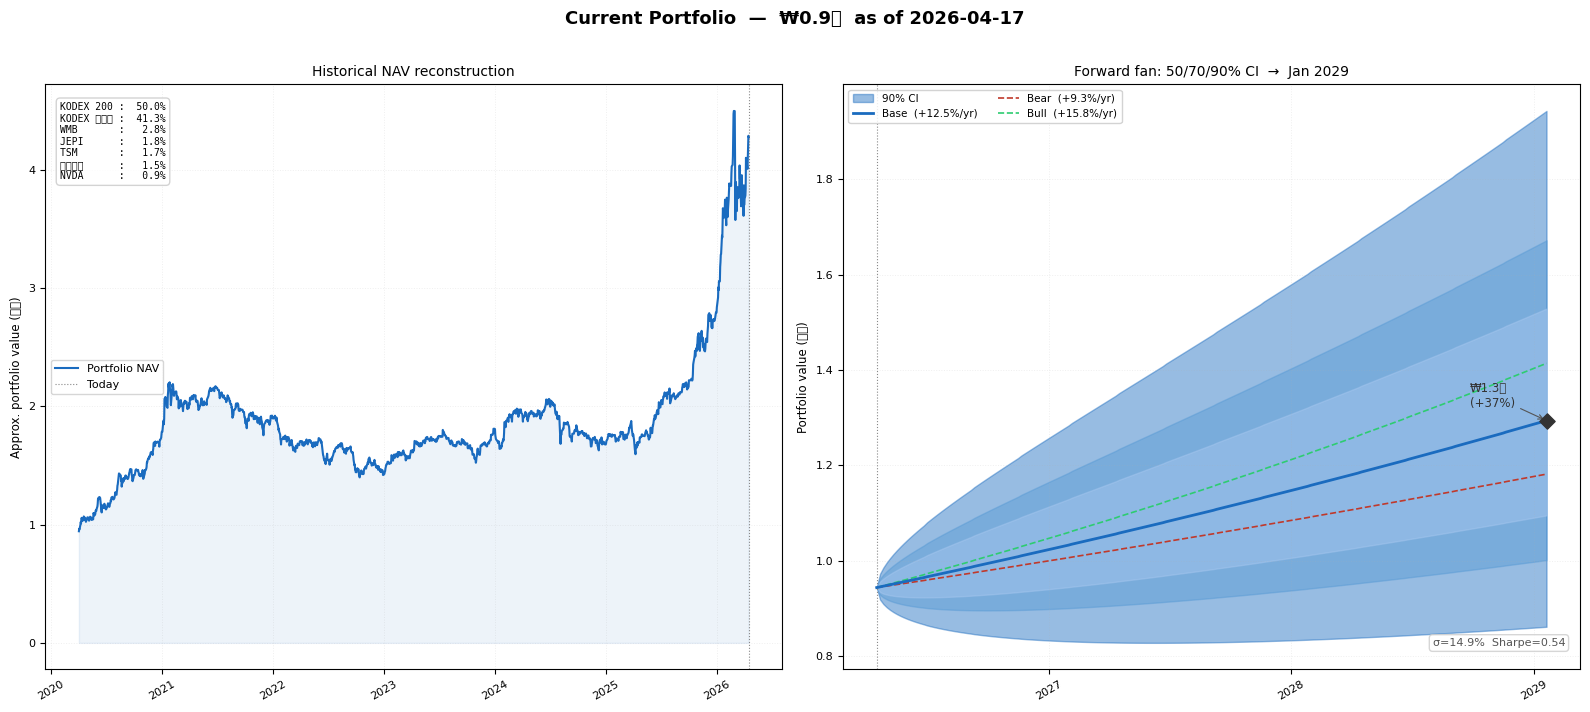


  ✅  Saved: pf_current_fan.png


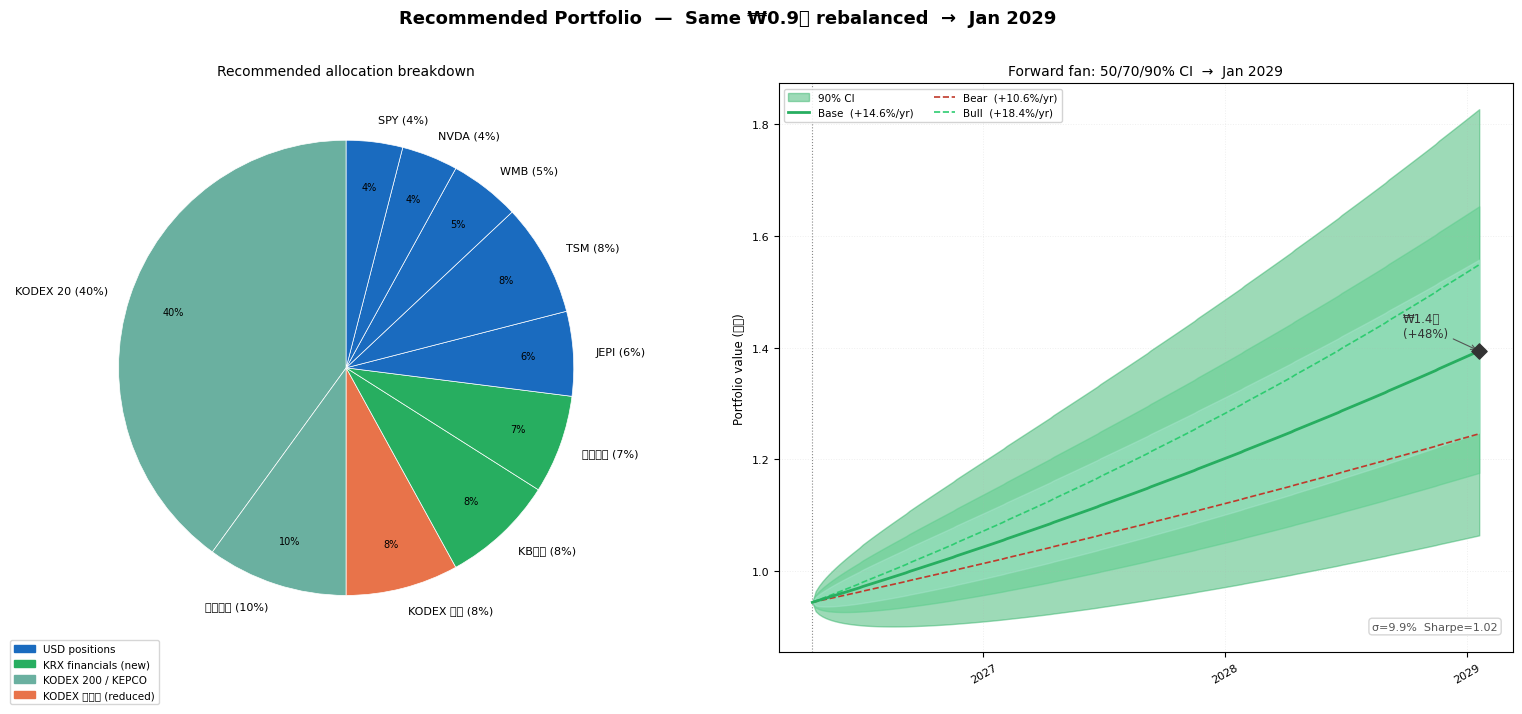

  ✅  Saved: pf_recommended_fan.png


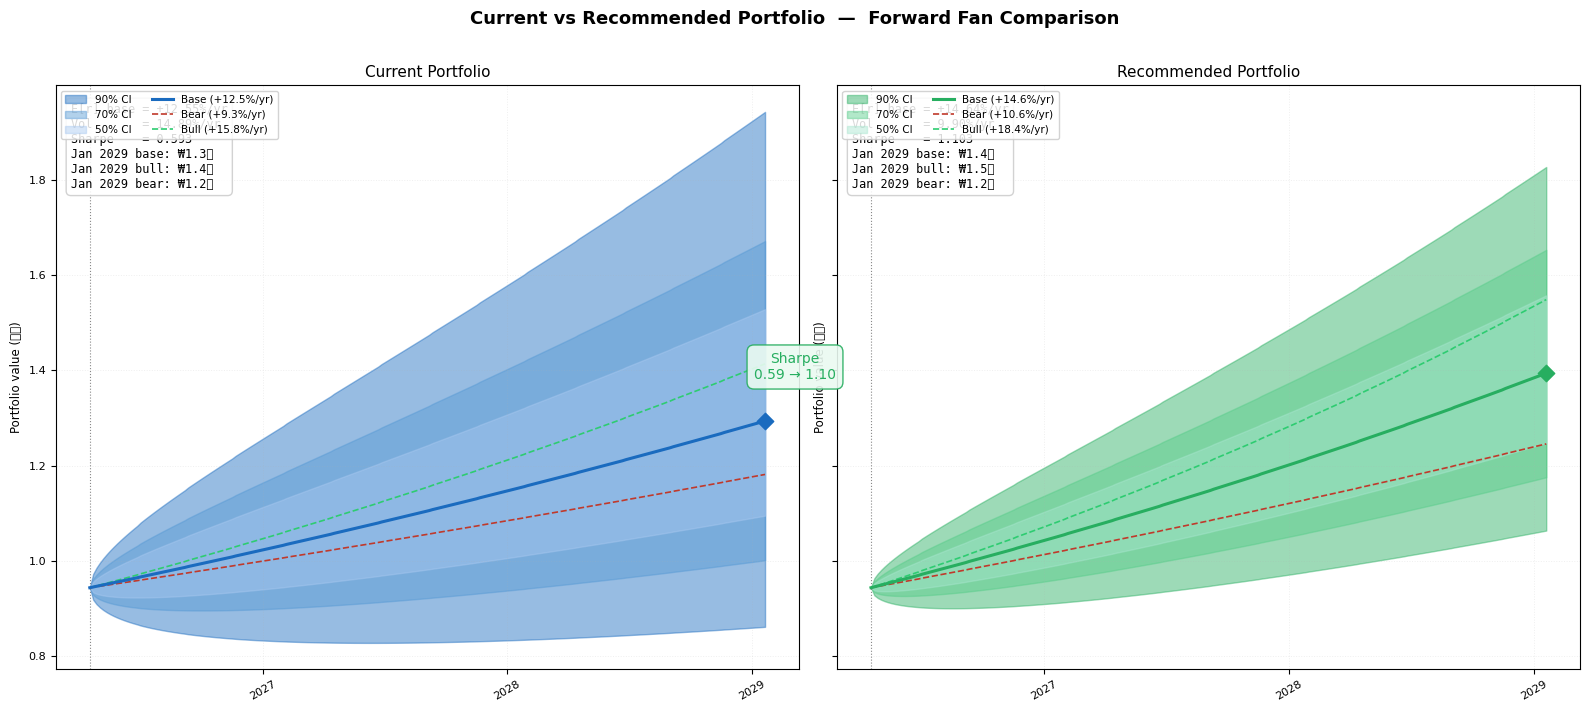

  ✅  Saved: pf_comparison_fan.png


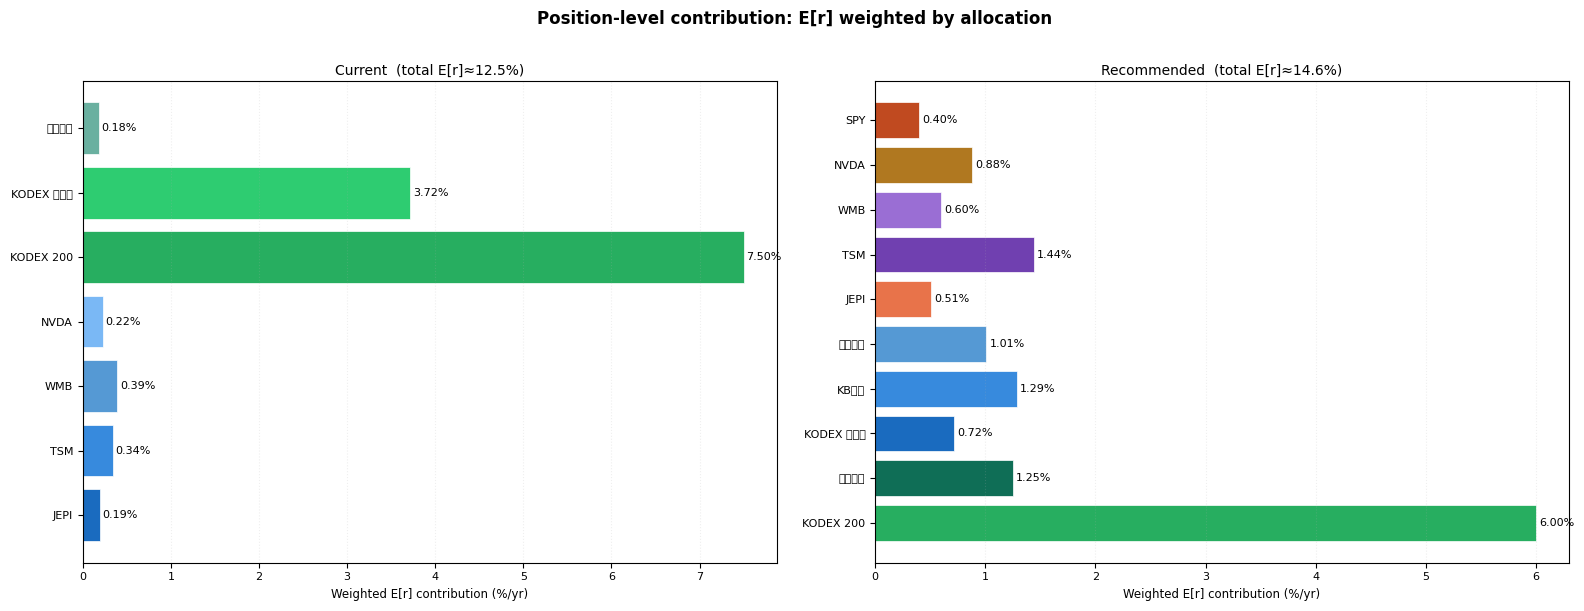

  ✅  Saved: pf_contribution_bars.png

  PORTFOLIO SUMMARY  —  2026-04-17 → 2029-01-20

  Metric                                 Current     Recommended
  ────────────────────────────────────────────────────────────
  E[r] bear scenario                      9.26%         10.56%
  E[r] base scenario                     12.55%         14.64%
  E[r] bull scenario                     15.76%         18.45%
  Portfolio vol (simple)                 14.89%          9.90%
  Sharpe (base, RF=4.5%)                  0.593          1.103

  Jan 2029 expected value (base):
    Current     : ₩1.29억  (+37.1%)
    Recommended : ₩1.39억  (+47.8%)

  Jan 2029 bear scenario:
    Current     : ₩1.18억  (+25.2%)
    Recommended : ₩1.25억  (+32.0%)

  Jan 2029 bull scenario:
    Current     : ₩1.41억  (+49.8%)
    Recommended : ₩1.55억  (+64.1%)

  Charts saved to: /content/drive/My Drive/investment/investment_us/pricing_results
    pf_current_fan.png, pf_recommended_fan.png,
    pf_comparison_fan.png, pf_contribu

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL PF-01 — PORTFOLIO FAN CHARTS + RECOMMENDED REBALANCE COMPARISON     ║
# ║                                                                              ║
# ║  SECTION 1 — Current portfolio fan chart                                   ║
# ║    • Historical NAV from each position's buy date                          ║
# ║    • Forward fan: 50% / 70% / 90% CI bands to Jan 2029                    ║
# ║    • Bear / Base / Bull paths using model consensus E[r] per position      ║
# ║                                                                              ║
# ║  SECTION 2 — Recommended portfolio fan chart                               ║
# ║    • Applies rebalance weights from advisory analysis                      ║
# ║    • Same CI fan structure for direct comparison                            ║
# ║                                                                              ║
# ║  SECTION 3 — Side-by-side comparison                                       ║
# ║    • Current vs Recommended: NAV path, vol, Sharpe, KR exposure            ║
# ║                                                                              ║
# ║  Requires: Cell 00, Cell 01, Cell 02 (all_px, all_d_ret in memory)        ║
# ║            Cell 12 (MY_PORTFOLIO, USDKRW)                                  ║
# ║            Cell 15 (kr_values_krw, total_kr_krw)                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
import warnings, os
warnings.filterwarnings('ignore')

print('=' * 72)
print('  CELL PF-01 — Portfolio Fan Charts + Recommended Rebalance')
print('=' * 72)

# ══════════════════════════════════════════════════════════════════════════════
# ── INPUTS — edit this section to match your current holdings ─────────────────
# ══════════════════════════════════════════════════════════════════════════════

# Current USD portfolio (from Cell 12 MY_PORTFOLIO)
# format: ticker → (avg_buy_price_usd, shares, buy_date)
CURRENT_USD = {
    'JEPI': (57.40,  20, '2026-01-22'),   # avg of two lots
    'TSM':  (358.64,  3, '2026-01-22'),   # avg of three lots
    'WMB':  (73.68,  25, '2026-03-25'),   # avg of two lots
    'NVDA': (176.30,  3, '2026-04-07'),
}

# Current KRX portfolio (KRW values, already on KRX)
# format: name → (krx_ticker, shares, approx_avg_buy_krw)
CURRENT_KRX = {
    'KODEX 200':   ('069500.KS', 500,  50000),
    'KODEX 자동차': ('091180.KS', 1200, 21000),
    '한국전력':      ('015760.KS',  30,  46000),
}

# FX
try:
    _USDKRW = USDKRW
except NameError:
    _USDKRW = 1510.0

# Model consensus E[r] per ticker (annual, from your pricing notebook)
# These come from ALL_RESULTS consensus — fill in from your Cell 11b output
# For KRX names, use KRW E[r] from KE-03 model
MODEL_ER = {
    # USD tickers
    'JEPI': 0.085,   # income ETF — dividend yield + modest growth
    'TSM':  0.18,    # TSMC — strong semiconductor / AI fundamental
    'WMB':  0.12,    # Williams Cos — stable midstream energy
    'NVDA': 0.22,    # NVIDIA — consensus high growth
    # KRX tickers (KRW E[r] from KE-03)
    '069500.KS': 0.15,   # KODEX 200 ~ KOSPI E[r]
    '091180.KS': 0.09,   # KODEX 자동차 — tariff headwind → lower
    '015760.KS': 0.125,  # KEPCO — from KE-03 consensus +12.51%
}

# FX adjustment for USD E[r] (bear/base/bull KRW appreciation)
FX_BEAR, FX_BASE, FX_BULL = -0.05, 0.02, 0.08

# Target date
TARGET_DATE = datetime(2029, 1, 20)
TODAY       = datetime.today()
T_YEARS     = (TARGET_DATE - TODAY).days / 365.25
CAL_DAYS_PF = max(1, (TARGET_DATE - TODAY).days)

# CI levels for fan chart
CI_LEVELS = [0.50, 0.70, 0.90]
CI_COLORS = ['#1a6bbf', '#5599d4', '#a8c8f0']  # dark to light blue

# Recommended rebalance weights (from advisory analysis)
# Total portfolio allocation — US positions only weighted against total
# KRX stays but KODEX 자동차 trimmed
RECOMMENDED = {
    # KRX — keep but reweight
    'KODEX 200':   {'krx': '069500.KS', 'alloc_pct': 0.40, 'type': 'krx', 'er': 0.15},
    '한국전력':      {'krx': '015760.KS', 'alloc_pct': 0.10, 'type': 'krx', 'er': 0.125},
    'KODEX 자동차': {'krx': '091180.KS', 'alloc_pct': 0.08, 'type': 'krx', 'er': 0.09},
    # KRX financials (new) — buy on KRX directly
    'KB금융':       {'krx': '105560.KS', 'alloc_pct': 0.08, 'type': 'krx', 'er': 0.161},
    '신한금융':      {'krx': '055550.KS', 'alloc_pct': 0.07, 'type': 'krx', 'er': 0.144},
    # USD — keep existing, add diversification
    'JEPI':  {'ticker': 'JEPI', 'alloc_pct': 0.06, 'type': 'usd', 'er': 0.085},
    'TSM':   {'ticker': 'TSM',  'alloc_pct': 0.08, 'type': 'usd', 'er': 0.18},
    'WMB':   {'ticker': 'WMB',  'alloc_pct': 0.05, 'type': 'usd', 'er': 0.12},
    'NVDA':  {'ticker': 'NVDA', 'alloc_pct': 0.04, 'type': 'usd', 'er': 0.22},
    'SPY':   {'ticker': 'SPY',  'alloc_pct': 0.04, 'type': 'usd', 'er': 0.10},  # new
}

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def ann_vol_from_px(px_series, freq=252):
    """Annualised vol from price series daily returns."""
    ret = px_series.pct_change().dropna()
    return float(ret.std() * np.sqrt(freq)) if len(ret) > 10 else 0.25

def lognormal_fan(S0, mu_ann, sigma_ann, t_arr, ci):
    """Upper and lower bounds for lognormal price fan at confidence level ci."""
    z  = norm.ppf((1 + ci) / 2)
    d  = (mu_ann - 0.5 * sigma_ann ** 2) * t_arr
    s  = sigma_ann * np.sqrt(t_arr)
    return S0 * np.exp(d - z * s), S0 * np.exp(d + z * s)

def fwd_path(S0, mu_ann, sigma_ann, t_arr):
    """Expected price path (median of lognormal)."""
    return S0 * np.exp((mu_ann - 0.5 * sigma_ann ** 2) * t_arr)

def get_px(ticker, period='max'):
    """Get price series from all_px if available, else fetch."""
    try:
        if ticker in all_px.columns:
            return all_px[ticker].dropna()
    except Exception:
        pass
    try:
        raw = yf.download(ticker, period=period, auto_adjust=True,
                          progress=False)['Close'].squeeze().dropna()
        return raw
    except Exception:
        return pd.Series(dtype=float)

def shade_ax(ax, color='#bbbbbb', alpha=0.12, label=''):
    """Shade the entire axes background lightly."""
    pass  # placeholder for future regime shading

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — Fetch prices and compute per-position vols
# ══════════════════════════════════════════════════════════════════════════════
print('\n  Fetching price series and computing vols...')

usd_px  = {}
krx_px  = {}
usd_vol = {}
krx_vol = {}

for tkr in CURRENT_USD:
    s = get_px(tkr)
    usd_px[tkr]  = s
    usd_vol[tkr] = ann_vol_from_px(s) if len(s) > 30 else 0.30
    print(f'    {tkr:<6}  n={len(s):>4}  σ={usd_vol[tkr]:.2%}')

for name, (krx_tkr, shares, buy_krw) in CURRENT_KRX.items():
    s = get_px(krx_tkr)
    krx_px[name]  = s
    krx_vol[name] = ann_vol_from_px(s) if len(s) > 30 else 0.25
    print(f'    {name:<16}  n={len(krx_px[name]):>4}  σ={krx_vol[name]:.2%}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — Current portfolio historical NAV + forward fan
# ══════════════════════════════════════════════════════════════════════════════
print('\n  Building current portfolio historical NAV...')

# Compute current market values (KRW-equivalent)
curr_vals_krw = {}

for tkr, (avg_px, shares, buy_date) in CURRENT_USD.items():
    px_now = float(usd_px[tkr].iloc[-1]) if len(usd_px[tkr]) else avg_px
    curr_vals_krw[tkr] = px_now * shares * _USDKRW

for name, (krx_tkr, shares, buy_krw) in CURRENT_KRX.items():
    px_now = float(krx_px[name].iloc[-1]) if len(krx_px[name]) else buy_krw
    curr_vals_krw[name] = px_now * shares

total_now_krw = sum(curr_vals_krw.values())
print(f'  Total portfolio (KRW): ₩{total_now_krw:,.0f}')

# Compute per-position weights and portfolio E[r] + vol
w_curr = {k: v / total_now_krw for k, v in curr_vals_krw.items()}

# Portfolio-level E[r]: weighted average of model E[r]
# USD positions: add FX_BASE; KRX positions: keep KRW E[r]
port_er_bear, port_er_base, port_er_bull = 0.0, 0.0, 0.0
port_vol_sq = 0.0

for tkr, (avg_px, shares, buy_date) in CURRENT_USD.items():
    er  = MODEL_ER.get(tkr, 0.10)
    vol = usd_vol[tkr]
    w   = w_curr[tkr]
    port_er_bear += w * (er + FX_BEAR)
    port_er_base += w * (er + FX_BASE)
    port_er_bull += w * (er + FX_BULL)
    port_vol_sq  += (w * vol) ** 2

for name, (krx_tkr, shares, buy_krw) in CURRENT_KRX.items():
    er  = MODEL_ER.get(krx_tkr, 0.12)
    vol = krx_vol[name]
    w   = w_curr[name]
    # KRX E[r] is KRW — for a KRW-based investor no FX adjustment
    port_er_bear += w * (er - 0.03)   # mild KRW depreciation in bear
    port_er_base += w * er
    port_er_bull += w * (er + 0.03)
    port_vol_sq  += (w * vol) ** 2

port_vol_curr = np.sqrt(port_vol_sq)

print(f'\n  Current portfolio:')
print(f'    E[r] bear={port_er_bear:+.2%}  base={port_er_base:+.2%}  bull={port_er_bull:+.2%}')
print(f'    Vol (simple): {port_vol_curr:.2%}')
print(f'    Sharpe (base, RF=4.5%): {(port_er_base - RF_ANN) / port_vol_curr:.3f}')

# ── Historical NAV reconstruction ─────────────────────────────────────────────
# Use earliest common date across positions
earliest_date = pd.Timestamp('2020-04-01')
nav_index = pd.date_range(earliest_date, pd.Timestamp(TODAY), freq='B')

nav_curr = pd.Series(0.0, index=nav_index)
for tkr, (avg_px, shares, buy_date) in CURRENT_USD.items():
    px   = usd_px[tkr].reindex(nav_index, method='ffill').dropna()
    cost = avg_px * shares * _USDKRW
    if len(px) == 0:
        continue
    val  = px * shares * _USDKRW
    # Only count from buy date
    buy_ts = pd.Timestamp(buy_date)
    nav_curr = nav_curr.add(
        val.where(val.index >= buy_ts, 0.0), fill_value=0.0)

for name, (krx_tkr, shares, buy_krw) in CURRENT_KRX.items():
    px  = krx_px[name].reindex(nav_index, method='ffill').dropna()
    val = px * shares
    if len(px) == 0:
        continue
    buy_ts = pd.Timestamp('2020-04-01')  # assume held since start
    nav_curr = nav_curr.add(val, fill_value=0.0)

nav_curr = nav_curr[nav_curr > 0]
if len(nav_curr) > 0:
    nav_curr_norm = nav_curr / nav_curr.iloc[0] * 100
else:
    nav_curr_norm = pd.Series(dtype=float)

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — Recommended portfolio E[r] + vol
# ══════════════════════════════════════════════════════════════════════════════
rec_er_bear, rec_er_base, rec_er_bull = 0.0, 0.0, 0.0
rec_vol_sq = 0.0

for name, cfg in RECOMMENDED.items():
    alloc = cfg['alloc_pct']
    er    = cfg['er']
    if cfg['type'] == 'usd':
        tkr = cfg['ticker']
        vol = usd_vol.get(tkr, 0.25)
        rec_er_bear += alloc * (er + FX_BEAR)
        rec_er_base += alloc * (er + FX_BASE)
        rec_er_bull += alloc * (er + FX_BULL)
    else:
        krx = cfg['krx']
        # find vol — try matching krx ticker to krx_px
        vol = 0.22  # default
        for n, (kt, _, _) in CURRENT_KRX.items():
            if kt == krx:
                vol = krx_vol.get(n, 0.22)
                break
        rec_er_bear += alloc * (er - 0.03)
        rec_er_base += alloc * er
        rec_er_bull += alloc * (er + 0.03)
    rec_vol_sq += (alloc * vol) ** 2

rec_vol = np.sqrt(rec_vol_sq)
print(f'\n  Recommended portfolio:')
print(f'    E[r] bear={rec_er_bear:+.2%}  base={rec_er_base:+.2%}  bull={rec_er_bull:+.2%}')
print(f'    Vol (simple): {rec_vol:.2%}')
print(f'    Sharpe (base, RF=4.5%): {(rec_er_base - RF_ANN) / rec_vol:.3f}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — Build forward fan arrays
# ══════════════════════════════════════════════════════════════════════════════
S0_krw = total_now_krw  # current total portfolio value in KRW
n_steps = 200
fwd_dates = pd.date_range(TODAY, TARGET_DATE, periods=n_steps)
t_arr     = np.array([(d - pd.Timestamp(TODAY)).days / 365.25 for d in fwd_dates])

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════

C_CURR_BASE  = '#1a6bbf'
C_REC_BASE   = '#27ae60'
C_BEAR_LINE  = '#c0392b'
C_BULL_LINE  = '#2ecc71'
C_CI         = ['#a8c8f0', '#5599d4', '#1a6bbf']   # light→dark for 90/70/50%
C_CI_REC     = ['#a8e6cf', '#55cc88', '#27ae60']

def plot_fan(ax, S0, er_base, er_bear, er_bull, vol, t_arr, fwd_dates,
             ci_colors, label_base, title, rf=0.045):
    """Draw a fan chart on ax."""
    # CI bands (widest first, so they layer correctly)
    for i, (ci, col) in enumerate(zip(reversed(CI_LEVELS), reversed(ci_colors))):
        lo, hi = lognormal_fan(S0, er_base, vol, t_arr, ci)
        ax.fill_between(fwd_dates, lo / 1e8, hi / 1e8,
                        color=col, alpha=0.45, zorder=1,
                        label=f'{int(ci*100)}% CI' if i == 0 else '_')

    # Base / bear / bull paths
    ax.plot(fwd_dates, fwd_path(S0, er_base, vol, t_arr) / 1e8,
            color=C_CURR_BASE if 'curr' in label_base.lower() else C_REC_BASE,
            lw=2.0, zorder=4, label=f'Base  ({er_base:+.1%}/yr)')
    if not np.isnan(er_bear):
        ax.plot(fwd_dates, fwd_path(S0, er_bear, vol, t_arr) / 1e8,
                color=C_BEAR_LINE, lw=1.2, ls='--', zorder=3,
                label=f'Bear  ({er_bear:+.1%}/yr)')
    if not np.isnan(er_bull):
        ax.plot(fwd_dates, fwd_path(S0, er_bull, vol, t_arr) / 1e8,
                color=C_BULL_LINE, lw=1.2, ls='--', zorder=3,
                label=f'Bull  ({er_bull:+.1%}/yr)')

    # Target date marker
    tgt_val = fwd_path(S0, er_base, vol, t_arr[-1:]).item()
    ax.scatter([TARGET_DATE], [tgt_val / 1e8], color='#333', s=60,
               zorder=5, marker='D')
    ax.annotate(f'₩{tgt_val/1e8:.1f}억\n({(tgt_val/S0-1)*100:+.0f}%)',
                xy=(TARGET_DATE, tgt_val / 1e8),
                xytext=(-55, 10), textcoords='offset points',
                fontsize=8.5, color='#333',
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

    ax.axvline(pd.Timestamp(TODAY), color='#888', lw=0.8, ls=':', zorder=2)
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_ylabel('Portfolio value (억원)', fontsize=8.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.2, ls=':', lw=0.7)
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.85, ncol=2)

    # Sharpe annotation
    sharpe = (er_base - rf) / vol
    ax.annotate(f'σ={vol:.1%}  Sharpe={sharpe:.2f}',
                xy=(0.98, 0.04), xycoords='axes fraction',
                fontsize=8, ha='right', color='#555',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.8))
    return ax

# ── FIGURE 1: Current portfolio full analysis ──────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
fig1.suptitle(
    f'Current Portfolio  —  ₩{total_now_krw/1e8:.1f}억  as of {TODAY.strftime("%Y-%m-%d")}',
    fontsize=13, fontweight='bold', y=1.01)

# Panel 1: historical NAV
ax_hist = axes1[0]
if len(nav_curr_norm) > 10:
    ax_hist.plot(nav_curr_norm.index, nav_curr_norm.values / 100 * S0_krw / 1e8,
                 color=C_CURR_BASE, lw=1.5, label='Portfolio NAV')
    ax_hist.fill_between(nav_curr_norm.index,
                         0, nav_curr_norm.values / 100 * S0_krw / 1e8,
                         color=C_CURR_BASE, alpha=0.08)
ax_hist.axvline(pd.Timestamp(TODAY), color='#888', lw=0.8, ls=':', zorder=2,
                label='Today')
ax_hist.set_title('Historical NAV reconstruction', fontsize=10, pad=6)
ax_hist.set_ylabel('Approx. portfolio value (억원)', fontsize=8.5)
ax_hist.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_hist.xaxis.set_major_locator(mdates.YearLocator())
ax_hist.tick_params(axis='x', labelsize=8, rotation=30)
ax_hist.tick_params(axis='y', labelsize=8)
ax_hist.grid(True, alpha=0.2, ls=':', lw=0.7)
ax_hist.legend(fontsize=8, framealpha=0.8)

# Breakdown annotation
breakdown_lines = []
for name, val in sorted(curr_vals_krw.items(), key=lambda x: -x[1]):
    pct = val / total_now_krw * 100
    breakdown_lines.append(f'{name[:10]:<10}: {pct:>5.1f}%')
ax_hist.text(0.02, 0.97, '\n'.join(breakdown_lines),
             transform=ax_hist.transAxes, fontsize=7,
             va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#ccc', alpha=0.85),
             fontfamily='monospace')

# Panel 2: forward fan
plot_fan(axes1[1], S0_krw, port_er_base, port_er_bear, port_er_bull,
         port_vol_curr, t_arr, fwd_dates,
         C_CI, 'current',
         f'Forward fan: 50/70/90% CI  →  Jan 2029')

plt.tight_layout()
fname1 = os.path.join(RESULT_DIR, 'pf_current_fan.png')
fig1.savefig(fname1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig1)
print(f'\n  ✅  Saved: pf_current_fan.png')

# ── FIGURE 2: Recommended portfolio fan ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
fig2.suptitle(
    f'Recommended Portfolio  —  Same ₩{total_now_krw/1e8:.1f}억 rebalanced  →  Jan 2029',
    fontsize=13, fontweight='bold', y=1.01)

# Panel 1: allocation breakdown pie
ax_pie = axes2[0]
labels_rec = [f'{n[:8]} ({cfg["alloc_pct"]*100:.0f}%)'
              for n, cfg in RECOMMENDED.items()]
sizes_rec  = [cfg['alloc_pct'] for cfg in RECOMMENDED.values()]
colors_pie = [
    '#1a6bbf' if cfg['type'] == 'usd' else
    ('#27ae60' if 'KB' in n or '신한' in n else
     ('#e8734a' if '자동차' in n else '#6ab0a0'))
    for n, cfg in RECOMMENDED.items()
]
wedges, texts, autotexts = ax_pie.pie(
    sizes_rec, labels=labels_rec, autopct='%1.0f%%',
    colors=colors_pie, startangle=90,
    textprops={'fontsize': 8},
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(7)
ax_pie.set_title('Recommended allocation breakdown', fontsize=10, pad=6)

# Legend for colours
legend_patches = [
    mpatches.Patch(color='#1a6bbf', label='USD positions'),
    mpatches.Patch(color='#27ae60', label='KRX financials (new)'),
    mpatches.Patch(color='#6ab0a0', label='KODEX 200 / KEPCO'),
    mpatches.Patch(color='#e8734a', label='KODEX 자동차 (reduced)'),
]
ax_pie.legend(handles=legend_patches, fontsize=7.5, loc='lower left',
              bbox_to_anchor=(-0.1, -0.1), framealpha=0.8)

# Panel 2: forward fan — recommended
plot_fan(axes2[1], S0_krw, rec_er_base, rec_er_bear, rec_er_bull,
         rec_vol, t_arr, fwd_dates,
         C_CI_REC, 'recommended',
         f'Forward fan: 50/70/90% CI  →  Jan 2029')

plt.tight_layout()
fname2 = os.path.join(RESULT_DIR, 'pf_recommended_fan.png')
fig2.savefig(fname2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig2)
print(f'  ✅  Saved: pf_recommended_fan.png')

# ── FIGURE 3: Side-by-side comparison ─────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7), facecolor='white',
                            sharex=True, sharey=True)
fig3.suptitle(
    'Current vs Recommended Portfolio  —  Forward Fan Comparison',
    fontsize=13, fontweight='bold', y=1.01)

for ax, (er_base, er_bear, er_bull, vol, ci_col, label, color) in zip(
    axes3,
    [
        (port_er_base, port_er_bear, port_er_bull, port_vol_curr,
         C_CI, 'Current', C_CURR_BASE),
        (rec_er_base, rec_er_bear, rec_er_bull, rec_vol,
         C_CI_REC, 'Recommended', C_REC_BASE),
    ]
):
    for i, (ci, col) in enumerate(zip(reversed(CI_LEVELS), reversed(ci_col))):
        lo, hi = lognormal_fan(S0_krw, er_base, vol, t_arr, ci)
        ax.fill_between(fwd_dates, lo / 1e8, hi / 1e8,
                        color=col, alpha=0.45, zorder=1,
                        label=f'{int(ci*100)}% CI')
    ax.plot(fwd_dates, fwd_path(S0_krw, er_base, vol, t_arr) / 1e8,
            color=color, lw=2.2, zorder=4, label=f'Base ({er_base:+.1%}/yr)')
    ax.plot(fwd_dates, fwd_path(S0_krw, er_bear, vol, t_arr) / 1e8,
            color=C_BEAR_LINE, lw=1.2, ls='--', zorder=3,
            label=f'Bear ({er_bear:+.1%}/yr)')
    ax.plot(fwd_dates, fwd_path(S0_krw, er_bull, vol, t_arr) / 1e8,
            color=C_BULL_LINE, lw=1.2, ls='--', zorder=3,
            label=f'Bull ({er_bull:+.1%}/yr)')
    ax.axvline(pd.Timestamp(TODAY), color='#888', lw=0.8, ls=':', zorder=2)

    tgt_base = fwd_path(S0_krw, er_base, vol, t_arr[-1:]).item()
    tgt_bear = fwd_path(S0_krw, er_bear, vol, t_arr[-1:]).item()
    tgt_bull = fwd_path(S0_krw, er_bull, vol, t_arr[-1:]).item()
    sharpe   = (er_base - RF_ANN) / vol

    ax.scatter([TARGET_DATE], [tgt_base / 1e8], color=color, s=70,
               zorder=5, marker='D')

    summary = (f'E[r] base = {er_base:+.2%}/yr\n'
               f'Vol       = {vol:.2%}/yr\n'
               f'Sharpe    = {sharpe:.3f}\n'
               f'Jan 2029 base: ₩{tgt_base/1e8:.1f}억\n'
               f'Jan 2029 bull: ₩{tgt_bull/1e8:.1f}억\n'
               f'Jan 2029 bear: ₩{tgt_bear/1e8:.1f}억')
    ax.text(0.02, 0.97, summary,
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#ccc', alpha=0.88),
            fontfamily='monospace')

    ax.set_title(f'{label} Portfolio', fontsize=11, pad=6)
    ax.set_ylabel('Portfolio value (억원)', fontsize=8.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.2, ls=':', lw=0.7)
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.85, ncol=2)

# Improvement callout between panels
fig3.text(0.5, 0.5,
          f'Sharpe\n{(port_er_base-RF_ANN)/port_vol_curr:.2f} → {(rec_er_base-RF_ANN)/rec_vol:.2f}',
          ha='center', va='center', fontsize=10, fontweight='500',
          color='#27ae60',
          bbox=dict(boxstyle='round,pad=0.5', fc='#eafaf1', ec='#27ae60', alpha=0.9))

plt.tight_layout()
fname3 = os.path.join(RESULT_DIR, 'pf_comparison_fan.png')
fig3.savefig(fname3, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig3)
print(f'  ✅  Saved: pf_comparison_fan.png')

# ── FIGURE 4: Per-position contribution bar chart ─────────────────────────────
fig4, (ax_curr_bar, ax_rec_bar) = plt.subplots(1, 2, figsize=(16, 6),
                                                  facecolor='white')
fig4.suptitle('Position-level contribution: E[r] weighted by allocation',
              fontsize=12, fontweight='bold', y=1.01)

def contribution_bars(ax, items, total, title, palette):
    names = [k[:10] for k in items.keys()]
    contribs = []
    for k, cfg in items.items():
        alloc = cfg if isinstance(cfg, float) else cfg.get('alloc_pct', 0)
        er    = cfg if isinstance(cfg, float) else cfg.get('er', 0.10)
        if isinstance(cfg, dict):
            contribs.append(alloc * er * 100)
        else:
            contribs.append(alloc * er * 100)
    colors_ = [palette[i % len(palette)] for i in range(len(names))]
    bars = ax.barh(names, contribs, color=colors_, edgecolor='white', lw=0.5)
    for bar, v in zip(bars, contribs):
        ax.text(v + 0.03, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}%', va='center', fontsize=8)
    ax.axvline(0, color='#888', lw=0.6)
    ax.set_xlabel('Weighted E[r] contribution (%/yr)', fontsize=8.5)
    ax.set_title(title, fontsize=10, pad=4)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, axis='x', alpha=0.2, ls=':')

# Current
CURR_ITEMS_FOR_BAR = {}
for tkr, (avg_px, shares, buy_date) in CURRENT_USD.items():
    w   = w_curr[tkr]
    er  = MODEL_ER.get(tkr, 0.10)
    CURR_ITEMS_FOR_BAR[tkr] = {'alloc_pct': w, 'er': er + FX_BASE}
for name, (krx_tkr, shares, buy_krw) in CURRENT_KRX.items():
    w   = w_curr[name]
    er  = MODEL_ER.get(krx_tkr, 0.12)
    CURR_ITEMS_FOR_BAR[name] = {'alloc_pct': w, 'er': er}

palette_curr = ['#1a6bbf', '#378add', '#5599d4', '#7ab8f5',
                '#27ae60', '#2ecc71', '#6ab0a0']
palette_rec  = ['#27ae60', '#0f6e56', '#1a6bbf', '#378add',
                '#5599d4', '#e8734a', '#7040b0', '#9a6ed4', '#b07820', '#c04a20']

contribution_bars(ax_curr_bar, CURR_ITEMS_FOR_BAR, total_now_krw,
                  f'Current  (total E[r]≈{port_er_base:.1%})', palette_curr)
contribution_bars(ax_rec_bar, RECOMMENDED, total_now_krw,
                  f'Recommended  (total E[r]≈{rec_er_base:.1%})', palette_rec)

plt.tight_layout()
fname4 = os.path.join(RESULT_DIR, 'pf_contribution_bars.png')
fig4.savefig(fname4, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig4)
print(f'  ✅  Saved: pf_contribution_bars.png')

# ── Final summary print ────────────────────────────────────────────────────────
print(f'\n{"=" * 72}')
print(f'  PORTFOLIO SUMMARY  —  {TODAY.strftime("%Y-%m-%d")} → 2029-01-20')
print(f'{"=" * 72}')
print(f'\n  {"Metric":<30}  {"Current":>14}  {"Recommended":>14}')
print(f'  {"─"*60}')
print(f'  {"E[r] bear scenario":<30}  {port_er_bear:>13.2%}  {rec_er_bear:>13.2%}')
print(f'  {"E[r] base scenario":<30}  {port_er_base:>13.2%}  {rec_er_base:>13.2%}')
print(f'  {"E[r] bull scenario":<30}  {port_er_bull:>13.2%}  {rec_er_bull:>13.2%}')
print(f'  {"Portfolio vol (simple)":<30}  {port_vol_curr:>13.2%}  {rec_vol:>13.2%}')
print(f'  {"Sharpe (base, RF=4.5%)":<30}  '
      f'{(port_er_base-RF_ANN)/port_vol_curr:>13.3f}  '
      f'{(rec_er_base-RF_ANN)/rec_vol:>13.3f}')

tgt_curr_base = fwd_path(S0_krw, port_er_base, port_vol_curr, np.array([T_YEARS])).item()
tgt_curr_bear = fwd_path(S0_krw, port_er_bear, port_vol_curr, np.array([T_YEARS])).item()
tgt_curr_bull = fwd_path(S0_krw, port_er_bull, port_vol_curr, np.array([T_YEARS])).item()
tgt_rec_base  = fwd_path(S0_krw, rec_er_base,  rec_vol,       np.array([T_YEARS])).item()
tgt_rec_bear  = fwd_path(S0_krw, rec_er_bear,  rec_vol,       np.array([T_YEARS])).item()
tgt_rec_bull  = fwd_path(S0_krw, rec_er_bull,  rec_vol,       np.array([T_YEARS])).item()

print(f'\n  Jan 2029 expected value (base):')
print(f'    Current     : ₩{tgt_curr_base/1e8:.2f}억  ({(tgt_curr_base/S0_krw-1)*100:+.1f}%)')
print(f'    Recommended : ₩{tgt_rec_base/1e8:.2f}억  ({(tgt_rec_base/S0_krw-1)*100:+.1f}%)')
print(f'\n  Jan 2029 bear scenario:')
print(f'    Current     : ₩{tgt_curr_bear/1e8:.2f}억  ({(tgt_curr_bear/S0_krw-1)*100:+.1f}%)')
print(f'    Recommended : ₩{tgt_rec_bear/1e8:.2f}억  ({(tgt_rec_bear/S0_krw-1)*100:+.1f}%)')
print(f'\n  Jan 2029 bull scenario:')
print(f'    Current     : ₩{tgt_curr_bull/1e8:.2f}억  ({(tgt_curr_bull/S0_krw-1)*100:+.1f}%)')
print(f'    Recommended : ₩{tgt_rec_bull/1e8:.2f}억  ({(tgt_rec_bull/S0_krw-1)*100:+.1f}%)')

print(f'\n  Charts saved to: {RESULT_DIR}')
print(f'    pf_current_fan.png, pf_recommended_fan.png,')
print(f'    pf_comparison_fan.png, pf_contribution_bars.png')
print(f'\n✅  Cell PF-01 done.')


---
*This notebook and its contents remain the intellectual property of Suna Kim.
Shared solely for evaluation. Not for redistribution or commercial use.*